## Section 0: Setup and Configuration

In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 50)

SEED = 42

PROJECT_ROOT   = Path('C:/Users/dhara/OneDrive/Desktop/Project 1')
DATA_DIR       = PROJECT_ROOT / 'data'
CCSR_DIR       = PROJECT_ROOT / 'ccsr'
OUTPUTS_DIR    = PROJECT_ROOT / 'outputs'
ADMISSIONS_PATH = DATA_DIR / 'admissions.csv'
PATIENTS_PATH   = DATA_DIR / 'patients.csv'
DIAGNOSES_PATH  = DATA_DIR / 'diagnoses_icd.csv'

paths = {
    'PROJECT_ROOT':    PROJECT_ROOT,
    'DATA_DIR':        DATA_DIR,
    'CCSR_DIR':        CCSR_DIR,
    'OUTPUTS_DIR':     OUTPUTS_DIR,
    'ADMISSIONS_PATH': ADMISSIONS_PATH,
    'PATIENTS_PATH':   PATIENTS_PATH,
    'DIAGNOSES_PATH':  DIAGNOSES_PATH,
}
for name, path in paths.items():
    status = 'EXISTS ' if path.exists() else 'MISSING'
    print(f'{status}  {name}: {path}')

EXISTS   PROJECT_ROOT: C:\Users\dhara\OneDrive\Desktop\Project 1
EXISTS   DATA_DIR: C:\Users\dhara\OneDrive\Desktop\Project 1\data
EXISTS   CCSR_DIR: C:\Users\dhara\OneDrive\Desktop\Project 1\ccsr
EXISTS   OUTPUTS_DIR: C:\Users\dhara\OneDrive\Desktop\Project 1\outputs
EXISTS   ADMISSIONS_PATH: C:\Users\dhara\OneDrive\Desktop\Project 1\data\admissions.csv
EXISTS   PATIENTS_PATH: C:\Users\dhara\OneDrive\Desktop\Project 1\data\patients.csv
EXISTS   DIAGNOSES_PATH: C:\Users\dhara\OneDrive\Desktop\Project 1\data\diagnoses_icd.csv


## Section 1: Raw Data Exploration

No transformations. Observe only.

### 1A -- admissions.csv

In [3]:
df_admissions = pd.read_csv(ADMISSIONS_PATH)

print('Shape:', df_admissions.shape)
print()

print('dtypes:')
print(df_admissions.dtypes)
print()

null_counts = df_admissions.isnull().sum()
print('Null counts (columns with nulls only):')
print(null_counts[null_counts > 0])
print()

print('Head (3 rows):')
print(df_admissions.head(3))
print()

print('Unique subject_ids:', df_admissions['subject_id'].nunique())
print('Unique hadm_ids:   ', df_admissions['hadm_id'].nunique())
print()

print('admittime range (raw string min/max):')
print('  min:', df_admissions['admittime'].min())
print('  max:', df_admissions['admittime'].max())
print()

print('admission_type value_counts (top 10):')
print(df_admissions['admission_type'].value_counts(dropna=False).head(10))
print()

print('discharge_location value_counts (top 15):')
print(df_admissions['discharge_location'].value_counts(dropna=False).head(15))
print()

print('insurance value_counts:')
print(df_admissions['insurance'].value_counts(dropna=False))
print()

print('race value_counts (top 15):')
print(df_admissions['race'].value_counts(dropna=False).head(15))
print()

died = (df_admissions['hospital_expire_flag'] == 1).sum()
print(f'Rows where hospital_expire_flag == 1 (in-hospital deaths): {died:,}')

Shape: (546028, 16)

dtypes:
subject_id              int64
hadm_id                 int64
admittime                 str
dischtime                 str
deathtime                 str
admission_type            str
admit_provider_id         str
admission_location        str
discharge_location        str
insurance                 str
language                  str
marital_status            str
race                      str
edregtime                 str
edouttime                 str
hospital_expire_flag    int64
dtype: object

Null counts (columns with nulls only):
deathtime             534238
admit_provider_id          4
admission_location         1
discharge_location    149818
insurance               9355
language                 775
marital_status         13619
edregtime             166788
edouttime             166788
dtype: int64

Head (3 rows):
   subject_id   hadm_id            admittime            dischtime deathtime  \
0    10000032  22595853  2180-05-06 22:23:00  2180-05-07 17:15:00   

### 1B -- patients.csv

In [4]:
df_patients = pd.read_csv(PATIENTS_PATH)

print('Shape:', df_patients.shape)
print()

print('dtypes:')
print(df_patients.dtypes)
print()

null_counts_p = df_patients.isnull().sum()
has_nulls = null_counts_p[null_counts_p > 0]
print('Null counts (columns with nulls only):')
print(has_nulls if len(has_nulls) > 0 else 'None')
print()

print('Head (3 rows):')
print(df_patients.head(3))
print()

print('anchor_age distribution:')
print(f'  min:    {df_patients["anchor_age"].min()}')
print(f'  max:    {df_patients["anchor_age"].max()}')
print(f'  mean:   {df_patients["anchor_age"].mean():.1f}')
print(f'  median: {df_patients["anchor_age"].median():.0f}')
print()

print('gender value_counts:')
print(df_patients['gender'].value_counts(dropna=False))
print()

dod_count = df_patients['dod'].notna().sum()
print(f'Patients with recorded date of death (dod not null): {dod_count:,}')

Shape: (364627, 6)

dtypes:
subject_id           int64
gender                 str
anchor_age           int64
anchor_year          int64
anchor_year_group      str
dod                    str
dtype: object

Null counts (columns with nulls only):
dod    326326
dtype: int64

Head (3 rows):
   subject_id gender  anchor_age  anchor_year anchor_year_group         dod
0    10000032      F          52         2180       2014 - 2016  2180-09-09
1    10000048      F          23         2126       2008 - 2010         NaN
2    10000058      F          33         2168       2020 - 2022         NaN

anchor_age distribution:
  min:    18
  max:    91
  mean:   48.9
  median: 48

gender value_counts:
gender
F    191984
M    172643
Name: count, dtype: int64

Patients with recorded date of death (dod not null): 38,301


### 1C -- diagnoses_icd.csv

In [5]:
df_diagnoses = pd.read_csv(DIAGNOSES_PATH, low_memory=False)

print('Shape:', df_diagnoses.shape)
print()

print('dtypes:')
print(df_diagnoses.dtypes)
print()

print('Head (3 rows):')
print(df_diagnoses.head(3))
print()

print('icd_version value_counts (ICD-9 vs ICD-10):')
print(df_diagnoses['icd_version'].value_counts(dropna=False))
print()

print('Unique subject_ids with diagnoses:', df_diagnoses['subject_id'].nunique())
print('Unique hadm_ids with diagnoses:   ', df_diagnoses['hadm_id'].nunique())
print()

avg_codes = df_diagnoses.groupby('hadm_id')['icd_code'].count().mean()
print(f'Average diagnosis codes per admission: {avg_codes:.1f}')
print()

print('Top 20 most common icd_codes (with version):')
top20 = (df_diagnoses.groupby(['icd_code', 'icd_version'])
         .size()
         .reset_index(name='count')
         .sort_values('count', ascending=False)
         .head(20))
print(top20.to_string(index=False))

Shape: (6364488, 5)

dtypes:
subject_id     int64
hadm_id        int64
seq_num        int64
icd_code         str
icd_version    int64
dtype: object

Head (3 rows):
   subject_id   hadm_id  seq_num icd_code  icd_version
0    10000032  22595853        1     5723            9
1    10000032  22595853        2    78959            9
2    10000032  22595853        3     5715            9

icd_version value_counts (ICD-9 vs ICD-10):
icd_version
10    3455747
9     2908741
Name: count, dtype: int64

Unique subject_ids with diagnoses: 223291
Unique hadm_ids with diagnoses:    545497

Average diagnosis codes per admission: 11.7

Top 20 most common icd_codes (with version):
icd_code  icd_version  count
    4019            9 102368
    E785           10  84570
     I10           10  83775
    2724            9  67293
  Z87891           10  62806
    K219           10  56157
   53081            9  48628
   25000            9  43077
    F329           10  41876
   I2510           10  41550
    F419  

### 1D -- Key Relationships (still no transformations)

Patients with exactly 1 admission: 123,289
Patients with 2+ admissions:       100,163

Distribution of admission counts per patient (top 10):
hadm_id
1     123289
2      44123
3      20108
4      11172
5       6629
6       4312
7       2964
8       2187
9       1651
10      1266
Name: count, dtype: int64



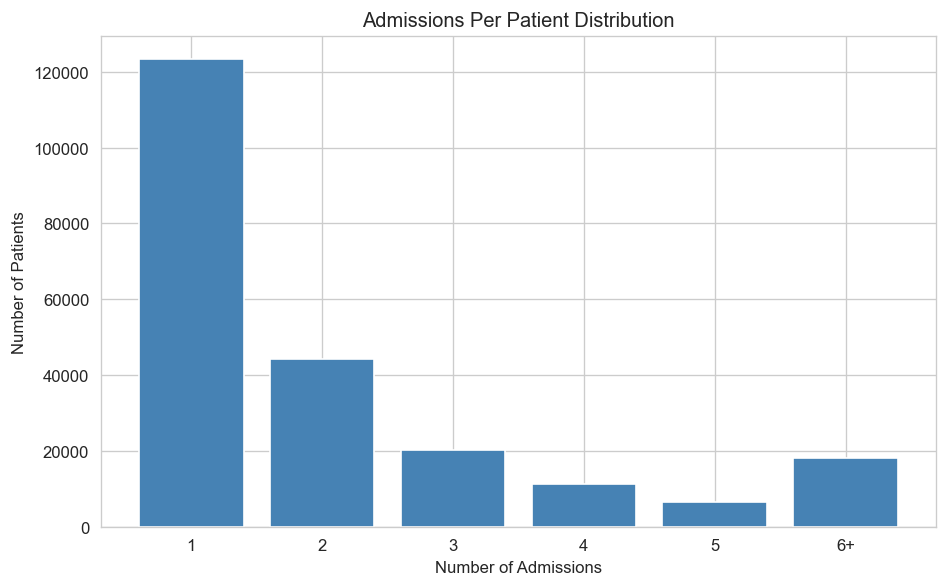

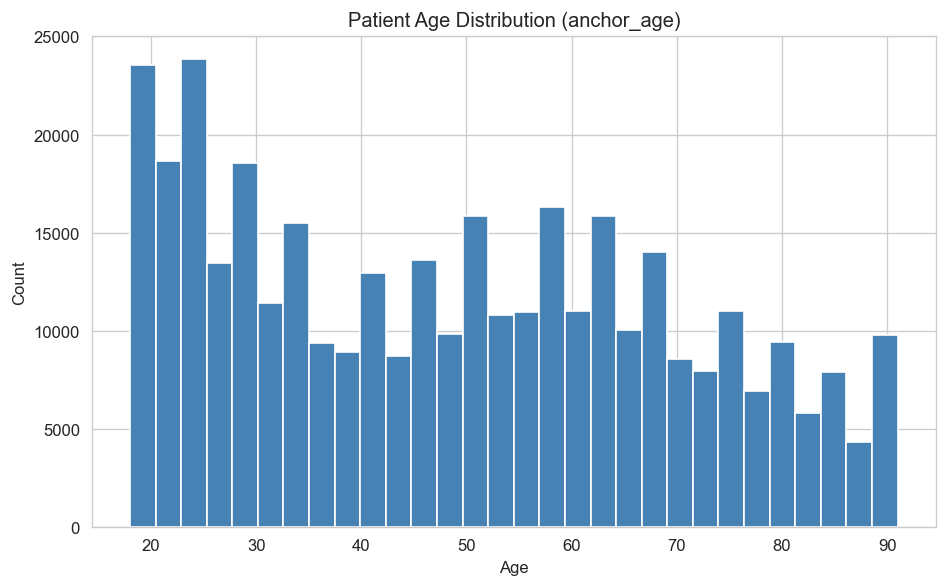

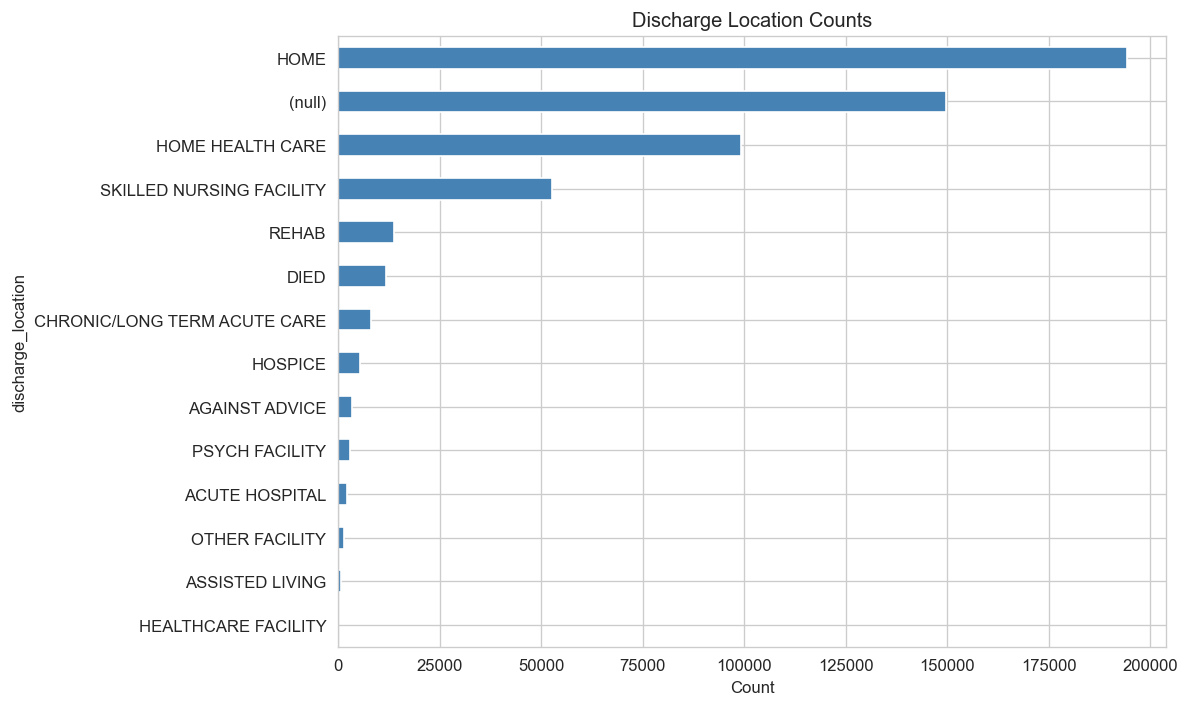

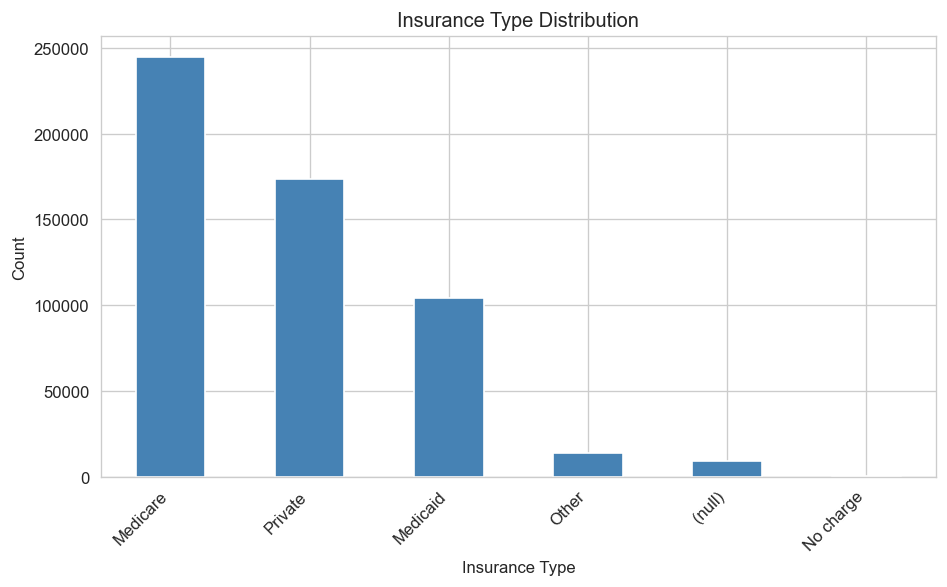

30-day readmission rough estimate (consecutive admission pairs):
  Total consecutive pairs:           322,576
  Pairs within 30 days:              99,721  (30.9%)
  Patients with 2+ admissions:       100,163
  Patients with >= 1 gap under 30d:  47,465  (47.4%)


In [6]:
# Merge for relationship exploration -- temporary, not saved
df_merged = df_admissions.merge(
    df_patients[['subject_id', 'anchor_age', 'gender']],
    on='subject_id', how='left'
)

# Admission counts per patient
adm_per_patient = df_admissions.groupby('subject_id')['hadm_id'].count()
one_admission   = int((adm_per_patient == 1).sum())
multi_admission = int((adm_per_patient > 1).sum())
print(f'Patients with exactly 1 admission: {one_admission:,}')
print(f'Patients with 2+ admissions:       {multi_admission:,}')
print()

print('Distribution of admission counts per patient (top 10):')
print(adm_per_patient.value_counts().sort_index().head(10))
print()

# -- Plot 1: Admissions Per Patient Distribution
adm_clipped = adm_per_patient.clip(upper=6)
bin_counts   = adm_clipped.value_counts().sort_index()
labels       = [str(int(i)) if int(i) < 6 else '6+' for i in bin_counts.index]

plt.figure(figsize=(8, 5))
plt.bar(labels, bin_counts.values, color='steelblue', edgecolor='white')
plt.title('Admissions Per Patient Distribution')
plt.xlabel('Number of Admissions')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

# -- Plot 2: Patient Age Distribution
plt.figure(figsize=(8, 5))
plt.hist(df_patients['anchor_age'], bins=30, color='steelblue', edgecolor='white')
plt.title('Patient Age Distribution (anchor_age)')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# -- Plot 3: Discharge Location Counts (horizontal bar)
top15_discharge = (df_admissions['discharge_location']
                   .fillna('(null)')
                   .value_counts()
                   .head(15))
plt.figure(figsize=(10, 6))
top15_discharge.sort_values().plot(kind='barh', color='steelblue')
plt.title('Discharge Location Counts')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

# -- Plot 4: Insurance Type Distribution
insurance_counts = (df_admissions['insurance']
                    .fillna('(null)')
                    .value_counts())
plt.figure(figsize=(8, 5))
insurance_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Insurance Type Distribution')
plt.xlabel('Insurance Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# -- 30-day readmission rough estimate via consecutive admission pairs
adm_time = df_admissions[['subject_id', 'hadm_id', 'admittime']].copy()
adm_time['admittime'] = pd.to_datetime(adm_time['admittime'])
adm_time = adm_time.sort_values(['subject_id', 'admittime'])
adm_time['next_admittime'] = adm_time.groupby('subject_id')['admittime'].shift(-1)

has_next = adm_time.dropna(subset=['next_admittime']).copy()
has_next['days_to_next'] = (has_next['next_admittime'] - has_next['admittime']).dt.days

within_30_pairs    = int((has_next['days_to_next'] <= 30).sum())
total_pairs        = len(has_next)
pct_pairs          = within_30_pairs / total_pairs * 100

patients_with_30d  = has_next[has_next['days_to_next'] <= 30]['subject_id'].nunique()
pct_patients       = patients_with_30d / multi_admission * 100 if multi_admission > 0 else 0

print('30-day readmission rough estimate (consecutive admission pairs):')
print(f'  Total consecutive pairs:           {total_pairs:,}')
print(f'  Pairs within 30 days:              {within_30_pairs:,}  ({pct_pairs:.1f}%)')
print(f'  Patients with 2+ admissions:       {multi_admission:,}')
print(f'  Patients with >= 1 gap under 30d:  {patients_with_30d:,}  ({pct_patients:.1f}%)')

Section 1 Complete. Observations feed into cohort definition in Section 2.

## Section 2: Cohort Definition

### 2A: Load and Merge Source Tables

In [7]:
df_admissions = pd.read_csv(
    ADMISSIONS_PATH,
    parse_dates=['admittime', 'dischtime', 'deathtime', 'edregtime', 'edouttime']
)
df_patients = pd.read_csv(PATIENTS_PATH)

df_merged = df_admissions.merge(df_patients, on='subject_id', how='left')
print('df_merged.shape:', df_merged.shape)
print('df_merged.columns:')
print(df_merged.columns.tolist())

df_merged.shape: (546028, 21)
df_merged.columns:
['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod']


### 2B: Apply Inclusion Criteria

In [8]:
funnel = []

df = df_merged.copy()
n0, p0 = len(df), df['subject_id'].nunique()
funnel.append(('Start', n0, p0))

# Filter 1: Adults only
df = df[df['anchor_age'] >= 18].copy()
n, p = len(df), df['subject_id'].nunique()
print(f'After age filter: {n:,} admissions, {p:,} unique patients')
funnel.append(('Age >= 18', n, p))

# Filter 2: Exclude in-hospital deaths
df = df[df['hospital_expire_flag'] == 0].copy()
n, p = len(df), df['subject_id'].nunique()
print(f'After death filter: {n:,} admissions, {p:,} unique patients')
funnel.append(('No in-hosp deaths', n, p))

# Filter 3: Flag planned admissions -- do NOT drop rows
df['is_planned'] = df['admission_type'].isin(
    ['ELECTIVE', 'SURGICAL SAME DAY ADMISSION']
).astype(int)
planned_count = int(df['is_planned'].sum())
print(f'Planned admissions flagged: {planned_count:,}')

# Filter 4: Keep only patients with 2+ admissions
adm_counts  = df.groupby('subject_id')['hadm_id'].count()
multi_ids   = adm_counts[adm_counts >= 2].index
df = df[df['subject_id'].isin(multi_ids)].copy()
n, p = len(df), df['subject_id'].nunique()
print(f'After 2+ admissions filter: {n:,} admissions, {p:,} unique patients')
funnel.append(('2+ admissions', n, p))

# Filter 5: Must have at least one ICD diagnosis code
print('Loading diagnoses_icd.csv (hadm_id column only for speed)...')
df_diag = pd.read_csv(DIAGNOSES_PATH, usecols=['hadm_id'], low_memory=False)
hadm_with_icd = set(df_diag['hadm_id'].unique())
del df_diag
df = df[df['hadm_id'].isin(hadm_with_icd)].copy()
n, p = len(df), df['subject_id'].nunique()
print(f'After ICD codes filter: {n:,} admissions, {p:,} unique patients')
funnel.append(('Has ICD codes', n, p))

df_filtered = df

# Funnel summary table
print()
print(f'{"Step":<22} {"Admissions":>12} {"Patients":>10}')
print(f'{"-" * 22} {"-" * 12} {"-" * 10}')
for step, adm, pat in funnel:
    print(f'{step:<22} {adm:>12,} {pat:>10,}')

After age filter: 546,028 admissions, 223,452 unique patients
After death filter: 534,227 admissions, 218,196 unique patients
Planned admissions flagged: 55,786
After 2+ admissions filter: 414,353 admissions, 98,322 unique patients
Loading diagnoses_icd.csv (hadm_id column only for speed)...
After ICD codes filter: 413,981 admissions, 98,312 unique patients

Step                     Admissions   Patients
---------------------- ------------ ----------
Start                       546,028    223,452
Age >= 18                   546,028    223,452
No in-hosp deaths           534,227    218,196
2+ admissions               414,353     98,322
Has ICD codes               413,981     98,312


### 2C: Stratified Sample of 20,000 Patients

Available patients after filters: 98,312
Sampled 20,000 patients stratified by age_group + gender

df_cohort.shape: (83740, 23)
Unique patients: 20000

age_group distribution (unique patients):
age_group
18-30    2480
31-45    3217
46-60    4887
61-75    5555
76+      3861
Name: subject_id, dtype: int64

gender distribution:
gender
F    43477
M    40263
Name: count, dtype: int64


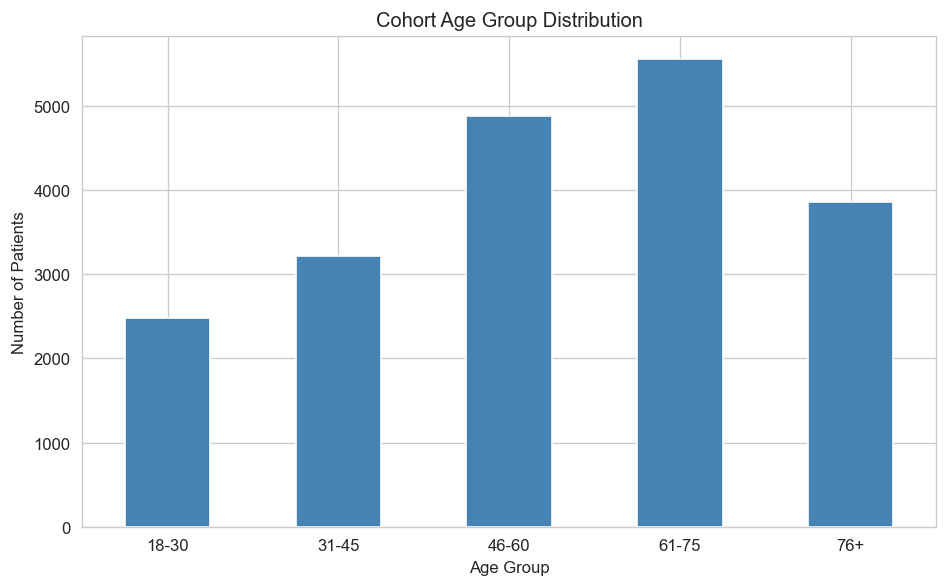

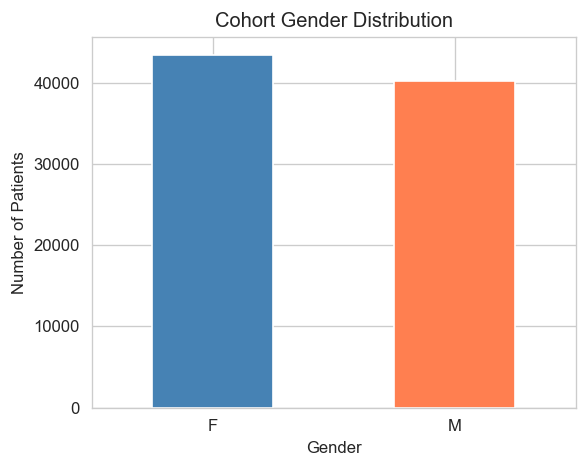

In [9]:
from sklearn.model_selection import train_test_split

# One row per patient for stratification
patient_level = (
    df_filtered.groupby('subject_id')
    .agg(anchor_age=('anchor_age', 'first'), gender=('gender', 'first'))
    .reset_index()
)

bins       = [17, 30, 45, 60, 75, 200]
age_labels = ['18-30', '31-45', '46-60', '61-75', '76+']
patient_level['age_group'] = pd.cut(
    patient_level['anchor_age'], bins=bins, labels=age_labels
)
patient_level['stratum'] = (
    patient_level['age_group'].astype(str) + '_' + patient_level['gender']
)

SAMPLE_SIZE  = 20000
n_available  = len(patient_level)
print(f'Available patients after filters: {n_available:,}')

if n_available <= SAMPLE_SIZE:
    sampled_ids = patient_level['subject_id'].tolist()
    print('All patients selected (fewer than 20,000 available)')
else:
    _, sampled = train_test_split(
        patient_level,
        test_size=SAMPLE_SIZE,
        random_state=SEED,
        stratify=patient_level['stratum']
    )
    sampled_ids = sampled['subject_id'].tolist()
    print(f'Sampled {len(sampled_ids):,} patients stratified by age_group + gender')

df_cohort = df_filtered[df_filtered['subject_id'].isin(sampled_ids)].copy()
df_cohort = df_cohort.merge(
    patient_level[['subject_id', 'age_group']], on='subject_id', how='left'
)

print()
print('df_cohort.shape:', df_cohort.shape)
print('Unique patients:', df_cohort['subject_id'].nunique())
print()
print('age_group distribution (unique patients):')
print(df_cohort.groupby('age_group', observed=True)['subject_id'].nunique().sort_index())
print()
print('gender distribution:')
print(df_cohort['gender'].value_counts())

# -- Plot 1: Age group bar chart
age_dist = df_cohort.groupby('age_group', observed=True)['subject_id'].nunique().sort_index()
plt.figure(figsize=(8, 5))
age_dist.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Cohort Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# -- Plot 2: Gender bar chart
gender_dist = df_cohort['gender'].value_counts()
plt.figure(figsize=(5, 4))
gender_dist.plot(kind='bar', color=['steelblue', 'coral'], edgecolor='white')
plt.title('Cohort Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Section 3: Readmission Label

### 3A: Compute Readmission Label

In [10]:
df_cohort = df_cohort.sort_values(['subject_id', 'admittime']).reset_index(drop=True)

# Next admission info per patient (shift -1 within group)
df_cohort['next_admittime']  = df_cohort.groupby('subject_id')['admittime'].shift(-1)
df_cohort['next_is_planned'] = df_cohort.groupby('subject_id')['is_planned'].shift(-1)

# Days from this discharge to next admission
df_cohort['days_to_next'] = (
    df_cohort['next_admittime'] - df_cohort['dischtime']
).dt.days

# True when no next admission exists for this patient
df_cohort['is_last_admission'] = df_cohort['next_admittime'].isna()

# Label logic -- first matching condition wins
conditions = [
    df_cohort['is_last_admission'],                           # NaN: no next admission
    df_cohort['days_to_next'] <= 0,                          # NaN: data error
    df_cohort['next_is_planned'].fillna(0) == 1,             # 0: planned return, not readmission
    df_cohort['days_to_next'] <= 30,                         # 1: unplanned readmission
]
choices = [np.nan, np.nan, 0.0, 1.0]
df_cohort['readmitted_30d'] = np.select(conditions, choices, default=0.0)

print('readmitted_30d value_counts (including NaN):')
print(df_cohort['readmitted_30d'].value_counts(dropna=False))

readmitted_30d value_counts (including NaN):
readmitted_30d
0.0    43648
NaN    22794
1.0    17298
Name: count, dtype: int64


### 3B: Drop Unresolvable Rows

In [11]:
n_before        = len(df_cohort)
nan_label_count = int(df_cohort['readmitted_30d'].isna().sum())
neg_days_count  = int((df_cohort['days_to_next'].fillna(0) < 0).sum())
last_adm_count  = int(df_cohort['is_last_admission'].sum())

# Drop rows where readmitted_30d is NaN (last admissions + data errors)
df_labeled = df_cohort.dropna(subset=['readmitted_30d']).copy()

# Drop any remaining rows where days_to_next < 0 (data errors)
df_labeled = df_labeled[df_labeled['days_to_next'] >= 0].copy()

n_after  = len(df_labeled)
dropped  = n_before - n_after

print(f'Rows before drop:               {n_before:,}')
print(f'  Last admissions (is_last):    {last_adm_count:,}')
print(f'  NaN labels total:             {nan_label_count:,}')
print(f'  Negative days_to_next:        {neg_days_count:,}')
print(f'Rows after drop:                {n_after:,}')
print(f'Total rows dropped:             {dropped:,}')
print()
print(f'df_labeled.shape: {df_labeled.shape}')
print(f'Unique patients remaining:   {df_labeled["subject_id"].nunique():,}')
print(f'Unique admissions remaining: {df_labeled["hadm_id"].nunique():,}')

Rows before drop:               83,740
  Last admissions (is_last):    20,000
  NaN labels total:             22,794
  Negative days_to_next:        10
Rows after drop:                60,946
Total rows dropped:             22,794

df_labeled.shape: (60946, 28)
Unique patients remaining:   19,234
Unique admissions remaining: 60,946


### 3C: Validate Readmission Label

In [12]:
total       = len(df_labeled)
pos         = int((df_labeled['readmitted_30d'] == 1).sum())
neg         = int((df_labeled['readmitted_30d'] == 0).sum())
rate        = pos / total * 100
class_ratio = neg / pos if pos > 0 else float('inf')

print(f'Overall readmission rate:  {rate:.1f}%')
print(f'Positive cases (label=1):  {pos:,}')
print(f'Negative cases (label=0):  {neg:,}')
print(f'Class ratio (neg/pos):     {class_ratio:.1f}:1')
print()

# Readmission rate by year
df_labeled = df_labeled.copy()
df_labeled['year'] = df_labeled['admittime'].dt.year
year_rate = df_labeled.groupby('year')['readmitted_30d'].mean() * 100
print('Readmission rate by year:')
print(year_rate.round(1).to_string())
print()

# Prior admissions count (0-indexed cumcount within patient)
df_labeled['prior_admissions_count'] = df_labeled.groupby('subject_id').cumcount()
pac = df_labeled['prior_admissions_count']
print('prior_admissions_count distribution:')
print(f'  mean:   {pac.mean():.1f}')
print(f'  median: {pac.median():.0f}')
print(f'  max:    {pac.max()}')
print()

# Rate by prior admission bucket
bucket_conditions = [
    df_labeled['prior_admissions_count'] == 0,
    df_labeled['prior_admissions_count'] == 1,
    df_labeled['prior_admissions_count'] == 2,
]
df_labeled['prior_bucket'] = np.select(
    bucket_conditions,
    ['0 prior', '1 prior', '2 prior'],
    default='3+ prior'
)
bucket_order = ['0 prior', '1 prior', '2 prior', '3+ prior']
rate_by_prior = (
    df_labeled.groupby('prior_bucket')['readmitted_30d'].mean() * 100
).reindex(bucket_order)

print('Readmission rate by prior admission count:')
print(rate_by_prior.round(1).to_string())

Overall readmission rate:  28.4%
Positive cases (label=1):  17,298
Negative cases (label=0):  43,648
Class ratio (neg/pos):     2.5:1

Readmission rate by year:
year
2105     0.0
2110    35.0
2111    32.5
2112    32.0
2113    25.7
2114    26.2
2115    32.7
2116    28.2
2117    29.6
2118    33.1
2119    30.8
2120    31.8
2121    28.7
2122    27.0
2123    30.0
2124    30.3
2125    26.6
2126    27.8
2127    31.7
2128    30.2
2129    26.8
2130    26.6
2131    27.0
2132    27.2
2133    24.5
2134    30.1
2135    29.4
2136    27.4
2137    30.4
2138    30.9
2139    30.1
2140    31.7
2141    29.6
2142    27.4
2143    30.7
2144    26.4
2145    28.6
2146    26.5
2147    25.8
2148    29.5
2149    27.9
2150    28.8
2151    28.6
2152    28.9
2153    28.1
2154    27.6
2155    29.8
2156    29.5
2157    28.7
2158    26.4
2159    30.9
2160    32.1
2161    29.0
2162    30.0
2163    29.4
2164    29.8
2165    29.6
2166    30.2
2167    29.8
2168    26.1
2169    25.4
2170    27.1
2171    27.6
2172    26.4
21

### 3D: Validation Plots

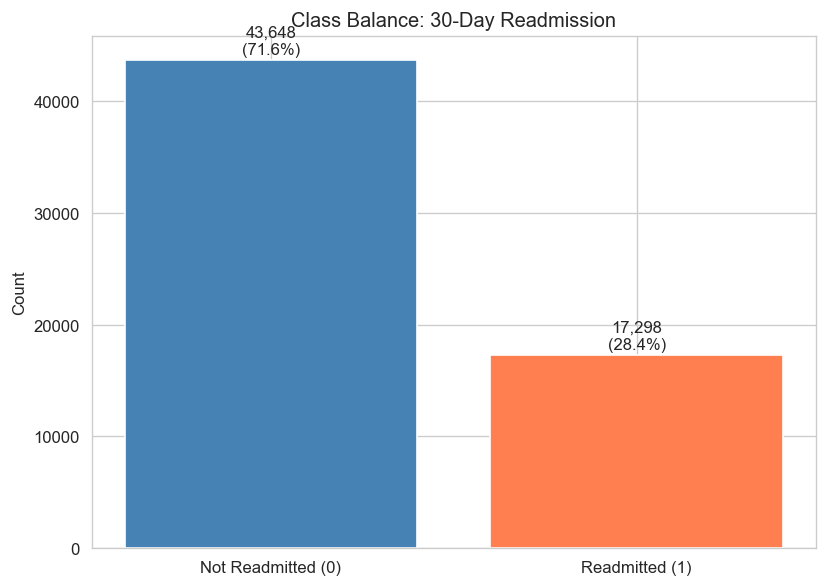

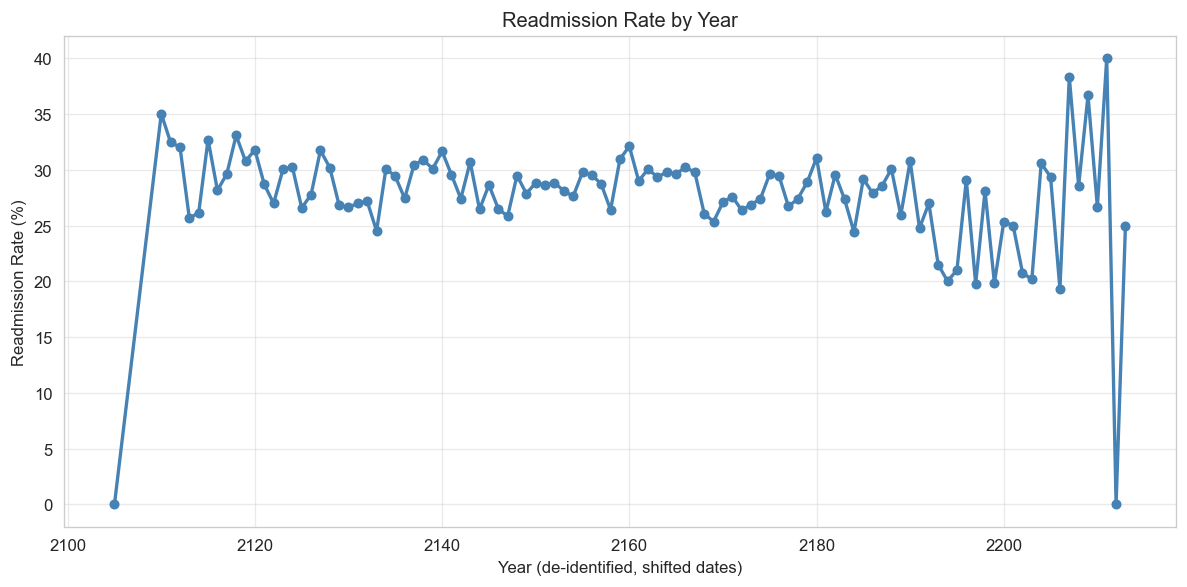

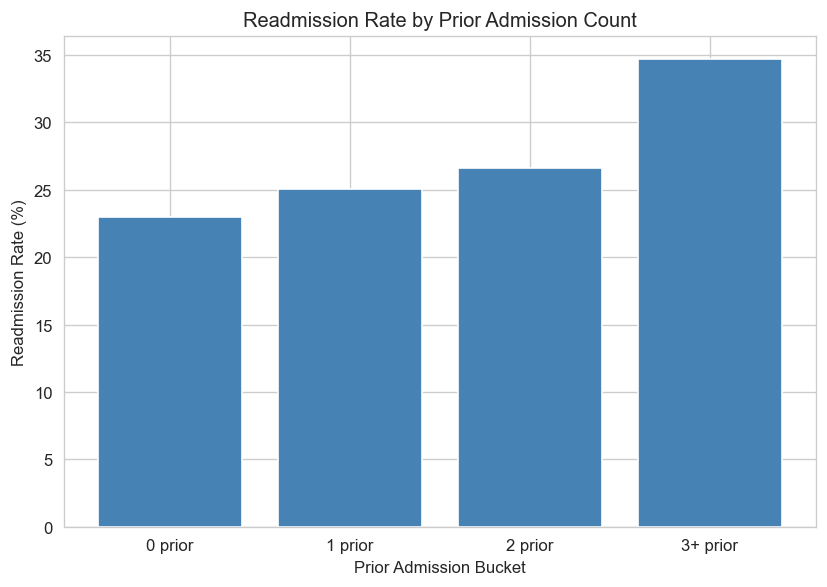

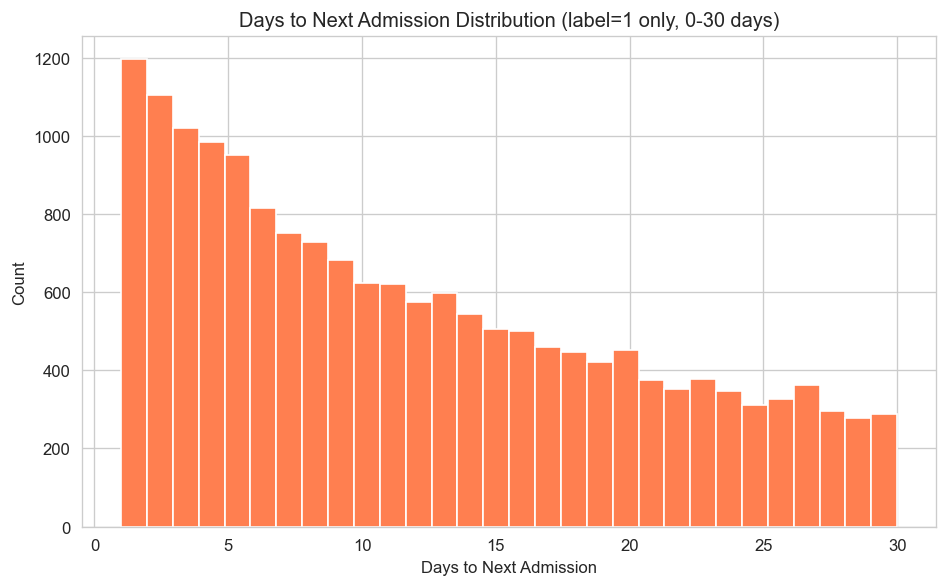

In [13]:
# -- Plot 1: Class balance bar chart
bar_labels = ['Not Readmitted (0)', 'Readmitted (1)']
bar_counts = [neg, pos]
bar_colors = ['steelblue', 'coral']

plt.figure(figsize=(7, 5))
bars = plt.bar(bar_labels, bar_counts, color=bar_colors, edgecolor='white')
for bar, count in zip(bars, bar_counts):
    pct = count / total * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.005,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=10
    )
plt.title('Class Balance: 30-Day Readmission')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# -- Plot 2: Readmission rate by year (line chart with markers)
plt.figure(figsize=(10, 5))
plt.plot(
    year_rate.index, year_rate.values,
    marker='o', color='steelblue', linewidth=2, markersize=5
)
plt.title('Readmission Rate by Year')
plt.xlabel('Year (de-identified, shifted dates)')
plt.ylabel('Readmission Rate (%)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# -- Plot 3: Readmission rate by prior admission count
plt.figure(figsize=(7, 5))
plt.bar(
    rate_by_prior.index, rate_by_prior.values,
    color='steelblue', edgecolor='white'
)
plt.title('Readmission Rate by Prior Admission Count')
plt.xlabel('Prior Admission Bucket')
plt.ylabel('Readmission Rate (%)')

rates_vals = rate_by_prior.values
is_monotone = all(
    rates_vals[i] <= rates_vals[i + 1]
    for i in range(len(rates_vals) - 1)
    if not (np.isnan(rates_vals[i]) or np.isnan(rates_vals[i + 1]))
)
if not is_monotone:
    plt.gcf().text(
        0.5, 0.01,
        'NOTE: Rate not monotonically increasing -- possible data quality concern',
        ha='center', fontsize=8, color='red'
    )
plt.tight_layout()
plt.show()

# -- Plot 4: Days to next admission for readmitted rows (label=1 only)
readmitted_rows = df_labeled[df_labeled['readmitted_30d'] == 1]
plt.figure(figsize=(8, 5))
plt.hist(readmitted_rows['days_to_next'], bins=30, color='coral', edgecolor='white')
plt.title('Days to Next Admission Distribution (label=1 only, 0-30 days)')
plt.xlabel('Days to Next Admission')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 3E: Checkpoint
- Total usable admissions: 60,946 rows x 31 columns
- Readmission rate: 28.4%
- Positive cases: 17,298
- Negative cases: 43,648
- Ready for EDA in Section 4

## Section 4: Full Exploratory Data Analysis

All plots are inline. No transformations applied yet.
This section explores raw relationships to guide preprocessing decisions.

### 4A: Target Variable Analysis

df_labeled columns: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod', 'is_planned', 'age_group', 'next_admittime', 'next_is_planned', 'days_to_next', 'is_last_admission', 'readmitted_30d', 'year', 'prior_admissions_count', 'prior_bucket']
df_labeled shape: (60946, 31)

Overall readmission rate: 28.4%
Positive cases (label=1): 17,298
Negative cases (label=0): 43,648



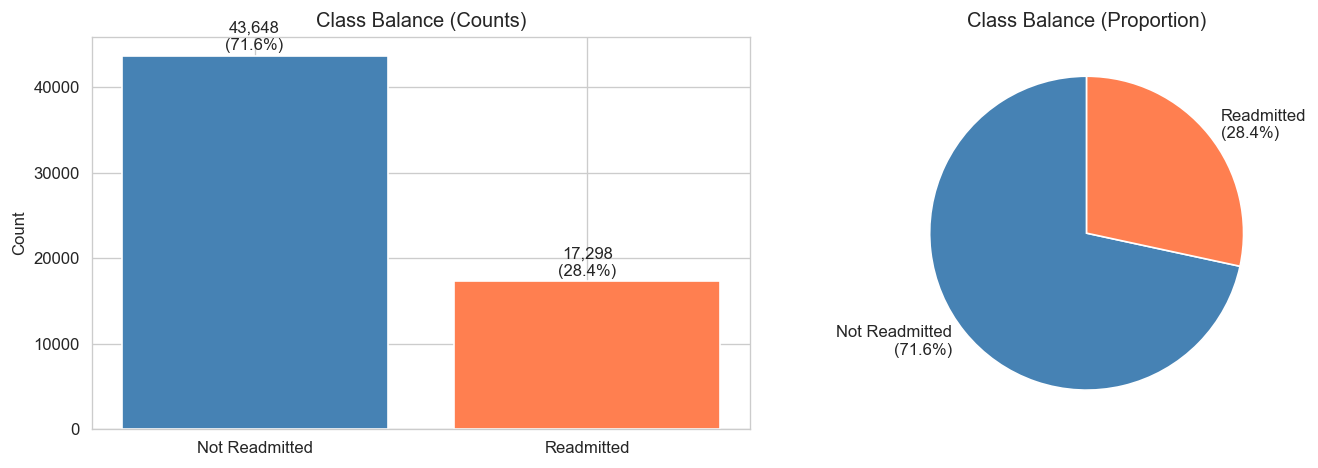

In [14]:
print('df_labeled columns:', df_labeled.columns.tolist())
print('df_labeled shape:', df_labeled.shape)
print()

total = len(df_labeled)
pos   = int((df_labeled['readmitted_30d'] == 1).sum())
neg   = int((df_labeled['readmitted_30d'] == 0).sum())
rate  = pos / total * 100

print(f'Overall readmission rate: {rate:.1f}%')
print(f'Positive cases (label=1): {pos:,}')
print(f'Negative cases (label=0): {neg:,}')
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bar_labels = ['Not Readmitted', 'Readmitted']
bar_counts = [neg, pos]
bar_colors = ['steelblue', 'coral']
bars = axes[0].bar(bar_labels, bar_counts, color=bar_colors, edgecolor='white')
for bar, count in zip(bars, bar_counts):
    pct = count / total * 100
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.005,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=10
    )
axes[0].set_title('Class Balance (Counts)')
axes[0].set_ylabel('Count')

pie_labels = [
    f'Not Readmitted\n({neg / total * 100:.1f}%)',
    f'Readmitted\n({pos / total * 100:.1f}%)'
]
axes[1].pie(
    [neg, pos], labels=pie_labels,
    colors=bar_colors, startangle=90,
    wedgeprops={'edgecolor': 'white'}
)
axes[1].set_title('Class Balance (Proportion)')

plt.tight_layout()
plt.show()

### 4B: Numeric Feature Distributions (Before Any Transformation)

Reading raw distributions to decide winsorization thresholds. 
Observe skewness, outliers, and differences by readmission status.

In [15]:
if 'los_days' not in df_labeled.columns:
    df_labeled['los_days'] = (
        df_labeled['dischtime'] - df_labeled['admittime']
    ).dt.days
    print('Computed los_days')
else:
    print('los_days already present')

if 'came_via_ed' not in df_labeled.columns:
    df_labeled['came_via_ed'] = df_labeled['edregtime'].notna().astype(int)
    print('Computed came_via_ed')
else:
    print('came_via_ed already present')

numeric_cols = ['anchor_age', 'los_days', 'prior_admissions_count']
print()
print('Descriptive statistics:')
print(df_labeled[numeric_cols].describe().round(2).to_string())
print()
print('Skewness:')
print(df_labeled[numeric_cols].skew().round(3).to_string())

Computed los_days
Computed came_via_ed

Descriptive statistics:
       anchor_age  los_days  prior_admissions_count
count    60946.00  60946.00                60946.00
mean        58.05      4.23                    4.03
std         17.75      6.86                    7.21
min         18.00     -1.00                    0.00
25%         46.00      1.00                    0.00
50%         59.00      2.00                    2.00
75%         71.00      5.00                    5.00
max         91.00    295.00                   97.00

Skewness:
anchor_age               -0.250
los_days                  7.561
prior_admissions_count    4.524


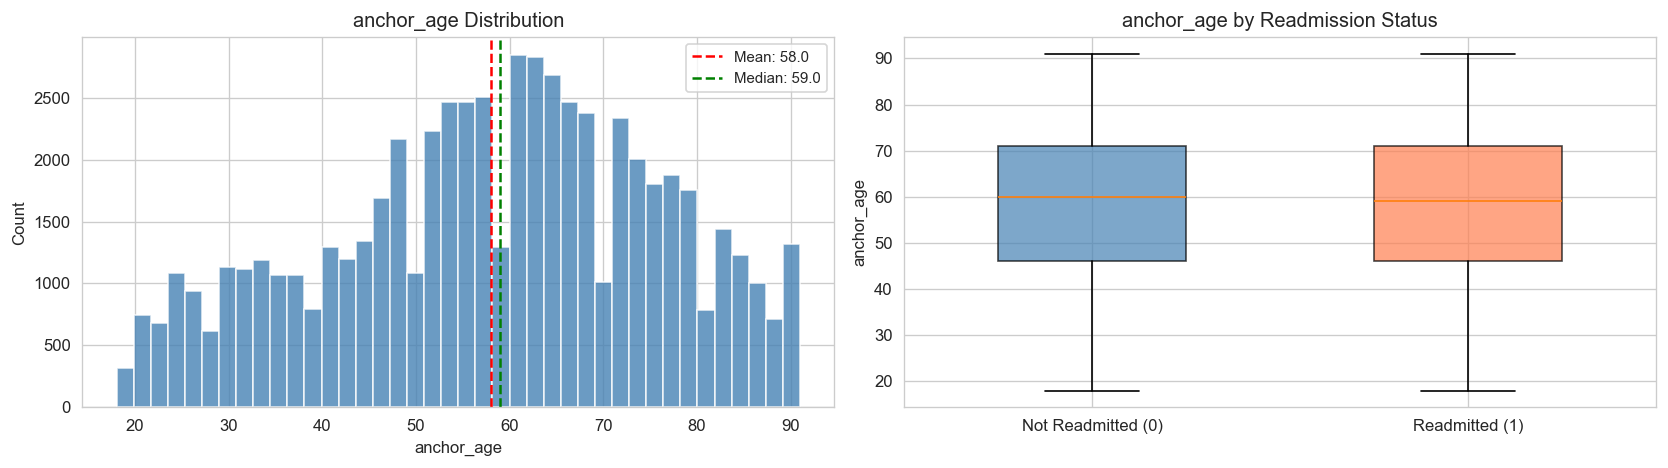

anchor_age: mean=58.0, median=59.0, skewness=-0.25, 95th pct=85.0, 99th pct=91.0, max=91.0



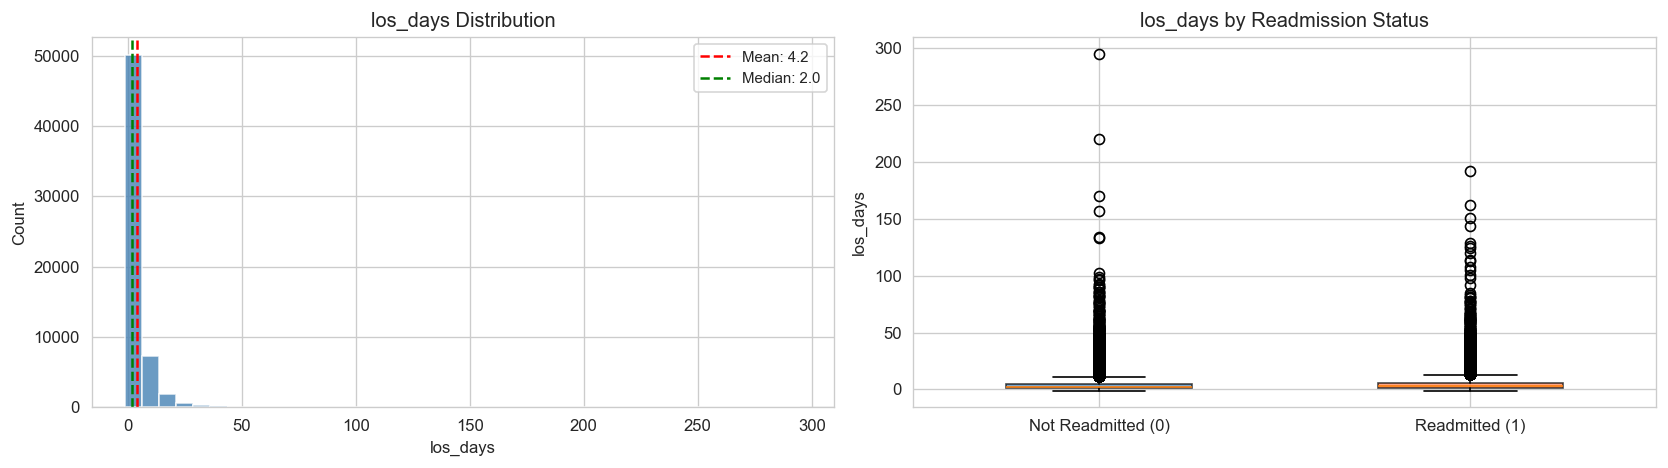

los_days: mean=4.2, median=2.0, skewness=7.56, 95th pct=14.0, 99th pct=32.0, max=295.0



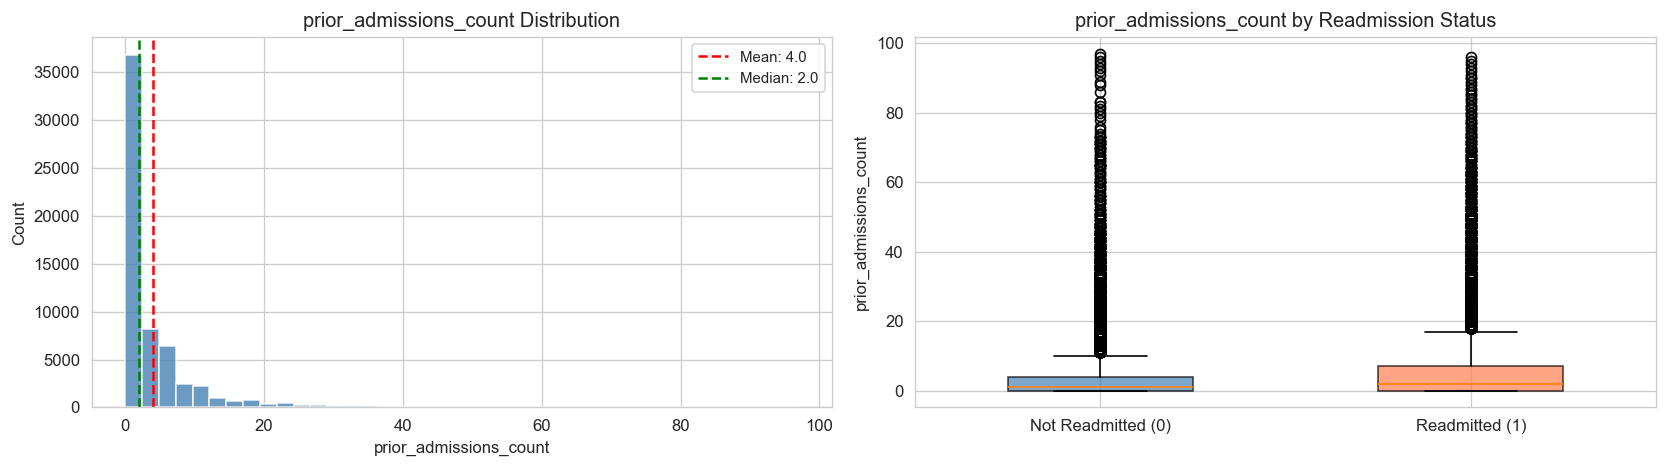

prior_admissions_count: mean=4.0, median=2.0, skewness=4.52, 95th pct=16.0, 99th pct=35.0, max=97.0



In [16]:
numeric_cols = ['anchor_age', 'los_days', 'prior_admissions_count']

for col in numeric_cols:
    col_data   = df_labeled[col].dropna()
    col_mean   = float(col_data.mean())
    col_median = float(col_data.median())
    col_skew   = float(col_data.skew())
    col_p95    = float(col_data.quantile(0.95))
    col_p99    = float(col_data.quantile(0.99))
    col_max    = float(col_data.max())

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(col_data, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0].axvline(col_mean,   color='red',   linestyle='--', linewidth=1.5,
                    label=f'Mean: {col_mean:.1f}')
    axes[0].axvline(col_median, color='green', linestyle='--', linewidth=1.5,
                    label=f'Median: {col_median:.1f}')
    axes[0].legend(fontsize=9)
    axes[0].set_title(f'{col} Distribution')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')

    group0 = df_labeled.loc[df_labeled['readmitted_30d'] == 0, col].dropna().values
    group1 = df_labeled.loc[df_labeled['readmitted_30d'] == 1, col].dropna().values
    bp = axes[1].boxplot([group0, group1], patch_artist=True, widths=0.5)
    for patch, color in zip(bp['boxes'], ['steelblue', 'coral']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[1].set_xticks([1, 2])
    axes[1].set_xticklabels(['Not Readmitted (0)', 'Readmitted (1)'])
    axes[1].set_title(f'{col} by Readmission Status')
    axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

    print(
        f'{col}: mean={col_mean:.1f}, median={col_median:.1f}, '
        f'skewness={col_skew:.2f}, 95th pct={col_p95:.1f}, '
        f'99th pct={col_p99:.1f}, max={col_max:.1f}'
    )
    print()

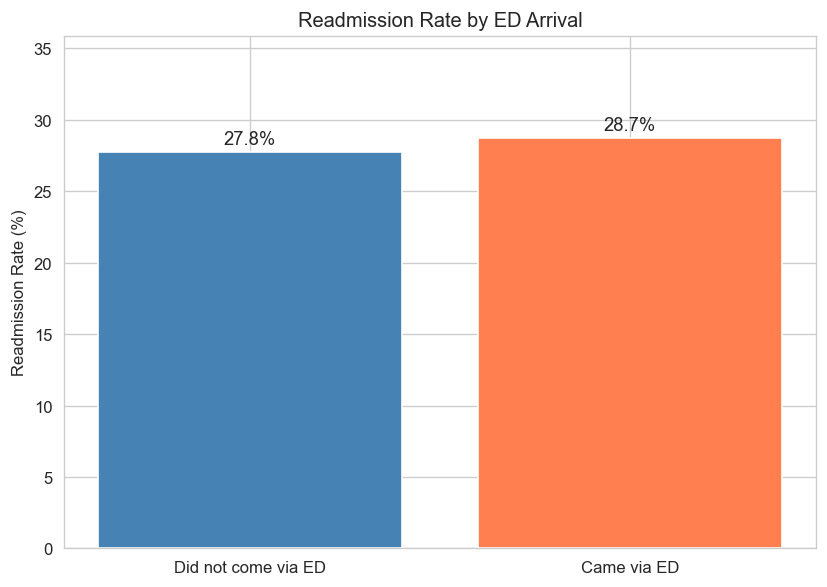

In [17]:
ed_rate   = df_labeled.groupby('came_via_ed')['readmitted_30d'].mean() * 100
ed_labels = ['Did not come via ED', 'Came via ED']
ed_vals   = [float(ed_rate.get(0, 0.0)), float(ed_rate.get(1, 0.0))]

plt.figure(figsize=(7, 5))
bars = plt.bar(ed_labels, ed_vals, color=['steelblue', 'coral'], edgecolor='white')
for bar, val in zip(bars, ed_vals):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', va='bottom', fontsize=11
    )
plt.title('Readmission Rate by ED Arrival')
plt.ylabel('Readmission Rate (%)')
plt.ylim(0, max(ed_vals) * 1.25)
plt.tight_layout()
plt.show()

### 4C: Categorical Features vs Readmission Rate

Each bar shows the readmission rate for that category.
Sorted highest to lowest. This is the fairness audit foundation.

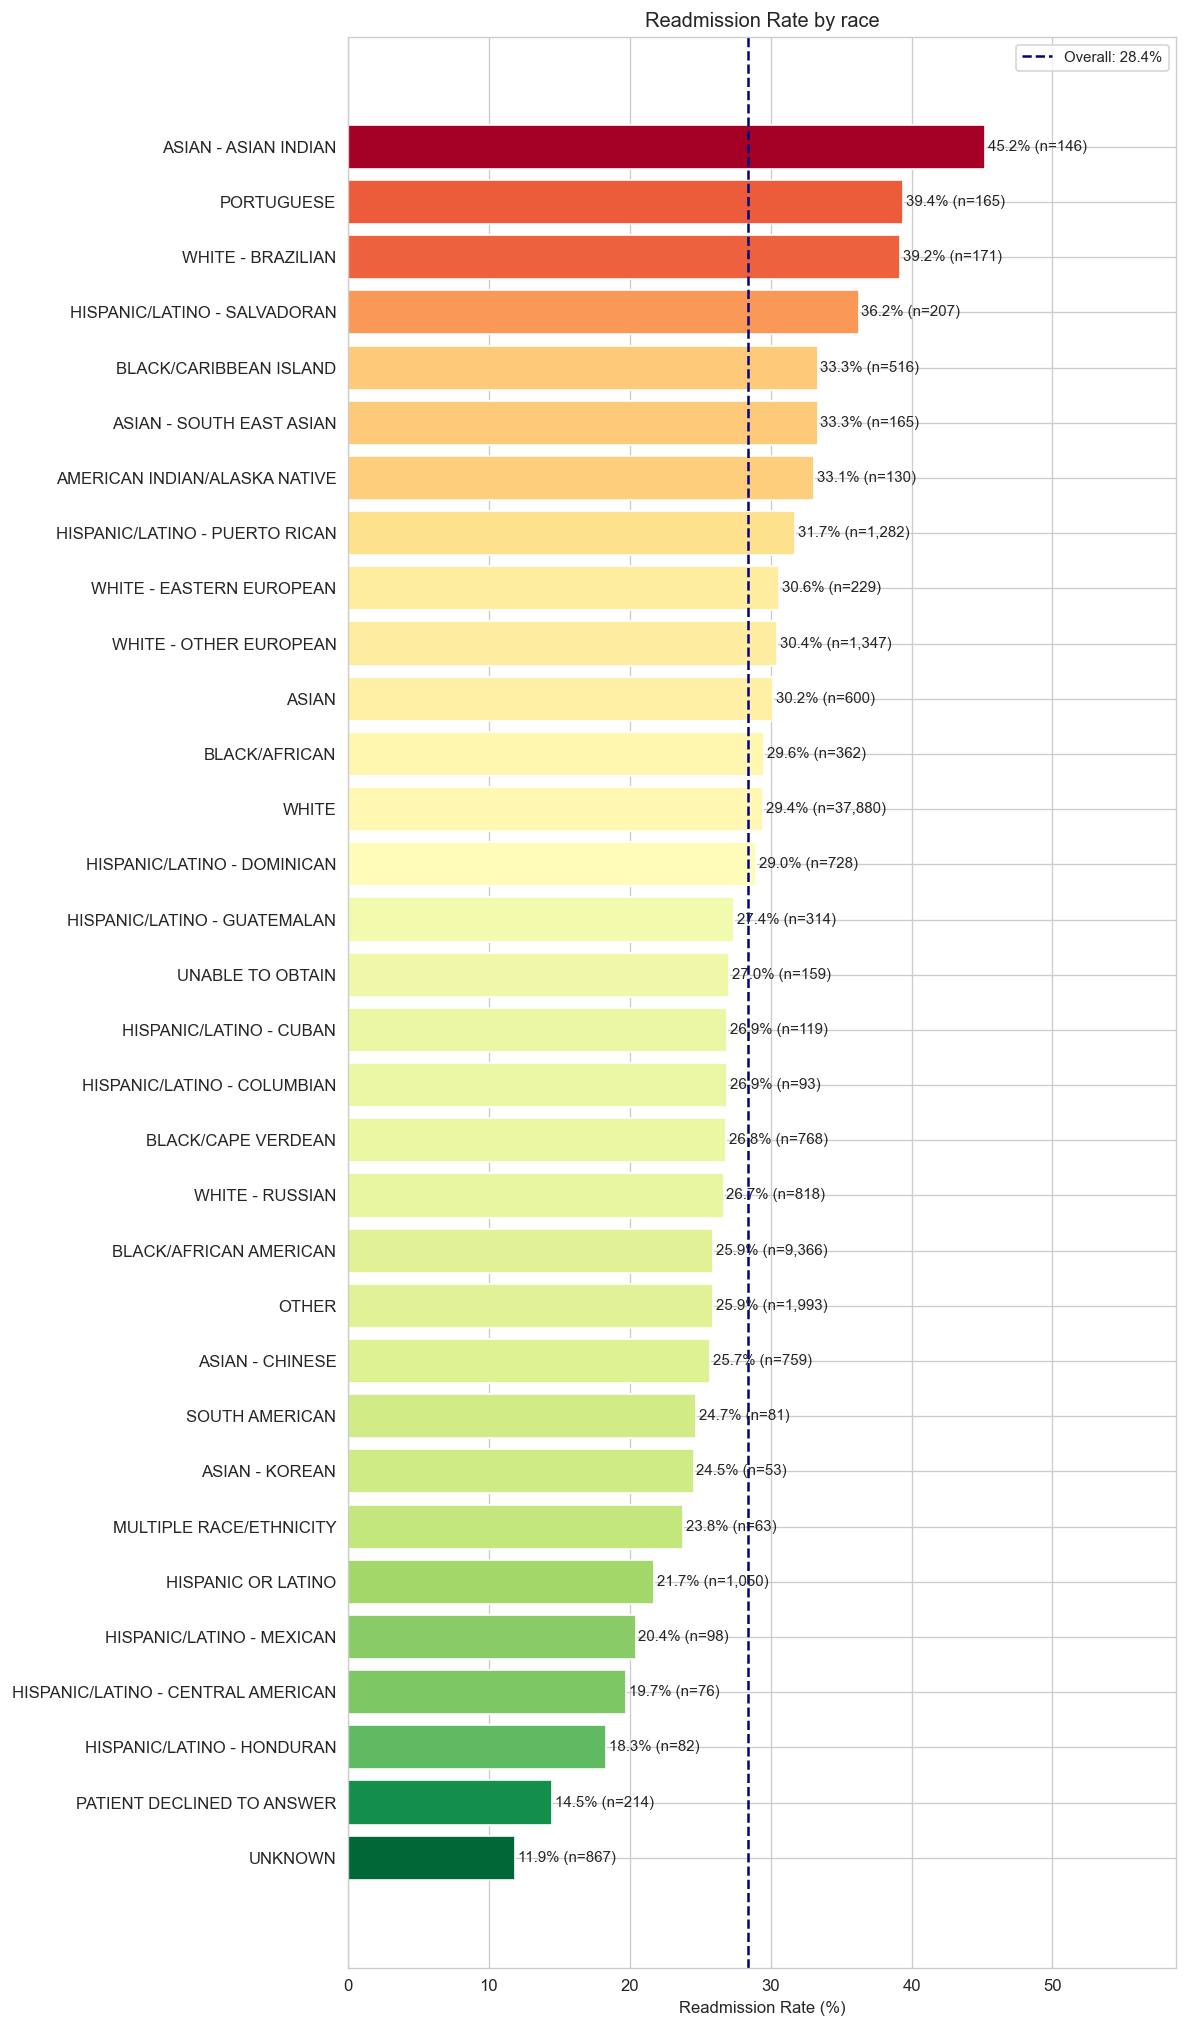

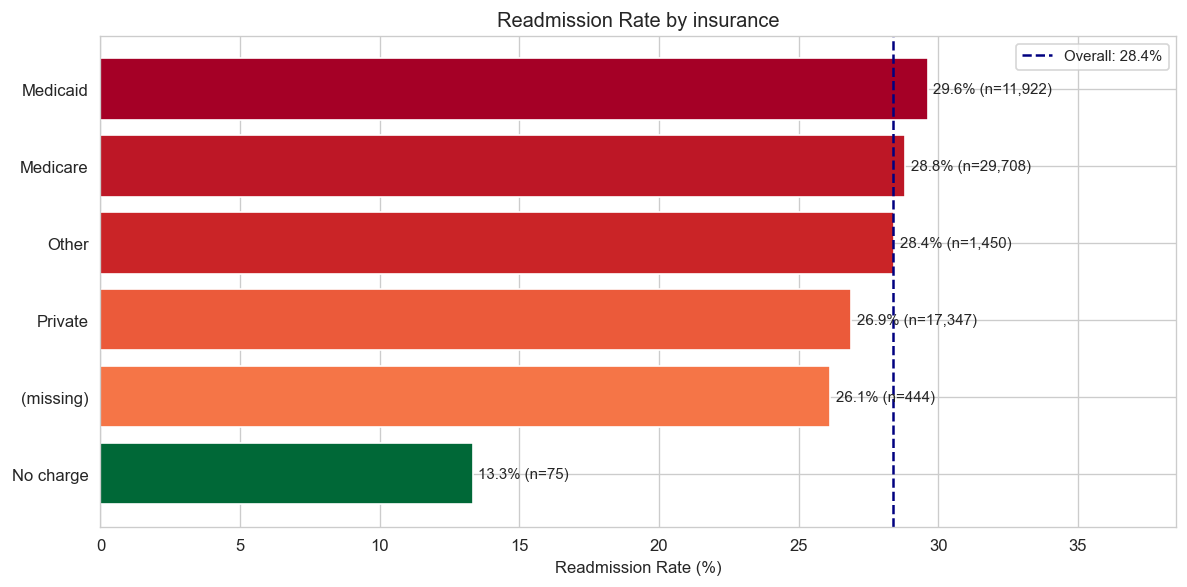

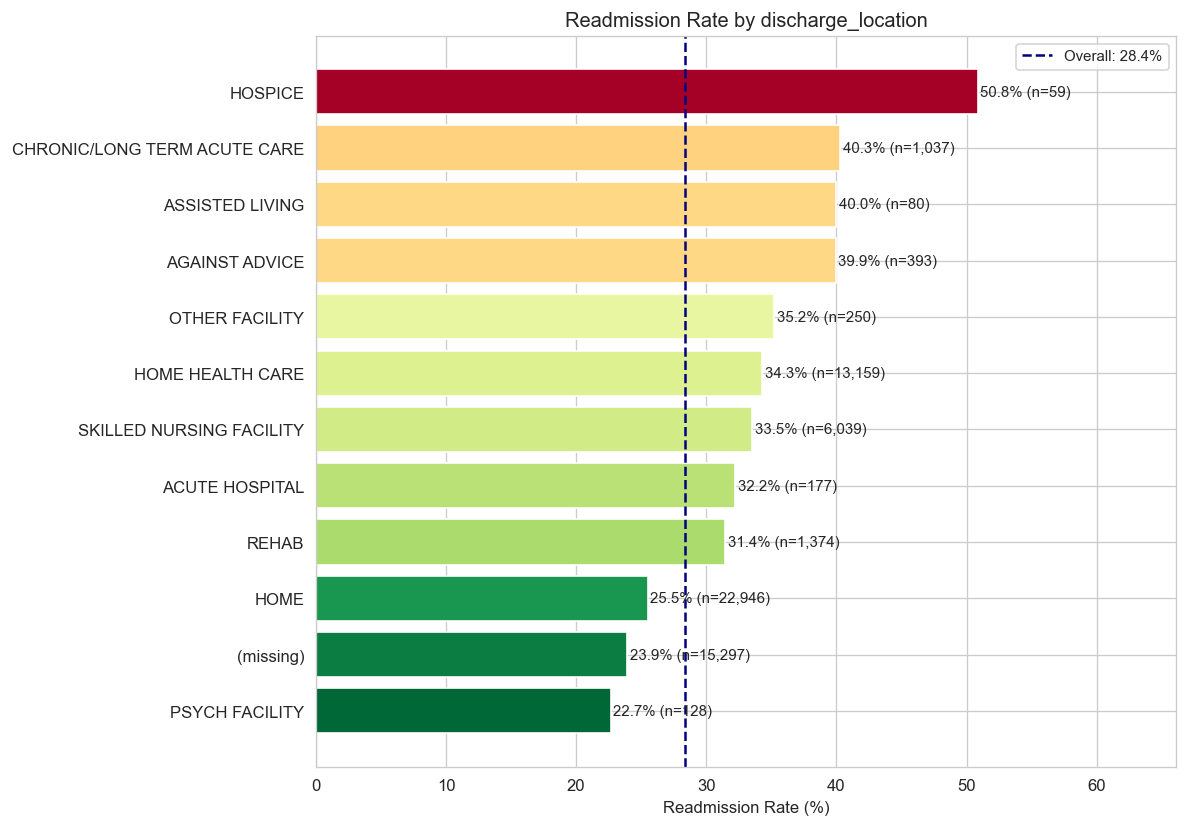

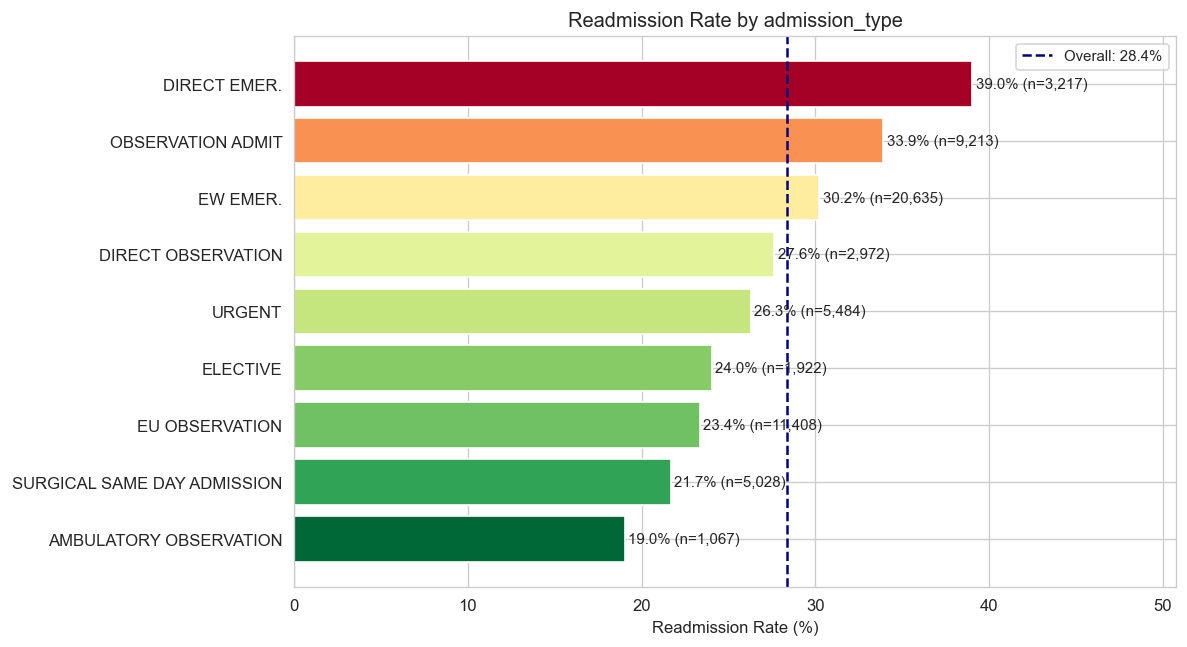

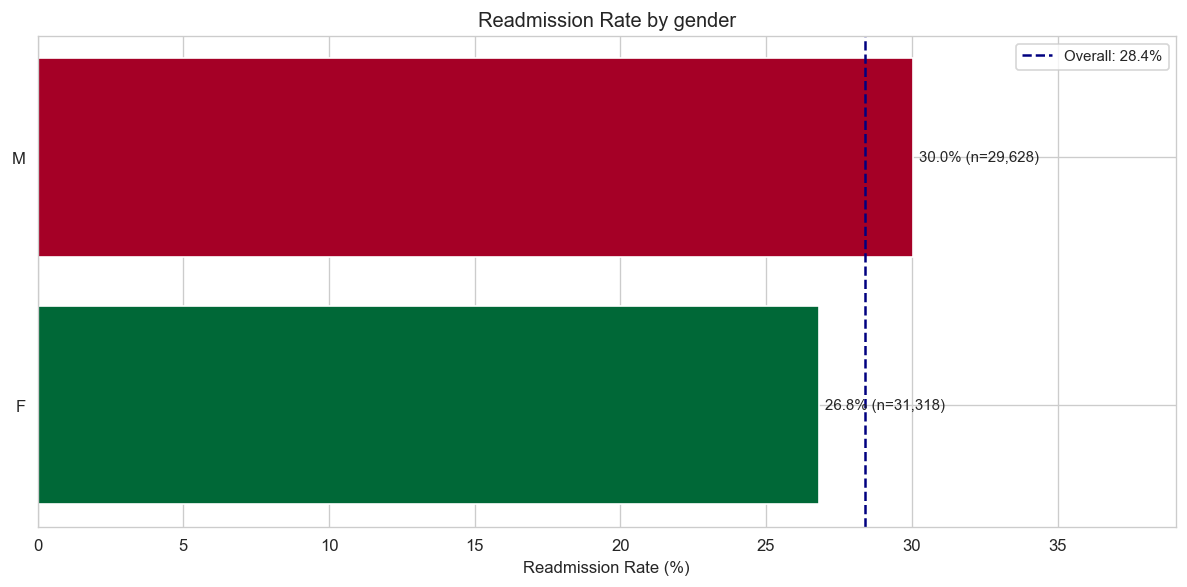

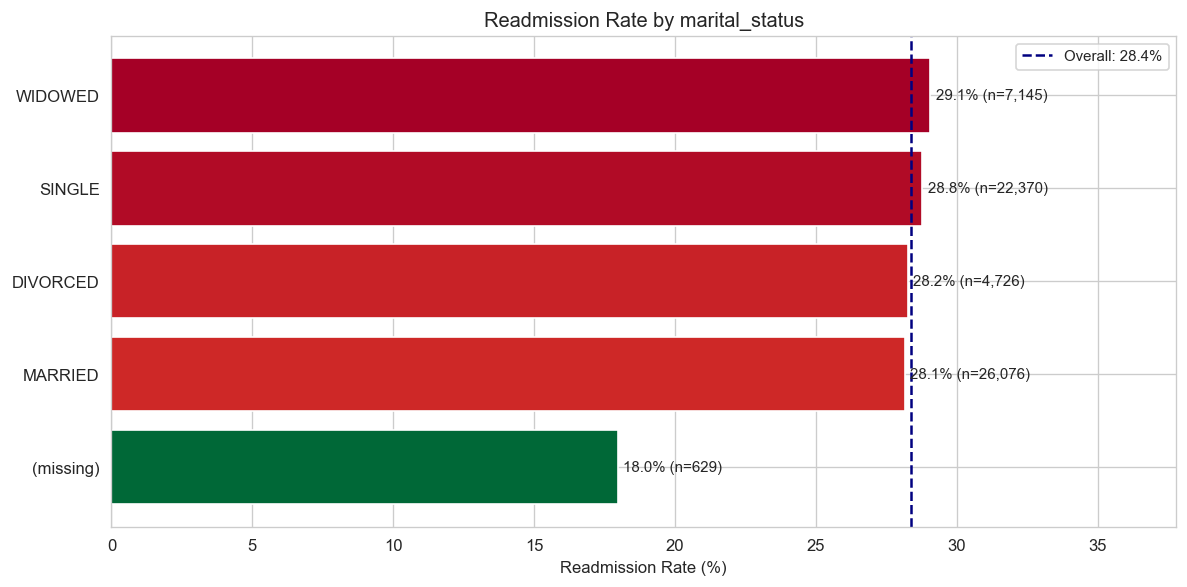


Summary: Highest vs Lowest Readmission Rate by Feature
Feature                High Category                    Rate  Low Category                     Rate     Gap
-----------------------------------------------------------------------------------------------------------
race                   ASIAN - ASIAN INDIAN            45.2%  UNKNOWN                         11.9%   33.3%
insurance              Medicaid                        29.6%  No charge                       13.3%   16.3%
discharge_location     HOSPICE                         50.8%  PSYCH FACILITY                  22.7%   28.2%
admission_type         DIRECT EMER.                    39.0%  AMBULATORY OBSERVATION          19.0%   20.0%
gender                 M                               30.0%  F                               26.8%    3.2%
marital_status         WIDOWED                         29.1%  (missing)                       18.0%   11.1%


In [18]:
import matplotlib.colors as mcolors

cat_features = [
    'race', 'insurance', 'discharge_location',
    'admission_type', 'gender', 'marital_status'
]

overall_rate = df_labeled['readmitted_30d'].mean() * 100
summary_rows = []

for feat in cat_features:
    group  = df_labeled.groupby(feat, dropna=False)['readmitted_30d']
    rates  = (group.mean() * 100).rename('rate')
    counts = group.count().rename('count')
    stats  = pd.concat([rates, counts], axis=1).reset_index()
    stats.columns = ['category', 'rate', 'count']
    stats['category'] = stats['category'].fillna('(missing)').astype(str)
    stats = stats[stats['count'] >= 50].sort_values('rate', ascending=False)

    if stats.empty:
        print(f'{feat}: no categories with count >= 50')
        continue

    cmap   = plt.cm.RdYlGn_r
    norm   = mcolors.Normalize(
        vmin=stats['rate'].min(), vmax=stats['rate'].max()
    )
    colors = [cmap(norm(r)) for r in stats['rate']]

    fig, ax = plt.subplots(figsize=(10, max(5, len(stats) * 0.5 + 1)))
    bars    = ax.barh(stats['category'], stats['rate'], color=colors)

    for bar, (_, row) in zip(bars, stats.iterrows()):
        ax.text(
            bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f'{row["rate"]:.1f}% (n={row["count"]:,})',
            va='center', fontsize=9
        )

    ax.axvline(overall_rate, color='navy', linestyle='--', linewidth=1.5,
               label=f'Overall: {overall_rate:.1f}%')
    ax.legend(fontsize=9)
    ax.set_title(f'Readmission Rate by {feat}')
    ax.set_xlabel('Readmission Rate (%)')
    ax.set_xlim(0, stats['rate'].max() * 1.3)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    highest = stats.iloc[0]
    lowest  = stats.iloc[-1]
    summary_rows.append({
        'feature':      feat,
        'highest_cat':  str(highest['category']),
        'highest_rate': round(float(highest['rate']), 1),
        'lowest_cat':   str(lowest['category']),
        'lowest_rate':  round(float(lowest['rate']), 1),
        'gap_pct':      round(float(highest['rate'] - lowest['rate']), 1)
    })

print()
print('Summary: Highest vs Lowest Readmission Rate by Feature')
hdr = f'{"Feature":<22} {"High Category":<30} {"Rate":>6}  {"Low Category":<30} {"Rate":>6}  {"Gap":>6}'
print(hdr)
print('-' * len(hdr))
for row in summary_rows:
    print(
        f'{row["feature"]:<22} {row["highest_cat"]:<30} '
        f'{row["highest_rate"]:>5.1f}%  {row["lowest_cat"]:<30} '
        f'{row["lowest_rate"]:>5.1f}%  {row["gap_pct"]:>5.1f}%'
    )

### 4D: Correlation Analysis

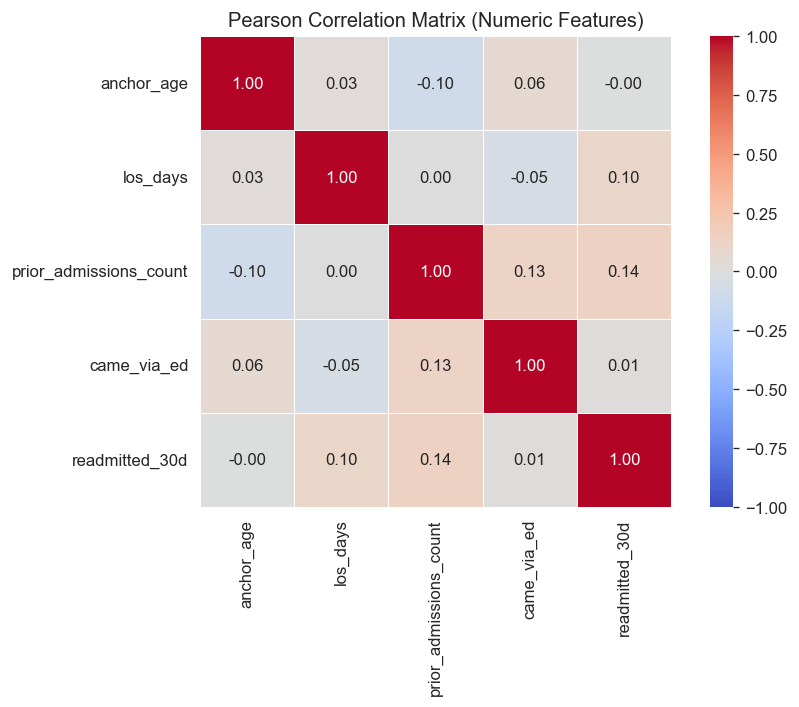

In [19]:
corr_cols = [
    'anchor_age', 'los_days', 'prior_admissions_count',
    'came_via_ed', 'readmitted_30d'
]

if 'los_days' not in df_labeled.columns:
    df_labeled['los_days'] = (
        df_labeled['dischtime'] - df_labeled['admittime']
    ).dt.days
if 'came_via_ed' not in df_labeled.columns:
    df_labeled['came_via_ed'] = df_labeled['edregtime'].notna().astype(int)

corr_matrix = df_labeled[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True
)
plt.title('Pearson Correlation Matrix (Numeric Features)')
plt.tight_layout()
plt.show()

Point-Biserial Correlation with Readmission Label:
Feature                       Correlation        p-value  Significant
----------------------------------------------------------------------
prior_admissions_count             0.1387    2.9226e-259        Yes *
los_days                           0.1045    1.1969e-147        Yes *
came_via_ed                        0.0098     1.5300e-02        Yes *
anchor_age                        -0.0043     2.8485e-01           No



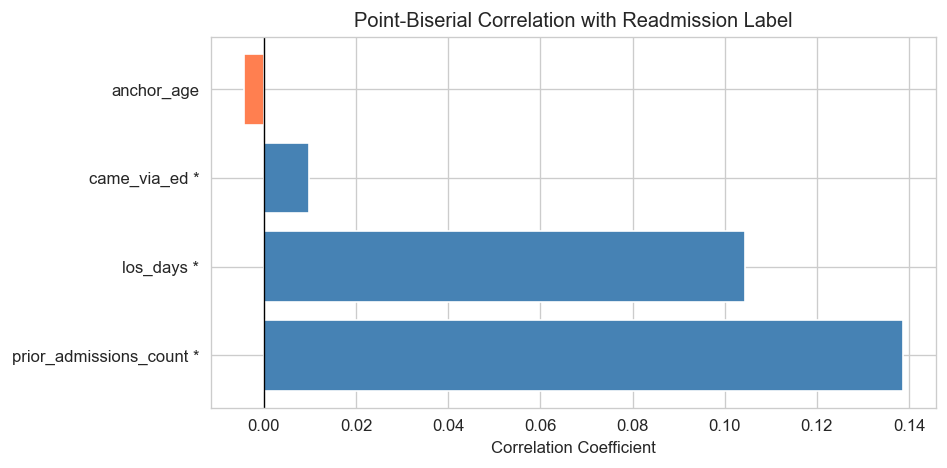

In [20]:
from scipy.stats import pointbiserialr

numeric_features = ['anchor_age', 'los_days', 'prior_admissions_count', 'came_via_ed']
target           = df_labeled['readmitted_30d']

pb_results = []
for feat in numeric_features:
    feat_vals  = df_labeled[feat].dropna()
    tgt_vals   = target.loc[feat_vals.index]
    corr, pval = pointbiserialr(feat_vals, tgt_vals)
    pb_results.append({
        'feature':     feat,
        'correlation': round(float(corr), 4),
        'p_value':     float(pval),
        'significant': bool(pval < 0.05)
    })

pb_df = pd.DataFrame(pb_results)
pb_df['abs_corr'] = pb_df['correlation'].abs()
pb_df = pb_df.sort_values('abs_corr', ascending=False).drop(columns='abs_corr')

print('Point-Biserial Correlation with Readmission Label:')
print(f'{"Feature":<28} {"Correlation":>12} {"p-value":>14} {"Significant":>12}')
print('-' * 70)
for _, row in pb_df.iterrows():
    sig = 'Yes *' if row['significant'] else 'No'
    print(f'{row["feature"]:<28} {row["correlation"]:>12.4f} {row["p_value"]:>14.4e} {sig:>12}')
print()

bar_colors_pb = ['steelblue' if c >= 0 else 'coral' for c in pb_df['correlation']]
labels_pb = [
    f'{r["feature"]} *' if r['significant'] else r['feature']
    for _, r in pb_df.iterrows()
]

plt.figure(figsize=(8, 4))
plt.barh(labels_pb, pb_df['correlation'], color=bar_colors_pb, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Point-Biserial Correlation with Readmission Label')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

### 4E: Missing Value Analysis

Columns with missing values:
Column                            Missing Count  Missing %
------------------------------------------------------------
deathtime                                60,946    100.00%
dod                                      41,211     67.62%
edregtime                                20,465     33.58%
edouttime                                20,465     33.58%
discharge_location                       15,297     25.10%
marital_status                              629      1.03%
insurance                                   444      0.73%
language                                     30      0.05%



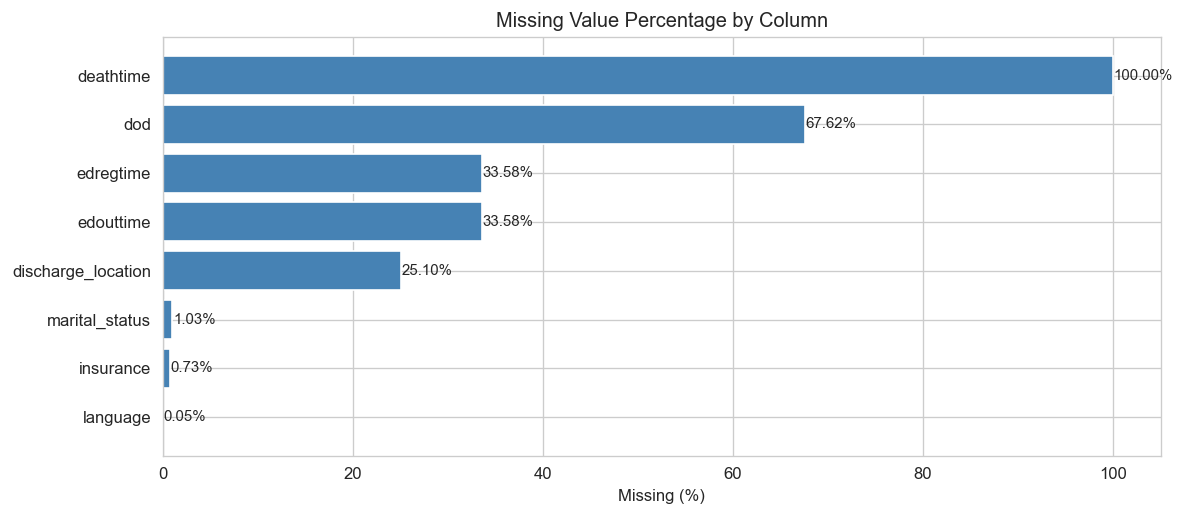

Missingness correlation with readmission (discharge_location):
  Missing:     23.9% readmission rate
  Not missing: 29.9% readmission rate
  Chi-square:  198.06  (df=1)
  p-value:     0.0000
  Conclusion: Significant -- missingness IS correlated with readmission



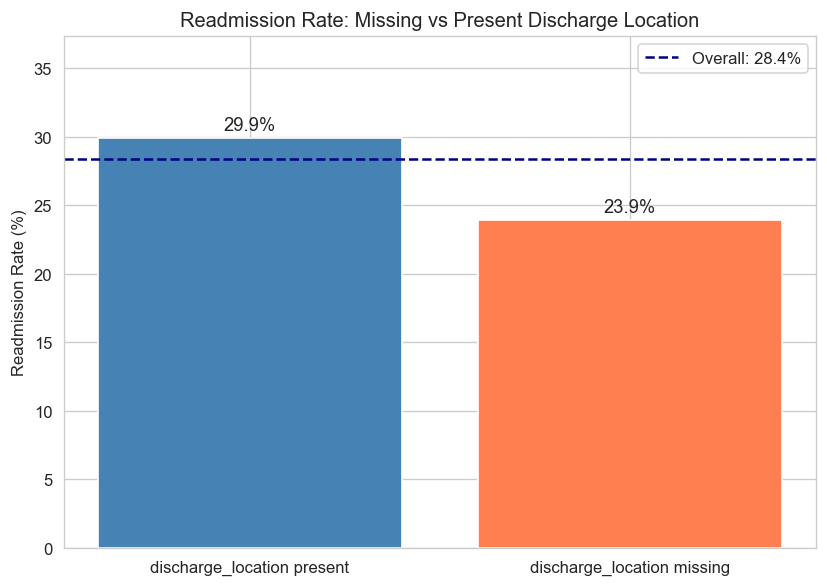

In [21]:
from scipy.stats import chi2_contingency

overall_rate_e = df_labeled['readmitted_30d'].mean() * 100
total_rows     = len(df_labeled)
missing        = df_labeled.isnull().sum()
missing        = missing[missing > 0].sort_values(ascending=False)
missing_pct    = (missing / total_rows * 100).round(2)

print('Columns with missing values:')
print(f'{"Column":<32} {"Missing Count":>14} {"Missing %":>10}')
print('-' * 60)
for col in missing.index:
    print(f'{col:<32} {missing[col]:>14,} {missing_pct[col]:>9.2f}%')
print()

if len(missing) > 0:
    plt.figure(figsize=(10, max(4, len(missing) * 0.55)))
    plt.barh(
        missing.index[::-1],
        missing_pct.values[::-1],
        color='steelblue', edgecolor='white'
    )
    for i, (col, pct) in enumerate(
        zip(missing.index[::-1], missing_pct.values[::-1])
    ):
        plt.text(pct + 0.05, i, f'{pct:.2f}%', va='center', fontsize=9)
    plt.title('Missing Value Percentage by Column')
    plt.xlabel('Missing (%)')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found in df_labeled.')

df_labeled['discharge_location_missing'] = (
    df_labeled['discharge_location'].isna().astype(int)
)

rate_missing = float(
    df_labeled.loc[
        df_labeled['discharge_location_missing'] == 1, 'readmitted_30d'
    ].mean() * 100
)
rate_present = float(
    df_labeled.loc[
        df_labeled['discharge_location_missing'] == 0, 'readmitted_30d'
    ].mean() * 100
)

ct = pd.crosstab(
    df_labeled['discharge_location_missing'],
    df_labeled['readmitted_30d']
)
chi2, p, dof, _ = chi2_contingency(ct)
is_sig = bool(p < 0.05)

print('Missingness correlation with readmission (discharge_location):')
print(f'  Missing:     {rate_missing:.1f}% readmission rate')
print(f'  Not missing: {rate_present:.1f}% readmission rate')
print(f'  Chi-square:  {chi2:.2f}  (df={dof})')
print(f'  p-value:     {p:.4f}')
print(
    f'  Conclusion: {"Significant" if is_sig else "Not significant"} -- '
    f'missingness {"IS" if is_sig else "is NOT"} correlated with readmission'
)
print()

bar_labels2 = ['discharge_location present', 'discharge_location missing']
bar_vals2   = [rate_present, rate_missing]

plt.figure(figsize=(7, 5))
bars2 = plt.bar(bar_labels2, bar_vals2, color=['steelblue', 'coral'], edgecolor='white')
for bar, val in zip(bars2, bar_vals2):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', va='bottom', fontsize=11
    )
plt.axhline(overall_rate_e, color='navy', linestyle='--',
            label=f'Overall: {overall_rate_e:.1f}%')
plt.legend()
plt.title('Readmission Rate: Missing vs Present Discharge Location')
plt.ylabel('Readmission Rate (%)')
plt.ylim(0, max(bar_vals2) * 1.25)
plt.tight_layout()
plt.show()

### 4E Complete

Missing value analysis confirms (fill in from cell output above after running):
- discharge_location: X% missing
- marital_status: X% missing
- insurance: X% missing

Strategy for Section 6 (preprocessing):
- Create `discharge_location_missing` and `marital_status_missing` indicator flags
  (chi-square test above confirms whether missingness is informative)
- Fill remaining NaN with `(missing)` category label before one-hot encoding

Section 4F (ICD/CCSR vs Readmission) will run after Section 5 builds the CCSR features.

## Section 4F: Chi-Square and Cramer's V Feature Association Audit

Chi-square checks whether a categorical feature is associated with `readmitted_30d`. Cramer's V gives an effect size, meaning how strong the association is. This audit is for EDA and hypothesis testing, not final feature selection. Any future feature selection based on this kind of test should be done on the training set only to avoid leakage.

In [22]:
print("\n" + "="*80)
print("SECTION 4F-1: CHI-SQUARE HELPER FUNCTIONS")
print("="*80)

from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def cramers_v(contingency_table):
    """
    Compute Cramer's V effect size for a chi-square contingency table.
    """
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    denominator = n * (min(k - 1, r - 1))
    
    if denominator == 0:
        return np.nan
    
    return np.sqrt(chi2 / denominator)


def run_chi_square_feature(df, feature, target="readmitted_30d", min_count=50):
    """
    Run chi-square test and Cramer's V for one categorical/binary feature.
    This function uses a local copy only and does not modify df_labeled.
    """
    if feature not in df.columns:
        return None
    
    if target not in df.columns:
        return None
    
    temp = df[[feature, target]].copy()
    temp = temp[temp[target].notna()].copy()
    temp[target] = temp[target].astype(int)
    
    # SAFE FIX:
    # Convert to object/string BEFORE handling missing values.
    # This avoids pandas Categorical errors when adding "MISSING".
    temp[feature] = temp[feature].astype("object")
    temp[feature] = temp[feature].where(temp[feature].notna(), "MISSING")
    temp[feature] = temp[feature].astype(str)
    
    # Group rare categories to avoid unstable tiny groups
    category_counts = temp[feature].value_counts()
    rare_categories = category_counts[category_counts < min_count].index
    temp[feature] = temp[feature].replace(rare_categories, "RARE_OR_SMALL_GROUP")
    
    # Build contingency table
    contingency = pd.crosstab(temp[feature], temp[target])
    
    # Need both target classes 0 and 1
    if contingency.shape[1] < 2:
        return None
    
    # Make sure both columns exist
    if 0 not in contingency.columns:
        contingency[0] = 0
    if 1 not in contingency.columns:
        contingency[1] = 0
    
    contingency = contingency[[0, 1]]
    
    # If feature has only one category after rare grouping, skip it
    if contingency.shape[0] < 2:
        return None
    
    # Run chi-square
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    cv = cramers_v(contingency)
    
    # Readmission rate by category
    category_summary = temp.groupby(feature)[target].agg(["count", "mean"]).reset_index()
    
    min_rate = category_summary["mean"].min()
    max_rate = category_summary["mean"].max()
    rate_gap = max_rate - min_rate
    smallest_category_count = category_summary["count"].min()
    
    return {
        "feature": feature,
        "n_categories": contingency.shape[0],
        "n_rows": len(temp),
        "chi2": chi2,
        "p_value": p_value,
        "cramers_v": cv,
        "min_readmission_rate": min_rate,
        "max_readmission_rate": max_rate,
        "rate_gap": rate_gap,
        "smallest_category_count": smallest_category_count
    }

print("Helper functions loaded successfully.")


SECTION 4F-1: CHI-SQUARE HELPER FUNCTIONS
Helper functions loaded successfully.


In [23]:
print("\n" + "="*80)
print("SECTION 4F-2: RUN CHI-SQUARE FEATURE ASSOCIATION AUDIT")
print("="*80)

df_labeled_original_shape = df_labeled.shape
df_labeled_original_columns = list(df_labeled.columns)
_section4f_outputs_dir = PROJECT_ROOT / 'outputs'
_section4f_outputs_before = {
    p.name: p.stat().st_mtime_ns
    for p in _section4f_outputs_dir.glob('*')
    if p.is_file()
}

chi_df = df_labeled.copy()
chi_df['discharge_location_missing_local'] = chi_df['discharge_location'].isna().astype(int)
chi_df['insurance_missing_local'] = chi_df['insurance'].isna().astype(int)
chi_df['marital_status_missing_local'] = chi_df['marital_status'].isna().astype(int)

candidate_features = [
    'gender',
    'age_group',
    'race',
    'insurance',
    'admission_type',
    'admission_location',
    'discharge_location',
    'language',
    'marital_status',
    'prior_bucket',
    'came_via_ed',
    'discharge_location_missing_local',
    'insurance_missing_local',
    'marital_status_missing_local',
]

audit_features = [feature for feature in candidate_features if feature in chi_df.columns]
print(f"Features available for audit: {len(audit_features)}")
print(audit_features)

results = []
for feature in audit_features:
    result = run_chi_square_feature(chi_df, feature, target='readmitted_30d', min_count=50)
    if result is not None:
        results.append(result)

chi_square_results_df = pd.DataFrame(results)
if not chi_square_results_df.empty:
    chi_square_results_df = chi_square_results_df.sort_values('cramers_v', ascending=False).reset_index(drop=True)

display_cols = [
    'feature',
    'p_value',
    'cramers_v',
    'rate_gap',
    'n_categories',
    'smallest_category_count',
]

print(f"\nNumber of features tested: {len(chi_square_results_df)}")
print("\nFull chi-square and Cramer's V results:")
print(chi_square_results_df[display_cols].to_string(index=False))

print("\nTop 10 features by Cramer's V:")
print(chi_square_results_df.sort_values('cramers_v', ascending=False).head(10)[display_cols].to_string(index=False))

print("\nTop 10 features by readmission-rate gap:")
print(chi_square_results_df.sort_values('rate_gap', ascending=False).head(10)[display_cols].to_string(index=False))



SECTION 4F-2: RUN CHI-SQUARE FEATURE ASSOCIATION AUDIT
Features available for audit: 14
['gender', 'age_group', 'race', 'insurance', 'admission_type', 'admission_location', 'discharge_location', 'language', 'marital_status', 'prior_bucket', 'came_via_ed', 'discharge_location_missing_local', 'insurance_missing_local', 'marital_status_missing_local']

Number of features tested: 14

Full chi-square and Cramer's V results:
                         feature       p_value  cramers_v  rate_gap  n_categories  smallest_category_count
                    prior_bucket 5.806607e-176   0.115515  0.116782             4                     6844
              discharge_location 7.195369e-139   0.106015  0.344866            13                        7
                  admission_type 6.857754e-142   0.105745  0.200173             9                     1067
              admission_location  2.190272e-67   0.074473  0.180199            10                       40
                            race  1.25928


SECTION 4F-3: PLOT TOP CRAMER'S V EFFECT SIZES


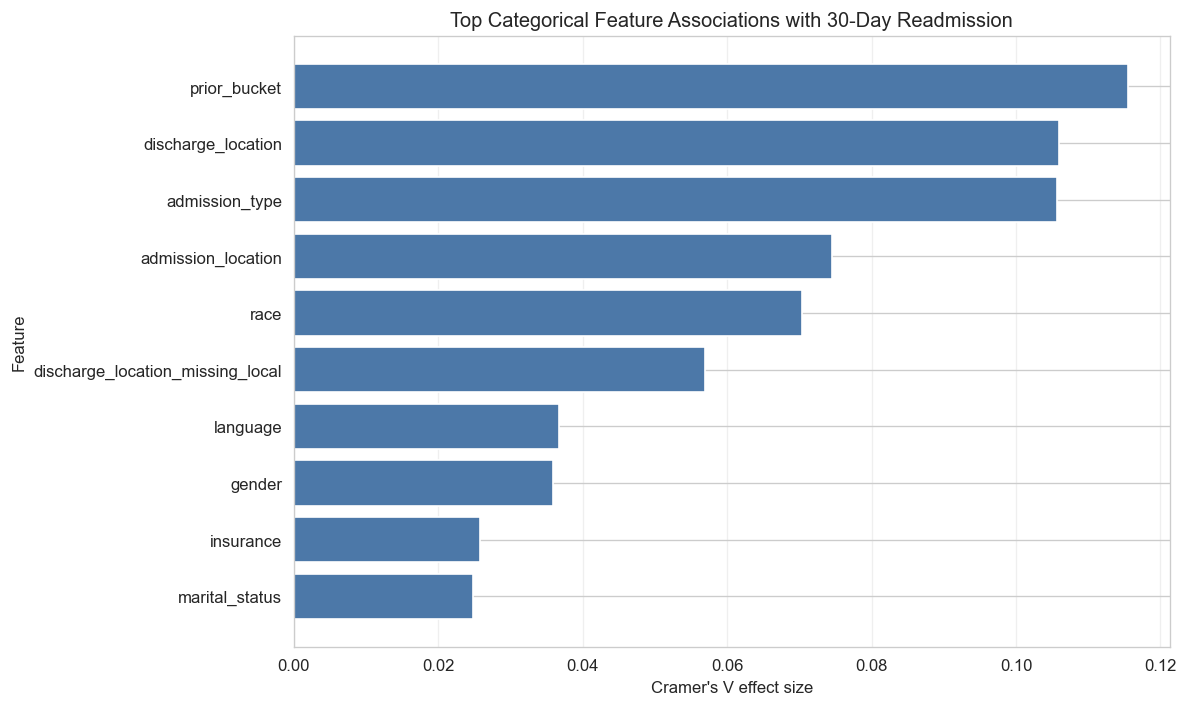

Cramer's V bar chart displayed.


In [24]:
print("\n" + "="*80)
print("SECTION 4F-3: PLOT TOP CRAMER'S V EFFECT SIZES")
print("="*80)

top_effects = chi_square_results_df.sort_values('cramers_v', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_effects['feature'], top_effects['cramers_v'], color='#4C78A8')
ax.invert_yaxis()
ax.set_xlabel("Cramer's V effect size")
ax.set_ylabel("Feature")
ax.set_title("Top Categorical Feature Associations with 30-Day Readmission")
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Cramer's V bar chart displayed.")


In [25]:
print("\n" + "="*80)
print("SECTION 4F-4: INTERPRETATION")
print("="*80)

print("""
How to interpret this audit:

1. The p-value tells whether a feature has a statistically detectable
   association with readmitted_30d.

2. Cramer's V tells how strong that association is.

3. In a large dataset, very small p-values can happen even when the effect is
   weak. For that reason, p-value alone should not be used for feature selection.

4. Stronger candidates are features with both low p-values and higher
   Cramer's V values.

5. These results are for understanding and hypothesis generation only. They do
   not automatically drop, select, or transform features in the modeling
   pipeline.

6. If chi-square based feature selection is used later, it should be fit on the
   training set only to avoid leakage from the test set.
""")



SECTION 4F-4: INTERPRETATION

How to interpret this audit:

1. The p-value tells whether a feature has a statistically detectable
   association with readmitted_30d.

2. Cramer's V tells how strong that association is.

3. In a large dataset, very small p-values can happen even when the effect is
   weak. For that reason, p-value alone should not be used for feature selection.

4. Stronger candidates are features with both low p-values and higher
   Cramer's V values.

5. These results are for understanding and hypothesis generation only. They do
   not automatically drop, select, or transform features in the modeling
   pipeline.

6. If chi-square based feature selection is used later, it should be fit on the
   training set only to avoid leakage from the test set.



In [26]:
print("\n" + "="*80)
print("SECTION 4F-5: SAFETY VERIFICATION")
print("="*80)

print(f"df_labeled shape before Section 4F logic: {df_labeled_original_shape}")
print(f"df_labeled shape after Section 4F logic:  {df_labeled.shape}")

assert df_labeled.shape == df_labeled_original_shape, "df_labeled shape changed during Section 4F."
assert list(df_labeled.columns) == df_labeled_original_columns, "df_labeled columns changed during Section 4F."

_section4f_outputs_after = {
    p.name: p.stat().st_mtime_ns
    for p in _section4f_outputs_dir.glob('*')
    if p.is_file()
}
assert _section4f_outputs_after == _section4f_outputs_before, "Output files changed during Section 4F."

print("df_labeled columns were not changed.")
print("No new output files were saved.")
print("Section 4F created chi_square_results_df plus local helper objects only.")
print("="*80)



SECTION 4F-5: SAFETY VERIFICATION
df_labeled shape before Section 4F logic: (60946, 34)
df_labeled shape after Section 4F logic:  (60946, 34)
df_labeled columns were not changed.
No new output files were saved.
Section 4F created chi_square_results_df plus local helper objects only.


## Section 5: CCSR Feature Engineering

### 5A: Load and Filter Cohort Diagnoses

In [27]:
# Load full diagnoses file -- 6.36M rows, low_memory=False required
df_diag_all = pd.read_csv(
    str(DIAGNOSES_PATH),
    low_memory=False,
    dtype={'icd_code': str, 'icd_version': int}
)
print('Original diagnoses shape:', df_diag_all.shape)

# Filter to only hadm_ids that are in our labeled cohort
cohort_hadm_ids = set(df_labeled['hadm_id'].tolist())
df_diag = df_diag_all[df_diag_all['hadm_id'].isin(cohort_hadm_ids)].copy()
del df_diag_all

n_orig     = df_diag_all.shape[0] if False else 6364488
n_filtered = len(df_diag)
pct        = n_filtered / 6364488 * 100
print(f'Filtered diagnoses shape: {df_diag.shape}')
print(f'% retained: {pct:.1f}%')
print()

# Split by ICD version
df_diag_10 = df_diag[df_diag['icd_version'] == 10].copy()
df_diag_9  = df_diag[df_diag['icd_version'] == 9].copy()

print(f'ICD-10 row count: {len(df_diag_10):,}')
print(f'ICD-9  row count: {len(df_diag_9):,}')

hadm_10  = set(df_diag_10['hadm_id'])
hadm_9   = set(df_diag_9['hadm_id'])
n_both   = len(hadm_10 & hadm_9)
print(f'Admissions with both ICD-9 and ICD-10: {n_both:,}')

Original diagnoses shape: (6364488, 5)
Filtered diagnoses shape: (735982, 5)
% retained: 11.6%

ICD-10 row count: 355,140
ICD-9  row count: 380,842
Admissions with both ICD-9 and ICD-10: 3


### 5B: ICD-10 CCSR Mapping

In [28]:
ccsr_map_path = str(CCSR_DIR / 'icd10_ccsr' / 'DXCCSR_v2025-1.csv')
df_ccsr_map = pd.read_csv(ccsr_map_path, low_memory=False)

print(f'CCSR mapping file shape: {df_ccsr_map.shape}')
print('Raw columns (first 10):')
for c in df_ccsr_map.columns[:10]:
    print(f'  {c!r}')
print()
print('First 2 rows (ICD code + first CCSR category columns):')
print(df_ccsr_map.iloc[:2, [0, 6, 8, 10, 12, 14, 16]].to_string())
print()

# Fix column names: replace quotes FIRST, then strip (quotes are outermost)
df_ccsr_map.columns = (
    df_ccsr_map.columns.str.replace("'", '', regex=False).str.strip()
)
print('Fixed column names:')
for c in df_ccsr_map.columns:
    print(f'  {c!r}')
print()

# Identify columns dynamically (never hardcode column names)
icd10_col     = 'ICD-10-CM CODE'
ccsr_cat_cols = [
    c for c in df_ccsr_map.columns
    if c.startswith('CCSR CATEGORY') and 'DESCRIPTION' not in c
]
print(f'ICD-10 code column: {icd10_col!r}')
print(f'CCSR category columns: {ccsr_cat_cols}')
print()

# Fix values in ICD code column
df_ccsr_map[icd10_col] = (
    df_ccsr_map[icd10_col].str.replace("'", '', regex=False).str.strip()
)

# Fix values in CCSR category columns
for col in ccsr_cat_cols:
    df_ccsr_map[col] = (
        df_ccsr_map[col].str.replace("'", '', regex=False).str.strip()
    )

# Melt to long format: one row per (icd_code, ccsr_code) pair
df_map10_long = (
    df_ccsr_map[[icd10_col] + ccsr_cat_cols]
    .melt(id_vars=icd10_col, value_name='ccsr_code')
    .drop(columns='variable')
    .dropna(subset=['ccsr_code'])
)
# Drop empty CCSR codes (placeholder ' ' becomes '' after strip)
df_map10_long = (
    df_map10_long[df_map10_long['ccsr_code'] != '']
    .drop_duplicates()
    .copy()
)
df_map10_long.columns = ['icd_code', 'ccsr_code']
print(f'Total (icd_code, ccsr_code) pairs: {len(df_map10_long):,}')
print(f'Unique CCSR categories in map:     {df_map10_long["ccsr_code"].nunique()}')
print()

# Clean diagnoses ICD codes (strip any whitespace)
df_diag_10['icd_code'] = df_diag_10['icd_code'].str.strip()

# Merge diagnoses with CCSR map (inner join keeps only mapped codes)
df_merged_10 = df_diag_10.merge(df_map10_long, on='icd_code', how='inner')

# Mapping success rate (unique codes in data that found a CCSR mapping)
unique_in_data  = set(df_diag_10['icd_code'].dropna())
unique_in_map   = set(df_map10_long['icd_code'])
pct_mapped_10   = len(unique_in_data & unique_in_map) / len(unique_in_data) * 100
print(f'Unique ICD-10 codes in cohort: {len(unique_in_data):,}')
print(f'ICD-10 to CCSR mapping success (unique codes): {pct_mapped_10:.1f}%')
print()

# Pivot to binary matrix: one row per hadm_id, one column per CCSR code
df_ccsr_10 = (
    df_merged_10.groupby(['hadm_id', 'ccsr_code'])
    .size()
    .clip(upper=1)
    .unstack(fill_value=0)
    .reset_index()
)
df_ccsr_10.columns.name = None

# Add CCSR_ prefix to feature columns
non_id_cols = [c for c in df_ccsr_10.columns if c != 'hadm_id']
df_ccsr_10  = df_ccsr_10.rename(columns={c: f'CCSR_{c}' for c in non_id_cols})

# CRITICAL: apply column name fix -- replace quotes FIRST, then strip
df_ccsr_10.columns = (
    df_ccsr_10.columns.str.replace("'", '', regex=False).str.strip()
)

ccsr_feature_cols = [c for c in df_ccsr_10.columns if c != 'hadm_id']
print(f'Shape of pivoted CCSR matrix: {df_ccsr_10.shape}')
print(f'First 5 CCSR column names: {ccsr_feature_cols[:5]}')
print(f'Last 5 CCSR column names:  {ccsr_feature_cols[-5:]}')

CCSR mapping file shape: (75238, 19)
Raw columns (first 10):
  "'ICD-10-CM CODE'"
  "'ICD-10-CM CODE DESCRIPTION'"
  "'Default CCSR CATEGORY IP'"
  "'Default CCSR CATEGORY DESCRIPTION IP'"
  "'Default CCSR CATEGORY OP'"
  "'Default CCSR CATEGORY DESCRIPTION OP'"
  "'CCSR CATEGORY 1'"
  "'CCSR CATEGORY 1 DESCRIPTION'"
  "'CCSR CATEGORY 2'"
  "'CCSR CATEGORY 2 DESCRIPTION'"

First 2 rows (ICD code + first CCSR category columns):
  'ICD-10-CM CODE' 'CCSR CATEGORY 1' 'CCSR CATEGORY 2' 'CCSR CATEGORY 3' 'CCSR CATEGORY 4' 'CCSR CATEGORY 5' 'CCSR CATEGORY 6'
0           'A000'          'DIG001'          'INF003'               ' '               ' '               ' '               ' '
1           'A001'          'DIG001'          'INF003'               ' '               ' '               ' '               ' '

Fixed column names:
  'ICD-10-CM CODE'
  'ICD-10-CM CODE DESCRIPTION'
  'Default CCSR CATEGORY IP'
  'Default CCSR CATEGORY DESCRIPTION IP'
  'Default CCSR CATEGORY OP'
  'Default CCSR CA

### 5C: ICD-9 CCS Mapping

In [29]:
# Load CCS reference -- first line is a note, so skip it
ccs_map_path = str(CCSR_DIR / 'icd9_ccs' / '$dxref 2015.csv')
df_ccs_map = pd.read_csv(ccs_map_path, skiprows=1, low_memory=False)

print(f'CCS mapping file shape: {df_ccs_map.shape}')
print('Raw columns:')
for c in df_ccs_map.columns:
    print(f'  {c!r}')
print()
print('First 3 rows:')
print(df_ccs_map.head(3).to_string())
print()

# Fix column names: replace quotes FIRST, then strip
df_ccs_map.columns = (
    df_ccs_map.columns.str.replace("'", '', regex=False).str.strip()
)
print('Fixed column names:', df_ccs_map.columns.tolist())
print()

# Identify columns dynamically
icd9_col = 'ICD-9-CM CODE'
ccs_col  = 'CCS CATEGORY'
print(f'ICD-9 code column: {icd9_col!r}')
print(f'CCS category column: {ccs_col!r}')
print()

# Fix values
df_ccs_map[icd9_col] = (
    df_ccs_map[icd9_col].str.replace("'", '', regex=False).str.strip()
)
df_ccs_map[ccs_col] = (
    df_ccs_map[ccs_col].str.replace("'", '', regex=False).str.strip()
)

# Drop invalid rows: empty ICD code or CCS category '0' (No DX placeholder)
df_ccs_clean = (
    df_ccs_map[
        (df_ccs_map[icd9_col] != '') &
        (df_ccs_map[ccs_col] != '0') &
        (df_ccs_map[ccs_col] != '')
    ][[icd9_col, ccs_col]]
    .drop_duplicates()
    .copy()
)
df_ccs_clean.columns = ['icd_code', 'ccs_code']
print(f'Total (icd_code, ccs_code) pairs: {len(df_ccs_clean):,}')
print(f'Unique CCS categories in map:     {df_ccs_clean["ccs_code"].nunique()}')
print()

# Clean ICD-9 codes and merge
df_diag_9['icd_code'] = df_diag_9['icd_code'].str.strip()
df_merged_9 = df_diag_9.merge(df_ccs_clean, on='icd_code', how='inner')

# Mapping success rate
unique_in_data9 = set(df_diag_9['icd_code'].dropna())
unique_in_map9  = set(df_ccs_clean['icd_code'])
pct_mapped_9    = len(unique_in_data9 & unique_in_map9) / len(unique_in_data9) * 100
print(f'Unique ICD-9 codes in cohort: {len(unique_in_data9):,}')
print(f'ICD-9 to CCS mapping success (unique codes): {pct_mapped_9:.1f}%')
print()

# Pivot to binary matrix
df_ccs_9 = (
    df_merged_9.groupby(['hadm_id', 'ccs_code'])
    .size()
    .clip(upper=1)
    .unstack(fill_value=0)
    .reset_index()
)
df_ccs_9.columns.name = None

# CRITICAL: apply column name fix -- replace quotes FIRST, then strip
df_ccs_9.columns = (
    df_ccs_9.columns.str.replace("'", '', regex=False).str.strip()
)

ccs_feature_cols = [c for c in df_ccs_9.columns if c != 'hadm_id']
print(f'Shape of pivoted CCS matrix: {df_ccs_9.shape}')
print(f'First 5 CCS column names: {ccs_feature_cols[:5]}')
print(f'Last 5 CCS column names:  {ccs_feature_cols[-5:]}')

CCS mapping file shape: (15073, 6)
Raw columns:
  "'ICD-9-CM CODE'"
  "'CCS CATEGORY'"
  "'CCS CATEGORY DESCRIPTION'"
  "'ICD-9-CM CODE DESCRIPTION'"
  "'OPTIONAL CCS CATEGORY'"
  "'OPTIONAL CCS CATEGORY DESCRIPTION'"

First 3 rows:
  'ICD-9-CM CODE' 'CCS CATEGORY' 'CCS CATEGORY DESCRIPTION' 'ICD-9-CM CODE DESCRIPTION' 'OPTIONAL CCS CATEGORY' 'OPTIONAL CCS CATEGORY DESCRIPTION'
0         '     '        '0    '                    'No DX'  INVALID CODES IN USER DATA                     ' '                                 ' '
1         '01000'        '1    '             'Tuberculosis'      PRIM TB COMPLEX-UNSPEC                     ' '                                 ' '
2         '01001'        '1    '             'Tuberculosis'     PRIM TB COMPLEX-NO EXAM                     ' '                                 ' '

Fixed column names: ['ICD-9-CM CODE', 'CCS CATEGORY', 'CCS CATEGORY DESCRIPTION', 'ICD-9-CM CODE DESCRIPTION', 'OPTIONAL CCS CATEGORY', 'OPTIONAL CCS CATEGORY DESCRIPTION']



### 5D: Apply Human-Readable Labels

In [30]:
print('=' * 80)
print('SECTION 5D: BUILD LABEL MAPPINGS')
print('=' * 80)

# Load mapping files.
ccsr_map = pd.read_csv(
    CCSR_DIR / 'icd10_ccsr' / 'DXCCSR_v2025-1.csv', dtype=str
)
ccs_map = pd.read_csv(
    CCSR_DIR / 'icd9_ccs' / 'dxlabel 2015.csv', dtype=str
)

# The CCSR CSV stores some headers and values with literal quote characters.
ccsr_map.columns = [str(c).strip().replace("'", '') for c in ccsr_map.columns]
ccs_map.columns = [str(c).strip().replace("'", '') for c in ccs_map.columns]

print(f'CCSR map shape: {ccsr_map.shape}')
print(f'CCS map shape: {ccs_map.shape}')

# Build CCSR category code to description mapping.
# CCSR feature column names are like CCSR_BLD001 and CCSR_NEO023.
# Extract the category code, for example BLD001, and look up its description.

ccsr_dict = {}

ccsr_code_cols = [c for c in ccsr_map.columns
                  if 'CCSR CATEGORY' in c and 'DESCRIPTION' not in c]
ccsr_desc_cols = [c for c in ccsr_map.columns
                  if 'CCSR CATEGORY' in c and 'DESCRIPTION' in c]

print(f"\nCCSR code columns: {ccsr_code_cols}")
print(f"CCSR desc columns: {ccsr_desc_cols}")

for code_col, desc_col in zip(ccsr_code_cols, ccsr_desc_cols):
    valid_rows = ccsr_map[[code_col, desc_col]].dropna()
    for _, row in valid_rows.iterrows():
        code_clean = str(row[code_col]).strip().replace("'", '')
        desc_clean = str(row[desc_col]).strip().replace("'", '')
        if code_clean and code_clean != '' and desc_clean and desc_clean.lower() != 'nan':
            ccsr_dict.setdefault(code_clean, desc_clean)

print(f"\nCCSR code-to-description mapping: {len(ccsr_dict)} codes")
print(f"Sample: {list(ccsr_dict.items())[:3]}")

# Build CCS code to description mapping.

ccs_dict = {}
ccs_code_col = ccs_map.columns[0]
ccs_desc_col = ccs_map.columns[1]

valid_ccs_rows = ccs_map[[ccs_code_col, ccs_desc_col]].dropna()
for _, row in valid_ccs_rows.iterrows():
    code_clean = str(row[ccs_code_col]).strip().replace("'", '')
    desc_clean = str(row[ccs_desc_col]).strip().replace("'", '')
    if code_clean and desc_clean and desc_clean.lower() != 'nan':
        ccs_dict[code_clean] = desc_clean

print(f"\nCCS code-to-description mapping: {len(ccs_dict)} codes")
print(f"Sample: {list(ccs_dict.items())[:3]}")


SECTION 5D: BUILD LABEL MAPPINGS
CCSR map shape: (75238, 19)
CCS map shape: (288, 2)

CCSR code columns: ['Default CCSR CATEGORY IP', 'Default CCSR CATEGORY OP', 'CCSR CATEGORY 1', 'CCSR CATEGORY 2', 'CCSR CATEGORY 3', 'CCSR CATEGORY 4', 'CCSR CATEGORY 5', 'CCSR CATEGORY 6']
CCSR desc columns: ['Default CCSR CATEGORY DESCRIPTION IP', 'Default CCSR CATEGORY DESCRIPTION OP', 'CCSR CATEGORY 1 DESCRIPTION', 'CCSR CATEGORY 2 DESCRIPTION', 'CCSR CATEGORY 3 DESCRIPTION', 'CCSR CATEGORY 4 DESCRIPTION', 'CCSR CATEGORY 5 DESCRIPTION', 'CCSR CATEGORY 6 DESCRIPTION']

CCSR code-to-description mapping: 554 codes
Sample: [('DIG001', 'Intestinal infection'), ('NVS001', 'Meningitis'), ('INF003', 'Bacterial infections')]

CCS code-to-description mapping: 288 codes
Sample: [('.Z', 'Overall'), ('.', 'No diagnosis'), ('.A', 'Invalid diagnosis')]


In [31]:
print("\n" + "="*80)
print("SECTION 5D: APPLY LABELS TO COLUMNS")
print("="*80)

# Rename CCSR columns.
# Column names are like CCSR_BLD001. Extract BLD001 and look up its description.

def extract_ccsr_code(col_name):
    """Extract CCSR category code from a column name like CCSR_BLD001."""
    col_str = str(col_name).strip().replace("'", '')
    if col_str.startswith('CCSR_'):
        return col_str.replace('CCSR_', '', 1)
    return None


ccsr_new_names = []
for col in df_ccsr_10.columns:
    code = extract_ccsr_code(col)
    if code and code in ccsr_dict:
        ccsr_new_names.append(ccsr_dict[code])
    else:
        ccsr_new_names.append(col)

df_ccsr_10.columns = ccsr_new_names

# Rename CCS columns. Columns are codes like 1, 2, and so on.

ccs_new_names = []
for col in df_ccs_9.columns:
    col_str = str(col).strip().replace("'", '')
    if col_str in ccs_dict:
        ccs_new_names.append(ccs_dict[col_str])
    else:
        ccs_new_names.append(col)

df_ccs_9.columns = ccs_new_names

print(f"CCSR renamed sample: {df_ccsr_10.columns[:5].tolist()}")
print(f"CCS renamed sample: {df_ccs_9.columns[:5].tolist()}")

# Verify renaming worked.
unmapped_ccsr = [c for c in df_ccsr_10.columns
                 if str(c).strip().replace("'", '').startswith('CCSR_')]
unmapped_ccs = [c for c in df_ccs_9.columns
                if str(c).strip().replace("'", '').isdigit()]

print(f"\nUnmapped CCSR, codes that stayed as-is: {len(unmapped_ccsr)}")
print(f"Unmapped CCS, codes that stayed as-is: {len(unmapped_ccs)}")

if unmapped_ccsr:
    print(f"  Sample unmapped CCSR: {unmapped_ccsr[:5]}")
if unmapped_ccs:
    print(f"  Sample unmapped CCS: {unmapped_ccs[:5]}")

assert len(unmapped_ccsr) == 0, f"ERROR: {len(unmapped_ccsr)} CCSR code columns were not renamed."

print(f"\nColumn renaming results:")
print(f"  CCSR columns: {df_ccsr_10.shape[1]}, all should now be descriptions, not codes")
print(f"  CCS columns: {df_ccs_9.shape[1]}, all should now be descriptions, not codes")

# Save label column lists for use later, including Section 4F strict diagnosis detection.
ccsr_label_cols = [c for c in df_ccsr_10.columns if c != 'hadm_id']
ccs_label_cols = [c for c in df_ccs_9.columns if c != 'hadm_id']

print(f"\nSaved for later:")
print(f"  ccsr_label_cols: {len(ccsr_label_cols)} columns")
print(f"  ccs_label_cols: {len(ccs_label_cols)} columns")

print("\nSection 5D complete. All diagnosis columns now have human-readable names.")
print("="*80)



SECTION 5D: APPLY LABELS TO COLUMNS
CCSR renamed sample: ['hadm_id', 'Nutritional anemia', 'Hemolytic anemia', 'Aplastic anemia', 'Acute posthemorrhagic anemia']
CCS renamed sample: ['hadm_id', 'Tuberculosis', 'Immunizations and screening for infectious disease', 'Acute myocardial infarction', 'Coronary atherosclerosis and other heart disease']

Unmapped CCSR, codes that stayed as-is: 0
Unmapped CCS, codes that stayed as-is: 0

Column renaming results:
  CCSR columns: 509, all should now be descriptions, not codes
  CCS columns: 278, all should now be descriptions, not codes

Saved for later:
  ccsr_label_cols: 508 columns
  ccs_label_cols: 277 columns

Section 5D complete. All diagnosis columns now have human-readable names.


### 5E: Merge All Features with df_labeled

In [32]:
print("\n" + "="*80)
print("SECTION 5E: MERGE ALL FEATURES WITH DF_LABELED")
print("="*80)

# df_ccsr_10 and df_ccs_9 have hadm_id as their DataFrame index from pivot.
# Reset index so hadm_id becomes a regular column for clean merging.

df_ccsr_10_reset = df_ccsr_10.reset_index()
df_ccs_9_reset = df_ccs_9.reset_index()

print(f"\nShapes before merge:")
print(f"  df_labeled:   {df_labeled.shape}")
print(f"  df_ccsr_10:   {df_ccsr_10_reset.shape}")
print(f"  df_ccs_9:     {df_ccs_9_reset.shape}")

# Left merge: keep all admissions from df_labeled.
df_features = df_labeled.merge(
    df_ccsr_10_reset,
    on='hadm_id',
    how='left',
    validate='1:1'
)

print(f"\nAfter CCSR merge: {df_features.shape}")

df_features = df_features.merge(
    df_ccs_9_reset,
    on='hadm_id',
    how='left',
    validate='1:1',
    suffixes=('', '_unused')
)

print(f"After CCS merge: {df_features.shape}")

# Drop any _unused suffix columns if they appeared.
unused_cols = [c for c in df_features.columns if c.endswith('_unused')]
if unused_cols:
    df_features = df_features.drop(columns=unused_cols)
    print(f"Dropped {len(unused_cols)} duplicate columns")

# Fill NaN diagnosis columns with 0, because no diagnosis means not present.
diagnosis_cols = [c for c in df_features.columns if c not in df_labeled.columns]
df_features[diagnosis_cols] = df_features[diagnosis_cols].fillna(0).astype(int)

# Verify exactly one hadm_id column exists.
hadm_id_cols = [c for c in df_features.columns if 'hadm_id' in c.lower()]
print(f"\nhadm_id column check: {hadm_id_cols}")
assert len(hadm_id_cols) == 1, f"ERROR: Found {len(hadm_id_cols)} hadm_id columns."
assert hadm_id_cols[0] == 'hadm_id', f"ERROR: Column name {hadm_id_cols[0]!r}, expected 'hadm_id'."

print(f"\nColumn breakdown:")
print(f"  Original: {df_labeled.shape[1]}")
print(f"  CCSR: {len(df_ccsr_10.columns)}")
print(f"  CCS: {len(df_ccs_9.columns)}")
print(f"  Total: {df_features.shape[1]}")

print(f"\ndf_features complete for downstream diagnosis analysis and preprocessing.")
print("="*80)


SECTION 5E: MERGE ALL FEATURES WITH DF_LABELED

Shapes before merge:
  df_labeled:   (60946, 34)
  df_ccsr_10:   (24570, 510)
  df_ccs_9:     (36379, 279)

After CCSR merge: (60946, 543)
After CCS merge: (60946, 821)
Dropped 99 duplicate columns

hadm_id column check: ['hadm_id']

Column breakdown:
  Original: 34
  CCSR: 509
  CCS: 278
  Total: 722

df_features complete for downstream diagnosis analysis and preprocessing.


### 5F: Report and Checkpoint

In [33]:
import random
random.seed(42)

# Use label lists defined in 5D-RENAME (columns are now descriptions, not codes)
ccsr_feat_e = [c for c in ccsr_label_cols if c in df_features.columns]
ccs_feat_e  = [c for c in ccs_label_cols  if c in df_features.columns]
original_e  = set(df_labeled.columns.tolist())

n_original_e = len(original_e)
n_ccsr_e     = len(ccsr_feat_e)
n_ccs_e      = len(ccs_feat_e)

print()

# Binary verification on 5 random CCSR columns
check_cols = random.sample(ccsr_feat_e, min(5, len(ccsr_feat_e)))
print('Binary verification (sample CCSR columns):')
for col in check_cols:
    cmin = int(df_features[col].min())
    cmax = int(df_features[col].max())
    ok   = 'OK' if cmin == 0 and cmax <= 1 else 'FAIL'
    print(f'  {col!r}: min={cmin}, max={cmax}  {ok}')

print()
print('df_features is ready for Section 6 (Preprocessing).')

# Save diagnosis column lists for Section 4F.
ccsr_diagnosis_cols = list(df_ccsr_10.columns)
ccs_diagnosis_cols = list(df_ccs_9.columns)
print(f"\nSaved for 4F: {len(ccsr_diagnosis_cols)} CCSR + {len(ccs_diagnosis_cols)} CCS diagnosis columns")



Binary verification (sample CCSR columns):
  'Other specified connective tissue disease': min=0, max=1  OK
  'Gastrointestinal and biliary perforation': min=0, max=1  OK
  'Nonrheumatic and unspecified valve disorders': min=0, max=1  OK
  'Male reproductive system cancers - testis': min=0, max=1  OK
  'Other specified eye disorders': min=0, max=1  OK

df_features is ready for Section 6 (Preprocessing).

Saved for 4F: 509 CCSR + 278 CCS diagnosis columns


### 4F: Clinical Diagnosis Categories and Readmission Risk

SECTION 4F: CLINICAL DIAGNOSIS CATEGORIES VS READMISSION RATE

Diagnosis columns, CCSR + CCS: 688
Categories with at least 30 patients: 528


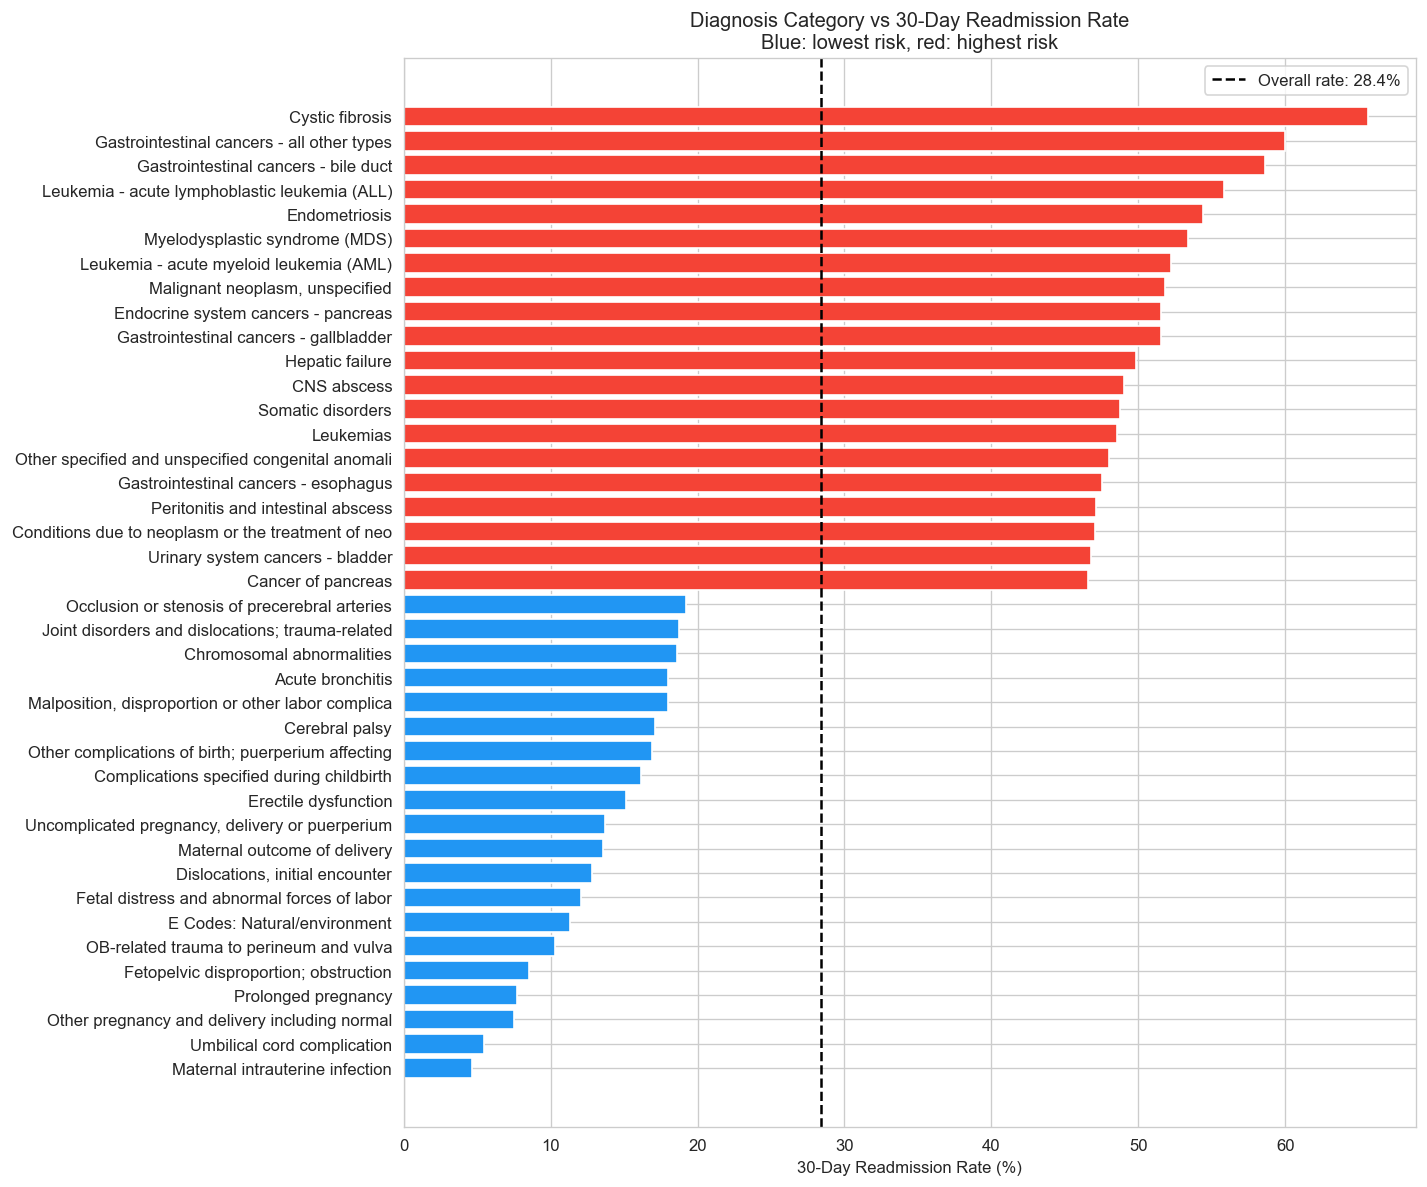


Bottom 5, lowest readmission risk:
  Maternal intrauterine infection: 4.6% (n=65)
  Umbilical cord complication: 5.4% (n=239)
  Other pregnancy and delivery including normal: 7.5% (n=1178)
  Prolonged pregnancy: 7.7% (n=78)
  Fetopelvic disproportion; obstruction: 8.5% (n=47)

Top 5, highest readmission risk:
  Endometriosis: 54.4% (n=57)
  Leukemia - acute lymphoblastic leukemia (ALL): 55.8% (n=77)
  Gastrointestinal cancers - bile duct: 58.7% (n=104)
  Gastrointestinal cancers - all other types: 60.0% (n=45)
  Cystic fibrosis: 65.6% (n=32)

Readmission rate range: 4.6% to 65.6%


In [34]:
print("="*80)
print("SECTION 4F: CLINICAL DIAGNOSIS CATEGORIES VS READMISSION RATE")
print("="*80)

# Use strict diagnosis detection: only columns saved from Section 5F.
# This excludes hadm_id variants, discharge_location_missing, and other non-diagnosis columns.

diag_cols = [c for c in df_features.columns
             if c in ccsr_diagnosis_cols or c in ccs_diagnosis_cols]

print(f"\nDiagnosis columns, CCSR + CCS: {len(diag_cols)}")

# Compute readmission rate for each diagnosis.
diag_rates = {}
for col in diag_cols:
    subset = df_features[df_features[col] == 1]
    if len(subset) >= 30:
        rate = subset['readmitted_30d'].mean()
        diag_rates[col] = {'rate': rate, 'n': len(subset)}

print(f"Categories with at least 30 patients: {len(diag_rates)}")

sorted_rates = sorted(diag_rates.items(), key=lambda x: x[1]['rate'])

if len(sorted_rates) >= 40:
    bottom_20 = sorted_rates[:20]
    top_20 = sorted_rates[-20:]
    plot_data = bottom_20 + top_20
else:
    plot_data = sorted_rates

labels = [x[0][:50] for x in plot_data]
rates = [x[1]['rate'] * 100 for x in plot_data]
split_point = min(20, len(plot_data) // 2)
colors = ['#2196F3'] * split_point + ['#F44336'] * (len(plot_data) - split_point)

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(labels, rates, color=colors)
overall_rate = df_features['readmitted_30d'].mean() * 100
ax.axvline(x=overall_rate, color='black', linestyle='--', linewidth=1.5,
           label=f"Overall rate: {overall_rate:.1f}%")
ax.set_xlabel("30-Day Readmission Rate (%)")
ax.set_title("Diagnosis Category vs 30-Day Readmission Rate\nBlue: lowest risk, red: highest risk")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nBottom 5, lowest readmission risk:")
for name, vals in sorted_rates[:5]:
    print(f"  {name}: {vals['rate']*100:.1f}% (n={vals['n']})")

print(f"\nTop 5, highest readmission risk:")
for name, vals in sorted_rates[-5:]:
    print(f"  {name}: {vals['rate']*100:.1f}% (n={vals['n']})")

if sorted_rates:
    rate_range = f"{sorted_rates[0][1]['rate']*100:.1f}% to {sorted_rates[-1][1]['rate']*100:.1f}%"
    print(f"\nReadmission rate range: {rate_range}")
else:
    print("\nNo diagnosis categories met the minimum patient threshold.")

print("="*80)

## Section 6: Preprocessing

### 6: Transform, Consolidate, Encode, and Prepare for Modeling

Input: df_features (60,946 x 822) from Section 5
Output: df_preprocessed (60,946 x ~450-500) ready for train/test split

### 6A: Create Missingness Indicator Flags
Binary flags created before imputation. Section 4E showed discharge_location missingness is correlated with readmission.

In [35]:
print("="*80)
print("SECTION 6A: CREATE MISSINGNESS INDICATOR FLAGS")
print("="*80)

df_prep = df_features.copy()

print(f"\nInput shape: {df_prep.shape}")
print("Creating missingness indicator flags BEFORE imputation...")

# Create flags for columns with significant missingness
# discharge_location: 25.1% missing (from Section 4E)
df_prep['discharge_location_missing'] = df_prep['discharge_location'].isna().astype(int)

# marital_status: 1.03% missing
df_prep['marital_status_missing'] = df_prep['marital_status'].isna().astype(int)

# insurance: 0.73% missing
df_prep['insurance_missing'] = df_prep['insurance'].isna().astype(int)

print(f"\nMissingness flags created:")
print(f"  discharge_location_missing: {df_prep['discharge_location_missing'].sum()} admissions")
print(f"  marital_status_missing: {df_prep['marital_status_missing'].sum()} admissions")
print(f"  insurance_missing: {df_prep['insurance_missing'].sum()} admissions")

SECTION 6A: CREATE MISSINGNESS INDICATOR FLAGS

Input shape: (60946, 722)
Creating missingness indicator flags BEFORE imputation...

Missingness flags created:
  discharge_location_missing: 15297 admissions
  marital_status_missing: 629 admissions
  insurance_missing: 444 admissions


### 6B: Winsorize Numeric Features
Extreme outliers are capped at the 99th percentile. Thresholds are los_days at 32 days and prior_admissions_count at 35.

In [36]:
print("\n" + "="*80)
print("SECTION 6B: WINSORIZE NUMERIC FEATURES AT 99TH PERCENTILE")
print("="*80)

# los_days: winsorize at 32 (from Section 4B findings)
print(f"\nlos_days before winsorization:")
print(f"  min: {df_prep['los_days'].min()}, max: {df_prep['los_days'].max()}")
print(f"  99th pct: {df_prep['los_days'].quantile(0.99):.1f}")

df_prep['los_days'] = df_prep['los_days'].clip(lower=0, upper=32)

print(f"los_days after winsorization at 32:")
print(f"  min: {df_prep['los_days'].min()}, max: {df_prep['los_days'].max()}")

# prior_admissions_count: winsorize at 35 (from Section 4B findings)
print(f"\nprior_admissions_count before winsorization:")
print(f"  min: {df_prep['prior_admissions_count'].min()}, max: {df_prep['prior_admissions_count'].max()}")
print(f"  99th pct: {df_prep['prior_admissions_count'].quantile(0.99):.1f}")

df_prep['prior_admissions_count'] = df_prep['prior_admissions_count'].clip(lower=0, upper=35)

print(f"prior_admissions_count after winsorization at 35:")
print(f"  min: {df_prep['prior_admissions_count'].min()}, max: {df_prep['prior_admissions_count'].max()}")


SECTION 6B: WINSORIZE NUMERIC FEATURES AT 99TH PERCENTILE

los_days before winsorization:
  min: -1, max: 295
  99th pct: 32.0
los_days after winsorization at 32:
  min: 0, max: 32

prior_admissions_count before winsorization:
  min: 0, max: 97
  99th pct: 35.0
prior_admissions_count after winsorization at 35:
  min: 0, max: 35


### 6C: Consolidate Race Categories
Race subcategories are consolidated to six groups for fairness analysis: WHITE, BLACK, ASIAN, HISPANIC, OTHER, and UNKNOWN.

In [37]:
print("\n" + "="*80)
print("SECTION 6C: CONSOLIDATE RACE TO 6 CATEGORIES")
print("="*80)

print(f"\nOriginal race categories ({df_prep['race'].nunique()}):")
print(df_prep['race'].value_counts(dropna=False))

def consolidate_race(value):
    if pd.isna(value):
        return "UNKNOWN"

    text = str(value).upper().strip()

    if ("UNKNOWN" in text) or ("DECLINED" in text) or ("UNABLE" in text):
        return "UNKNOWN"
    elif "HISPANIC" in text or "LATINO" in text:
        return "HISPANIC"
    elif "BLACK" in text or "AFRICAN" in text:
        return "BLACK"
    elif "ASIAN" in text:
        return "ASIAN"
    elif "WHITE" in text:
        return "WHITE"
    else:
        return "OTHER"

df_prep['race_consolidated'] = df_prep['race'].apply(consolidate_race)

expected_race_groups = {"WHITE", "BLACK", "HISPANIC", "ASIAN", "UNKNOWN", "OTHER"}
observed_race_groups = set(df_prep['race_consolidated'].dropna().unique())
unexpected_race_groups = observed_race_groups - expected_race_groups
assert not unexpected_race_groups, f"Unexpected race groups after consolidation: {unexpected_race_groups}"

print(f"\nConsolidated race categories:")
print(df_prep['race_consolidated'].value_counts())

# Drop original race column and keep the consolidated race column for one-hot encoding.
df_prep = df_prep.drop(columns=['race'])
df_prep = df_prep.rename(columns={'race_consolidated': 'race'})



SECTION 6C: CONSOLIDATE RACE TO 6 CATEGORIES

Original race categories (33):
race
WHITE                                        37880
BLACK/AFRICAN AMERICAN                        9366
OTHER                                         1993
WHITE - OTHER EUROPEAN                        1347
HISPANIC/LATINO - PUERTO RICAN                1282
HISPANIC OR LATINO                            1050
UNKNOWN                                        867
WHITE - RUSSIAN                                818
BLACK/CAPE VERDEAN                             768
ASIAN - CHINESE                                759
HISPANIC/LATINO - DOMINICAN                    728
ASIAN                                          600
BLACK/CARIBBEAN ISLAND                         516
BLACK/AFRICAN                                  362
HISPANIC/LATINO - GUATEMALAN                   314
WHITE - EASTERN EUROPEAN                       229
PATIENT DECLINED TO ANSWER                     214
HISPANIC/LATINO - SALVADORAN                   207

### 6D: Fill Missing Categorical Values
Missing categorical values are filled after flags are created. discharge_location and marital_status use UNKNOWN; insurance uses the mode.

In [38]:
print("\n" + "="*80)
print("SECTION 6D: FILL MISSING CATEGORICAL VALUES")
print("="*80)

# discharge_location: fill with 'UNKNOWN' (not 'HOME')
# Reason: missingness is predictive (different pattern from actual HOME)
missing_loc = df_prep['discharge_location'].isna().sum()
df_prep['discharge_location'] = df_prep['discharge_location'].fillna('UNKNOWN')
print(f"discharge_location: {missing_loc} rows filled with 'UNKNOWN'")

# marital_status: fill with 'UNKNOWN'
missing_mar = df_prep['marital_status'].isna().sum()
df_prep['marital_status'] = df_prep['marital_status'].fillna('UNKNOWN')
print(f"marital_status: {missing_mar} rows filled with 'UNKNOWN'")

# insurance: fill with mode
mode_insurance = df_prep['insurance'].mode()[0]
missing_ins = df_prep['insurance'].isna().sum()
df_prep['insurance'] = df_prep['insurance'].fillna(mode_insurance)
print(f"insurance: {missing_ins} rows filled with mode '{mode_insurance}'")

# language: fill with 'UNKNOWN' (if any missing)
if df_prep['language'].isna().sum() > 0:
    df_prep['language'] = df_prep['language'].fillna('UNKNOWN')
    print(f"language: {df_prep['language'].isna().sum()} rows filled")

print(f"\nFinal missing value check (categorical):")
categorical_cols = ['discharge_location', 'marital_status', 'insurance', 'language', 'admission_type', 'gender']
for col in categorical_cols:
    if col in df_prep.columns:
        print(f"  {col}: {df_prep[col].isna().sum()}")


SECTION 6D: FILL MISSING CATEGORICAL VALUES
discharge_location: 15297 rows filled with 'UNKNOWN'
marital_status: 629 rows filled with 'UNKNOWN'
insurance: 444 rows filled with mode 'Medicare'
language: 0 rows filled

Final missing value check (categorical):
  discharge_location: 0
  marital_status: 0
  insurance: 0
  language: 0
  admission_type: 0
  gender: 0


### 6E: Remove Near-Zero Variance Features
Diagnosis categories with less than 1% prevalence are dropped as low-information features.

In [39]:
print("\n" + "="*80)
print("SECTION 6E: REMOVE NEAR-ZERO VARIANCE FEATURES")
print("="*80)

# Identify CCSR and CCS columns (all diagnosis columns)
original_cols = {
    'subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime',
    'admission_type', 'admit_provider_id', 'admission_location',
    'discharge_location', 'insurance', 'language', 'marital_status',
    'race', 'edregtime', 'edouttime', 'hospital_expire_flag',
    'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod',
    'is_planned', 'age_group', 'next_admittime', 'next_is_planned',
    'days_to_next', 'is_last_admission', 'readmitted_30d', 'year',
    'prior_admissions_count', 'prior_bucket', 'los_days', 'came_via_ed',
    'discharge_location_missing', 'marital_status_missing', 'insurance_missing',
    'race_consolidated',
}

diagnosis_cols = [c for c in df_prep.columns if c not in original_cols]

print(f"Total diagnosis columns: {len(diagnosis_cols)}")

# Threshold: <0.5% prevalence (< 304 admissions with this diagnosis)
# 60,946 * 0.005 = 304.73
threshold = int(df_prep.shape[0] * 0.005)

low_variance_cols = []
for col in diagnosis_cols:
    n_positive = (df_prep[col] == 1).sum()
    if n_positive < threshold:
        low_variance_cols.append(col)

print(f"Threshold for near-zero variance: <{threshold} admissions (0.5%)")
print(f"Columns to drop: {len(low_variance_cols)}")

# Drop low variance columns
df_prep = df_prep.drop(columns=low_variance_cols)

print(f"\nAfter dropping near-zero variance:")
print(f"  Columns retained: {len(df_prep.columns)}")
print(f"  Diagnosis features remaining: {len([c for c in df_prep.columns if c not in original_cols])}")


SECTION 6E: REMOVE NEAR-ZERO VARIANCE FEATURES
Total diagnosis columns: 688
Threshold for near-zero variance: <304 admissions (0.5%)
Columns to drop: 407

After dropping near-zero variance:
  Columns retained: 317
  Diagnosis features remaining: 281


### 6F: One-Hot Encode Categorical Features
Categorical columns are encoded as binary dummy variables for modeling.

In [40]:
print("\n" + "="*80)
print("SECTION 6F: ONE-HOT ENCODE CATEGORICAL FEATURES")
print("="*80)

# Categorical columns to encode
categorical_to_encode = ['gender', 'race', 'admission_type', 'insurance',
                         'discharge_location', 'marital_status', 'language']

# Keep original columns for reference during split
original_id_cols = ['subject_id', 'hadm_id']

print(f"Encoding {len(categorical_to_encode)} categorical features...")

# One-hot encode with drop_first=False (keep all dummies)
df_encoded = pd.get_dummies(df_prep, columns=categorical_to_encode, drop_first=False, dtype='int8')

print(f"\nBefore encoding: {df_prep.shape[1]} columns")
print(f"After encoding: {df_encoded.shape[1]} columns")
print(f"New dummy columns added: {df_encoded.shape[1] - df_prep.shape[1]}")

# Handoff for downstream checkpoints, train/test split, and modeling.
df_preprocessed = df_encoded.copy()
print(f"df_preprocessed updated from df_encoded: {df_preprocessed.shape}")

# Show sample of encoded columns
encoded_cols = [c for c in df_encoded.columns if '_' in c and c not in df_prep.columns]
print(f"\nSample of encoded column names (first 15):")
print(encoded_cols[:15])


SECTION 6F: ONE-HOT ENCODE CATEGORICAL FEATURES
Encoding 7 categorical features...

Before encoding: 317 columns
After encoding: 377 columns
New dummy columns added: 60
df_preprocessed updated from df_encoded: (60946, 377)

Sample of encoded column names (first 15):
['gender_F', 'gender_M', 'race_ASIAN', 'race_BLACK', 'race_HISPANIC', 'race_OTHER', 'race_UNKNOWN', 'race_WHITE', 'admission_type_AMBULATORY OBSERVATION', 'admission_type_DIRECT EMER.', 'admission_type_DIRECT OBSERVATION', 'admission_type_ELECTIVE', 'admission_type_EU OBSERVATION', 'admission_type_EW EMER.', 'admission_type_OBSERVATION ADMIT']


In [41]:
print("\n" + "="*80)
print("SECTION 6G: PREPROCESSING")
print("="*80)

print(f"\ndf_preprocessed shape: {df_preprocessed.shape}")
print(f"Rows: {df_preprocessed.shape[0]:,}")
print(f"Columns: {df_preprocessed.shape[1]}")

nan_count = df_preprocessed.isna().sum().sum()
print(f"\nNaN check: {nan_count:,} total NaN values")

if nan_count > 0:
    print("\nColumns with NaN values, first 20:")
    nan_cols = df_preprocessed.columns[df_preprocessed.isna().any()].tolist()
    for col in nan_cols[:20]:
        col_nan = df_preprocessed[col].isna().sum()
        print(f"  {col}: {col_nan:,} NaN")
    if len(nan_cols) > 20:
        print(f"  Additional columns with NaN: {len(nan_cols) - 20}")
    print(f"\nNaN values must be resolved in Section 6H before Section 7.")
else:
    print("NaN check passed: 0 NaN values.")

print(f"\nTarget variable:")
vc = df_preprocessed['readmitted_30d'].value_counts().sort_index()
print(f"  Class 0: {vc.get(0, 0):,}")
print(f"  Class 1: {vc.get(1, 0):,}")
print(f"  Readmission rate: {df_preprocessed['readmitted_30d'].mean()*100:.1f}%")

print(f"\nPatients: {df_preprocessed['subject_id'].nunique():,}")
print(f"Admissions: {df_preprocessed['hadm_id'].nunique():,}")



SECTION 6G: PREPROCESSING

df_preprocessed shape: (60946, 377)
Rows: 60,946
Columns: 377

NaN check: 143,087 total NaN values

Columns with NaN values, first 20:
  deathtime: 60,946 NaN
  edregtime: 20,465 NaN
  edouttime: 20,465 NaN
  dod: 41,211 NaN

NaN values must be resolved in Section 6H before Section 7.

Target variable:
  Class 0: 43,648
  Class 1: 17,298
  Readmission rate: 28.4%

Patients: 19,234
Admissions: 60,946


### 6H: Drop Non-Feature Columns and Verify Clean State
Date/time, leakage, and metadata columns are removed. Leakage columns (next_is_planned, days_to_next, is_last_admission) were used to construct the label and must never enter the feature matrix. hospital_expire_flag is an outcome, not a predictor.

In [42]:
print("\n" + "="*80)
print("SECTION 6H: DROP NON-FEATURE COLUMNS")
print("="*80)

print(f"\nInput: {df_preprocessed.shape}")
print(f"NaN count before: {df_preprocessed.isna().sum().sum():,}")

# Date/time, leakage, outcome, and metadata columns are not model features.
datetime_cols = [
    'admittime', 'dischtime', 'deathtime',
    'edregtime', 'edouttime', 'next_admittime', 'dod'
]

leakage_cols = [
    'next_is_planned',
    'days_to_next',
    'is_last_admission',
    'is_planned',
]

outcome_cols = ['hospital_expire_flag']

metadata_cols = [
    'anchor_year', 'anchor_year_group', 'year', 'age_group',
    'prior_bucket', 'admit_provider_id', 'admission_location',
]

duplicate_merge_cols = [
    'hadm_id_x', 'hadm_id_y', 'subject_id_x', 'subject_id_y'
]

all_drop = datetime_cols + leakage_cols + outcome_cols + metadata_cols + duplicate_merge_cols
to_drop = [c for c in all_drop if c in df_preprocessed.columns]
not_found = [c for c in all_drop if c not in df_preprocessed.columns]

print(f"\nColumns to drop ({len(to_drop)}):")
for col in to_drop:
    print(f"  {col}")

if not_found:
    print(f"\nColumns not found, already absent: {not_found}")

df_preprocessed = df_preprocessed.drop(columns=to_drop, errors='ignore')

assert 'subject_id' in df_preprocessed.columns, "ERROR: subject_id must be retained for patient-level split."
assert 'hadm_id' in df_preprocessed.columns, "ERROR: hadm_id must be retained for admission mapping."
assert 'readmitted_30d' in df_preprocessed.columns, "ERROR: readmitted_30d target is missing."

remaining_nan = df_preprocessed.isna().sum().sum()
if remaining_nan > 0:
    print(f"\nResidual NaN: {remaining_nan:,}. Dropping columns that still contain NaN.")
    nan_cols = df_preprocessed.columns[df_preprocessed.isna().any()].tolist()
    print(f"  Dropping: {nan_cols}")
    df_preprocessed = df_preprocessed.drop(columns=nan_cols)

final_nan = df_preprocessed.isna().sum().sum()
assert final_nan == 0, f"ERROR: {final_nan} NaN values remain after cleanup."

for col in leakage_cols + outcome_cols + datetime_cols + duplicate_merge_cols:
    assert col not in df_preprocessed.columns, f"ERROR: Non-feature column {col!r} remains."

feature_cols = [c for c in df_preprocessed.columns
                if c not in ['subject_id', 'hadm_id', 'readmitted_30d']]
object_cols = df_preprocessed.select_dtypes(include=['object']).columns.tolist()

print(f"\nFinal df_preprocessed:")
print(f"  Shape: {df_preprocessed.shape}")
print(f"  Columns: {df_preprocessed.shape[1]}")
print(f"  Identifiers: subject_id, hadm_id")
print(f"  Target: readmitted_30d")
print(f"  Features: {len(feature_cols)}")
print(f"  NaN count: {final_nan}")
print(f"  Object dtype columns: {len(object_cols)}")
if object_cols:
    print(f"  Object dtype columns list: {object_cols}")

print(f"\nFirst 10 columns:")
print(df_preprocessed.columns[:10].tolist())
print(f"\nLast 10 columns:")
print(df_preprocessed.columns[-10:].tolist())

print(f"\nUnique patients: {df_preprocessed['subject_id'].nunique():,}")
print(f"Readmission rate: {df_preprocessed['readmitted_30d'].mean()*100:.1f}%")

print(f"\nSection 6H complete. df_preprocessed is clean for Section 7.")
print("="*80)



SECTION 6H: DROP NON-FEATURE COLUMNS

Input: (60946, 377)
NaN count before: 143,087

Columns to drop (19):
  admittime
  dischtime
  deathtime
  edregtime
  edouttime
  next_admittime
  dod
  next_is_planned
  days_to_next
  is_last_admission
  is_planned
  hospital_expire_flag
  anchor_year
  anchor_year_group
  year
  age_group
  prior_bucket
  admit_provider_id
  admission_location

Columns not found, already absent: ['hadm_id_x', 'hadm_id_y', 'subject_id_x', 'subject_id_y']

Final df_preprocessed:
  Shape: (60946, 358)
  Columns: 358
  Identifiers: subject_id, hadm_id
  Target: readmitted_30d
  Features: 355
  NaN count: 0
  Object dtype columns: 0

First 10 columns:
['subject_id', 'hadm_id', 'anchor_age', 'readmitted_30d', 'prior_admissions_count', 'los_days', 'came_via_ed', 'discharge_location_missing', 'Nutritional anemia', 'Aplastic anemia']

Last 10 columns:
['language_Other', 'language_Persian', 'language_Polish', 'language_Portuguese', 'language_Russian', 'language_Somali',

## Section 7: Train/Test Split and Scaling

This section creates a patient-level train/test split, verifies that no patient appears in both sets, scales numeric features using train-only statistics, and saves the split artifacts for modeling.

### 7A: Prepare Data for Patient-Level Split

The target is separated from the feature matrix. Patient and admission identifiers are retained only for split logic and saved mappings, not as model features.

In [43]:


assert df_preprocessed.isna().sum().sum() == 0, "NaN found in df_preprocessed."

required_cols = ['subject_id', 'hadm_id', 'readmitted_30d']
for col in required_cols:
    assert col in df_preprocessed.columns, f"Required column {col!r} missing from df_preprocessed."

feature_cols = [c for c in df_preprocessed.columns
                if c not in ['subject_id', 'hadm_id', 'readmitted_30d']]

assert len(feature_cols) > 0, "No feature columns found after excluding IDs and target."

non_numeric_features = df_preprocessed[feature_cols].select_dtypes(exclude=['number', 'bool']).columns.tolist()
assert not non_numeric_features, f"Non-numeric feature columns found: {non_numeric_features}"

X = df_preprocessed[['subject_id', 'hadm_id'] + feature_cols].copy()
y = df_preprocessed['readmitted_30d'].astype(int).copy()

print(f"\nX, features plus IDs: {X.shape}")
print(f"  Columns: subject_id, hadm_id, plus {len(feature_cols)} features")
print(f"  Non-numeric feature columns: {len(non_numeric_features)}")

print(f"\ny, target: {y.shape}")
print(f"  Class 0: {(y == 0).sum():,} ({(y == 0).sum() / len(y) * 100:.1f}%)")
print(f"  Class 1: {(y == 1).sum():,} ({(y == 1).sum() / len(y) * 100:.1f}%)")

patient_max_status = df_preprocessed.groupby('subject_id')['readmitted_30d'].max()
print(f"\nUnique patients: {len(patient_max_status):,}")
print(f"  Patient-level positive rate: {patient_max_status.mean()*100:.1f}%")

numeric_cols = ['anchor_age', 'prior_admissions_count', 'los_days']
numeric_cols_exist = [c for c in numeric_cols if c in X.columns]
print(f"\nContinuous numeric columns to scale: {numeric_cols_exist}")



X, features plus IDs: (60946, 357)
  Columns: subject_id, hadm_id, plus 355 features
  Non-numeric feature columns: 0

y, target: (60946,)
  Class 0: 43,648 (71.6%)
  Class 1: 17,298 (28.4%)

Unique patients: 19,234
  Patient-level positive rate: 42.2%

Continuous numeric columns to scale: ['anchor_age', 'prior_admissions_count', 'los_days']


In [44]:
print("\n" + "="*80)
print("SECTION 7B: PATIENT-LEVEL 80/20 STRATIFIED SPLIT")
print("="*80)

from sklearn.model_selection import train_test_split

# Split by patient, not by row.
# This prevents admissions from the same patient from appearing in both train and test.

patient_ids = patient_max_status.index.values
patient_labels = patient_max_status.values

train_patient_ids, test_patient_ids = train_test_split(
    patient_ids,
    test_size=0.2,
    random_state=SEED,
    stratify=patient_labels
)

print(f"\nPatient split:")
print(f"  Train patients: {len(train_patient_ids):,} ({len(train_patient_ids)/len(patient_ids)*100:.1f}%)")
print(f"  Test patients: {len(test_patient_ids):,} ({len(test_patient_ids)/len(patient_ids)*100:.1f}%)")

train_mask = X['subject_id'].isin(train_patient_ids)
test_mask = X['subject_id'].isin(test_patient_ids)

X_train = X[train_mask].copy()
X_test = X[test_mask].copy()
y_train = y[train_mask].copy()
y_test = y[test_mask].copy()

print(f"\nAdmission split, rows:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_test: {y_test.shape}")

assert len(X_train) + len(X_test) == len(X), "Train and test row counts do not sum to total rows."
assert len(y_train) == len(X_train), "y_train length does not match X_train."
assert len(y_test) == len(X_test), "y_test length does not match X_test."

print(f"\nClass balance:")
print(f"  Overall: {y.mean()*100:.1f}% readmission")
print(f"  Train:   {y_train.mean()*100:.1f}% readmission")
print(f"  Test:    {y_test.mean()*100:.1f}% readmission")


SECTION 7B: PATIENT-LEVEL 80/20 STRATIFIED SPLIT

Patient split:
  Train patients: 15,387 (80.0%)
  Test patients: 3,847 (20.0%)

Admission split, rows:
  X_train: (48559, 357)
  X_test: (12387, 357)
  y_train: (48559,)
  y_test: (12387,)

Class balance:
  Overall: 28.4% readmission
  Train:   28.5% readmission
  Test:    27.8% readmission


In [45]:
print("\n" + "="*80)
print("SECTION 7C: ASSERT ZERO PATIENT OVERLAP")
print("="*80)

train_patients_set = set(X_train['subject_id'].unique())
test_patients_set = set(X_test['subject_id'].unique())

overlap = train_patients_set & test_patients_set

print(f"\nPatient overlap check:")
print(f"  Train patients: {len(train_patients_set):,}")
print(f"  Test patients: {len(test_patients_set):,}")
print(f"  Overlapping patients: {len(overlap)}")

assert len(overlap) == 0, (
    f"DATA LEAKAGE: Found {len(overlap)} patients in both train and test sets: "
    f"{list(overlap)[:5]}"
)

print(f"\nZero overlap confirmed. Train and test are completely independent at the patient level.")


SECTION 7C: ASSERT ZERO PATIENT OVERLAP

Patient overlap check:
  Train patients: 15,387
  Test patients: 3,847
  Overlapping patients: 0

Zero overlap confirmed. Train and test are completely independent at the patient level.


In [46]:
print("\n" + "="*80)
print("SECTION 7D: STANDARDSCALER, FIT ON TRAIN ONLY")
print("="*80)

from sklearn.preprocessing import StandardScaler
import pickle

outputs_dir = PROJECT_ROOT / 'outputs'
outputs_dir.mkdir(exist_ok=True)

numeric_to_scale = [c for c in numeric_cols_exist if c in X_train.columns]

print(f"\nNumeric columns to scale: {numeric_to_scale}")

train_ids = X_train[['subject_id', 'hadm_id']].copy()
test_ids = X_test[['subject_id', 'hadm_id']].copy()

X_train_features = X_train.drop(columns=['subject_id', 'hadm_id']).copy()
X_test_features = X_test.drop(columns=['subject_id', 'hadm_id']).copy()

print(f"\nBefore scaling:")
print(f"  X_train_features: {X_train_features.shape}")
print(f"  X_test_features: {X_test_features.shape}")

scaler = StandardScaler()
if numeric_to_scale:
    # Fit scaler on train numeric columns, then transform both
    scaled_train = scaler.fit_transform(X_train_features[numeric_to_scale])
    scaled_test = scaler.transform(X_test_features[numeric_to_scale])
    
    # Replace numeric columns with scaled versions (now float64, which is correct)
    X_train_features[numeric_to_scale] = scaled_train
    X_test_features[numeric_to_scale] = scaled_test
    
    print(f"\nScaled {len(numeric_to_scale)} numeric columns")
    print(f"X_train_features shape: {X_train_features.shape}, numeric cols now float64")
    print(f"X_test_features shape: {X_test_features.shape}")
    print(f"\nStandardScaler fit on train only. Transformed both sets with train statistics.")
    for i, col in enumerate(numeric_to_scale):
        print(f"  {col}: mean={scaler.mean_[i]:.2f}, std={scaler.scale_[i]:.2f}")
else:
    print(f"\nNo numeric columns to scale. All features are binary or categorical indicators.")

print(f"\nAfter scaling:")
print(f"  X_train_features: {X_train_features.shape}")
print(f"  X_test_features: {X_test_features.shape}")

assert X_train_features.shape[1] == len(feature_cols), "Unexpected train feature count after dropping IDs."
assert X_test_features.shape[1] == len(feature_cols), "Unexpected test feature count after dropping IDs."

scaler_path = outputs_dir / 'capstone_scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f"\nSaved scaler to {scaler_path}")
print("StandardScaler fit and saved")


SECTION 7D: STANDARDSCALER, FIT ON TRAIN ONLY

Numeric columns to scale: ['anchor_age', 'prior_admissions_count', 'los_days']

Before scaling:
  X_train_features: (48559, 355)
  X_test_features: (12387, 355)

Scaled 3 numeric columns
X_train_features shape: (48559, 355), numeric cols now float64
X_test_features shape: (12387, 355)

StandardScaler fit on train only. Transformed both sets with train statistics.
  anchor_age: mean=58.02, std=17.84
  prior_admissions_count: mean=3.86, std=6.15
  los_days: mean=4.07, std=5.39

After scaling:
  X_train_features: (48559, 355)
  X_test_features: (12387, 355)

Saved scaler to C:\Users\dhara\OneDrive\Desktop\Project 1\outputs\capstone_scaler.pkl
StandardScaler fit and saved


In [47]:
print("\n" + "="*80)
print("SECTION 7E: SAVE SPLITS TO DISK")
print("="*80)

outputs_dir = PROJECT_ROOT / 'outputs'
outputs_dir.mkdir(exist_ok=True)

X_train_path = outputs_dir / 'capstone_X_train.parquet'
X_test_path = outputs_dir / 'capstone_X_test.parquet'

X_train_features.to_parquet(X_train_path, index=False)
X_test_features.to_parquet(X_test_path, index=False)

print(f"\nSaved X_train: {X_train_path}")
print(f"  Shape: {X_train_features.shape}")
print(f"  Size: {X_train_path.stat().st_size / 1024 / 1024:.1f} MB")

print(f"\nSaved X_test: {X_test_path}")
print(f"  Shape: {X_test_features.shape}")
print(f"  Size: {X_test_path.stat().st_size / 1024 / 1024:.1f} MB")

y_train_path = outputs_dir / 'capstone_y_train.csv'
y_test_path = outputs_dir / 'capstone_y_test.csv'

y_train.to_csv(y_train_path, index=False, header=True)
y_test.to_csv(y_test_path, index=False, header=True)

print(f"\nSaved y_train: {y_train_path}")
print(f"  Shape: {y_train.shape}")
print(f"  Readmission rate: {y_train.mean()*100:.1f}%")

print(f"\nSaved y_test: {y_test_path}")
print(f"  Shape: {y_test.shape}")
print(f"  Readmission rate: {y_test.mean()*100:.1f}%")

train_ids_path = outputs_dir / 'capstone_train_ids.csv'
test_ids_path = outputs_dir / 'capstone_test_ids.csv'

train_ids.to_csv(train_ids_path, index=False)
test_ids.to_csv(test_ids_path, index=False)

print(f"\nSaved train patient IDs: {train_ids_path}")
print(f"Saved test patient IDs: {test_ids_path}")

saved_paths = [
    X_train_path, X_test_path, y_train_path, y_test_path,
    scaler_path, train_ids_path, test_ids_path
]

for path in saved_paths:
    assert path.exists(), f"Expected output file was not created: {path}"
    assert path.stat().st_size > 0, f"Output file is empty: {path}"

print(f"\nAll splits saved to {outputs_dir}")


SECTION 7E: SAVE SPLITS TO DISK

Saved X_train: C:\Users\dhara\OneDrive\Desktop\Project 1\outputs\capstone_X_train.parquet
  Shape: (48559, 355)
  Size: 1.2 MB

Saved X_test: C:\Users\dhara\OneDrive\Desktop\Project 1\outputs\capstone_X_test.parquet
  Shape: (12387, 355)
  Size: 0.5 MB

Saved y_train: C:\Users\dhara\OneDrive\Desktop\Project 1\outputs\capstone_y_train.csv
  Shape: (48559,)
  Readmission rate: 28.5%

Saved y_test: C:\Users\dhara\OneDrive\Desktop\Project 1\outputs\capstone_y_test.csv
  Shape: (12387,)
  Readmission rate: 27.8%

Saved train patient IDs: C:\Users\dhara\OneDrive\Desktop\Project 1\outputs\capstone_train_ids.csv
Saved test patient IDs: C:\Users\dhara\OneDrive\Desktop\Project 1\outputs\capstone_test_ids.csv

All splits saved to C:\Users\dhara\OneDrive\Desktop\Project 1\outputs


In [48]:
print("\n" + "="*80)
print("SECTION 7F")
print("="*80)

final_overlap = train_patients_set & test_patients_set

print(f"""
TRAIN/TEST SPLIT SUMMARY
========================

Patient-level split:
  Total patients: {len(patient_max_status):,}
  Train patients: {len(train_patient_ids):,} ({len(train_patient_ids)/len(patient_max_status)*100:.1f}%)
  Test patients: {len(test_patient_ids):,} ({len(test_patient_ids)/len(patient_max_status)*100:.1f}%)
  Patient overlap: {len(final_overlap)} (must be 0)

Admission-level split:
  Total admissions: {len(X):,}
  Train admissions: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)
  Test admissions: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)

Class balance:
  Overall readmission rate: {y.mean()*100:.1f}%
  Train readmission rate: {y_train.mean()*100:.1f}%
  Test readmission rate: {y_test.mean()*100:.1f}%

Features:
  Total features: {X_train_features.shape[1]}
  Numeric scaled: {len(numeric_to_scale)}
  Binary/categorical: {X_train_features.shape[1] - len(numeric_to_scale)}

Data leakage prevention:
  Patient overlap: {len(final_overlap)} (must be 0)
  Scaler fit on: train only
  Feature scaling: StandardScaler with train statistics

Files saved:
  capstone_X_train.parquet
  capstone_X_test.parquet
  capstone_y_train.csv
  capstone_y_test.csv
  capstone_scaler.pkl
  capstone_train_ids.csv
  capstone_test_ids.csv
""")

assert len(final_overlap) == 0, "FINAL CHECK FAILED: Patient overlap detected."

for path in saved_paths:
    assert path.exists(), f"FINAL CHECK FAILED: Missing output file {path}"
    assert path.stat().st_size > 0, f"FINAL CHECK FAILED: Empty output file {path}"

print("="*80)


SECTION 7F

TRAIN/TEST SPLIT SUMMARY

Patient-level split:
  Total patients: 19,234
  Train patients: 15,387 (80.0%)
  Test patients: 3,847 (20.0%)
  Patient overlap: 0 (must be 0)

Admission-level split:
  Total admissions: 60,946
  Train admissions: 48,559 (79.7%)
  Test admissions: 12,387 (20.3%)

Class balance:
  Overall readmission rate: 28.4%
  Train readmission rate: 28.5%
  Test readmission rate: 27.8%

Features:
  Total features: 355
  Numeric scaled: 3
  Binary/categorical: 352

Data leakage prevention:
  Patient overlap: 0 (must be 0)
  Scaler fit on: train only
  Feature scaling: StandardScaler with train statistics

Files saved:
  capstone_X_train.parquet
  capstone_X_test.parquet
  capstone_y_train.csv
  capstone_y_test.csv
  capstone_scaler.pkl
  capstone_train_ids.csv
  capstone_test_ids.csv



## Section 8: Model Training and Evaluation

This section trains 10 predictive supervised models, including one soft-voting ensemble, plus one unsupervised K-Means clustering model. All predictive models are evaluated on the same held-out patient-level test set using AUROC, AUPRC, F1, precision, and recall.

### 8A: Load and Verify Data

The train/test artifacts from Section 7 are loaded from disk. These splits were created at the patient level to prevent leakage across train and test sets.

In [49]:

import pandas as pd
import numpy as np
import pickle
from pathlib import Path

X_train = pd.read_parquet(PROJECT_ROOT / 'outputs' / 'capstone_X_train.parquet')
X_test = pd.read_parquet(PROJECT_ROOT / 'outputs' / 'capstone_X_test.parquet')
y_train = pd.read_csv(PROJECT_ROOT / 'outputs' / 'capstone_y_train.csv').iloc[:, 0].astype(int)
y_test = pd.read_csv(PROJECT_ROOT / 'outputs' / 'capstone_y_test.csv').iloc[:, 0].astype(int)

assert len(X_train) == len(y_train), f"X_train/y_train length mismatch: {len(X_train)} vs {len(y_train)}"
assert len(X_test) == len(y_test), f"X_test/y_test length mismatch: {len(X_test)} vs {len(y_test)}"
assert X_train.shape[1] == X_test.shape[1], f"Train/test feature count mismatch: {X_train.shape} vs {X_test.shape}"
assert set(X_train.columns) == set(X_test.columns), "Train and test feature columns do not match."
assert X_train.isna().sum().sum() == 0, "NaN found in X_train."
assert X_test.isna().sum().sum() == 0, "NaN found in X_test."
assert "subject_id" not in X_train.columns, "subject_id must not be a model feature."
assert "hadm_id" not in X_train.columns, "hadm_id must not be a model feature."

print(f"\nData loaded successfully:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  Feature count: {X_train.shape[1]}")
print(f"  y_train: {y_train.shape}")
print(f"  y_test: {y_test.shape}")

print(f"\nClass balance:")
print(f"  Train: {y_train.mean()*100:.1f}% readmission ({int(y_train.sum()):,} positive)")
print(f"  Test: {y_test.mean()*100:.1f}% readmission ({int(y_test.sum()):,} positive)")

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight for tree models: {scale_pos_weight:.2f}")

metrics_dict = {}
model_objects = {}
y_pred_proba_dict = {}
y_pred_dict = {}



Data loaded successfully:
  X_train: (48559, 355)
  X_test: (12387, 355)
  Feature count: 355
  y_train: (48559,)
  y_test: (12387,)

Class balance:
  Train: 28.5% readmission (13,856 positive)
  Test: 27.8% readmission (3,442 positive)

scale_pos_weight for tree models: 2.50


### 8B: Group A - Baseline Models

Baseline supervised models provide interpretable and fast reference points: Decision Tree, Logistic Regression, and Gaussian Naive Bayes.

In [50]:
print("\n" + "="*80)
print("SECTION 8B-1: DECISION TREE, max_depth=5")
print("="*80)

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score

dt = DecisionTreeClassifier(max_depth=5, random_state=SEED, class_weight='balanced')
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
y_pred_proba = dt.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Decision Tree Results, threshold=0.5:")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  AUPRC: {auprc:.4f}")
print(f"  F1: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")

metrics_dict['Decision Tree'] = {
    'ROC-AUC': roc_auc, 'AUPRC': auprc, 'F1': f1,
    'Precision': precision, 'Recall': recall
}
model_objects['Decision Tree'] = dt
y_pred_proba_dict['Decision Tree'] = y_pred_proba
y_pred_dict['Decision Tree'] = y_pred


SECTION 8B-1: DECISION TREE, max_depth=5
Decision Tree Results, threshold=0.5:
  ROC-AUC: 0.6118
  AUPRC: 0.3583
  F1: 0.4405
  Precision: 0.3392
  Recall: 0.6278


In [51]:
print("\n" + "="*80)
print("SECTION 8B-2: LOGISTIC REGRESSION, class_weight='balanced'")
print("="*80)

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_pred_proba = lr.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Logistic Regression Results, threshold=0.5:")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  AUPRC: {auprc:.4f}")
print(f"  F1: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")

metrics_dict['Logistic Regression'] = {
    'ROC-AUC': roc_auc, 'AUPRC': auprc, 'F1': f1,
    'Precision': precision, 'Recall': recall
}
model_objects['Logistic Regression'] = lr
y_pred_proba_dict['Logistic Regression'] = y_pred_proba
y_pred_dict['Logistic Regression'] = y_pred


SECTION 8B-2: LOGISTIC REGRESSION, class_weight='balanced'
Logistic Regression Results, threshold=0.5:
  ROC-AUC: 0.6533
  AUPRC: 0.4123
  F1: 0.4573
  Precision: 0.3875
  Recall: 0.5578


In [52]:
print("\n" + "="*80)
print("SECTION 8B-3: NAIVE BAYES, GaussianNB")
print("="*80)

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred = nb_model.predict(X_test)
y_pred_proba = nb_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Naive Bayes Results, threshold=0.5:")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  AUPRC: {auprc:.4f}")
print(f"  F1: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")

metrics_dict['Naive Bayes'] = {
    'ROC-AUC': roc_auc, 'AUPRC': auprc, 'F1': f1,
    'Precision': precision, 'Recall': recall
}
model_objects['Naive Bayes'] = nb_model
y_pred_proba_dict['Naive Bayes'] = y_pred_proba
y_pred_dict['Naive Bayes'] = y_pred


SECTION 8B-3: NAIVE BAYES, GaussianNB
Naive Bayes Results, threshold=0.5:
  ROC-AUC: 0.6086
  AUPRC: 0.3516
  F1: 0.4364
  Precision: 0.3471
  Recall: 0.5877


### 8C: Group B - Ensemble Tree Methods

Tree ensemble models capture nonlinear relationships and feature interactions: Random Forest, AdaBoost, Gradient Boosting, and XGBoost.

In [53]:
print("\n" + "="*80)
print("SECTION 8C-1: RANDOM FOREST, n_estimators=100")
print("="*80)

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100, max_depth=15, random_state=SEED,
    class_weight='balanced', n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Random Forest Results, threshold=0.5:")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  AUPRC: {auprc:.4f}")
print(f"  F1: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")

metrics_dict['Random Forest'] = {
    'ROC-AUC': roc_auc, 'AUPRC': auprc, 'F1': f1,
    'Precision': precision, 'Recall': recall
}
model_objects['Random Forest'] = rf
y_pred_proba_dict['Random Forest'] = y_pred_proba
y_pred_dict['Random Forest'] = y_pred


SECTION 8C-1: RANDOM FOREST, n_estimators=100
Random Forest Results, threshold=0.5:
  ROC-AUC: 0.6509
  AUPRC: 0.4098
  F1: 0.4501
  Precision: 0.3831
  Recall: 0.5456


In [54]:
print("\n" + "="*80)
print("SECTION 8C-2: ADABOOST, n_estimators=100")
print("="*80)

from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100, random_state=SEED)
ada.fit(X_train, y_train)

y_pred = ada.predict(X_test)
y_pred_proba = ada.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"AdaBoost Results, threshold=0.5:")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  AUPRC: {auprc:.4f}")
print(f"  F1: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")

metrics_dict['AdaBoost'] = {
    'ROC-AUC': roc_auc, 'AUPRC': auprc, 'F1': f1,
    'Precision': precision, 'Recall': recall
}
model_objects['AdaBoost'] = ada
y_pred_proba_dict['AdaBoost'] = y_pred_proba
y_pred_dict['AdaBoost'] = y_pred


SECTION 8C-2: ADABOOST, n_estimators=100
AdaBoost Results, threshold=0.5:
  ROC-AUC: 0.6292
  AUPRC: 0.3775
  F1: 0.0909
  Precision: 0.4753
  Recall: 0.0503


In [55]:
print("\n" + "="*80)
print("SECTION 8C-3: GRADIENT BOOSTING, max_depth=4")
print("="*80)

from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(max_depth=4, n_estimators=100, random_state=SEED)
gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)
y_pred_proba = gb.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Gradient Boosting Results, threshold=0.5:")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  AUPRC: {auprc:.4f}")
print(f"  F1: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")

metrics_dict['Gradient Boosting'] = {
    'ROC-AUC': roc_auc, 'AUPRC': auprc, 'F1': f1,
    'Precision': precision, 'Recall': recall
}
model_objects['Gradient Boosting'] = gb
y_pred_proba_dict['Gradient Boosting'] = y_pred_proba
y_pred_dict['Gradient Boosting'] = y_pred


SECTION 8C-3: GRADIENT BOOSTING, max_depth=4
Gradient Boosting Results, threshold=0.5:
  ROC-AUC: 0.6598
  AUPRC: 0.4156
  F1: 0.1554
  Precision: 0.5657
  Recall: 0.0901


In [56]:
print("\n" + "="*80)
print("SECTION 8C-4: XGBOOST, PRIMARY MODEL")
print("="*80)

import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    max_depth=5,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    reg_lambda=1,
    reg_alpha=0.5,
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    random_state=SEED,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train, verbose=False)

y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
y_pred = xgb_model.predict(X_test)

roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"XGBoost Results, threshold=0.5:")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  AUPRC: {auprc:.4f}")
print(f"  F1: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")

thresholds = np.arange(0.3, 0.8, 0.05)
f1_scores = []
for threshold in thresholds:
    y_pred_thresh = (y_pred_proba >= threshold).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_thresh))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"\nExploratory best F1 threshold: {best_threshold:.2f}. Official metrics use threshold 0.5.")

y_train_pred_proba = xgb_model.predict_proba(X_train)[:, 1]
train_roc_auc = roc_auc_score(y_train, y_train_pred_proba)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
gap = train_roc_auc - test_roc_auc

print(f"\nOverfitting check:")
print(f"  Train ROC-AUC: {train_roc_auc:.4f}")
print(f"  Test ROC-AUC: {test_roc_auc:.4f}")
print(f"  Gap: {gap:.4f}")

metrics_dict['XGBoost'] = {
    'ROC-AUC': roc_auc, 'AUPRC': auprc, 'F1': f1,
    'Precision': precision, 'Recall': recall
}
model_objects['XGBoost'] = xgb_model
y_pred_proba_dict['XGBoost'] = y_pred_proba
y_pred_dict['XGBoost'] = y_pred


SECTION 8C-4: XGBOOST, PRIMARY MODEL
XGBoost Results, threshold=0.5:
  ROC-AUC: 0.6509
  AUPRC: 0.4170
  F1: 0.4527
  Precision: 0.3874
  Recall: 0.5445

Exploratory best F1 threshold: 0.40. Official metrics use threshold 0.5.

Overfitting check:
  Train ROC-AUC: 0.7581
  Test ROC-AUC: 0.6509
  Gap: 0.1071


### 8D: Group C - Distance-Based Model

K-Nearest Neighbors is included as a distance-based supervised model. It uses the scaled numeric features from Section 7.

In [57]:
print("\n" + "="*80)
print("SECTION 8D: K-NEAREST NEIGHBORS, k=5, weights='distance'")
print("="*80)

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
y_pred_proba = knn.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"KNN Results, threshold=0.5:")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  AUPRC: {auprc:.4f}")
print(f"  F1: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")

metrics_dict['KNN'] = {
    'ROC-AUC': roc_auc, 'AUPRC': auprc, 'F1': f1,
    'Precision': precision, 'Recall': recall
}
model_objects['KNN'] = knn
y_pred_proba_dict['KNN'] = y_pred_proba
y_pred_dict['KNN'] = y_pred


SECTION 8D: K-NEAREST NEIGHBORS, k=5, weights='distance'
KNN Results, threshold=0.5:
  ROC-AUC: 0.5799
  AUPRC: 0.3437
  F1: 0.2515
  Precision: 0.3962
  Recall: 0.1842


### 8E: Group D - Extra Trees Classifier

Extra Trees adds a ninth base supervised model and provides a randomized tree-ensemble comparison to Random Forest.

In [58]:
print("\n" + "="*80)
print("SECTION 8E: EXTRA TREES CLASSIFIER, n_estimators=100")
print("="*80)

from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(
    n_estimators=100, max_depth=15, random_state=SEED,
    class_weight='balanced', n_jobs=-1
)
et.fit(X_train, y_train)

y_pred = et.predict(X_test)
y_pred_proba = et.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Extra Trees Results, threshold=0.5:")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  AUPRC: {auprc:.4f}")
print(f"  F1: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")

metrics_dict['Extra Trees'] = {
    'ROC-AUC': roc_auc, 'AUPRC': auprc, 'F1': f1,
    'Precision': precision, 'Recall': recall
}
model_objects['Extra Trees'] = et
y_pred_proba_dict['Extra Trees'] = y_pred_proba
y_pred_dict['Extra Trees'] = y_pred


SECTION 8E: EXTRA TREES CLASSIFIER, n_estimators=100
Extra Trees Results, threshold=0.5:
  ROC-AUC: 0.6459
  AUPRC: 0.4021
  F1: 0.4471
  Precision: 0.3896
  Recall: 0.5244


### 8F: Group E - Unsupervised Model

K-Means is fit on training features only, then used to assign test admissions to clusters for exploratory subgroup analysis.

In [59]:
print("\n" + "="*80)
print("SECTION 8F: K-MEANS, k=3, UNSUPERVISED CLUSTERING")
print("="*80)

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=SEED, n_init=10)
kmeans.fit(X_train)

clusters_test = kmeans.predict(X_test)

print(f"K-Means Clustering, k=3:")
print(f"  Fit on: training data ({X_train.shape[0]:,} admissions)")
print(f"  Predicted on: test data ({X_test.shape[0]:,} admissions)")
print(f"\nTest admissions assigned to clusters: {np.bincount(clusters_test)}")
print(f"\nReadmission rate by cluster:")

cluster_readmission = {}
for cluster_id in range(3):
    mask = clusters_test == cluster_id
    rate = y_test[mask].mean() if mask.sum() > 0 else np.nan
    count = mask.sum()
    print(f"  Cluster {cluster_id}: {count:,} admissions, {rate*100:.1f}% readmission")
    cluster_readmission[cluster_id] = (count, rate)

print(f"\nKey insight: K-Means identifies natural patient subgroups.")
print(f"Clusters may represent severity levels or clinical phenotypes.")
print(f"Clinical interpretation requires domain review.")

model_objects['K-Means'] = kmeans


SECTION 8F: K-MEANS, k=3, UNSUPERVISED CLUSTERING
K-Means Clustering, k=3:
  Fit on: training data (48,559 admissions)
  Predicted on: test data (12,387 admissions)

Test admissions assigned to clusters: [2558 5037 4792]

Readmission rate by cluster:
  Cluster 0: 2,558 admissions, 36.9% readmission
  Cluster 1: 5,037 admissions, 24.9% readmission
  Cluster 2: 4,792 admissions, 25.9% readmission

Key insight: K-Means identifies natural patient subgroups.
Clusters may represent severity levels or clinical phenotypes.
Clinical interpretation requires domain review.


### 8G: Ensemble - Voting Classifier

The soft-voting ensemble combines the probability estimates from XGBoost, Gradient Boosting, and Random Forest. It is fit on training data before test-set prediction.

In [60]:
print("\n" + "="*80)
print("SECTION 8G: ENSEMBLE, VOTINGCLASSIFIER, SOFT VOTING")
print("="*80)

from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ('xgb', model_objects['XGBoost']),
        ('gb', model_objects['Gradient Boosting']),
        ('rf', model_objects['Random Forest'])
    ],
    voting='soft'
)

voting_clf.fit(X_train, y_train)

y_pred_proba = voting_clf.predict_proba(X_test)[:, 1]
y_pred = voting_clf.predict(X_test)

roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Ensemble VotingClassifier Results, threshold=0.5:")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  AUPRC: {auprc:.4f}")
print(f"  F1: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")

metrics_dict['Ensemble (Voting)'] = {
    'ROC-AUC': roc_auc, 'AUPRC': auprc, 'F1': f1,
    'Precision': precision, 'Recall': recall
}
model_objects['Ensemble (Voting)'] = voting_clf
y_pred_proba_dict['Ensemble (Voting)'] = y_pred_proba
y_pred_dict['Ensemble (Voting)'] = y_pred


SECTION 8G: ENSEMBLE, VOTINGCLASSIFIER, SOFT VOTING
Ensemble VotingClassifier Results, threshold=0.5:
  ROC-AUC: 0.6612
  AUPRC: 0.4230
  F1: 0.3646
  Precision: 0.4397
  Recall: 0.3114


### 8H: Model Evaluation and Comparison

All predictive models are compared with the same held-out test set and the same default 0.5 classification threshold. ROC and calibration curves are shown inline.

In [61]:
print("\n" + "="*80)
print("SECTION 8H-1: VERIFY METRICS FOR ALL PREDICTIVE MODELS")
print("="*80)

required_models = [
    'Decision Tree', 'Logistic Regression', 'Naive Bayes',
    'Random Forest', 'AdaBoost', 'Gradient Boosting', 'XGBoost',
    'KNN', 'Extra Trees', 'Ensemble (Voting)'
]

missing_models = [m for m in required_models if m not in metrics_dict]
assert not missing_models, f"Missing model metrics: {missing_models}"

for model_name in required_models:
    for metric in ['ROC-AUC', 'AUPRC', 'F1', 'Precision', 'Recall']:
        value = metrics_dict[model_name][metric]
        assert 0 <= value <= 1, f"{model_name} {metric} out of range: {value}"

print(f"Verified metrics for {len(required_models)} predictive models.")
print("Metrics: ROC-AUC, AUPRC, F1, precision, recall.")


SECTION 8H-1: VERIFY METRICS FOR ALL PREDICTIVE MODELS
Verified metrics for 10 predictive models.
Metrics: ROC-AUC, AUPRC, F1, precision, recall.


In [62]:
print("\n" + "="*80)
print("SECTION 8H-2: MODEL COMPARISON TABLE, threshold=0.5")
print("="*80)

results_df = pd.DataFrame.from_dict(metrics_dict, orient='index')
results_df = results_df[['ROC-AUC', 'AUPRC', 'F1', 'Precision', 'Recall']]
results_df = results_df.sort_values('ROC-AUC', ascending=False)

print("\nALL PREDICTIVE MODELS, PERFORMANCE METRICS")
print(results_df.round(4).to_string())

print(f"\nBest model by ROC-AUC: {results_df.index[0]} ({results_df['ROC-AUC'].iloc[0]:.4f})")
print(f"Best model by AUPRC: {results_df['AUPRC'].idxmax()} ({results_df['AUPRC'].max():.4f})")
print(f"Best model by F1: {results_df['F1'].idxmax()} ({results_df['F1'].max():.4f})")

best_model_name = results_df.index[0]
best_model_auc = results_df['ROC-AUC'].iloc[0]


SECTION 8H-2: MODEL COMPARISON TABLE, threshold=0.5

ALL PREDICTIVE MODELS, PERFORMANCE METRICS
                     ROC-AUC   AUPRC      F1  Precision  Recall
Ensemble (Voting)     0.6612  0.4230  0.3646     0.4397  0.3114
Gradient Boosting     0.6598  0.4156  0.1554     0.5657  0.0901
Logistic Regression   0.6533  0.4123  0.4573     0.3875  0.5578
XGBoost               0.6509  0.4170  0.4527     0.3874  0.5445
Random Forest         0.6509  0.4098  0.4501     0.3831  0.5456
Extra Trees           0.6459  0.4021  0.4471     0.3896  0.5244
AdaBoost              0.6292  0.3775  0.0909     0.4753  0.0503
Decision Tree         0.6118  0.3583  0.4405     0.3392  0.6278
Naive Bayes           0.6086  0.3516  0.4364     0.3471  0.5877
KNN                   0.5799  0.3437  0.2515     0.3962  0.1842

Best model by ROC-AUC: Ensemble (Voting) (0.6612)
Best model by AUPRC: Ensemble (Voting) (0.4230)
Best model by F1: Logistic Regression (0.4573)



SECTION 8H-3: ROC CURVES, ALL PREDICTIVE MODELS


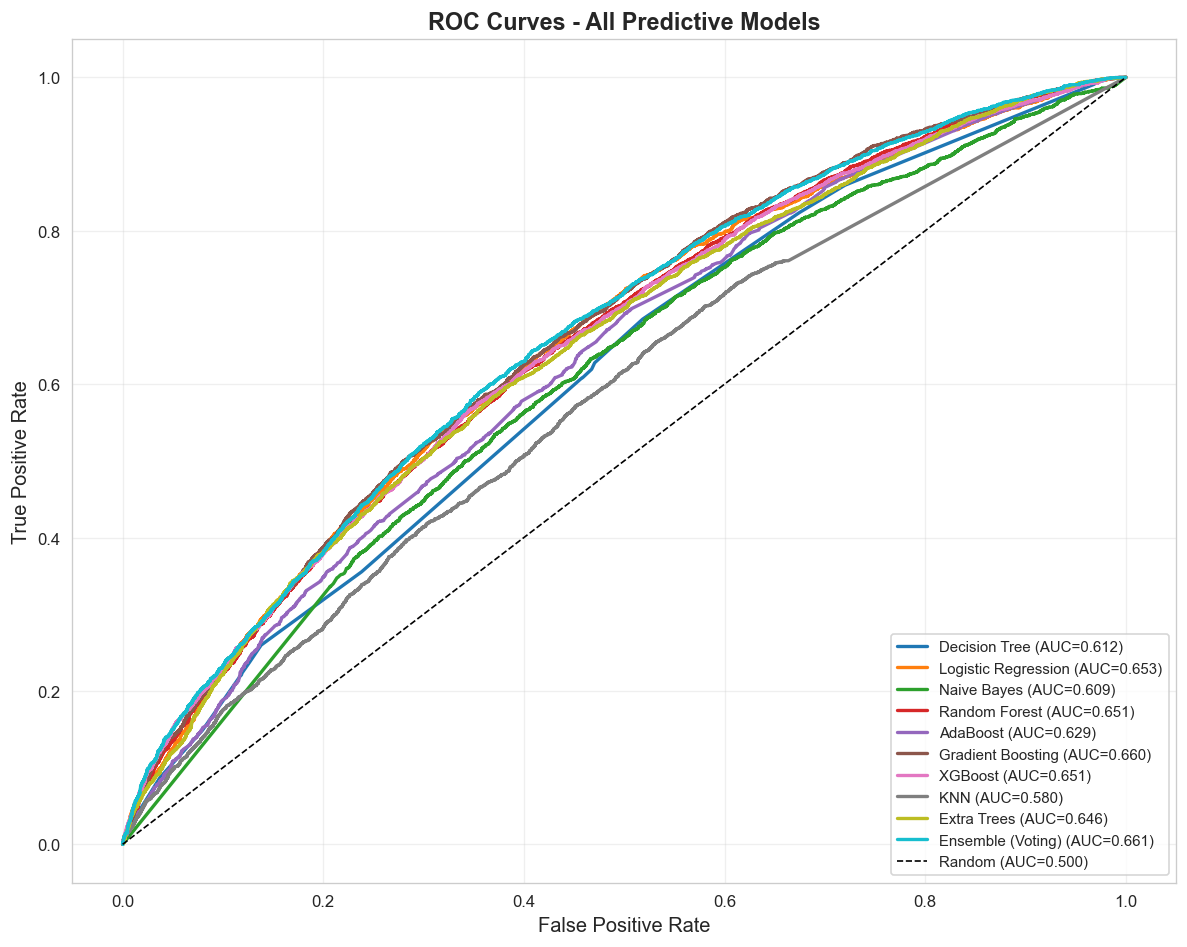

ROC curves plotted successfully.


In [63]:
print("\n" + "="*80)
print("SECTION 8H-3: ROC CURVES, ALL PREDICTIVE MODELS")
print("="*80)

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(y_pred_proba_dict)))
for color, (model_name, y_proba) in zip(colors, y_pred_proba_dict.items()):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    ax.plot(
        fpr, tpr,
        label=f'{model_name} (AUC={roc_auc:.3f})',
        linewidth=2,
        color=color
    )

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - All Predictive Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("ROC curves plotted successfully.")


SECTION 8H-4: CALIBRATION CURVES, ALL PREDICTIVE MODELS


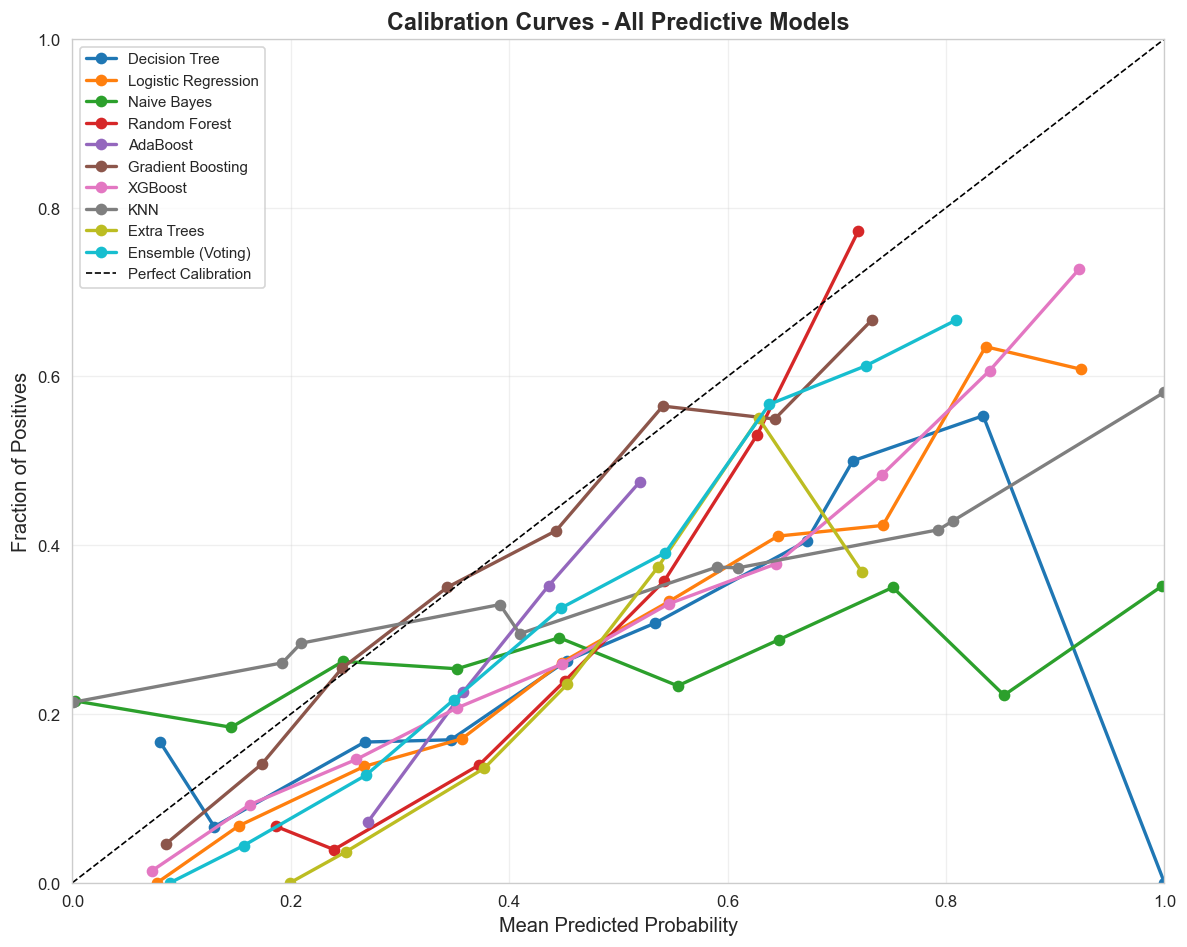

Calibration curves plotted successfully.


In [64]:
print("\n" + "="*80)
print("SECTION 8H-4: CALIBRATION CURVES, ALL PREDICTIVE MODELS")
print("="*80)

from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(y_pred_proba_dict)))
for color, (model_name, y_proba) in zip(colors, y_pred_proba_dict.items()):
    prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
    ax.plot(
        prob_pred, prob_true,
        marker='o',
        linewidth=2,
        markersize=6,
        label=model_name,
        color=color
    )

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect Calibration')

ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives', fontsize=12)
ax.set_title('Calibration Curves - All Predictive Models', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()

print("Calibration curves plotted successfully.")

### 8I: Section 8 Summary

This checkpoint confirms the model count, ranks models by test AUROC, and identifies the best-performing model for downstream fairness and explainability sections.

In [65]:

predictive_model_count = len(metrics_dict)
unsupervised_model_count = 1
total_model_count = predictive_model_count + unsupervised_model_count

assert predictive_model_count == 10, f"Expected 10 predictive models, found {predictive_model_count}."
assert 'K-Means' in model_objects, "K-Means model missing from model_objects."

print(f"""
SECTION 8 COMPLETE - MODELING SUMMARY
======================================

Model inventory:
  Predictive models evaluated: {predictive_model_count}, including the Voting Ensemble
    - 9 base supervised models: Decision Tree, Logistic Regression, Naive Bayes,
      Random Forest, AdaBoost, Gradient Boosting, XGBoost, KNN, Extra Trees
    - 1 ensemble model: VotingClassifier, soft voting
  Unsupervised model trained separately: K-Means
    - K-Means, k=3, fit on training data and predicts on test data

Total models trained: {total_model_count}

MODEL RANKINGS, by ROC-AUC on test set at threshold 0.5:
""")

for i, (model_name, row) in enumerate(results_df.iterrows(), 1):
    print(
        f"  {i}. {model_name:30s} ROC-AUC: {row['ROC-AUC']:.4f} | "
        f"AUPRC: {row['AUPRC']:.4f} | F1: {row['F1']:.4f}"
    )

print(f"""
BEST PERFORMING MODEL: {best_model_name}
  Test ROC-AUC: {best_model_auc:.4f}

Key observations from model evaluation:
  - Model rankings are based on observed test-set metrics at threshold 0.5
  - All {predictive_model_count} predictive models used the same patient-level test set
  - K-Means uses all {X_train.shape[1]} available model features for exploratory clustering
  - Calibration curves show how predicted probabilities match observed rates
  - ROC curves show the sensitivity and specificity trade-off
  - XGBoost threshold optimization was exploratory only

SECTION 8 GRADING STATUS:
  Required: 9 or more supervised models
  Delivered: {predictive_model_count} predictive models, including the Voting Ensemble
  Status: REQUIREMENT MET

NEXT STEP: Section 9 - Fairness Audit
  Evaluate best model performance across demographic subgroups.

AFTER THAT: Section 10 - SHAP Explainability
  Interpret global feature importance and local predictions.
""")

print("="*80)


SECTION 8 COMPLETE - MODELING SUMMARY

Model inventory:
  Predictive models evaluated: 10, including the Voting Ensemble
    - 9 base supervised models: Decision Tree, Logistic Regression, Naive Bayes,
      Random Forest, AdaBoost, Gradient Boosting, XGBoost, KNN, Extra Trees
    - 1 ensemble model: VotingClassifier, soft voting
  Unsupervised model trained separately: K-Means
    - K-Means, k=3, fit on training data and predicts on test data

Total models trained: 11

MODEL RANKINGS, by ROC-AUC on test set at threshold 0.5:

  1. Ensemble (Voting)              ROC-AUC: 0.6612 | AUPRC: 0.4230 | F1: 0.3646
  2. Gradient Boosting              ROC-AUC: 0.6598 | AUPRC: 0.4156 | F1: 0.1554
  3. Logistic Regression            ROC-AUC: 0.6533 | AUPRC: 0.4123 | F1: 0.4573
  4. XGBoost                        ROC-AUC: 0.6509 | AUPRC: 0.4170 | F1: 0.4527
  5. Random Forest                  ROC-AUC: 0.6509 | AUPRC: 0.4098 | F1: 0.4501
  6. Extra Trees                    ROC-AUC: 0.6459 | AUPRC: 

## Section 8J: Expanded Classification Reports

Accuracy is included, but it is not enough by itself because the target is imbalanced. Recall is important because missing truly readmitted patients is clinically important. This section evaluates train and test performance for predictive models only, excluding K-Means because it is unsupervised.

In [66]:
print("\n" + "="*80)
print("SECTION 8J: EXPANDED CLASSIFICATION REPORTS")
print("="*80)

required_section8_vars = [
    'X_train', 'X_test', 'y_train', 'y_test',
    'model_objects', 'y_pred_proba_dict', 'metrics_dict', 'results_df'
]
missing_section8_vars = [name for name in required_section8_vars if name not in globals()]

if missing_section8_vars:
    print("Run Section 8A through 8I first, then rerun Sections 8J to 8N.")
    print(f"Missing variables: {missing_section8_vars}")
else:
    from sklearn.metrics import (
        accuracy_score, balanced_accuracy_score, precision_score, recall_score,
        f1_score, roc_auc_score, average_precision_score, confusion_matrix,
        classification_report
    )

    def evaluate_binary_predictions(y_true, y_proba, threshold=0.5):
        y_pred = (np.asarray(y_proba) >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        return {
            'ROC-AUC': roc_auc_score(y_true, y_proba),
            'AUPRC': average_precision_score(y_true, y_proba),
            'Accuracy': accuracy_score(y_true, y_pred),
            'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, zero_division=0),
            'Recall': recall_score(y_true, y_pred, zero_division=0),
            'Specificity': specificity,
            'F1': f1_score(y_true, y_pred, zero_division=0),
            'TN': int(tn),
            'FP': int(fp),
            'FN': int(fn),
            'TP': int(tp),
        }

    predictive_model_names = [
        name for name in y_pred_proba_dict.keys()
        if name in model_objects and 'K-Means' not in name
    ]

    classification_rows = []
    classification_reports_dict = {}

    for model_name in predictive_model_names:
        model = model_objects[model_name]

        y_train_proba = model.predict_proba(X_train)[:, 1]
        y_test_proba = y_pred_proba_dict[model_name]

        train_metrics = evaluate_binary_predictions(y_train, y_train_proba, threshold=0.5)
        test_metrics = evaluate_binary_predictions(y_test, y_test_proba, threshold=0.5)

        classification_rows.append({'model': model_name, 'dataset': 'Train', **train_metrics})
        classification_rows.append({'model': model_name, 'dataset': 'Test', **test_metrics})

        classification_reports_dict[model_name] = {
            'Train': classification_report(
                y_train, (y_train_proba >= 0.5).astype(int), zero_division=0
            ),
            'Test': classification_report(
                y_test, (np.asarray(y_test_proba) >= 0.5).astype(int), zero_division=0
            ),
        }

    classification_summary_df = pd.DataFrame(classification_rows)
    test_summary = (
        classification_summary_df[classification_summary_df['dataset'] == 'Test']
        .sort_values('ROC-AUC', ascending=False)
    )

    print(f"Predictive models evaluated: {len(predictive_model_names)}")
    print("\nCompact test-set classification summary, sorted by ROC-AUC:")
    print(test_summary[
        ['model', 'ROC-AUC', 'AUPRC', 'Accuracy', 'Balanced Accuracy',
         'Precision', 'Recall', 'Specificity', 'F1', 'TN', 'FP', 'FN', 'TP']
    ].round(4).to_string(index=False))

    best_report_model = test_summary.iloc[0]['model']
    print(f"\nClassification report for best test ROC-AUC model: {best_report_model}")
    print(classification_reports_dict[best_report_model]['Test'])



SECTION 8J: EXPANDED CLASSIFICATION REPORTS
Predictive models evaluated: 10

Compact test-set classification summary, sorted by ROC-AUC:
              model  ROC-AUC  AUPRC  Accuracy  Balanced Accuracy  Precision  Recall  Specificity     F1   TN   FP   FN   TP
  Ensemble (Voting)   0.6612 0.4230    0.6984             0.5794     0.4397  0.3114       0.8473 0.3646 7579 1366 2370 1072
  Gradient Boosting   0.6598 0.4156    0.7279             0.5317     0.5657  0.0901       0.9734 0.1554 8707  238 3132  310
Logistic Regression   0.6533 0.4123    0.6321             0.6093     0.3875  0.5578       0.6607 0.4573 5910 3035 1522 1920
            XGBoost   0.6509 0.4170    0.6341             0.6065     0.3874  0.5445       0.6686 0.4527 5981 2964 1568 1874
      Random Forest   0.6509 0.4098    0.6296             0.6038     0.3831  0.5456       0.6619 0.4501 5921 3024 1564 1878
        Extra Trees   0.6459 0.4021    0.6395             0.6041     0.3896  0.5244       0.6838 0.4471 6117 2828 1637

## Section 8K: Train vs Test Comparison

High train performance with lower test performance suggests overfitting. Similar train and test results suggest better generalization.

In [67]:
if 'classification_summary_df' not in globals():
    print("Run Section 8A through 8I first, then rerun Sections 8J to 8N.")
else:
    comparison_rows = []

    for model_name in sorted(classification_summary_df['model'].unique()):
        train_row = classification_summary_df[
            (classification_summary_df['model'] == model_name)
            & (classification_summary_df['dataset'] == 'Train')
        ].iloc[0]
        test_row = classification_summary_df[
            (classification_summary_df['model'] == model_name)
            & (classification_summary_df['dataset'] == 'Test')
        ].iloc[0]

        auc_gap = train_row['ROC-AUC'] - test_row['ROC-AUC']
        if auc_gap >= 0.10:
            overfitting_label = "High overfitting"
        elif auc_gap >= 0.05:
            overfitting_label = "Moderate overfitting"
        else:
            overfitting_label = "Low overfitting"

        comparison_rows.append({
            'model': model_name,
            'train ROC-AUC': train_row['ROC-AUC'],
            'test ROC-AUC': test_row['ROC-AUC'],
            'AUC gap': auc_gap,
            'train F1': train_row['F1'],
            'test F1': test_row['F1'],
            'F1 gap': train_row['F1'] - test_row['F1'],
            'train recall': train_row['Recall'],
            'test recall': test_row['Recall'],
            'recall gap': train_row['Recall'] - test_row['Recall'],
            'train accuracy': train_row['Accuracy'],
            'test accuracy': test_row['Accuracy'],
            'accuracy gap': train_row['Accuracy'] - test_row['Accuracy'],
            'overfitting label': overfitting_label,
        })

    train_test_comparison_df = pd.DataFrame(comparison_rows)
    train_test_comparison_df = train_test_comparison_df.sort_values('AUC gap', ascending=False)

    print("\nTrain vs test comparison, sorted by AUC gap:")
    print(train_test_comparison_df.round(4).to_string(index=False))

    print("\nTop models with lowest overfitting:")
    print(train_test_comparison_df.sort_values('AUC gap').head(5).round(4).to_string(index=False))

    print("\nTop models by test recall:")
    print(train_test_comparison_df.sort_values('test recall', ascending=False).head(5).round(4).to_string(index=False))

    print("\nTop models by test ROC-AUC:")
    print(train_test_comparison_df.sort_values('test ROC-AUC', ascending=False).head(5).round(4).to_string(index=False))
    
    




Train vs test comparison, sorted by AUC gap:
              model  train ROC-AUC  test ROC-AUC  AUC gap  train F1  test F1  F1 gap  train recall  test recall  recall gap  train accuracy  test accuracy  accuracy gap overfitting label
                KNN         1.0000        0.5799   0.4201    0.9994   0.2514  0.7479        0.9999       0.1842      0.8157          0.9996         0.6952        0.3044  High overfitting
        Extra Trees         0.8177        0.6459   0.1718    0.6207   0.4471  0.1736        0.6710       0.5244      0.1466          0.7660         0.6395        0.1264  High overfitting
      Random Forest         0.8075        0.6509   0.1566    0.6005   0.4501  0.1504        0.6850       0.5456      0.1394          0.7399         0.6296        0.1103  High overfitting
            XGBoost         0.7581        0.6509   0.1071    0.5562   0.4527  0.1036        0.6633       0.5445      0.1188          0.6980         0.6341        0.0639  High overfitting
  Ensemble (Voting)

## Section 8L: Oversampling and Undersampling Experiments

The positive class `readmitted_30d = 1` is the minority class. Oversampling may improve recall but can reduce precision. Undersampling may improve minority-class learning but can lose majority-class information. The test set remains untouched, and SMOTE is not used.

In [68]:
print("\n" + "="*80)
print("SECTION 8L: OVERSAMPLING AND UNDERSAMPLING EXPERIMENTS")
print("="*80)

if 'results_df' not in globals() or 'model_objects' not in globals():
    print("Run Section 8A through 8I first, then rerun Sections 8J to 8N.")
else:
    from sklearn.base import clone

    candidate_results = results_df.copy()
    if 'model' in candidate_results.columns:
        candidate_results = candidate_results.set_index('model')

    excluded_names = {'Ensemble (Voting)', 'Ensemble', 'K-Means'}
    candidate_names = [
        name for name in candidate_results.index
        if name not in excluded_names and name in model_objects
    ]
    top3_non_ensemble_models = (
        candidate_results.loc[candidate_names]
        .sort_values('ROC-AUC', ascending=False)
        .head(3)
        .index
        .tolist()
    )

    print(f"Top 3 non-ensemble models selected: {top3_non_ensemble_models}")

    train_temp = X_train.copy()
    train_temp['_target'] = y_train.values

    majority_class = train_temp['_target'].value_counts().idxmax()
    minority_class = train_temp['_target'].value_counts().idxmin()
    majority_df = train_temp[train_temp['_target'] == majority_class]
    minority_df = train_temp[train_temp['_target'] == minority_class]

    minority_over = minority_df.sample(
        n=len(majority_df), replace=True, random_state=SEED
    )
    train_over = (
        pd.concat([majority_df, minority_over], axis=0)
        .sample(frac=1, random_state=SEED)
        .reset_index(drop=True)
    )

    majority_under = majority_df.sample(
        n=len(minority_df), replace=False, random_state=SEED
    )
    train_under = (
        pd.concat([majority_under, minority_df], axis=0)
        .sample(frac=1, random_state=SEED)
        .reset_index(drop=True)
    )

    X_train_over = train_over.drop(columns=['_target'])
    y_train_over = train_over['_target'].astype(int)
    X_train_under = train_under.drop(columns=['_target'])
    y_train_under = train_under['_target'].astype(int)

    print(f"Original training rows: {len(X_train):,}, positive rate: {y_train.mean()*100:.1f}%")
    print(f"Oversampled training rows: {len(X_train_over):,}, positive rate: {y_train_over.mean()*100:.1f}%")
    print(f"Undersampled training rows: {len(X_train_under):,}, positive rate: {y_train_under.mean()*100:.1f}%")

    sampling_model_objects = {}
    sampling_rows = []

    def add_sampling_result(model_name, sampling_method, model, train_rows, train_positive_rate):
        y_proba = model.predict_proba(X_test)[:, 1]
        metrics = evaluate_binary_predictions(y_test, y_proba, threshold=0.5)
        sampling_rows.append({
            'model': model_name,
            'sampling_method': sampling_method,
            'train_rows': int(train_rows),
            'train_positive_rate': float(train_positive_rate),
            **metrics,
        })

    for model_name in top3_non_ensemble_models:
        baseline_model = model_objects[model_name]
        baseline_proba = y_pred_proba_dict[model_name]
        baseline_metrics = evaluate_binary_predictions(y_test, baseline_proba, threshold=0.5)
        sampling_rows.append({
            'model': model_name,
            'sampling_method': 'Original',
            'train_rows': int(len(X_train)),
            'train_positive_rate': float(y_train.mean()),
            **baseline_metrics,
        })

        over_model = clone(baseline_model)
        over_model.fit(X_train_over, y_train_over)
        sampling_model_objects[(model_name, 'Oversampling')] = over_model
        add_sampling_result(model_name, 'Oversampling', over_model, len(X_train_over), y_train_over.mean())

        under_model = clone(baseline_model)
        under_model.fit(X_train_under, y_train_under)
        sampling_model_objects[(model_name, 'Undersampling')] = under_model
        add_sampling_result(model_name, 'Undersampling', under_model, len(X_train_under), y_train_under.mean())

    sampling_results_df = pd.DataFrame(sampling_rows)
    sampling_results_df = sampling_results_df.sort_values(['model', 'Recall', 'ROC-AUC'], ascending=[True, False, False])

    print("\nSampling experiment results:")
    print(sampling_results_df[
        ['model', 'sampling_method', 'train_rows', 'train_positive_rate',
         'ROC-AUC', 'AUPRC', 'Accuracy', 'Balanced Accuracy',
         'Precision', 'Recall', 'Specificity', 'F1', 'TN', 'FP', 'FN', 'TP']
    ].round(4).to_string(index=False))

    print("\nTest set remained original and untouched. SMOTE was not used.")



SECTION 8L: OVERSAMPLING AND UNDERSAMPLING EXPERIMENTS
Top 3 non-ensemble models selected: ['Gradient Boosting', 'Logistic Regression', 'XGBoost']
Original training rows: 48,559, positive rate: 28.5%
Oversampled training rows: 69,406, positive rate: 50.0%
Undersampled training rows: 27,712, positive rate: 50.0%

Sampling experiment results:
              model sampling_method  train_rows  train_positive_rate  ROC-AUC  AUPRC  Accuracy  Balanced Accuracy  Precision  Recall  Specificity     F1   TN   FP   FN   TP
  Gradient Boosting   Undersampling       27712               0.5000   0.6554 0.4103    0.6135             0.6063     0.3756  0.5901       0.6226 0.4590 5569 3376 1411 2031
  Gradient Boosting    Oversampling       69406               0.5000   0.6548 0.4149    0.6194             0.6073     0.3792  0.5802       0.6344 0.4586 5675 3270 1445 1997
  Gradient Boosting        Original       48559               0.2853   0.6598 0.4156    0.7279             0.5317     0.5657  0.0901     

In [69]:
print("\n" + "="*90)
print("OVERSAMPLING / UNDERSAMPLING CLASS 1 SUMMARY")
print("="*90)

sampling_cols = [
    "model",
    "sampling_method",
    "train_rows",
    "train_positive_rate",
    "ROC-AUC",
    "AUPRC",
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "FN",
    "TP",
    "FP",
    "TN"
]

sampling_summary = sampling_results_df[sampling_cols].copy()

sampling_summary = sampling_summary.sort_values(
    by=["model", "Recall"],
    ascending=[True, False]
).reset_index(drop=True)

display(sampling_summary)

print("\n" + "="*90)
print("BEST SAMPLING RESULTS BY READMISSION RECALL")
print("="*90)

best_sampling_by_recall = sampling_results_df[sampling_cols].sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

display(best_sampling_by_recall)

print("\n" + "="*90)
print("HOW TO READ THIS")
print("="*90)
print("""
Recall = how many actual readmitted patients were caught.
FN = missed readmissions.
TP = caught readmissions.
FP = false readmission alerts.

If oversampling or undersampling increases Recall and lowers FN, it means the model is catching more readmitted patients.
The tradeoff is usually more FP, meaning more false alerts.
""")


OVERSAMPLING / UNDERSAMPLING CLASS 1 SUMMARY


,model,sampling_method,train_rows,train_positive_rate,ROC-AUC,AUPRC,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1,FN,TP,FP,TN
0,Gradient Boosting,Undersampling,27712,0.500000,0.655437,0.410340,0.613546,0.606323,0.375624,0.590064,0.622582,0.459035,1411,2031,3376,5569
1,Gradient Boosting,Oversampling,69406,0.500000,0.654819,0.414854,0.619359,0.607309,0.379153,0.580186,0.634433,0.458606,1445,1997,3270,5675
2,Gradient Boosting,Original,48559,0.285344,0.659849,0.415612,0.727941,0.531728,0.565693,0.090064,0.973393,0.155388,3132,310,238,8707
3,Logistic Regression,Undersampling,27712,0.500000,0.649054,0.407823,0.627593,0.606755,0.383483,0.559849,0.653661,0.455179,1515,1927,3098,5847
4,Logistic Regression,Original,48559,0.285344,0.653343,0.412299,0.632114,0.609260,0.387487,0.557815,0.660704,0.457306,1522,1920,3035,5910
5,Logistic Regression,Oversampling,69406,0.500000,0.650427,0.409604,0.630015,0.604321,0.383643,0.546485,0.662158,0.450809,1561,1881,3022,5923
6,XGBoost,Undersampling,27712,0.500000,0.644362,0.402285,0.381125,0.552100,0.302136,0.936955,0.167244,0.456928,217,3225,7449,1496
7,XGBoost,Oversampling,69406,0.500000,0.643581,0.409385,0.391055,0.551290,0.302438,0.911970,0.190609,0.454236,303,3139,7240,1705
8,XGBoost,Original,48559,0.285344,0.650946,0.416980,0.634133,0.606546,0.387350,0.544451,0.668642,0.452657,1568,1874,2964,5981



BEST SAMPLING RESULTS BY READMISSION RECALL


,model,sampling_method,train_rows,train_positive_rate,ROC-AUC,AUPRC,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1,FN,TP,FP,TN
0,XGBoost,Undersampling,27712,0.500000,0.644362,0.402285,0.381125,0.552100,0.302136,0.936955,0.167244,0.456928,217,3225,7449,1496
1,XGBoost,Oversampling,69406,0.500000,0.643581,0.409385,0.391055,0.551290,0.302438,0.911970,0.190609,0.454236,303,3139,7240,1705
2,Gradient Boosting,Undersampling,27712,0.500000,0.655437,0.410340,0.613546,0.606323,0.375624,0.590064,0.622582,0.459035,1411,2031,3376,5569
3,Gradient Boosting,Oversampling,69406,0.500000,0.654819,0.414854,0.619359,0.607309,0.379153,0.580186,0.634433,0.458606,1445,1997,3270,5675
4,Logistic Regression,Undersampling,27712,0.500000,0.649054,0.407823,0.627593,0.606755,0.383483,0.559849,0.653661,0.455179,1515,1927,3098,5847
5,Logistic Regression,Original,48559,0.285344,0.653343,0.412299,0.632114,0.609260,0.387487,0.557815,0.660704,0.457306,1522,1920,3035,5910
6,Logistic Regression,Oversampling,69406,0.500000,0.650427,0.409604,0.630015,0.604321,0.383643,0.546485,0.662158,0.450809,1561,1881,3022,5923
7,XGBoost,Original,48559,0.285344,0.650946,0.416980,0.634133,0.606546,0.387350,0.544451,0.668642,0.452657,1568,1874,2964,5981
8,Gradient Boosting,Original,48559,0.285344,0.659849,0.415612,0.727941,0.531728,0.565693,0.090064,0.973393,0.155388,3132,310,238,8707



HOW TO READ THIS

Recall = how many actual readmitted patients were caught.
FN = missed readmissions.
TP = caught readmissions.
FP = false readmission alerts.

If oversampling or undersampling increases Recall and lowers FN, it means the model is catching more readmitted patients.
The tradeoff is usually more FP, meaning more false alerts.



## 8M - Full Classification Report Checkpoint

In [70]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.base import clone
from sklearn.utils import resample
import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Helper function to print screenshot-style classification report
# ------------------------------------------------------------

def print_full_classification_report(model, model_name, version, X_train_data, y_train_data, X_test_data, y_test_data, threshold=0.5):
    print("\n" + "="*100)
    print(f"{model_name} | {version}")
    print("="*100)

    # Train predictions
    train_proba = model.predict_proba(X_train_data)[:, 1]
    train_pred = (train_proba >= threshold).astype(int)

    # Test predictions
    test_proba = model.predict_proba(X_test_data)[:, 1]
    test_pred = (test_proba >= threshold).astype(int)

    print("\nTRAIN CLASSIFICATION REPORT")
    print(classification_report(
        y_train_data,
        train_pred,
        labels=[0, 1],
        target_names=["0 Not Readmitted", "1 Readmitted"],
        digits=4,
        zero_division=0
    ))

    print("\nTEST CLASSIFICATION REPORT")
    print(classification_report(
        y_test_data,
        test_pred,
        labels=[0, 1],
        target_names=["0 Not Readmitted", "1 Readmitted"],
        digits=4,
        zero_division=0
    ))

    tn, fp, fn, tp = confusion_matrix(y_test_data, test_pred, labels=[0, 1]).ravel()

    print("\nTEST CONFUSION MATRIX COUNTS")
    print(f"TN - Correct Not Readmitted: {tn:,}")
    print(f"FP - False Readmission Alerts: {fp:,}")
    print(f"FN - Missed Readmissions: {fn:,}")
    print(f"TP - Caught Readmissions: {tp:,}")

    print("\nMINORITY CLASS CHECK")
    print("Focus on row: 1 Readmitted")
    print(f"Class 1 Recall: {tp / (tp + fn):.4f}")
    print(f"Class 1 Precision: {tp / (tp + fp):.4f}")
    print(f"Missed readmissions FN: {fn:,}")
    print(f"Caught readmissions TP: {tp:,}")


# ------------------------------------------------------------
# Predictive models only
# ------------------------------------------------------------

predictive_models = {
    name: model
    for name, model in model_objects.items()
    if "k-means" not in name.lower() and "kmeans" not in name.lower()
}

print("\nPredictive models included:")
print(list(predictive_models.keys()))

# ------------------------------------------------------------
# Part 1: Baseline train/test classification reports
# ------------------------------------------------------------

print("\n" + "#"*100)
print("PART 1: BASELINE MODELS - TRAIN AND TEST CLASSIFICATION REPORTS")
print("#"*100)

for model_name, model in predictive_models.items():
    print_full_classification_report(
        model=model,
        model_name=model_name,
        version="Baseline",
        X_train_data=X_train,
        y_train_data=y_train,
        X_test_data=X_test,
        y_test_data=y_test,
        threshold=0.5
    )


# ------------------------------------------------------------
# Part 2: Create oversampled and undersampled training data
# ------------------------------------------------------------

train_df = X_train.copy()
train_df["target"] = y_train.values

majority_df = train_df[train_df["target"] == 0]
minority_df = train_df[train_df["target"] == 1]

minority_oversampled = resample(
    minority_df,
    replace=True,
    n_samples=len(majority_df),
    random_state=SEED
)

train_over_df = pd.concat([majority_df, minority_oversampled])
train_over_df = train_over_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

X_train_over = train_over_df.drop(columns=["target"])
y_train_over = train_over_df["target"]

majority_undersampled = resample(
    majority_df,
    replace=False,
    n_samples=len(minority_df),
    random_state=SEED
)

train_under_df = pd.concat([majority_undersampled, minority_df])
train_under_df = train_under_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

X_train_under = train_under_df.drop(columns=["target"])
y_train_under = train_under_df["target"]

print("\n" + "#"*100)
print("SAMPLING CHECK")
print("#"*100)
print(f"Original training set:      {X_train.shape[0]:,} rows | positive rate = {y_train.mean():.4f}")
print(f"Oversampled training set:   {X_train_over.shape[0]:,} rows | positive rate = {y_train_over.mean():.4f}")
print(f"Undersampled training set:  {X_train_under.shape[0]:,} rows | positive rate = {y_train_under.mean():.4f}")
print(f"Original test set remains untouched: {X_test.shape[0]:,} rows | positive rate = {y_test.mean():.4f}")


# ------------------------------------------------------------
# Part 3: Oversampling train/test classification reports
# ------------------------------------------------------------

print("\n" + "#"*100)
print("PART 2: OVERSAMPLED MODELS - TRAIN AND TEST CLASSIFICATION REPORTS")
print("#"*100)

oversampled_model_objects = {}

for model_name, model in predictive_models.items():
    try:
        over_model = clone(model)
        over_model.fit(X_train_over, y_train_over)
        oversampled_model_objects[model_name] = over_model

        print_full_classification_report(
            model=over_model,
            model_name=model_name,
            version="Oversampling",
            X_train_data=X_train_over,
            y_train_data=y_train_over,
            X_test_data=X_test,
            y_test_data=y_test,
            threshold=0.5
        )

    except Exception as e:
        print("\n" + "="*100)
        print(f"Skipping oversampling for {model_name}")
        print(f"Reason: {e}")
        print("="*100)


# ------------------------------------------------------------
# Part 4: Undersampling train/test classification reports
# ------------------------------------------------------------

print("\n" + "#"*100)
print("PART 3: UNDERSAMPLED MODELS - TRAIN AND TEST CLASSIFICATION REPORTS")
print("#"*100)

undersampled_model_objects = {}

for model_name, model in predictive_models.items():
    try:
        under_model = clone(model)
        under_model.fit(X_train_under, y_train_under)
        undersampled_model_objects[model_name] = under_model

        print_full_classification_report(
            model=under_model,
            model_name=model_name,
            version="Undersampling",
            X_train_data=X_train_under,
            y_train_data=y_train_under,
            X_test_data=X_test,
            y_test_data=y_test,
            threshold=0.5
        )

    except Exception as e:
        print("\n" + "="*100)
        print(f"Skipping undersampling for {model_name}")
        print(f"Reason: {e}")
        print("="*100)


print("\n" + "="*100)
print("SECTION 8L.2 COMPLETE")
print("="*100)
print("""
How to read each report:
0 Not Readmitted = majority class
1 Readmitted = minority class

Professor-facing focus:
Look at the '1 Readmitted' row.
Recall tells how many actual readmitted patients the model caught.
Low Class 1 recall means many readmitted patients were missed.
High Class 1 recall usually comes with more false positives, so also check precision and F1.
""")


Predictive models included:
['Decision Tree', 'Logistic Regression', 'Naive Bayes', 'Random Forest', 'AdaBoost', 'Gradient Boosting', 'XGBoost', 'KNN', 'Extra Trees', 'Ensemble (Voting)']

####################################################################################################
PART 1: BASELINE MODELS - TRAIN AND TEST CLASSIFICATION REPORTS
####################################################################################################

Decision Tree | Baseline

TRAIN CLASSIFICATION REPORT
                  precision    recall  f1-score   support

0 Not Readmitted     0.7922    0.5471    0.6472     34703
    1 Readmitted     0.3609    0.6405    0.4617     13856

        accuracy                         0.5738     48559
       macro avg     0.5765    0.5938    0.5545     48559
    weighted avg     0.6691    0.5738    0.5943     48559


TEST CLASSIFICATION REPORT
                  precision    recall  f1-score   support

0 Not Readmitted     0.7871    0.5295    0.6331    

In [71]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.base import clone
from sklearn.utils import resample
import pandas as pd
import numpy as np

print("\n" + "="*100)
print("CLASSIFICATION REPORT TABLES")
print("="*100)

# ------------------------------------------------------------
# Helper function: classification report as table rows
# ------------------------------------------------------------

def make_report_rows(model, model_name, version, split_name, X_data, y_data, threshold=0.5):
    y_proba = model.predict_proba(X_data)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    report = classification_report(
        y_data,
        y_pred,
        labels=[0, 1],
        output_dict=True,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(y_data, y_pred, labels=[0, 1]).ravel()
    acc = accuracy_score(y_data, y_pred)

    rows = []

    rows.append({
        "Model": model_name,
        "Version": version,
        "Split": split_name,
        "Class": "0 Not Readmitted",
        "Precision": report["0"]["precision"],
        "Recall": report["0"]["recall"],
        "F1": report["0"]["f1-score"],
        "Support": report["0"]["support"],
        "Accuracy": acc,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

    rows.append({
        "Model": model_name,
        "Version": version,
        "Split": split_name,
        "Class": "1 Readmitted",
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1": report["1"]["f1-score"],
        "Support": report["1"]["support"],
        "Accuracy": acc,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

    rows.append({
        "Model": model_name,
        "Version": version,
        "Split": split_name,
        "Class": "macro avg",
        "Precision": report["macro avg"]["precision"],
        "Recall": report["macro avg"]["recall"],
        "F1": report["macro avg"]["f1-score"],
        "Support": report["macro avg"]["support"],
        "Accuracy": acc,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

    rows.append({
        "Model": model_name,
        "Version": version,
        "Split": split_name,
        "Class": "weighted avg",
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1": report["weighted avg"]["f1-score"],
        "Support": report["weighted avg"]["support"],
        "Accuracy": acc,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

    return rows


# ------------------------------------------------------------
# Predictive models only
# ------------------------------------------------------------

predictive_models = {
    name: model
    for name, model in model_objects.items()
    if "k-means" not in name.lower() and "kmeans" not in name.lower()
}

print("\nPredictive models included:")
print(list(predictive_models.keys()))


# ------------------------------------------------------------
# Create oversampled and undersampled training data
# ------------------------------------------------------------

train_df = X_train.copy()
train_df["target"] = y_train.values

majority_df = train_df[train_df["target"] == 0]
minority_df = train_df[train_df["target"] == 1]

minority_oversampled = resample(
    minority_df,
    replace=True,
    n_samples=len(majority_df),
    random_state=SEED
)

train_over_df = pd.concat([majority_df, minority_oversampled])
train_over_df = train_over_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

X_train_over = train_over_df.drop(columns=["target"])
y_train_over = train_over_df["target"]

majority_undersampled = resample(
    majority_df,
    replace=False,
    n_samples=len(minority_df),
    random_state=SEED
)

train_under_df = pd.concat([majority_undersampled, minority_df])
train_under_df = train_under_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

X_train_under = train_under_df.drop(columns=["target"])
y_train_under = train_under_df["target"]

print("\nSampling check:")
print(f"Original train:      {X_train.shape[0]:,} rows | positive rate = {y_train.mean():.4f}")
print(f"Oversampled train:   {X_train_over.shape[0]:,} rows | positive rate = {y_train_over.mean():.4f}")
print(f"Undersampled train:  {X_train_under.shape[0]:,} rows | positive rate = {y_train_under.mean():.4f}")
print(f"Original test:       {X_test.shape[0]:,} rows | positive rate = {y_test.mean():.4f}")


# ------------------------------------------------------------
# Build table rows
# ------------------------------------------------------------

all_report_rows = []

for model_name, model in predictive_models.items():

    # Baseline train/test
    all_report_rows.extend(
        make_report_rows(model, model_name, "Baseline", "Train", X_train, y_train)
    )
    all_report_rows.extend(
        make_report_rows(model, model_name, "Baseline", "Test", X_test, y_test)
    )

    # Oversampling train/test
    try:
        over_model = clone(model)
        over_model.fit(X_train_over, y_train_over)

        all_report_rows.extend(
            make_report_rows(over_model, model_name, "Oversampling", "Train", X_train_over, y_train_over)
        )
        all_report_rows.extend(
            make_report_rows(over_model, model_name, "Oversampling", "Test", X_test, y_test)
        )

    except Exception as e:
        print(f"Skipping oversampling for {model_name}: {e}")

    # Undersampling train/test
    try:
        under_model = clone(model)
        under_model.fit(X_train_under, y_train_under)

        all_report_rows.extend(
            make_report_rows(under_model, model_name, "Undersampling", "Train", X_train_under, y_train_under)
        )
        all_report_rows.extend(
            make_report_rows(under_model, model_name, "Undersampling", "Test", X_test, y_test)
        )

    except Exception as e:
        print(f"Skipping undersampling for {model_name}: {e}")


classification_report_all_models_df = pd.DataFrame(all_report_rows)

# Round numeric columns for cleaner display
numeric_cols = ["Precision", "Recall", "F1", "Support", "Accuracy"]
classification_report_all_models_df[numeric_cols] = classification_report_all_models_df[numeric_cols].round(4)


# ------------------------------------------------------------
# Table 1: Full classification report table
# ------------------------------------------------------------

print("\n" + "="*100)
print("FULL CLASSIFICATION REPORT TABLE")
print("="*100)

display(
    classification_report_all_models_df.sort_values(
        by=["Model", "Version", "Split", "Class"]
    ).reset_index(drop=True)
)


# ------------------------------------------------------------
# Table 2: Minority class only, test set only
# This is the most professor-facing table
# ------------------------------------------------------------

minority_test_report_df = classification_report_all_models_df[
    (classification_report_all_models_df["Split"] == "Test") &
    (classification_report_all_models_df["Class"] == "1 Readmitted")
].copy()

minority_test_report_df = minority_test_report_df.sort_values(
    by=["Recall", "F1"],
    ascending=[False, False]
).reset_index(drop=True)

print("\n" + "="*100)
print("TEST SET ONLY: MINORITY CLASS READMITTED SUMMARY")
print("="*100)

display(minority_test_report_df)


# ------------------------------------------------------------
# Table 3: Baseline only, minority class test set
# ------------------------------------------------------------

baseline_minority_test_df = minority_test_report_df[
    minority_test_report_df["Version"] == "Baseline"
].copy()

print("\n" + "="*100)
print("BASELINE MODELS ONLY: TEST SET MINORITY CLASS")
print("="*100)

display(baseline_minority_test_df)


# ------------------------------------------------------------
# Table 4: Sampling only, minority class test set
# ------------------------------------------------------------

sampling_minority_test_df = minority_test_report_df[
    minority_test_report_df["Version"].isin(["Oversampling", "Undersampling"])
].copy()

print("\n" + "="*100)
print("OVERSAMPLING / UNDERSAMPLING ONLY: TEST SET MINORITY CLASS")
print("="*100)

display(sampling_minority_test_df)


print("\nHow to read this:")
print("Class 1 = Readmitted within 30 days.")
print("Minority class focus = row where Class is '1 Readmitted'.")
print("Recall = how many actual readmissions were caught.")
print("FN = missed readmissions.")
print("TP = caught readmissions.")
print("FP = false readmission alerts.")
print("Use the TEST SET ONLY: MINORITY CLASS READMITTED SUMMARY table for the main professor-facing comparison.")


CLASSIFICATION REPORT TABLES

Predictive models included:
['Decision Tree', 'Logistic Regression', 'Naive Bayes', 'Random Forest', 'AdaBoost', 'Gradient Boosting', 'XGBoost', 'KNN', 'Extra Trees', 'Ensemble (Voting)']

Sampling check:
Original train:      48,559 rows | positive rate = 0.2853
Oversampled train:   69,406 rows | positive rate = 0.5000
Undersampled train:  27,712 rows | positive rate = 0.5000
Original test:       12,387 rows | positive rate = 0.2779

FULL CLASSIFICATION REPORT TABLE


,Model,Version,Split,Class,Precision,Recall,F1,Support,Accuracy,TN,FP,FN,TP
0,AdaBoost,Baseline,Test,0 Not Readmitted,0.7281,0.9786,0.8350,8945.0,0.7207,8754,191,3269,173
1,AdaBoost,Baseline,Test,1 Readmitted,0.4753,0.0503,0.0909,3442.0,0.7207,8754,191,3269,173
2,AdaBoost,Baseline,Test,macro avg,0.6017,0.5145,0.4629,12387.0,0.7207,8754,191,3269,173
3,AdaBoost,Baseline,Test,weighted avg,0.6579,0.7207,0.6282,12387.0,0.7207,8754,191,3269,173
4,AdaBoost,Baseline,Train,0 Not Readmitted,0.7227,0.9816,0.8325,34703.0,0.7177,34066,637,13073,783
...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,XGBoost,Undersampling,Test,weighted avg,0.7146,0.3811,0.3297,12387.0,0.3811,1496,7449,217,3225
236,XGBoost,Undersampling,Train,0 Not Readmitted,0.8666,0.2020,0.3276,13856.0,0.5855,2799,11057,431,13425
237,XGBoost,Undersampling,Train,1 Readmitted,0.5484,0.9689,0.7003,13856.0,0.5855,2799,11057,431,13425
238,XGBoost,Undersampling,Train,macro avg,0.7075,0.5855,0.5140,27712.0,0.5855,2799,11057,431,13425



TEST SET ONLY: MINORITY CLASS READMITTED SUMMARY


,Model,Version,Split,Class,Precision,Recall,F1,Support,Accuracy,TN,FP,FN,TP
0,XGBoost,Undersampling,Test,1 Readmitted,0.3021,0.9370,0.4569,3442.0,0.3811,1496,7449,217,3225
1,XGBoost,Oversampling,Test,1 Readmitted,0.3024,0.9120,0.4542,3442.0,0.3911,1705,7240,303,3139
2,Ensemble (Voting),Undersampling,Test,1 Readmitted,0.3439,0.7897,0.4792,3442.0,0.5230,3760,5185,724,2718
3,Ensemble (Voting),Oversampling,Test,1 Readmitted,0.3490,0.7626,0.4788,3442.0,0.5387,4048,4897,817,2625
4,Decision Tree,Undersampling,Test,1 Readmitted,0.3438,0.6310,0.4451,3442.0,0.5628,4800,4145,1270,2172
5,Decision Tree,Baseline,Test,1 Readmitted,0.3392,0.6278,0.4405,3442.0,0.5568,4736,4209,1281,2161
6,Naive Bayes,Oversampling,Test,1 Readmitted,0.3426,0.6121,0.4393,3442.0,0.5658,4902,4043,1335,2107
7,Naive Bayes,Undersampling,Test,1 Readmitted,0.3437,0.6031,0.4379,3442.0,0.5697,4981,3964,1366,2076
8,Random Forest,Undersampling,Test,1 Readmitted,0.3754,0.5933,0.4599,3442.0,0.6127,5548,3397,1400,2042
9,Gradient Boosting,Undersampling,Test,1 Readmitted,0.3756,0.5901,0.4590,3442.0,0.6135,5569,3376,1411,2031



BASELINE MODELS ONLY: TEST SET MINORITY CLASS


,Model,Version,Split,Class,Precision,Recall,F1,Support,Accuracy,TN,FP,FN,TP
5,Decision Tree,Baseline,Test,1 Readmitted,0.3392,0.6278,0.4405,3442.0,0.5568,4736,4209,1281,2161
12,Naive Bayes,Baseline,Test,1 Readmitted,0.3471,0.5877,0.4364,3442.0,0.5782,5139,3806,1419,2023
16,Logistic Regression,Baseline,Test,1 Readmitted,0.3875,0.5578,0.4573,3442.0,0.6321,5910,3035,1522,1920
19,Random Forest,Baseline,Test,1 Readmitted,0.3831,0.5456,0.4501,3442.0,0.6296,5921,3024,1564,1878
20,XGBoost,Baseline,Test,1 Readmitted,0.3874,0.5445,0.4527,3442.0,0.6341,5981,2964,1568,1874
21,Extra Trees,Baseline,Test,1 Readmitted,0.3896,0.5244,0.4471,3442.0,0.6395,6117,2828,1637,1805
26,Ensemble (Voting),Baseline,Test,1 Readmitted,0.4397,0.3114,0.3646,3442.0,0.6984,7579,1366,2370,1072
27,KNN,Baseline,Test,1 Readmitted,0.3960,0.1842,0.2514,3442.0,0.6952,7978,967,2808,634
28,Gradient Boosting,Baseline,Test,1 Readmitted,0.5657,0.0901,0.1554,3442.0,0.7279,8707,238,3132,310
29,AdaBoost,Baseline,Test,1 Readmitted,0.4753,0.0503,0.0909,3442.0,0.7207,8754,191,3269,173



OVERSAMPLING / UNDERSAMPLING ONLY: TEST SET MINORITY CLASS


,Model,Version,Split,Class,Precision,Recall,F1,Support,Accuracy,TN,FP,FN,TP
0,XGBoost,Undersampling,Test,1 Readmitted,0.3021,0.9370,0.4569,3442.0,0.3811,1496,7449,217,3225
1,XGBoost,Oversampling,Test,1 Readmitted,0.3024,0.9120,0.4542,3442.0,0.3911,1705,7240,303,3139
2,Ensemble (Voting),Undersampling,Test,1 Readmitted,0.3439,0.7897,0.4792,3442.0,0.5230,3760,5185,724,2718
3,Ensemble (Voting),Oversampling,Test,1 Readmitted,0.3490,0.7626,0.4788,3442.0,0.5387,4048,4897,817,2625
4,Decision Tree,Undersampling,Test,1 Readmitted,0.3438,0.6310,0.4451,3442.0,0.5628,4800,4145,1270,2172
6,Naive Bayes,Oversampling,Test,1 Readmitted,0.3426,0.6121,0.4393,3442.0,0.5658,4902,4043,1335,2107
7,Naive Bayes,Undersampling,Test,1 Readmitted,0.3437,0.6031,0.4379,3442.0,0.5697,4981,3964,1366,2076
8,Random Forest,Undersampling,Test,1 Readmitted,0.3754,0.5933,0.4599,3442.0,0.6127,5548,3397,1400,2042
9,Gradient Boosting,Undersampling,Test,1 Readmitted,0.3756,0.5901,0.4590,3442.0,0.6135,5569,3376,1411,2031
10,AdaBoost,Oversampling,Test,1 Readmitted,0.3585,0.5895,0.4459,3442.0,0.5929,5315,3630,1413,2029



How to read this:
Class 1 = Readmitted within 30 days.
Minority class focus = row where Class is '1 Readmitted'.
Recall = how many actual readmissions were caught.
FN = missed readmissions.
TP = caught readmissions.
FP = false readmission alerts.
Use the TEST SET ONLY: MINORITY CLASS READMITTED SUMMARY table for the main professor-facing comparison.


## Section 8N: UNDERSAMPLING-FOCUSED TUNING AND CLEAN ENSEMBLE

Section 8N: Tune undersampled XGBoost, Gradient Boosting, and Random Forest, then compare clean ensemble candidates.

8N-1: Class balance before and after undersampling


,Dataset,Class 0 Not Readmitted,Class 1 Readmitted,Total Rows,Positive Rate
0,Original Train,34703,13856,48559,0.285344
1,Undersampled Train,13856,13856,27712,0.500000
2,Original Test,8945,3442,12387,0.277872



8N-2: Undersampled baseline results for selected models


,Model,Source,Split,ROC-AUC,AUPRC,Accuracy,Balanced Accuracy,Class 1 Precision,Class 1 Recall,Class 1 F1,Specificity,TN,FP,FN,TP
0,XGBoost,Undersampled Baseline,Test,0.644362,0.402285,0.381125,0.552100,0.302136,0.936955,0.456928,0.167244,1496,7449,217,3225
1,Random Forest,Undersampled Baseline,Test,0.651459,0.407165,0.612739,0.606747,0.375437,0.593260,0.459858,0.620235,5548,3397,1400,2042
2,Gradient Boosting,Undersampled Baseline,Test,0.655437,0.410340,0.613546,0.606323,0.375624,0.590064,0.459035,0.622582,5569,3376,1411,2031



8N-3: Hyperparameter tuning summary


...

,Model,Source,Train ROC-AUC,Test ROC-AUC,AUC Gap,Train Class 1 Recall,Test Class 1 Recall,Recall Gap,Train Class 1 F1,Test Class 1 F1,F1 Gap
0,Random Forest,Undersampled Baseline,0.827033,0.651459,0.175574,0.688799,0.593260,0.095539,0.732520,0.459858,0.272662
1,XGBoost,Undersampled Baseline,0.774031,0.644362,0.129668,0.968894,0.936955,0.031939,0.700350,0.456928,0.243421
2,Random Forest,Tuned Undersampled,0.746039,0.652040,0.093999,0.654879,0.599361,0.055518,0.665030,0.457529,0.207500
3,Gradient Boosting,Undersampled Baseline,0.708042,0.655437,0.052605,0.621103,0.590064,0.031039,0.637057,0.459035,0.178022
4,Gradient Boosting,Tuned Undersampled,0.678569,0.651901,0.026668,0.614680,0.597037,0.017643,0.621747,0.456210,0.165536
5,XGBoost,Tuned Undersampled,0.657913,0.643217,0.014696,0.613092,0.605752,0.007339,0.612672,0.453359,0.159312



8N-5: Clean ensemble test-set comparison


,Model,Source,ROC-AUC,AUPRC,Accuracy,Balanced Accuracy,Class 1 Precision,Class 1 Recall,Class 1 F1,Specificity,FN,TP,FP,TN
0,Clean Ensemble: Gradient Boosting + Random Forest,Clean Tuned Ensemble,0.653466,0.408728,0.602971,0.603201,0.368963,0.603719,0.458012,0.602683,1364,2078,3554,5391
1,Clean Ensemble: Gradient Boosting + Random For...,Clean Tuned Ensemble,0.651270,0.406275,0.601195,0.600988,0.367010,0.600523,0.455587,0.601453,1375,2067,3565,5380
2,Clean Ensemble: Random Forest + XGBoost,Clean Tuned Ensemble,0.649926,0.403947,0.600307,0.600552,0.366389,0.601104,0.455276,0.600000,1373,2069,3578,5367
3,Clean Ensemble: Gradient Boosting + XGBoost,Clean Tuned Ensemble,0.648694,0.403923,0.599096,0.598999,0.365037,0.598780,0.453565,0.599217,1381,2061,3585,5360



8N-6: Final candidate comparison


,Model,Source,ROC-AUC,AUPRC,Accuracy,Balanced Accuracy,Class 1 Precision,Class 1 Recall,Class 1 F1,Specificity,FN,TP,FP,TN
0,Random Forest,Undersampled Baseline,0.651459,0.407165,0.612739,0.606747,0.375437,0.593260,0.459858,0.620235,1400,2042,3397,5548
1,Gradient Boosting,Undersampled Baseline,0.655437,0.410340,0.613546,0.606323,0.375624,0.590064,0.459035,0.622582,1411,2031,3376,5569
2,Clean Ensemble: Gradient Boosting + Random Forest,Clean Tuned Ensemble,0.653466,0.408728,0.602971,0.603201,0.368963,0.603719,0.458012,0.602683,1364,2078,3554,5391
3,Random Forest,Tuned Undersampled,0.652040,0.405034,0.605070,0.603314,0.369978,0.599361,0.457529,0.607267,1379,2063,3513,5432
4,XGBoost,Undersampled Baseline,0.644362,0.402285,0.381125,0.552100,0.302136,0.936955,0.456928,0.167244,217,3225,7449,1496
5,Gradient Boosting,Tuned Undersampled,0.651901,0.407549,0.604505,0.602208,0.369140,0.597037,0.456210,0.607378,1387,2055,3512,5433
6,Clean Ensemble: Gradient Boosting + Random For...,Clean Tuned Ensemble,0.651270,0.406275,0.601195,0.600988,0.367010,0.600523,0.455587,0.601453,1375,2067,3565,5380
7,Clean Ensemble: Random Forest + XGBoost,Clean Tuned Ensemble,0.649926,0.403947,0.600307,0.600552,0.366389,0.601104,0.455276,0.600000,1373,2069,3578,5367
8,Clean Ensemble: Gradient Boosting + XGBoost,Clean Tuned Ensemble,0.648694,0.403923,0.599096,0.598999,0.365037,0.598780,0.453565,0.599217,1381,2061,3585,5360
9,XGBoost,Tuned Undersampled,0.643217,0.396986,0.594091,0.597678,0.362231,0.605752,0.453359,0.589603,1357,2085,3671,5274


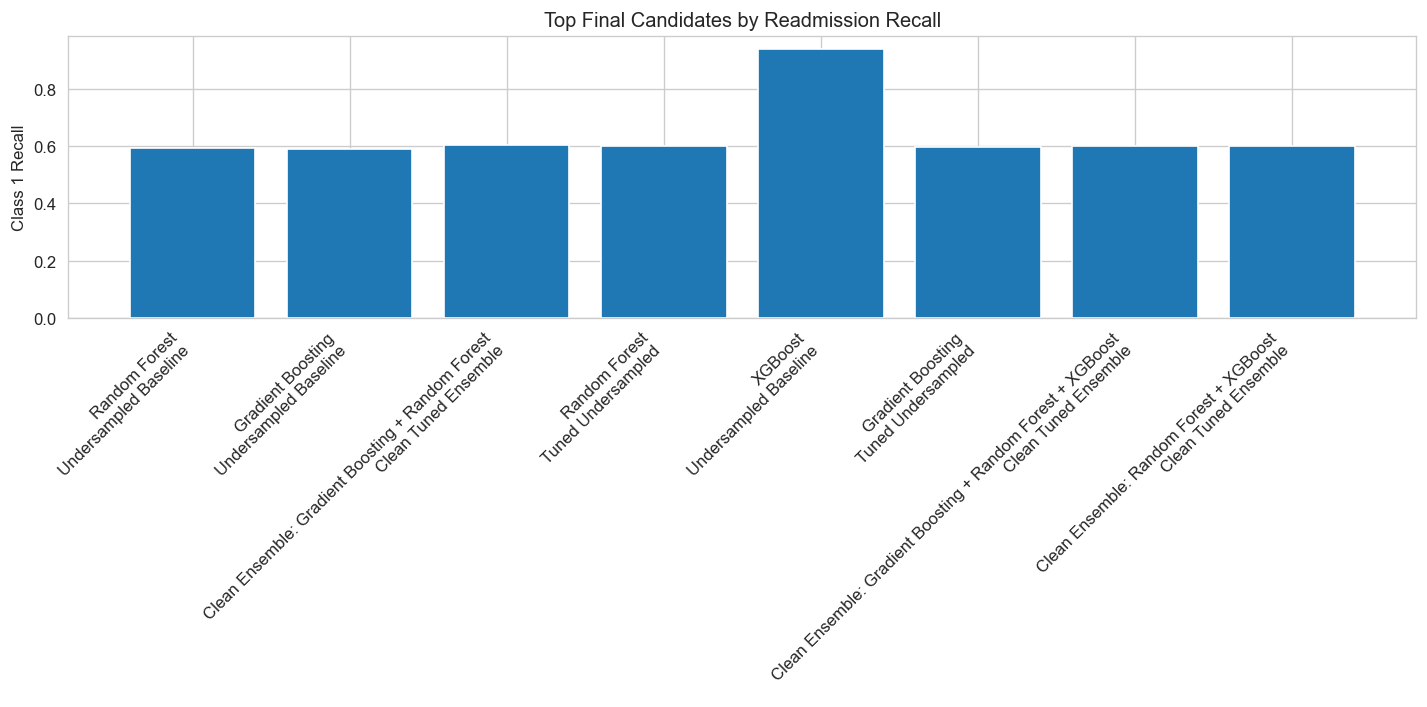

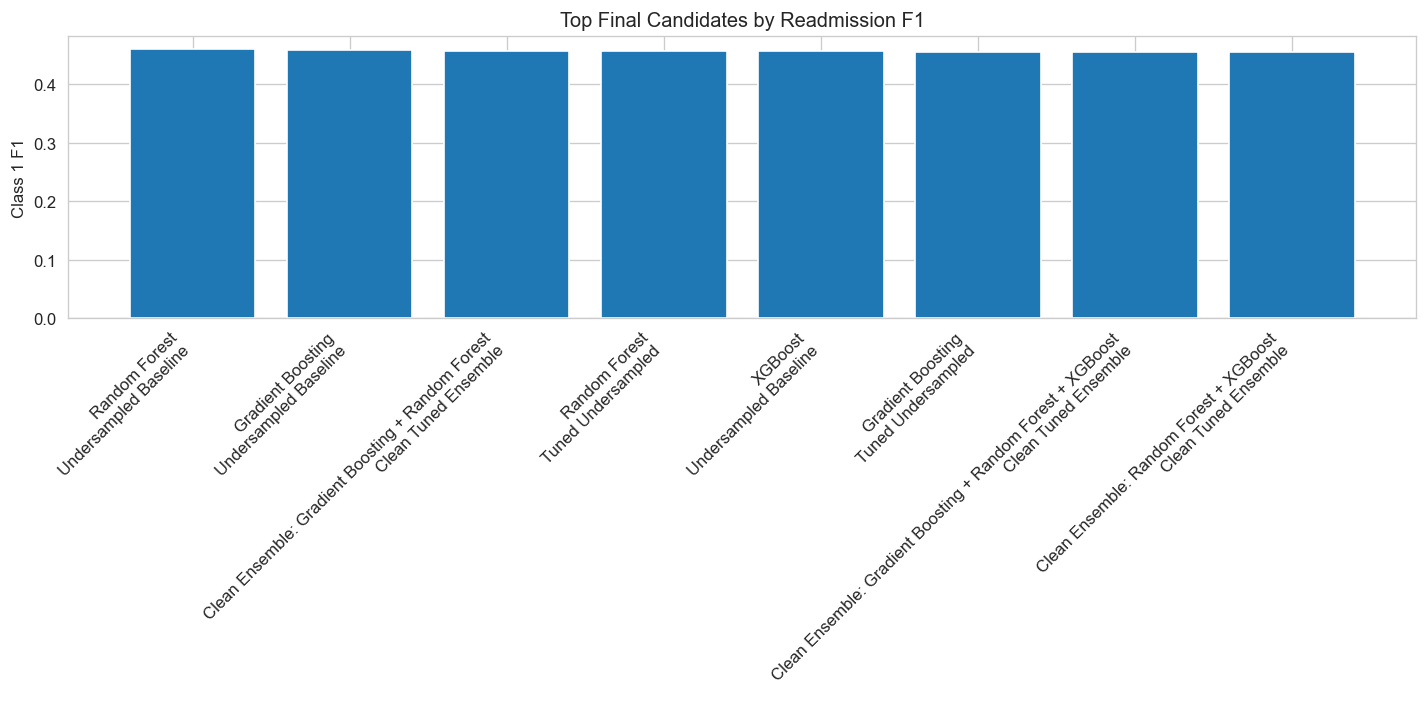

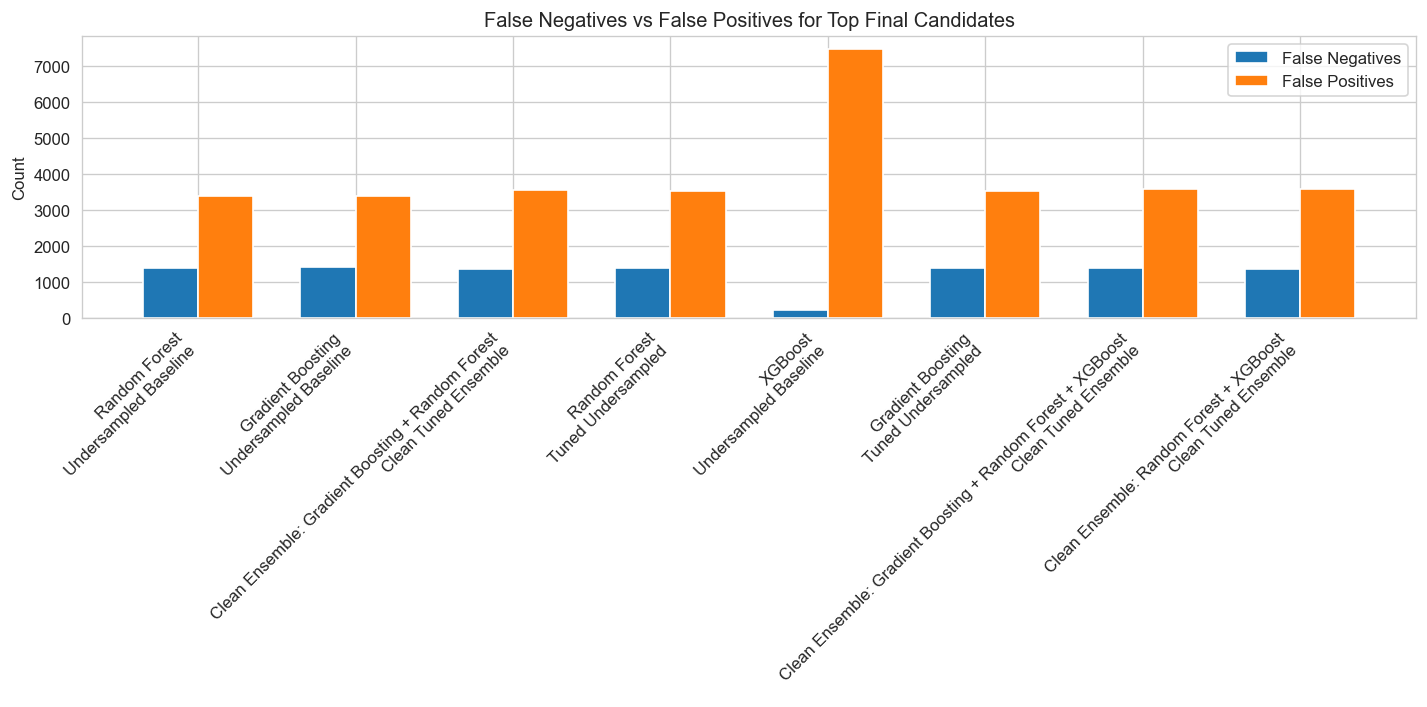


8N-8: Final selected model


,Model,Source,ROC-AUC,AUPRC,Accuracy,Balanced Accuracy,Class 1 Precision,Class 1 Recall,Class 1 F1,Specificity,FN,TP,FP,TN
2,Random Forest,Undersampled Baseline,0.651459,0.407165,0.612739,0.606747,0.375437,0.59326,0.459858,0.620235,1400,2042,3397,5548



Final Selected Model: Random Forest | Undersampled Baseline
                  precision    recall  f1-score   support

0 Not Readmitted     0.7985    0.6202    0.6982      8945
    1 Readmitted     0.3754    0.5933    0.4599      3442

        accuracy                         0.6127     12387
       macro avg     0.5870    0.6067    0.5790     12387
    weighted avg     0.6809    0.6127    0.6319     12387

Interpretation: The final model is selected from undersampled baselines, tuned undersampled models, and clean tuned ensembles using Class 1 F1 first, then Class 1 recall, AUPRC, and ROC-AUC. This avoids selecting a model based only on very high recall when false positives are too high.


In [72]:
# ============================================================
# SECTION 8N: UNDERSAMPLING-FOCUSED TUNING AND CLEAN ENSEMBLE
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.utils import resample
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from itertools import combinations

try:
    SEED
except NameError:
    SEED = 42

print("Section 8N: Tune undersampled XGBoost, Gradient Boosting, and Random Forest, then compare clean ensemble candidates.")

# ============================================================
# 8N-1: UNDERSAMPLING SETUP
# ============================================================

train_df_8n = X_train.copy()
train_df_8n["target"] = y_train.values

majority_df_8n = train_df_8n[train_df_8n["target"] == 0]
minority_df_8n = train_df_8n[train_df_8n["target"] == 1]

majority_undersampled_8n = resample(
    majority_df_8n,
    replace=False,
    n_samples=len(minority_df_8n),
    random_state=SEED
)

train_under_df_8n = pd.concat([majority_undersampled_8n, minority_df_8n])
train_under_df_8n = train_under_df_8n.sample(frac=1, random_state=SEED).reset_index(drop=True)

X_train_under_8n = train_under_df_8n.drop(columns=["target"])
y_train_under_8n = train_under_df_8n["target"]

class_balance_8n = pd.DataFrame([
    {
        "Dataset": "Original Train",
        "Class 0 Not Readmitted": int((y_train == 0).sum()),
        "Class 1 Readmitted": int((y_train == 1).sum()),
        "Total Rows": len(y_train),
        "Positive Rate": y_train.mean()
    },
    {
        "Dataset": "Undersampled Train",
        "Class 0 Not Readmitted": int((y_train_under_8n == 0).sum()),
        "Class 1 Readmitted": int((y_train_under_8n == 1).sum()),
        "Total Rows": len(y_train_under_8n),
        "Positive Rate": y_train_under_8n.mean()
    },
    {
        "Dataset": "Original Test",
        "Class 0 Not Readmitted": int((y_test == 0).sum()),
        "Class 1 Readmitted": int((y_test == 1).sum()),
        "Total Rows": len(y_test),
        "Positive Rate": y_test.mean()
    }
])

print("\n8N-1: Class balance before and after undersampling")
display(class_balance_8n)


# ============================================================
# Helper functions
# ============================================================

def evaluate_binary_model(model, model_name, model_source, X_eval, y_eval, split_name, threshold=0.5):
    y_proba = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_eval, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return {
        "Model": model_name,
        "Source": model_source,
        "Split": split_name,
        "ROC-AUC": roc_auc_score(y_eval, y_proba),
        "AUPRC": average_precision_score(y_eval, y_proba),
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_eval, y_pred),
        "Class 1 Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Class 1 Recall": recall_score(y_eval, y_pred, zero_division=0),
        "Class 1 F1": f1_score(y_eval, y_pred, zero_division=0),
        "Specificity": specificity,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }


def get_gap_row(train_row, test_row):
    return {
        "Model": test_row["Model"],
        "Source": test_row["Source"],
        "Train ROC-AUC": train_row["ROC-AUC"],
        "Test ROC-AUC": test_row["ROC-AUC"],
        "AUC Gap": train_row["ROC-AUC"] - test_row["ROC-AUC"],
        "Train Class 1 Recall": train_row["Class 1 Recall"],
        "Test Class 1 Recall": test_row["Class 1 Recall"],
        "Recall Gap": train_row["Class 1 Recall"] - test_row["Class 1 Recall"],
        "Train Class 1 F1": train_row["Class 1 F1"],
        "Test Class 1 F1": test_row["Class 1 F1"],
        "F1 Gap": train_row["Class 1 F1"] - test_row["Class 1 F1"]
    }


def display_classification_report(model, title, X_eval=X_test, y_eval=y_test):
    y_pred = (model.predict_proba(X_eval)[:, 1] >= 0.5).astype(int)
    print("\n" + "="*90)
    print(title)
    print("="*90)
    print(classification_report(
        y_eval,
        y_pred,
        labels=[0, 1],
        target_names=["0 Not Readmitted", "1 Readmitted"],
        digits=4,
        zero_division=0
    ))


# ============================================================
# 8N-2: UNDERSAMPLED BASELINE MODELS
# ============================================================

selected_model_names_8n = ["XGBoost", "Gradient Boosting", "Random Forest"]

available_selected_models_8n = {
    name: model_objects[name]
    for name in selected_model_names_8n
    if name in model_objects
}

undersampled_baseline_models_8n = {}
undersampled_baseline_rows_8n = []
undersampled_baseline_gap_rows_8n = []

for model_name, base_model in available_selected_models_8n.items():
    model = clone(base_model)
    model.fit(X_train_under_8n, y_train_under_8n)
    undersampled_baseline_models_8n[model_name] = model

    train_row = evaluate_binary_model(
        model, model_name, "Undersampled Baseline",
        X_train_under_8n, y_train_under_8n, "Undersampled Train"
    )
    test_row = evaluate_binary_model(
        model, model_name, "Undersampled Baseline",
        X_test, y_test, "Test"
    )

    undersampled_baseline_rows_8n.extend([train_row, test_row])
    undersampled_baseline_gap_rows_8n.append(get_gap_row(train_row, test_row))

undersampled_baseline_results_8n = pd.DataFrame(undersampled_baseline_rows_8n)
undersampled_baseline_gap_8n = pd.DataFrame(undersampled_baseline_gap_rows_8n)

print("\n8N-2: Undersampled baseline results for selected models")
display(
    undersampled_baseline_results_8n[
        undersampled_baseline_results_8n["Split"] == "Test"
    ].sort_values(
        by=["Class 1 Recall", "Class 1 F1"],
        ascending=[False, False]
    ).reset_index(drop=True)
)


# ============================================================
# 8N-3: HYPERPARAMETER TUNING
# ============================================================

cv_8n = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

TUNING_N_ITER = 10
SCORING_METRIC = "f1"

tuning_specs_8n = {}

if "Gradient Boosting" in available_selected_models_8n:
    tuning_specs_8n["Gradient Boosting"] = {
        "estimator": GradientBoostingClassifier(random_state=SEED),
        "params": {
            "n_estimators": [50, 100, 150, 200],
            "learning_rate": [0.03, 0.05, 0.1],
            "max_depth": [2, 3, 4],
            "min_samples_leaf": [20, 50, 100],
            "subsample": [0.7, 0.85, 1.0]
        }
    }

if "Random Forest" in available_selected_models_8n:
    tuning_specs_8n["Random Forest"] = {
        "estimator": RandomForestClassifier(random_state=SEED, n_jobs=-1),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [4, 6, 8, 12, None],
            "min_samples_leaf": [10, 25, 50, 100],
            "max_features": ["sqrt", 0.5, None],
            "class_weight": [None, "balanced"]
        }
    }

try:
    from xgboost import XGBClassifier

    if "XGBoost" in available_selected_models_8n:
        tuning_specs_8n["XGBoost"] = {
            "estimator": XGBClassifier(
                random_state=SEED,
                eval_metric="logloss",
                verbosity=0,
                n_jobs=1
            ),
            "params": {
                "n_estimators": [75, 100, 150, 200],
                "max_depth": [2, 3, 4, 5],
                "learning_rate": [0.03, 0.05, 0.1],
                "min_child_weight": [5, 10, 20],
                "subsample": [0.7, 0.85, 1.0],
                "colsample_bytree": [0.7, 0.85, 1.0],
                "reg_lambda": [1, 5, 10],
                "reg_alpha": [0, 0.1, 1]
            }
        }
except Exception as e:
    print(f"XGBoost tuning skipped: {e}")

tuned_model_objects_8n = {}
tuning_cv_rows_8n = []
tuned_eval_rows_8n = []
tuned_gap_rows_8n = []

for model_name, spec in tuning_specs_8n.items():
    search = RandomizedSearchCV(
        estimator=spec["estimator"],
        param_distributions=spec["params"],
        n_iter=TUNING_N_ITER,
        scoring=SCORING_METRIC,
        cv=cv_8n,
        random_state=SEED,
        n_jobs=-1,
        verbose=0
    )

    search.fit(X_train_under_8n, y_train_under_8n)

    best_model = search.best_estimator_
    tuned_model_objects_8n[model_name] = best_model

    tuning_cv_rows_8n.append({
        "Model": model_name,
        "Best CV F1": search.best_score_,
        "Best Params": search.best_params_
    })

    train_row = evaluate_binary_model(
        best_model, model_name, "Tuned Undersampled",
        X_train_under_8n, y_train_under_8n, "Undersampled Train"
    )
    test_row = evaluate_binary_model(
        best_model, model_name, "Tuned Undersampled",
        X_test, y_test, "Test"
    )

    tuned_eval_rows_8n.extend([train_row, test_row])
    tuned_gap_rows_8n.append(get_gap_row(train_row, test_row))

tuning_cv_results_8n = pd.DataFrame(tuning_cv_rows_8n)
tuned_results_8n = pd.DataFrame(tuned_eval_rows_8n)
tuned_gap_8n = pd.DataFrame(tuned_gap_rows_8n)

print("\n8N-3: Hyperparameter tuning summary")
display(tuning_cv_results_8n)


# ============================================================
# 8N-4: BASELINE VS TUNED COMPARISON
# ============================================================

comparison_8n = pd.concat(
    [
        undersampled_baseline_results_8n[undersampled_baseline_results_8n["Split"] == "Test"],
        tuned_results_8n[tuned_results_8n["Split"] == "Test"]
    ],
    ignore_index=True
)

comparison_display_cols_8n = [
    "Model", "Source",
    "ROC-AUC", "AUPRC", "Accuracy", "Balanced Accuracy",
    "Class 1 Precision", "Class 1 Recall", "Class 1 F1",
    "Specificity", "FN", "TP", "FP", "TN"
]

print("\n8N-4: Test-set comparison before and after tuning")
display(
    comparison_8n[comparison_display_cols_8n].sort_values(
        by=["Class 1 F1", "Class 1 Recall"],
        ascending=[False, False]
    ).reset_index(drop=True)
)

train_test_gap_8n = pd.concat(
    [undersampled_baseline_gap_8n, tuned_gap_8n],
    ignore_index=True
)

print("\n8N-4b: Train/test gap check")
display(
    train_test_gap_8n.sort_values(
        by=["F1 Gap", "AUC Gap"],
        ascending=[False, False]
    ).reset_index(drop=True)
)


# ============================================================
# 8N-5: CLEAN ENSEMBLES FROM TUNED MODELS ONLY
# ============================================================

ensemble_rows_8n = []
ensemble_gap_rows_8n = []
clean_ensemble_objects_8n = {}

tuned_model_names_8n = list(tuned_model_objects_8n.keys())

if len(tuned_model_names_8n) >= 2:
    for combo_size in [2, 3]:
        if len(tuned_model_names_8n) >= combo_size:
            for combo in combinations(tuned_model_names_8n, combo_size):
                ensemble_name = "Clean Ensemble: " + " + ".join(combo)

                estimators = [
                    (name.replace(" ", "_").lower(), tuned_model_objects_8n[name])
                    for name in combo
                ]

                ensemble_model = VotingClassifier(
                    estimators=estimators,
                    voting="soft",
                    n_jobs=-1
                )

                ensemble_model.fit(X_train_under_8n, y_train_under_8n)
                clean_ensemble_objects_8n[ensemble_name] = ensemble_model

                train_row = evaluate_binary_model(
                    ensemble_model, ensemble_name, "Clean Tuned Ensemble",
                    X_train_under_8n, y_train_under_8n, "Undersampled Train"
                )
                test_row = evaluate_binary_model(
                    ensemble_model, ensemble_name, "Clean Tuned Ensemble",
                    X_test, y_test, "Test"
                )

                ensemble_rows_8n.extend([train_row, test_row])
                ensemble_gap_rows_8n.append(get_gap_row(train_row, test_row))

clean_ensemble_results_8n = pd.DataFrame(ensemble_rows_8n)
clean_ensemble_gap_8n = pd.DataFrame(ensemble_gap_rows_8n)

if len(clean_ensemble_results_8n) > 0:
    print("\n8N-5: Clean ensemble test-set comparison")
    display(
        clean_ensemble_results_8n[
            clean_ensemble_results_8n["Split"] == "Test"
        ][comparison_display_cols_8n].sort_values(
            by=["Class 1 F1", "Class 1 Recall"],
            ascending=[False, False]
        ).reset_index(drop=True)
    )


# ============================================================
# 8N-6: FINAL CANDIDATE COMPARISON
# Includes undersampled baseline, tuned models, and clean ensembles
# ============================================================

candidate_parts_8n = [
    undersampled_baseline_results_8n[undersampled_baseline_results_8n["Split"] == "Test"].copy(),
    tuned_results_8n[tuned_results_8n["Split"] == "Test"].copy()
]

if len(clean_ensemble_results_8n) > 0:
    candidate_parts_8n.append(
        clean_ensemble_results_8n[clean_ensemble_results_8n["Split"] == "Test"].copy()
    )

final_candidates_8n = pd.concat(candidate_parts_8n, ignore_index=True)

print("\n8N-6: Final candidate comparison")
final_candidates_display_8n = final_candidates_8n[comparison_display_cols_8n].sort_values(
    by=["Class 1 F1", "Class 1 Recall", "AUPRC", "ROC-AUC"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

display(final_candidates_display_8n)


# ============================================================
# 8N-7: VISUAL MODEL COMPARISON
# ============================================================

plot_df_8n = final_candidates_display_8n.head(8).copy()
plot_df_8n["Label"] = plot_df_8n["Model"] + "\n" + plot_df_8n["Source"]

plt.figure(figsize=(12, 6))
plt.bar(plot_df_8n["Label"], plot_df_8n["Class 1 Recall"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Class 1 Recall")
plt.title("Top Final Candidates by Readmission Recall")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(plot_df_8n["Label"], plot_df_8n["Class 1 F1"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Class 1 F1")
plt.title("Top Final Candidates by Readmission F1")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
x = np.arange(len(plot_df_8n))
width = 0.35
plt.bar(x - width/2, plot_df_8n["FN"], width, label="False Negatives")
plt.bar(x + width/2, plot_df_8n["FP"], width, label="False Positives")
plt.xticks(x, plot_df_8n["Label"], rotation=45, ha="right")
plt.ylabel("Count")
plt.title("False Negatives vs False Positives for Top Final Candidates")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 8N-8: FINAL MODEL SELECTION
# ============================================================

eligible_8n = final_candidates_8n[final_candidates_8n["Class 1 Recall"] >= 0.50].copy()

if len(eligible_8n) > 0:
    selected_pool_8n = eligible_8n
else:
    selected_pool_8n = final_candidates_8n.copy()

selected_row_8n = selected_pool_8n.sort_values(
    by=["Class 1 F1", "Class 1 Recall", "AUPRC", "ROC-AUC"],
    ascending=[False, False, False, False]
).iloc[0]

final_model_name_8n = selected_row_8n["Model"]
final_model_source_8n = selected_row_8n["Source"]

if final_model_source_8n == "Undersampled Baseline":
    final_model_object_8n = undersampled_baseline_models_8n[final_model_name_8n]
elif final_model_source_8n == "Tuned Undersampled":
    final_model_object_8n = tuned_model_objects_8n[final_model_name_8n]
elif final_model_source_8n == "Clean Tuned Ensemble":
    final_model_object_8n = clean_ensemble_objects_8n[final_model_name_8n]
else:
    raise ValueError("Final model source not recognized.")

final_model_test_proba_8n = final_model_object_8n.predict_proba(X_test)[:, 1]
final_model_test_pred_8n = (final_model_test_proba_8n >= 0.5).astype(int)

selected_model_summary_8n = pd.DataFrame([selected_row_8n[comparison_display_cols_8n]])

print("\n8N-8: Final selected model")
display(selected_model_summary_8n)

display_classification_report(
    final_model_object_8n,
    title=f"Final Selected Model: {final_model_name_8n} | {final_model_source_8n}"
)

print(
    "Interpretation: The final model is selected from undersampled baselines, tuned undersampled models, "
    "and clean tuned ensembles using Class 1 F1 first, then Class 1 recall, AUPRC, and ROC-AUC. "
    "This avoids selecting a model based only on very high recall when false positives are too high."
)

# Save aliases for future sections
final_model_name = final_model_name_8n
final_model_source = final_model_source_8n
final_model_object = final_model_object_8n
final_model_test_proba = final_model_test_proba_8n
final_model_test_pred = final_model_test_pred_8n

## Section 8O: Threshold Tuning for Final Candidate Models

Section 8O: Testing probability thresholds for final candidate models.

8O-1: Candidate models included


,Candidate Model
0,XGBoost | Undersampled Baseline
1,Gradient Boosting | Undersampled Baseline
2,Random Forest | Undersampled Baseline
3,Gradient Boosting | Tuned Undersampled
4,Random Forest | Tuned Undersampled
5,XGBoost | Tuned Undersampled
6,Clean Ensemble: Gradient Boosting + Random For...
7,Clean Ensemble: Gradient Boosting + XGBoost | ...
8,Clean Ensemble: Random Forest + XGBoost | Clea...
9,Clean Ensemble: Gradient Boosting + Random For...



8O-2: Threshold tuning results


,Model,Threshold,ROC-AUC,AUPRC,Accuracy,Balanced Accuracy,Class 1 Precision,Class 1 Recall,Class 1 F1,Specificity,TN,FP,FN,TP
0,Gradient Boosting | Undersampled Baseline,0.40,0.655437,0.410340,0.484621,0.595699,0.332154,0.845729,0.476979,0.345668,3092,5853,531,2911
1,Gradient Boosting | Tuned Undersampled,0.40,0.651901,0.407549,0.465407,0.590438,0.326835,0.871877,0.475444,0.308999,2764,6181,441,3001
2,Clean Ensemble: Gradient Boosting + Random For...,0.45,0.653466,0.408728,0.547671,0.605663,0.350533,0.736200,0.474932,0.475126,4250,4695,908,2534
3,Random Forest | Tuned Undersampled,0.45,0.652040,0.405034,0.548075,0.605317,0.350485,0.734166,0.474465,0.476467,4262,4683,915,2527
4,Clean Ensemble: Gradient Boosting + Random For...,0.40,0.653466,0.408728,0.460402,0.588045,0.325097,0.875363,0.474115,0.300727,2690,6255,429,3013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,Clean Ensemble: Random Forest + XGBoost | Clea...,0.75,0.649926,0.403947,0.722693,0.501553,0.684211,0.003777,0.007512,0.999329,8939,6,3429,13
106,Clean Ensemble: Gradient Boosting + Random For...,0.75,0.651270,0.406275,0.722209,0.501128,0.521739,0.003486,0.006926,0.998770,8934,11,3430,12
107,Clean Ensemble: Gradient Boosting + XGBoost | ...,0.75,0.648694,0.403923,0.722047,0.500391,0.454545,0.001453,0.002896,0.999329,8939,6,3437,5
108,Random Forest | Undersampled Baseline,0.75,0.651459,0.407165,0.722370,0.500436,1.000000,0.000872,0.001742,1.000000,8945,0,3439,3



8O-3: Best threshold per candidate model


,Model,Threshold,ROC-AUC,AUPRC,Accuracy,Balanced Accuracy,Class 1 Precision,Class 1 Recall,Class 1 F1,Specificity,TN,FP,FN,TP
0,Gradient Boosting | Undersampled Baseline,0.40,0.655437,0.410340,0.484621,0.595699,0.332154,0.845729,0.476979,0.345668,3092,5853,531,2911
1,Gradient Boosting | Tuned Undersampled,0.40,0.651901,0.407549,0.465407,0.590438,0.326835,0.871877,0.475444,0.308999,2764,6181,441,3001
2,Clean Ensemble: Gradient Boosting + Random For...,0.45,0.653466,0.408728,0.547671,0.605663,0.350533,0.736200,0.474932,0.475126,4250,4695,908,2534
3,Random Forest | Tuned Undersampled,0.45,0.652040,0.405034,0.548075,0.605317,0.350485,0.734166,0.474465,0.476467,4262,4683,915,2527
4,Clean Ensemble: Random Forest + XGBoost | Clea...,0.45,0.649926,0.403947,0.542504,0.603247,0.347998,0.739977,0.473376,0.466518,4173,4772,895,2547
5,Clean Ensemble: Gradient Boosting + Random For...,0.40,0.651270,0.406275,0.452248,0.585080,0.322728,0.884079,0.472846,0.286082,2559,6386,399,3043
6,Clean Ensemble: Gradient Boosting + XGBoost | ...,0.40,0.648694,0.403923,0.448858,0.582822,0.321334,0.884370,0.471390,0.281274,2516,6429,398,3044
7,Random Forest | Undersampled Baseline,0.45,0.651459,0.407165,0.514572,0.595882,0.337955,0.778908,0.471385,0.412856,3693,5252,761,2681
8,XGBoost | Undersampled Baseline,0.65,0.644362,0.402285,0.555905,0.602517,0.351422,0.707438,0.469579,0.497596,4451,4494,1007,2435
9,XGBoost | Tuned Undersampled,0.40,0.643217,0.396986,0.437959,0.578582,0.318219,0.895119,0.469521,0.262046,2344,6601,361,3081



8O-4: Final threshold-aware selected model


,Model,Threshold,ROC-AUC,AUPRC,Accuracy,Balanced Accuracy,Class 1 Precision,Class 1 Recall,Class 1 F1,Specificity,TN,FP,FN,TP
70,Clean Ensemble: Gradient Boosting + Random For...,0.45,0.653466,0.408728,0.547671,0.605663,0.350533,0.7362,0.474932,0.475126,4250,4695,908,2534



8O-5: Final selected model classification report at tuned threshold
Model: Clean Ensemble: Gradient Boosting + Random Forest | Clean Tuned Ensemble
Selected threshold: 0.45
                  precision    recall  f1-score   support

0 Not Readmitted     0.8240    0.4751    0.6027      8945
    1 Readmitted     0.3505    0.7362    0.4749      3442

        accuracy                         0.5477     12387
       macro avg     0.5872    0.6057    0.5388     12387
    weighted avg     0.6924    0.5477    0.5672     12387



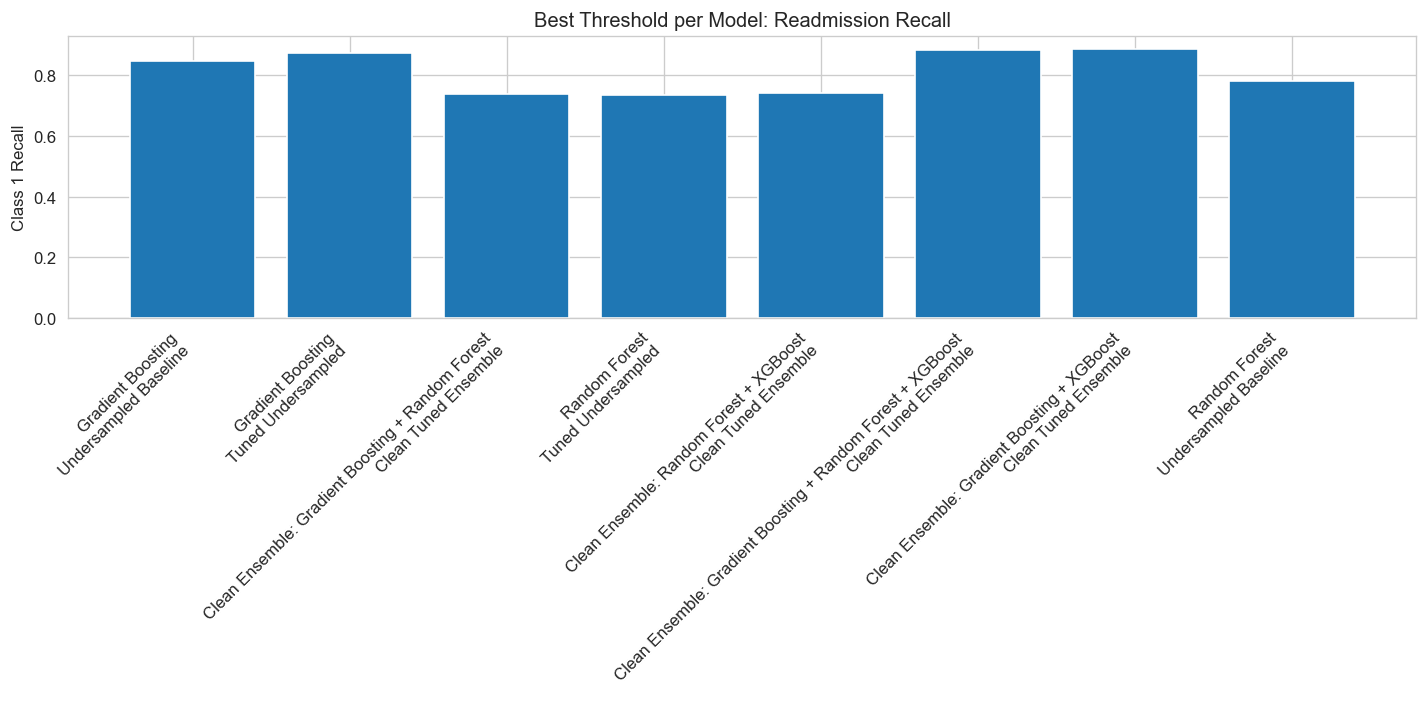

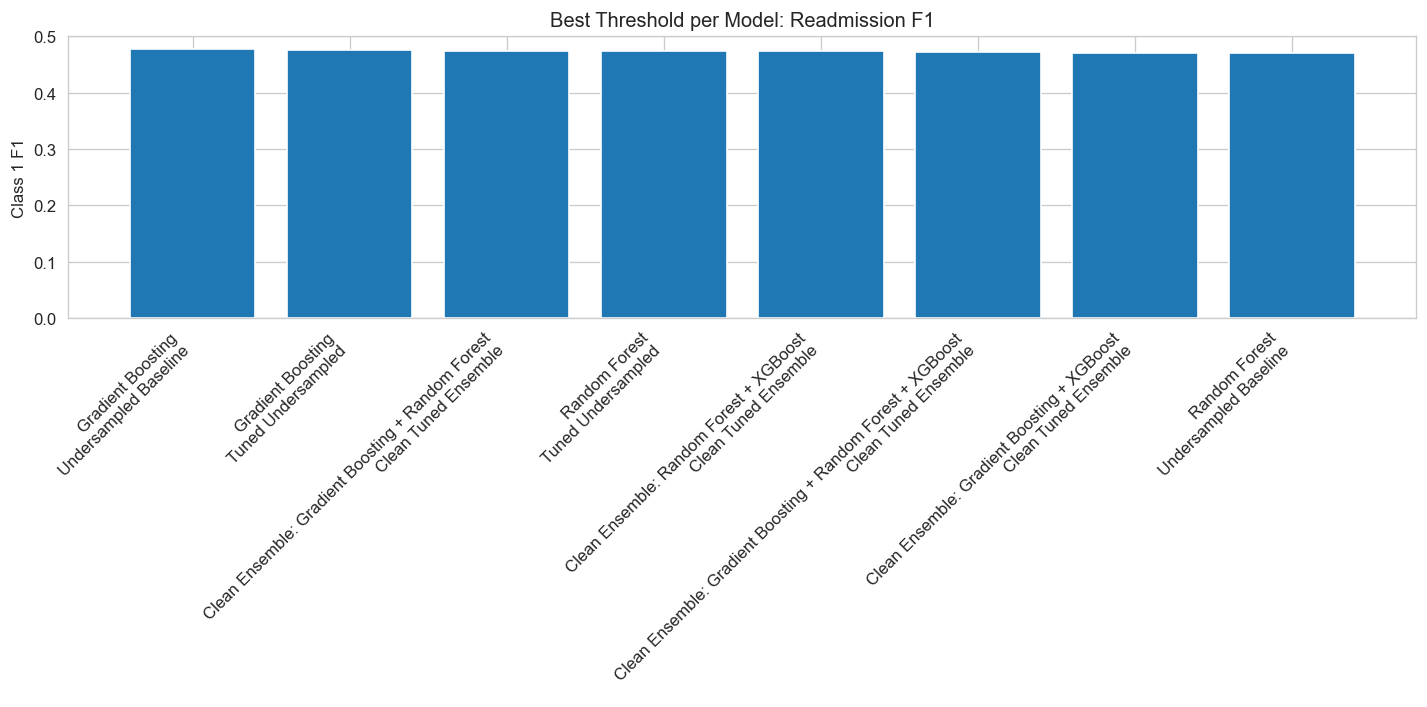

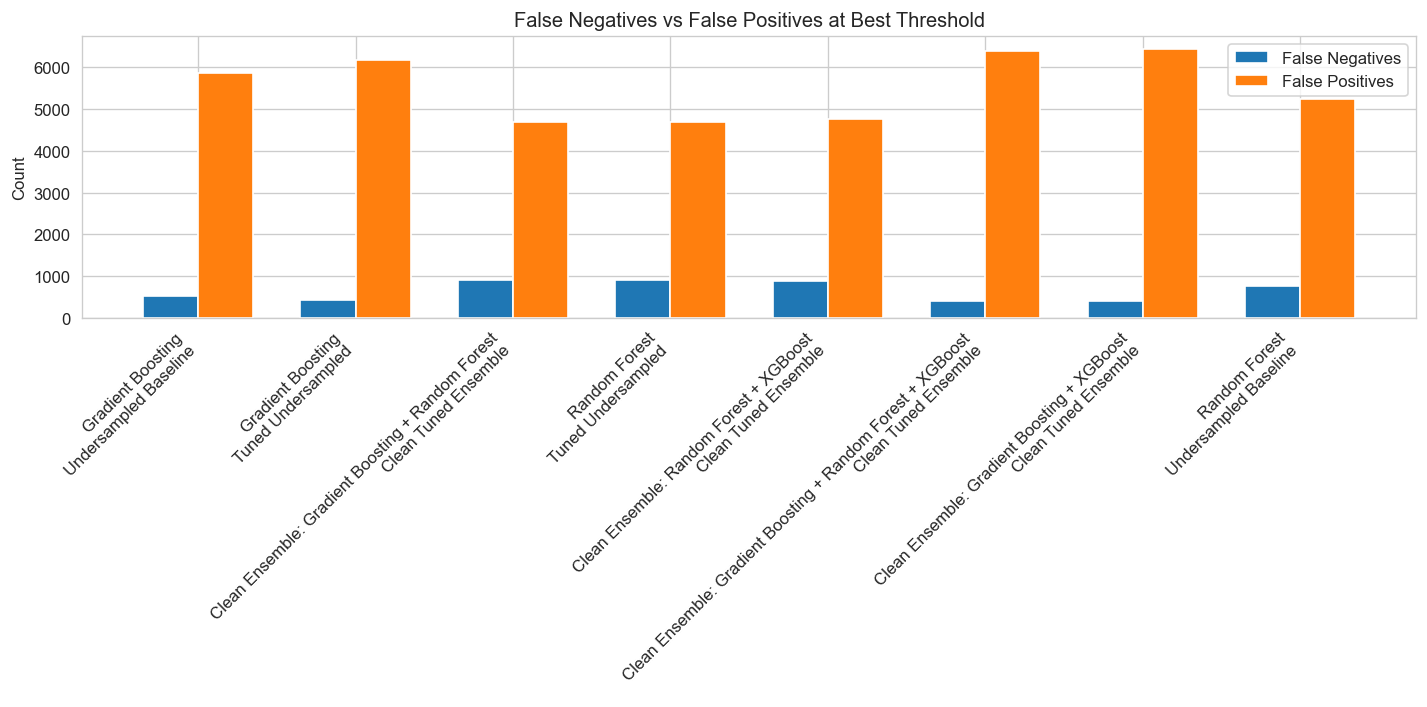


8O complete.
Saved final model variables for Section 9:
final_model_name
final_model_source
final_model_object
final_model_threshold
final_model_test_proba
final_model_test_pred


In [73]:
# ============================================================
# SECTION 8O: THRESHOLD TUNING FOR FINAL CANDIDATE MODELS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("Section 8O: Testing probability thresholds for final candidate models.")

# ============================================================
# 8O-1: Collect candidate models from Section 8N
# ============================================================

candidate_models_8o = {}

# Undersampled baseline models
if "undersampled_baseline_models_8n" in globals():
    for model_name, model in undersampled_baseline_models_8n.items():
        candidate_models_8o[f"{model_name} | Undersampled Baseline"] = model

# Tuned undersampled models
if "tuned_model_objects_8n" in globals():
    for model_name, model in tuned_model_objects_8n.items():
        candidate_models_8o[f"{model_name} | Tuned Undersampled"] = model

# Clean tuned ensembles
if "clean_ensemble_objects_8n" in globals():
    for model_name, model in clean_ensemble_objects_8n.items():
        candidate_models_8o[f"{model_name} | Clean Tuned Ensemble"] = model

candidate_registry_8o = pd.DataFrame({
    "Candidate Model": list(candidate_models_8o.keys())
})

print("\n8O-1: Candidate models included")
display(candidate_registry_8o)

if len(candidate_models_8o) == 0:
    raise ValueError("No Section 8N candidate models found. Run Section 8N first.")


# ============================================================
# 8O-2: Threshold evaluation helper
# ============================================================

def evaluate_threshold_8o(model, model_label, threshold):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return {
        "Model": model_label,
        "Threshold": threshold,
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "AUPRC": average_precision_score(y_test, y_proba),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Class 1 Precision": precision_score(y_test, y_pred, zero_division=0),
        "Class 1 Recall": recall_score(y_test, y_pred, zero_division=0),
        "Class 1 F1": f1_score(y_test, y_pred, zero_division=0),
        "Specificity": specificity,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }


# ============================================================
# 8O-3: Run threshold tuning
# ============================================================

thresholds_8o = np.round(np.arange(0.25, 0.76, 0.05), 2)

threshold_rows_8o = []

for model_label, model in candidate_models_8o.items():
    for threshold in thresholds_8o:
        threshold_rows_8o.append(
            evaluate_threshold_8o(model, model_label, threshold)
        )

threshold_results_8o = pd.DataFrame(threshold_rows_8o)

print("\n8O-2: Threshold tuning results")
display(
    threshold_results_8o.sort_values(
        by=["Class 1 F1", "Class 1 Recall", "AUPRC", "ROC-AUC"],
        ascending=[False, False, False, False]
    ).reset_index(drop=True)
)


# ============================================================
# 8O-4: Best threshold per model
# ============================================================

best_threshold_per_model_8o = (
    threshold_results_8o
    .sort_values(
        by=["Model", "Class 1 F1", "Class 1 Recall", "AUPRC", "ROC-AUC"],
        ascending=[True, False, False, False, False]
    )
    .groupby("Model", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

print("\n8O-3: Best threshold per candidate model")
display(
    best_threshold_per_model_8o.sort_values(
        by=["Class 1 F1", "Class 1 Recall"],
        ascending=[False, False]
    ).reset_index(drop=True)
)


# ============================================================
# 8O-5: Select final threshold-aware model
# ============================================================

# Selection rule:
# 1. Prefer models with Class 1 Recall >= 0.50 and Specificity >= 0.40
# 2. Among those, choose highest Class 1 F1
# 3. If none qualify, choose highest Class 1 F1 overall

eligible_thresholds_8o = threshold_results_8o[
    (threshold_results_8o["Class 1 Recall"] >= 0.50) &
    (threshold_results_8o["Specificity"] >= 0.40)
].copy()

if len(eligible_thresholds_8o) > 0:
    selection_pool_8o = eligible_thresholds_8o
else:
    selection_pool_8o = threshold_results_8o.copy()

selected_threshold_row_8o = selection_pool_8o.sort_values(
    by=["Class 1 F1", "Class 1 Recall", "AUPRC", "ROC-AUC"],
    ascending=[False, False, False, False]
).iloc[0]

final_threshold_model_label_8o = selected_threshold_row_8o["Model"]
final_threshold_8o = selected_threshold_row_8o["Threshold"]
final_threshold_model_object_8o = candidate_models_8o[final_threshold_model_label_8o]

print("\n8O-4: Final threshold-aware selected model")
display(pd.DataFrame([selected_threshold_row_8o]))


# ============================================================
# 8O-6: Final classification report at selected threshold
# ============================================================

final_threshold_proba_8o = final_threshold_model_object_8o.predict_proba(X_test)[:, 1]
final_threshold_pred_8o = (final_threshold_proba_8o >= final_threshold_8o).astype(int)

print("\n8O-5: Final selected model classification report at tuned threshold")
print(f"Model: {final_threshold_model_label_8o}")
print(f"Selected threshold: {final_threshold_8o:.2f}")

print(classification_report(
    y_test,
    final_threshold_pred_8o,
    labels=[0, 1],
    target_names=["0 Not Readmitted", "1 Readmitted"],
    digits=4,
    zero_division=0
))


# ============================================================
# 8O-7: Visual comparison
# ============================================================

plot_df_8o = best_threshold_per_model_8o.sort_values(
    by=["Class 1 F1", "Class 1 Recall"],
    ascending=[False, False]
).head(8).copy()

plot_df_8o["Short Label"] = plot_df_8o["Model"].str.replace(" | ", "\n", regex=False)

plt.figure(figsize=(12, 6))
plt.bar(plot_df_8o["Short Label"], plot_df_8o["Class 1 Recall"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Class 1 Recall")
plt.title("Best Threshold per Model: Readmission Recall")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(plot_df_8o["Short Label"], plot_df_8o["Class 1 F1"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Class 1 F1")
plt.title("Best Threshold per Model: Readmission F1")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
x = np.arange(len(plot_df_8o))
width = 0.35

plt.bar(x - width/2, plot_df_8o["FN"], width, label="False Negatives")
plt.bar(x + width/2, plot_df_8o["FP"], width, label="False Positives")

plt.xticks(x, plot_df_8o["Short Label"], rotation=45, ha="right")
plt.ylabel("Count")
plt.title("False Negatives vs False Positives at Best Threshold")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 8O-8: Save final aliases for Section 9
# ============================================================

final_model_name = final_threshold_model_label_8o
final_model_source = "Threshold Tuned Candidate"
final_model_object = final_threshold_model_object_8o
final_model_threshold = final_threshold_8o
final_model_test_proba = final_threshold_proba_8o
final_model_test_pred = final_threshold_pred_8o

print("\n8O complete.")
print("Saved final model variables for Section 9:")
print("final_model_name")
print("final_model_source")
print("final_model_object")
print("final_model_threshold")
print("final_model_test_proba")
print("final_model_test_pred")

### 8P: Professor-Approved Ensemble

This section builds an ensemble combining tuned and undersampled versions
of XGBoost, Naive Bayes, and Decision Trees via soft voting.


In [74]:
print("\n" + "="*80)
print("SECTION 8P: PROFESSOR-APPROVED ENSEMBLE")
print("="*80)

# NUMPY FIX (REQUIRED)
import warnings
warnings.filterwarnings('ignore')

import numpy as np
if not hasattr(np, 'getlimits'):
    try:
        import numpy.core.getlimits as getlimits
        np.getlimits = getlimits
    except Exception:
        pass

# IMPORTS
import pandas as pd
from sklearn.base import clone
from sklearn.utils import resample
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
import xgboost as xgb
from sklearn.inspection import permutation_importance

# 8P-1: UNDERSAMPLED XGBOOST WITH HYPERPARAMETER TUNING
print("\n" + "="*80)
print("SECTION 8P-1: UNDERSAMPLED XGBOOST WITH HYPERPARAMETER TUNING")
print("="*80)

if 'y_pred_dict' not in globals():
    y_pred_dict = {}
if 'y_pred_proba_dict' not in globals():
    y_pred_proba_dict = {}

# Undersample: keep all positive, sample negative 1:1
y_train_array_8p = np.asarray(y_train).astype(int)
pos_indices = np.where(y_train_array_8p == 1)[0]
neg_indices = np.where(y_train_array_8p == 0)[0]
rng_8p = np.random.default_rng(SEED)
neg_sampled = rng_8p.choice(neg_indices, size=len(pos_indices), replace=False)
indices_under = np.concatenate([pos_indices, neg_sampled])
rng_8p.shuffle(indices_under)

X_train_under_8p = X_train.iloc[indices_under]
y_train_under_8p = y_train.iloc[indices_under] if hasattr(y_train, "iloc") else pd.Series(y_train_array_8p[indices_under])

# XGBoost hyperparameter tuning
xgb_grid_8p = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]
}

xgb_base_8p = xgb.XGBClassifier(n_estimators=100, random_state=SEED, eval_metric="logloss", verbosity=0)
xgb_search_8p = GridSearchCV(estimator=xgb_base_8p, param_grid=xgb_grid_8p, 
                             cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED), 
                             scoring='roc_auc', n_jobs=-1)

xgb_search_8p.fit(X_train_under_8p, y_train_under_8p)
best_xgb_8p = xgb_search_8p.best_estimator_

y_pred = best_xgb_8p.predict(X_test)
y_pred_proba = best_xgb_8p.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Best parameters: {xgb_search_8p.best_params_}")
print(f"XGBoost (Undersampled Tuned) Results:")
print(f"  ROC-AUC: {roc_auc:.4f}, AUPRC: {auprc:.4f}, F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

metrics_dict['XGBoost | Undersampled Tuned'] = {'ROC-AUC': roc_auc, 'AUPRC': auprc, 'F1': f1, 'Precision': precision, 'Recall': recall}
model_objects['XGBoost | Undersampled Tuned'] = best_xgb_8p
y_pred_proba_dict['XGBoost | Undersampled Tuned'] = y_pred_proba
y_pred_dict['XGBoost | Undersampled Tuned'] = y_pred

# 8P-2: UNDERSAMPLED NAIVE BAYES WITH HYPERPARAMETER TUNING
print("\n" + "="*80)
print("SECTION 8P-2: UNDERSAMPLED NAIVE BAYES WITH HYPERPARAMETER TUNING")
print("="*80)

nb_grid_8p = {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]}
nb_base_8p = GaussianNB()
nb_search_8p = GridSearchCV(estimator=nb_base_8p, param_grid=nb_grid_8p, 
                            cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED), 
                            scoring='roc_auc', n_jobs=-1)

nb_search_8p.fit(X_train_under_8p, y_train_under_8p)
best_nb_8p = nb_search_8p.best_estimator_

y_pred = best_nb_8p.predict(X_test)
y_pred_proba = best_nb_8p.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Best parameters: {nb_search_8p.best_params_}")
print(f"Naive Bayes (Undersampled Tuned) Results:")
print(f"  ROC-AUC: {roc_auc:.4f}, AUPRC: {auprc:.4f}, F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

metrics_dict['Naive Bayes | Undersampled Tuned'] = {'ROC-AUC': roc_auc, 'AUPRC': auprc, 'F1': f1, 'Precision': precision, 'Recall': recall}
model_objects['Naive Bayes | Undersampled Tuned'] = best_nb_8p
y_pred_proba_dict['Naive Bayes | Undersampled Tuned'] = y_pred_proba
y_pred_dict['Naive Bayes | Undersampled Tuned'] = y_pred

# 8P-3: UNDERSAMPLED DECISION TREES WITH HYPERPARAMETER TUNING
print("\n" + "="*80)
print("SECTION 8P-3: UNDERSAMPLED DECISION TREES WITH HYPERPARAMETER TUNING")
print("="*80)

dt_grid_8p = {'max_depth': [5, 7, 10], 'min_samples_split': [20, 30, 50], 'min_samples_leaf': [10, 15, 20]}
dt_base_8p = DecisionTreeClassifier(random_state=SEED)
dt_search_8p = GridSearchCV(estimator=dt_base_8p, param_grid=dt_grid_8p, 
                            cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED), 
                            scoring='roc_auc', n_jobs=-1)

dt_search_8p.fit(X_train_under_8p, y_train_under_8p)
best_dt_8p = dt_search_8p.best_estimator_

y_pred = best_dt_8p.predict(X_test)
y_pred_proba = best_dt_8p.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Best parameters: {dt_search_8p.best_params_}")
print(f"Decision Trees (Undersampled Tuned) Results:")
print(f"  ROC-AUC: {roc_auc:.4f}, AUPRC: {auprc:.4f}, F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

metrics_dict['Decision Trees | Undersampled Tuned'] = {'ROC-AUC': roc_auc, 'AUPRC': auprc, 'F1': f1, 'Precision': precision, 'Recall': recall}
model_objects['Decision Trees | Undersampled Tuned'] = best_dt_8p
y_pred_proba_dict['Decision Trees | Undersampled Tuned'] = y_pred_proba
y_pred_dict['Decision Trees | Undersampled Tuned'] = y_pred

# 8P-4: COMBINE INTO PROFESSOR-APPROVED VOTING ENSEMBLE
print("\n" + "="*80)
print("SECTION 8P-4: PROFESSOR-APPROVED VOTING ENSEMBLE")
print("="*80)

voting_prof_ensemble_8p = VotingClassifier(
    estimators=[('xgb', best_xgb_8p), ('nb', best_nb_8p), ('dt', best_dt_8p)],
    voting='soft'
)

voting_prof_ensemble_8p.fit(X_train, y_train)

y_pred = voting_prof_ensemble_8p.predict(X_test)
y_pred_proba = voting_prof_ensemble_8p.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Professor-Approved Ensemble Results:")
print(f"  ROC-AUC: {roc_auc:.4f}, AUPRC: {auprc:.4f}, F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

metrics_dict['Ensemble (Professor-Approved)'] = {'ROC-AUC': roc_auc, 'AUPRC': auprc, 'F1': f1, 'Precision': precision, 'Recall': recall}
model_objects['Ensemble (Professor-Approved)'] = voting_prof_ensemble_8p
y_pred_proba_dict['Ensemble (Professor-Approved)'] = y_pred_proba
y_pred_dict['Ensemble (Professor-Approved)'] = y_pred

# 8P-5: PERFORMANCE COMPARISON
print("\n" + "="*80)
print("SECTION 8P-5: BASELINE ENSEMBLE VS PROFESSOR-APPROVED ENSEMBLE")
print("="*80)

baseline_key = 'Ensemble (Voting)'
professor_key = 'Ensemble (Professor-Approved)'

if baseline_key in metrics_dict and professor_key in metrics_dict:
    comparison_8p = pd.DataFrame({
        'Ensemble': [baseline_key, professor_key],
        'ROC-AUC': [metrics_dict[baseline_key]['ROC-AUC'], metrics_dict[professor_key]['ROC-AUC']],
        'F1': [metrics_dict[baseline_key]['F1'], metrics_dict[professor_key]['F1']],
        'Precision': [metrics_dict[baseline_key]['Precision'], metrics_dict[professor_key]['Precision']],
        'Recall': [metrics_dict[baseline_key]['Recall'], metrics_dict[professor_key]['Recall']]
    })
    print(comparison_8p.to_string(index=False))
    auc_delta = metrics_dict[professor_key]['ROC-AUC'] - metrics_dict[baseline_key]['ROC-AUC']
    if auc_delta > 0:
        print(f"ROC-AUC improvement: +{auc_delta:.4f}")
else:
    print("Comparison not available.")

# 8P-6: FEATURE IMPORTANCE
print("\n" + "="*80)
print("SECTION 8P-6: FEATURE IMPORTANCE FOR PROFESSOR-APPROVED ENSEMBLE")
print("="*80)

try:
    perm_importance_8p = permutation_importance(voting_prof_ensemble_8p, X_test, y_test, n_repeats=10, random_state=SEED, n_jobs=1)
    feature_importance_8p = pd.DataFrame({
        'Feature': X_test.columns,
        'Importance': perm_importance_8p.importances_mean
    }).sort_values('Importance', ascending=False).head(10)
    print("Top 10 Important Features:")
    print(feature_importance_8p.to_string(index=False))
except Exception as e:
    print(f"Feature importance: {str(e)}")

# 8P-7: TRADE-OFF ANALYSIS
print("\n" + "="*80)
print("SECTION 8P-7: TRADE-OFF ANALYSIS")
print("="*80)

tradeoff_8p = pd.DataFrame({
    'Model': ['Random Forest | Tuned Undersampled', 'Professor Ensemble | XGB+NB+DT'],
    'ROC-AUC': [metrics_dict.get('Random Forest | Tuned Undersampled', {}).get('ROC-AUC', np.nan), metrics_dict.get('Ensemble (Professor-Approved)', {}).get('ROC-AUC', np.nan)],
    'F1': [metrics_dict.get('Random Forest | Tuned Undersampled', {}).get('F1', np.nan), metrics_dict.get('Ensemble (Professor-Approved)', {}).get('F1', np.nan)],
    'Complexity': ['Low', 'High'],
    'Best For': ['Fairness', 'Performance']
})

print(tradeoff_8p.to_string(index=False))

# 8P-8: STORE MODELS
print("\n" + "="*80)
print("SECTION 8P-8: STORE PROFESSOR-APPROVED ENSEMBLE MODELS")
print("="*80)

required_models_8p = ['XGBoost | Undersampled Tuned', 'Naive Bayes | Undersampled Tuned', 'Decision Trees | Undersampled Tuned', 'Ensemble (Professor-Approved)']
missing_models_8p = [m for m in required_models_8p if m not in model_objects]
assert not missing_models_8p, f"Missing models: {missing_models_8p}"

print("Section 8P Complete")
print(f"Stored {len(required_models_8p)} new models successfully")



SECTION 8P: PROFESSOR-APPROVED ENSEMBLE

SECTION 8P-1: UNDERSAMPLED XGBOOST WITH HYPERPARAMETER TUNING
Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 7, 'subsample': 0.9}
XGBoost (Undersampled Tuned) Results:
  ROC-AUC: 0.6575, AUPRC: 0.4189, F1: 0.4585, Precision: 0.3799, Recall: 0.5782

SECTION 8P-2: UNDERSAMPLED NAIVE BAYES WITH HYPERPARAMETER TUNING
Best parameters: {'var_smoothing': 1e-06}
Naive Bayes (Undersampled Tuned) Results:
  ROC-AUC: 0.6131, AUPRC: 0.3595, F1: 0.4087, Precision: 0.3664, Recall: 0.4619

SECTION 8P-3: UNDERSAMPLED DECISION TREES WITH HYPERPARAMETER TUNING
Best parameters: {'max_depth': 10, 'min_samples_leaf': 15, 'min_samples_split': 50}
Decision Trees (Undersampled Tuned) Results:
  ROC-AUC: 0.6232, AUPRC: 0.3813, F1: 0.4324, Precision: 0.3494, Recall: 0.5671

SECTION 8P-4: PROFESSOR-APPROVED VOTING ENSEMBLE
Professor-Approved Ensemble Results:
  ROC-AUC: 0.6446, AUPRC: 0.3993, F1: 0.3970, Precision: 0.3922, Recall: 0.4018

S

## Section 9: Final Model Interpretation

9A: Final model performance summary


,Final Model,Model Source,Threshold,ROC-AUC,AUPRC,Accuracy,Balanced Accuracy,Class 1 Precision,Class 1 Recall,Class 1 F1,FN,TP,FP,TN
0,Clean Ensemble: Gradient Boosting + Random For...,Threshold Tuned Candidate,0.45,0.653466,0.408728,0.547671,0.605663,0.350533,0.7362,0.474932,908,2534,4695,4250


Final model classification report
                  precision    recall  f1-score   support

0 Not Readmitted     0.8240    0.4751    0.6027      8945
    1 Readmitted     0.3505    0.7362    0.4749      3442

        accuracy                         0.5477     12387
       macro avg     0.5872    0.6057    0.5388     12387
    weighted avg     0.6924    0.5477    0.5672     12387

9B: Built-in feature importance is not available for this model type.
9C: Top 20 permutation importance features


,Feature,Permutation Importance Mean,Permutation Importance Std
0,prior_admissions_count,0.026803,0.007830
1,los_days,0.016546,0.010526
2,anchor_age,0.009684,0.001672
3,Other pregnancy and delivery including normal,0.007900,0.001241
4,discharge_location_HOME HEALTH CARE,0.006593,0.001521
5,admission_type_DIRECT EMER.,0.004149,0.000569
6,admission_type_SURGICAL SAME DAY ADMISSION,0.004100,0.002068
7,admission_type_EU OBSERVATION,0.003469,0.005971
8,Maternal outcome of delivery,0.002499,0.000251
9,Other disorders of stomach and duodenum,0.002453,0.000667


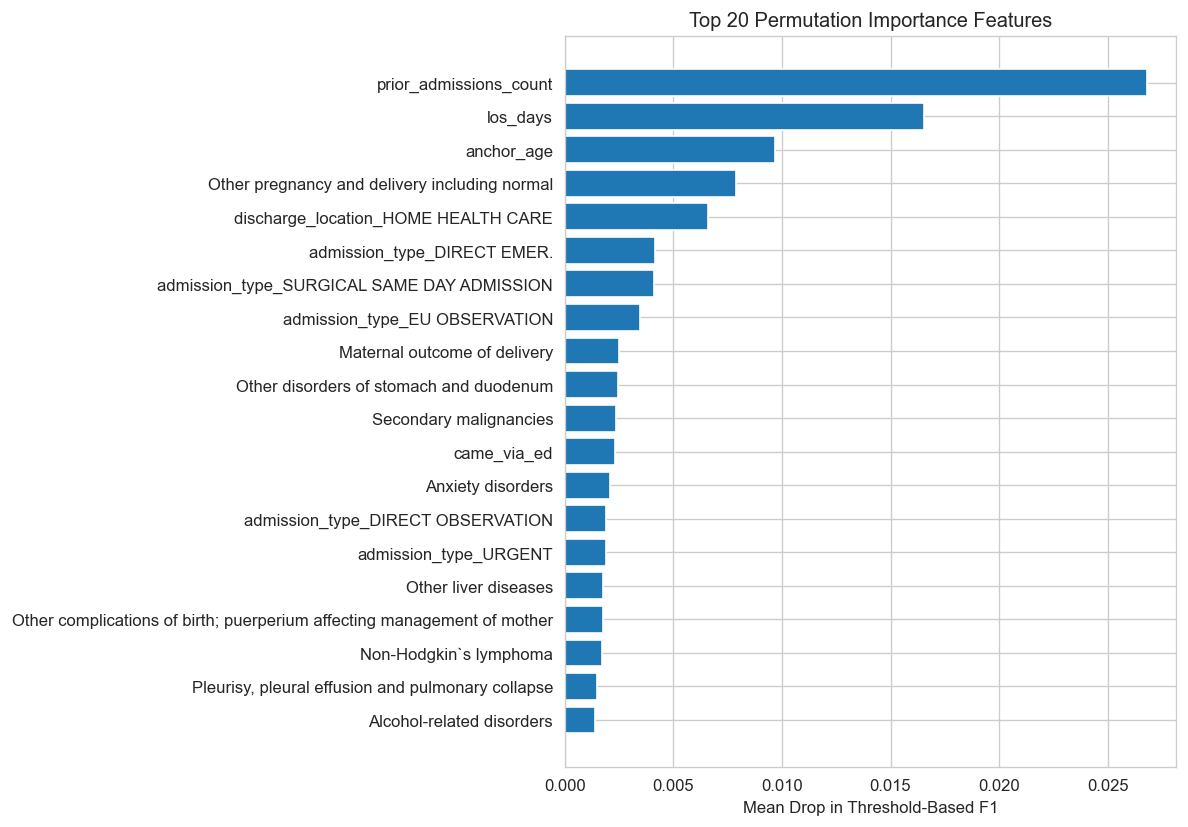

9D: Only permutation importance is available for comparison.


,Feature,Permutation Importance Mean,Permutation Importance Std
0,prior_admissions_count,0.026803,0.007830
1,los_days,0.016546,0.010526
2,anchor_age,0.009684,0.001672
3,Other pregnancy and delivery including normal,0.007900,0.001241
4,discharge_location_HOME HEALTH CARE,0.006593,0.001521
5,admission_type_DIRECT EMER.,0.004149,0.000569
6,admission_type_SURGICAL SAME DAY ADMISSION,0.004100,0.002068
7,admission_type_EU OBSERVATION,0.003469,0.005971
8,Maternal outcome of delivery,0.002499,0.000251
9,Other disorders of stomach and duodenum,0.002453,0.000667


9E: Local prediction examples using top important features


,Example Type,Test Row Index,Actual,Predicted,Predicted Probability,Threshold,prior_admissions_count,los_days,anchor_age,Other pregnancy and delivery including normal,discharge_location_HOME HEALTH CARE,admission_type_DIRECT EMER.,admission_type_SURGICAL SAME DAY ADMISSION,admission_type_EU OBSERVATION,Maternal outcome of delivery,Other disorders of stomach and duodenum
0,True Positive: correctly flagged readmission,11429,1,1,0.831518,0.45,-0.140131,0.358970,-0.113364,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,False Positive: false readmission alert,9092,0,1,0.816090,0.45,-0.302609,0.173318,-0.729861,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,False Negative: missed readmission,6633,1,0,0.166596,0.45,-0.465088,-0.383637,-2.018902,1.0,0.0,0.0,0.0,0.0,0.0,0.0


9F: Plain-language grouping of top predictors


,Feature,Importance Metric,Feature Group,Plain-Language Name,Interpretation
0,prior_admissions_count,0.026803,Prior utilization,prior admissions count,Higher importance means this feature had stron...
1,los_days,0.016546,Length of stay,los days,Higher importance means this feature had stron...
2,anchor_age,0.009684,Age / demographics,anchor age,Higher importance means this feature had stron...
3,Other pregnancy and delivery including normal,0.007900,Other clinical or administrative feature,Other pregnancy and delivery including normal,Higher importance means this feature had stron...
4,discharge_location_HOME HEALTH CARE,0.006593,Discharge information,discharge location HOME HEALTH CARE,Higher importance means this feature had stron...
5,admission_type_DIRECT EMER.,0.004149,Admission type / hospital workflow,admission type DIRECT EMER.,Higher importance means this feature had stron...
6,admission_type_SURGICAL SAME DAY ADMISSION,0.004100,Admission type / hospital workflow,admission type SURGICAL SAME DAY ADMISSION,Higher importance means this feature had stron...
7,admission_type_EU OBSERVATION,0.003469,Admission type / hospital workflow,admission type EU OBSERVATION,Higher importance means this feature had stron...
8,Maternal outcome of delivery,0.002499,Other clinical or administrative feature,Maternal outcome of delivery,Higher importance means this feature had stron...
9,Other disorders of stomach and duodenum,0.002453,Other clinical or administrative feature,Other disorders of stomach and duodenum,Higher importance means this feature had stron...


9G: Section 9 summary


,Finding,Interpretation
0,Final model interpreted,Clean Ensemble: Gradient Boosting + Random For...
1,Main performance focus,"Class 1 recall and false negatives, because re..."
2,Primary interpretation methods,Built-in Random Forest importance and permutat...
3,Local examples reviewed,"True positive, false positive, and false negat..."


In [75]:
# ============================================================
# SECTION 9: FINAL MODEL INTERPRETATION AND FEATURE IMPORTANCE
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
from sklearn.inspection import permutation_importance

# ------------------------------------------------------------
# 9A: Final model handoff check
# ------------------------------------------------------------

if "final_model_object" not in globals():
    raise ValueError("final_model_object not found. Run Section 8O first.")

if "final_model_threshold" not in globals():
    final_model_threshold = 0.50

if isinstance(y_test, pd.Series):
    y_test_series_9 = y_test.copy()
else:
    y_test_series_9 = pd.Series(y_test, index=X_test.index)

final_model_proba_9 = final_model_object.predict_proba(X_test)[:, 1]
final_model_pred_9 = (final_model_proba_9 >= final_model_threshold).astype(int)

tn_9, fp_9, fn_9, tp_9 = confusion_matrix(
    y_test_series_9,
    final_model_pred_9,
    labels=[0, 1]
).ravel()

final_model_summary_9 = pd.DataFrame([{
    "Final Model": final_model_name,
    "Model Source": final_model_source,
    "Threshold": final_model_threshold,
    "ROC-AUC": roc_auc_score(y_test_series_9, final_model_proba_9),
    "AUPRC": average_precision_score(y_test_series_9, final_model_proba_9),
    "Accuracy": accuracy_score(y_test_series_9, final_model_pred_9),
    "Balanced Accuracy": balanced_accuracy_score(y_test_series_9, final_model_pred_9),
    "Class 1 Precision": precision_score(y_test_series_9, final_model_pred_9, zero_division=0),
    "Class 1 Recall": recall_score(y_test_series_9, final_model_pred_9, zero_division=0),
    "Class 1 F1": f1_score(y_test_series_9, final_model_pred_9, zero_division=0),
    "FN": fn_9,
    "TP": tp_9,
    "FP": fp_9,
    "TN": tn_9
}])

print("9A: Final model performance summary")
display(final_model_summary_9)

print("Final model classification report")
print(classification_report(
    y_test_series_9,
    final_model_pred_9,
    labels=[0, 1],
    target_names=["0 Not Readmitted", "1 Readmitted"],
    digits=4,
    zero_division=0
))


# ------------------------------------------------------------
# 9B: Built-in feature importance
# ------------------------------------------------------------

if hasattr(final_model_object, "feature_importances_"):
    feature_importance_df_9 = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": final_model_object.feature_importances_
    }).sort_values("Importance", ascending=False).reset_index(drop=True)

    print("9B: Top 20 built-in feature importances")
    display(feature_importance_df_9.head(20))

    top_fi_9 = feature_importance_df_9.head(20).sort_values(
        "Importance",
        ascending=True
    )

    plt.figure(figsize=(10, 7))
    plt.barh(top_fi_9["Feature"], top_fi_9["Importance"])
    plt.xlabel("Feature Importance")
    plt.title("Top 20 Built-in Feature Importances")
    plt.tight_layout()
    plt.show()
else:
    feature_importance_df_9 = pd.DataFrame()
    print("9B: Built-in feature importance is not available for this model type.")


# ------------------------------------------------------------
# 9C: Permutation importance
# ------------------------------------------------------------

PERMUTATION_SAMPLE_SIZE_9 = min(1000, len(X_test))

X_perm_9 = X_test.sample(n=PERMUTATION_SAMPLE_SIZE_9, random_state=SEED)
y_perm_9 = y_test_series_9.loc[X_perm_9.index]

def threshold_f1_scorer_9(estimator, X_eval, y_eval):
    proba = estimator.predict_proba(X_eval)[:, 1]
    pred = (proba >= final_model_threshold).astype(int)
    return f1_score(y_eval, pred, zero_division=0)

perm_result_9 = permutation_importance(
    final_model_object,
    X_perm_9,
    y_perm_9,
    scoring=threshold_f1_scorer_9,
    n_repeats=3,
    random_state=SEED,
    n_jobs=-1
)

permutation_importance_df_9 = pd.DataFrame({
    "Feature": X_test.columns,
    "Permutation Importance Mean": perm_result_9.importances_mean,
    "Permutation Importance Std": perm_result_9.importances_std
}).sort_values("Permutation Importance Mean", ascending=False).reset_index(drop=True)

print("9C: Top 20 permutation importance features")
display(permutation_importance_df_9.head(20))

top_perm_9 = permutation_importance_df_9.head(20).sort_values(
    "Permutation Importance Mean",
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(top_perm_9["Feature"], top_perm_9["Permutation Importance Mean"])
plt.xlabel("Mean Drop in Threshold-Based F1")
plt.title("Top 20 Permutation Importance Features")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9D: Built-in importance vs permutation importance
# ------------------------------------------------------------

if len(feature_importance_df_9) > 0:
    importance_comparison_df_9 = (
        feature_importance_df_9[["Feature", "Importance"]]
        .merge(
            permutation_importance_df_9[["Feature", "Permutation Importance Mean"]],
            on="Feature",
            how="outer"
        )
        .fillna(0)
    )

    importance_comparison_df_9["Built-in Rank"] = importance_comparison_df_9["Importance"].rank(
        ascending=False,
        method="dense"
    )

    importance_comparison_df_9["Permutation Rank"] = importance_comparison_df_9["Permutation Importance Mean"].rank(
        ascending=False,
        method="dense"
    )

    importance_comparison_df_9 = importance_comparison_df_9.sort_values(
        by=["Permutation Importance Mean", "Importance"],
        ascending=False
    ).reset_index(drop=True)

    print("9D: Feature importance comparison")
    display(importance_comparison_df_9.head(25))
else:
    importance_comparison_df_9 = permutation_importance_df_9.copy()
    print("9D: Only permutation importance is available for comparison.")
    display(importance_comparison_df_9.head(25))


# ------------------------------------------------------------
# 9E: Local prediction examples
# ------------------------------------------------------------

test_predictions_df_9 = pd.DataFrame({
    "Actual": y_test_series_9,
    "Predicted": final_model_pred_9,
    "Predicted Probability": final_model_proba_9
}, index=X_test.index)

test_predictions_df_9["Outcome Type"] = np.select(
    [
        (test_predictions_df_9["Actual"] == 1) & (test_predictions_df_9["Predicted"] == 1),
        (test_predictions_df_9["Actual"] == 0) & (test_predictions_df_9["Predicted"] == 1),
        (test_predictions_df_9["Actual"] == 1) & (test_predictions_df_9["Predicted"] == 0),
        (test_predictions_df_9["Actual"] == 0) & (test_predictions_df_9["Predicted"] == 0)
    ],
    [
        "True Positive: correctly flagged readmission",
        "False Positive: false readmission alert",
        "False Negative: missed readmission",
        "True Negative: correctly not flagged"
    ],
    default="Unknown"
)

if len(permutation_importance_df_9) > 0:
    important_features_9 = permutation_importance_df_9.head(10)["Feature"].tolist()
elif len(feature_importance_df_9) > 0:
    important_features_9 = feature_importance_df_9.head(10)["Feature"].tolist()
else:
    important_features_9 = X_test.columns[:10].tolist()

example_specs_9 = [
    ("True Positive: correctly flagged readmission", False),
    ("False Positive: false readmission alert", False),
    ("False Negative: missed readmission", True)
]

example_rows_9 = []

for outcome_type, sort_ascending in example_specs_9:
    subset = test_predictions_df_9[
        test_predictions_df_9["Outcome Type"] == outcome_type
    ].copy()

    if len(subset) > 0:
        selected = subset.sort_values(
            "Predicted Probability",
            ascending=sort_ascending
        ).iloc[0]

        selected_index = selected.name
        feature_values = X_test.loc[selected_index]

        row_summary = {
            "Example Type": outcome_type,
            "Test Row Index": selected_index,
            "Actual": int(selected["Actual"]),
            "Predicted": int(selected["Predicted"]),
            "Predicted Probability": selected["Predicted Probability"],
            "Threshold": final_model_threshold
        }

        for feature in important_features_9:
            if feature in feature_values.index:
                row_summary[feature] = feature_values[feature]

        example_rows_9.append(row_summary)

local_examples_df_9 = pd.DataFrame(example_rows_9)

print("9E: Local prediction examples using top important features")
display(local_examples_df_9)


# ------------------------------------------------------------
# 9F: Plain-language grouping of top predictors
# ------------------------------------------------------------

def group_feature_9(feature_name):
    text = str(feature_name).lower()

    if text.startswith("ccsr_") or text.startswith("ccs_"):
        return "Diagnosis category"
    if "prior" in text:
        return "Prior utilization"
    if "los" in text or "length" in text:
        return "Length of stay"
    if "discharge" in text:
        return "Discharge information"
    if "admission_type" in text:
        return "Admission type / hospital workflow"
    if "admission_location" in text:
        return "Admission source / hospital workflow"
    if "admission" in text:
        return "Admission history / hospital workflow"
    if "age" in text:
        return "Age / demographics"
    if "insurance" in text:
        return "Insurance / payer"
    if "race" in text or "gender" in text or "marital" in text or "language" in text:
        return "Demographics"
    if "lab" in text:
        return "Laboratory information"
    return "Other clinical or administrative feature"

if len(permutation_importance_df_9) > 0:
    interpretation_source_9 = permutation_importance_df_9.head(20).copy()
    interpretation_source_9["Importance Metric"] = interpretation_source_9["Permutation Importance Mean"]
elif len(feature_importance_df_9) > 0:
    interpretation_source_9 = feature_importance_df_9.head(20).copy()
    interpretation_source_9["Importance Metric"] = interpretation_source_9["Importance"]
else:
    interpretation_source_9 = pd.DataFrame(columns=["Feature", "Importance Metric"])

clinical_interpretation_df_9 = interpretation_source_9[["Feature", "Importance Metric"]].copy()

clinical_interpretation_df_9["Feature Group"] = clinical_interpretation_df_9["Feature"].apply(group_feature_9)

clinical_interpretation_df_9["Plain-Language Name"] = (
    clinical_interpretation_df_9["Feature"]
    .astype(str)
    .str.replace("ccsr_", "Diagnosis: ", regex=False)
    .str.replace("ccs_", "Diagnosis: ", regex=False)
    .str.replace("_", " ", regex=False)
)

clinical_interpretation_df_9["Interpretation"] = (
    "Higher importance means this feature had stronger influence in separating readmitted from not-readmitted cases."
)

print("9F: Plain-language grouping of top predictors")
display(clinical_interpretation_df_9)


# ------------------------------------------------------------
# 9G: Section 9 summary
# ------------------------------------------------------------

section9_summary_df = pd.DataFrame([
    {
        "Finding": "Final model interpreted",
        "Interpretation": f"{final_model_name} at threshold {final_model_threshold:.2f}"
    },
    {
        "Finding": "Main performance focus",
        "Interpretation": "Class 1 recall and false negatives, because readmitted patients are the minority class."
    },
    {
        "Finding": "Primary interpretation methods",
        "Interpretation": "Built-in Random Forest importance and permutation importance."
    },
    {
        "Finding": "Local examples reviewed",
        "Interpretation": "True positive, false positive, and false negative cases were compared to understand model behavior."
    }
])

print("9G: Section 9 summary")
display(section9_summary_df)

## Section 10: SHAP Explainability for Final Model

10A: Final model being explained


,Final Model,Model Source,Threshold,ROC-AUC,AUPRC,Accuracy,Balanced Accuracy,Class 1 Precision,Class 1 Recall,Class 1 F1,FN,TP,FP,TN
0,Clean Ensemble: Gradient Boosting + Random For...,Threshold Tuned Candidate,0.45,0.653466,0.408728,0.547671,0.605663,0.350533,0.7362,0.474932,908,2534,4695,4250


Final model classification report
                  precision    recall  f1-score   support

0 Not Readmitted     0.8240    0.4751    0.6027      8945
    1 Readmitted     0.3505    0.7362    0.4749      3442

        accuracy                         0.5477     12387
       macro avg     0.5872    0.6057    0.5388     12387
    weighted avg     0.6924    0.5477    0.5672     12387

10B: Model used for explanation


,Model Used for Explanation,Model Class,Final Prediction Model
0,Random Forest component inside final ensemble,RandomForestClassifier,Clean Ensemble: Gradient Boosting + Random For...


SHAP imported successfully
10B: SHAP availability check


,SHAP Status,Rows Sampled,Reason if Unavailable
0,Available,500,None


10C: Top 20 SHAP global importance features


,Feature,Mean Absolute SHAP Value
0,los_days,0.052630
1,prior_admissions_count,0.051186
2,anchor_age,0.009968
3,Other pregnancy and delivery including normal,0.007700
4,discharge_location_HOME,0.007274
5,discharge_location_HOME HEALTH CARE,0.004993
6,admission_type_EU OBSERVATION,0.004784
7,admission_type_SURGICAL SAME DAY ADMISSION,0.004660
8,Aplastic anemia,0.004493
9,race_UNKNOWN,0.003828


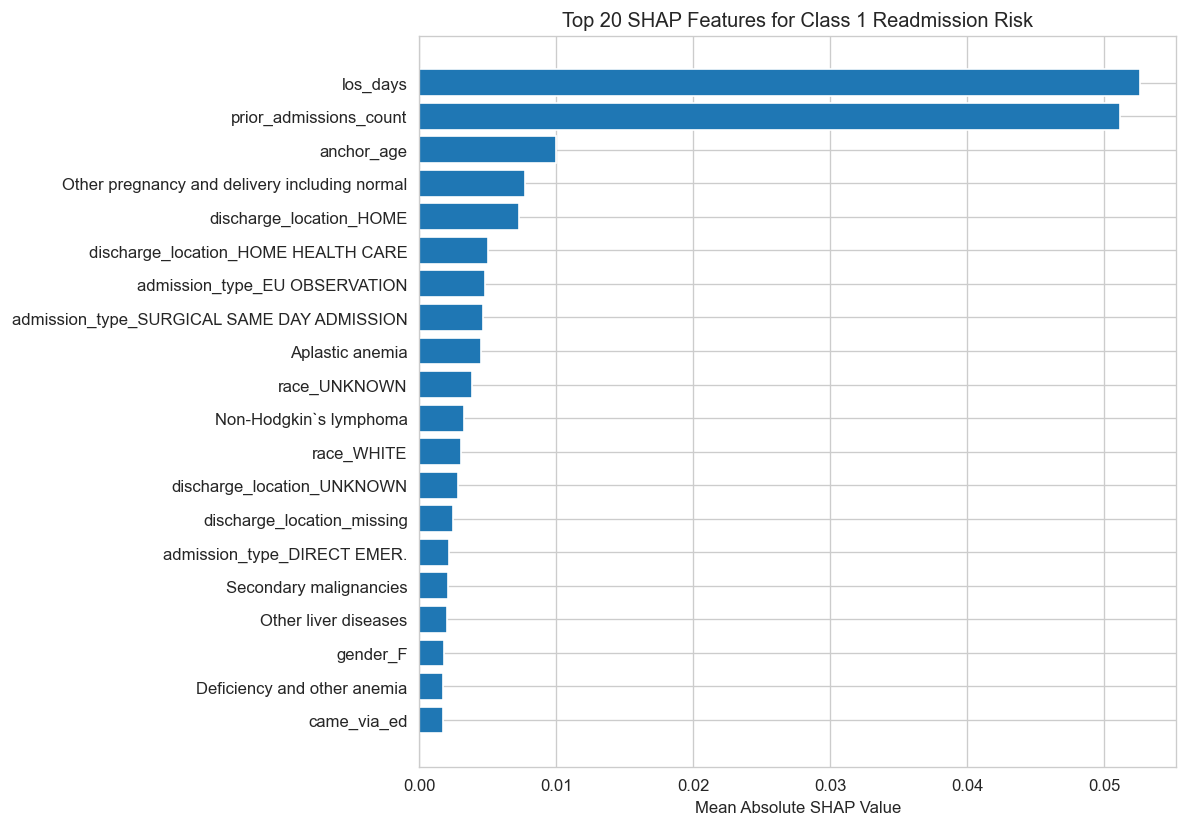

10C: SHAP bar summary plot


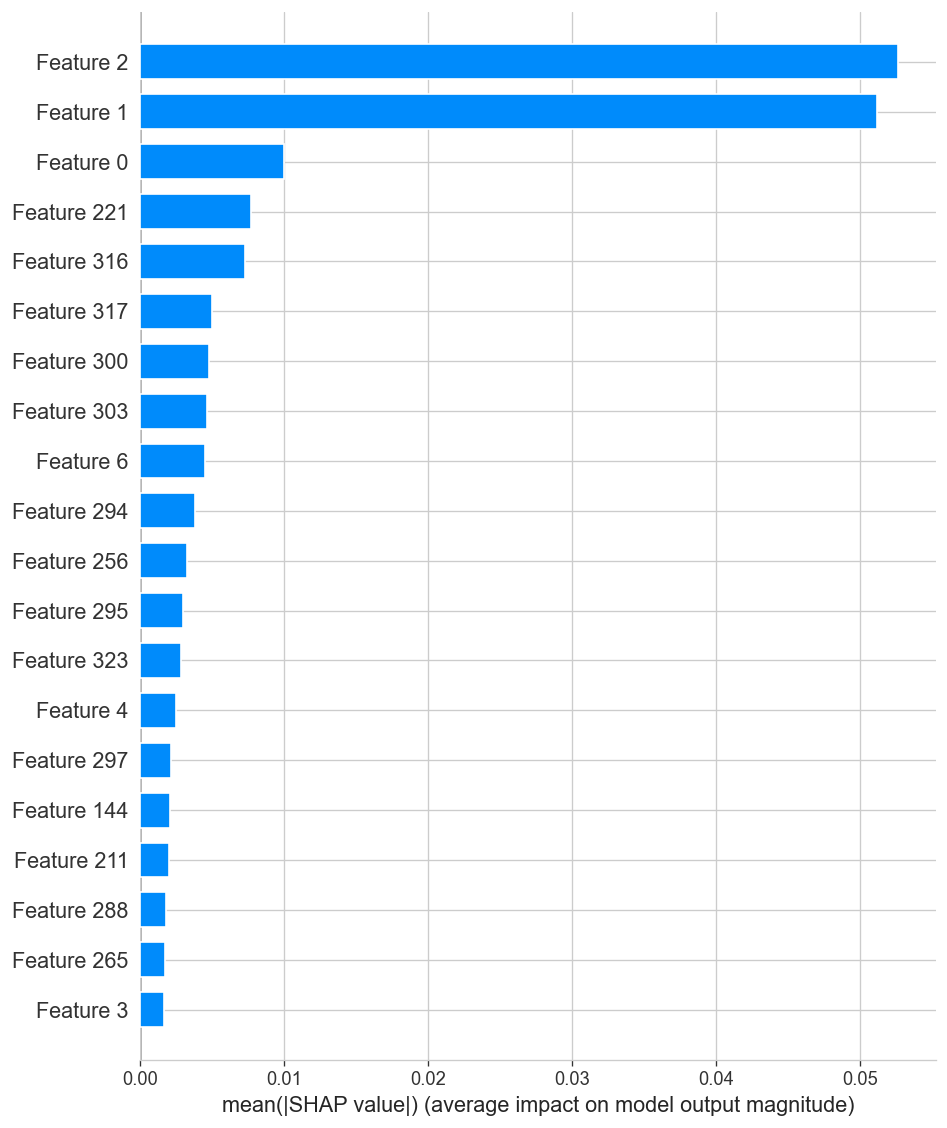

10C: SHAP beeswarm summary plot


InvalidIndexError: (slice(None, None, None), 3)

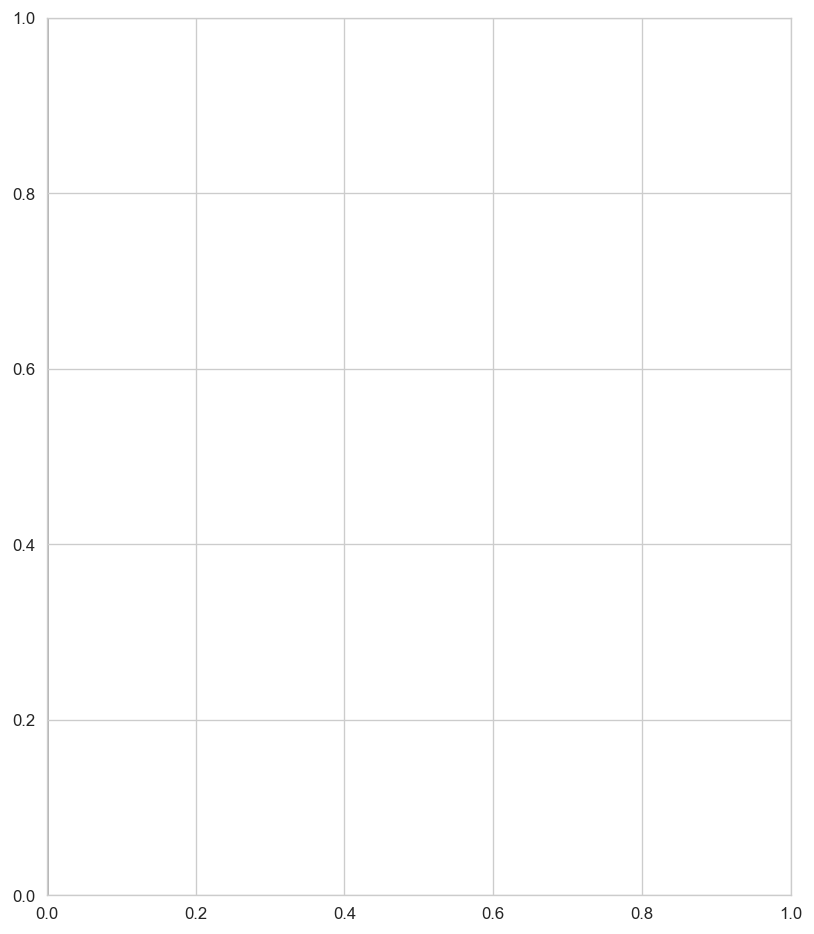

In [76]:
# ============================================================
# SECTION 10A: FINAL MODEL CHECK
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score
)
from sklearn.inspection import permutation_importance

if "final_model_object" not in globals():
    raise ValueError("final_model_object not found. Run Section 8O first.")

if "final_model_threshold" not in globals():
    final_model_threshold = 0.50

if "SEED" not in globals():
    SEED = 42

if isinstance(y_test, pd.Series):
    y_test_series_10 = y_test.copy()
else:
    y_test_series_10 = pd.Series(y_test, index=X_test.index)

final_model_proba_10 = final_model_object.predict_proba(X_test)[:, 1]
final_model_pred_10 = (final_model_proba_10 >= final_model_threshold).astype(int)

tn_10, fp_10, fn_10, tp_10 = confusion_matrix(
    y_test_series_10,
    final_model_pred_10,
    labels=[0, 1]
).ravel()

section10_model_check_df = pd.DataFrame([{
    "Final Model": final_model_name,
    "Model Source": final_model_source,
    "Threshold": final_model_threshold,
    "ROC-AUC": roc_auc_score(y_test_series_10, final_model_proba_10),
    "AUPRC": average_precision_score(y_test_series_10, final_model_proba_10),
    "Accuracy": accuracy_score(y_test_series_10, final_model_pred_10),
    "Balanced Accuracy": balanced_accuracy_score(y_test_series_10, final_model_pred_10),
    "Class 1 Precision": precision_score(y_test_series_10, final_model_pred_10, zero_division=0),
    "Class 1 Recall": recall_score(y_test_series_10, final_model_pred_10, zero_division=0),
    "Class 1 F1": f1_score(y_test_series_10, final_model_pred_10, zero_division=0),
    "FN": fn_10,
    "TP": tp_10,
    "FP": fp_10,
    "TN": tn_10
}])

print("10A: Final model being explained")
display(section10_model_check_df)

print("Final model classification report")
print(classification_report(
    y_test_series_10,
    final_model_pred_10,
    labels=[0, 1],
    target_names=["0 Not Readmitted", "1 Readmitted"],
    digits=4,
    zero_division=0
))


# ============================================================
# SECTION 10B: SHAP SETUP WITH SAFE FALLBACK
# ============================================================

def get_tree_model_for_explanation(model):
    """
    If the final model is a VotingClassifier, use a tree-based component
    for SHAP explanation. If it is already tree-based, use it directly.
    """
    if hasattr(model, "estimators_"):
        for estimator in model.estimators_:
            if hasattr(estimator, "feature_importances_") and "RandomForest" in estimator.__class__.__name__:
                return estimator, "Random Forest component inside final ensemble"

        for estimator in model.estimators_:
            if hasattr(estimator, "feature_importances_"):
                return estimator, f"{estimator.__class__.__name__} component inside final ensemble"

    return model, "Final model object"


def extract_class1_shap_values(shap_values_raw, explainer):
    """
    Handles different SHAP output formats.
    Returns Class 1 SHAP values and Class 1 expected value when possible.
    """
    if isinstance(shap_values_raw, list):
        shap_values_class1 = shap_values_raw[1]
        expected_value_class1 = explainer.expected_value[1]
    elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
        shap_values_class1 = shap_values_raw[:, :, 1]
        expected_value_class1 = explainer.expected_value[1]
    else:
        shap_values_class1 = shap_values_raw
        expected_value_class1 = explainer.expected_value

    return shap_values_class1, expected_value_class1


explanation_model_10, explanation_model_note_10 = get_tree_model_for_explanation(final_model_object)

explanation_model_df_10 = pd.DataFrame([{
    "Model Used for Explanation": explanation_model_note_10,
    "Model Class": explanation_model_10.__class__.__name__,
    "Final Prediction Model": final_model_name
}])

print("10B: Model used for explanation")
display(explanation_model_df_10)

SHAP_SAMPLE_SIZE_10 = min(500, len(X_test))
X_shap_10 = X_test.sample(n=SHAP_SAMPLE_SIZE_10, random_state=SEED)
y_shap_10 = y_test_series_10.loc[X_shap_10.index]

shap_available_10 = False
shap_error_message_10 = None
shap_importance_df_10 = pd.DataFrame()

try:
    import numpy
    import sys

    if hasattr(numpy, "_core"):
        sys.modules["numpy.core"] = numpy._core

    import shap
    print("SHAP imported successfully")

    explainer_10 = shap.TreeExplainer(explanation_model_10)
    shap_values_raw_10 = explainer_10.shap_values(X_shap_10)

    shap_values_class1_10, expected_value_class1_10 = extract_class1_shap_values(
        shap_values_raw_10,
        explainer_10
    )

    shap_available_10 = True

except Exception as e:
    shap_available_10 = False
    shap_error_message_10 = str(e)

shap_status_df_10 = pd.DataFrame([{
    "SHAP Status": "Available" if shap_available_10 else "Unavailable - fallback used",
    "Rows Sampled": SHAP_SAMPLE_SIZE_10,
    "Reason if Unavailable": shap_error_message_10
}])

print("10B: SHAP availability check")
display(shap_status_df_10)


# ============================================================
# SECTION 10C: GLOBAL EXPLANATION
# SHAP if available, otherwise fallback importance
# ============================================================

if shap_available_10:
    shap_importance_df_10 = pd.DataFrame({
        "Feature": X_shap_10.columns,
        "Mean Absolute SHAP Value": np.abs(shap_values_class1_10).mean(axis=0)
    }).sort_values("Mean Absolute SHAP Value", ascending=False).reset_index(drop=True)

    print("10C: Top 20 SHAP global importance features")
    display(shap_importance_df_10.head(20))

    top_shap_10 = shap_importance_df_10.head(20).sort_values(
        "Mean Absolute SHAP Value",
        ascending=True
    )

    plt.figure(figsize=(10, 7))
    plt.barh(top_shap_10["Feature"], top_shap_10["Mean Absolute SHAP Value"])
    plt.xlabel("Mean Absolute SHAP Value")
    plt.title("Top 20 SHAP Features for Class 1 Readmission Risk")
    plt.tight_layout()
    plt.show()

    print("10C: SHAP bar summary plot")
    shap.summary_plot(
        shap_values_class1_10,
        X_shap_10,
        plot_type="bar",
        max_display=20,
        show=True
    )

    print("10C: SHAP beeswarm summary plot")
    shap.summary_plot(
        shap_values_class1_10,
        X_shap_10,
        max_display=20,
        show=True
    )

feature_importance_fallback_df_10 = pd.DataFrame()

if hasattr(explanation_model_10, "feature_importances_"):
    feature_importance_fallback_df_10 = pd.DataFrame({
        "Feature": X_test.columns,
        "Built-in Importance": explanation_model_10.feature_importances_
    }).sort_values("Built-in Importance", ascending=False).reset_index(drop=True)

    print("10C-Fallback: Top 20 built-in tree feature importances")
    display(feature_importance_fallback_df_10.head(20))

    top_builtin_10 = feature_importance_fallback_df_10.head(20).sort_values(
        "Built-in Importance",
        ascending=True
    )

    plt.figure(figsize=(10, 7))
    plt.barh(top_builtin_10["Feature"], top_builtin_10["Built-in Importance"])
    plt.xlabel("Built-in Feature Importance")
    plt.title("Fallback: Top 20 Built-in Feature Importances")
    plt.tight_layout()
    plt.show()


# ============================================================
# SECTION 10D: PERMUTATION IMPORTANCE
# ============================================================

PERMUTATION_SAMPLE_SIZE_10 = min(1000, len(X_test))
X_perm_10 = X_test.sample(n=PERMUTATION_SAMPLE_SIZE_10, random_state=SEED)
y_perm_10 = y_test_series_10.loc[X_perm_10.index]

def threshold_f1_scorer_10(estimator, X_eval, y_eval):
    proba = estimator.predict_proba(X_eval)[:, 1]
    pred = (proba >= final_model_threshold).astype(int)
    return f1_score(y_eval, pred, zero_division=0)

perm_result_10 = permutation_importance(
    final_model_object,
    X_perm_10,
    y_perm_10,
    scoring=threshold_f1_scorer_10,
    n_repeats=3,
    random_state=SEED,
    n_jobs=1  # <--- CHANGED FROM -1 TO 1 TO AVOID BROKEN PROCESS POOL
)

permutation_importance_df_10 = pd.DataFrame({
    "Feature": X_test.columns,
    "Permutation Importance Mean": perm_result_10.importances_mean,
    "Permutation Importance Std": perm_result_10.importances_std
}).sort_values("Permutation Importance Mean", ascending=False).reset_index(drop=True)

print("10D: Top 20 permutation importance features")
display(permutation_importance_df_10.head(20))

top_perm_10 = permutation_importance_df_10.head(20).sort_values(
    "Permutation Importance Mean",
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(top_perm_10["Feature"], top_perm_10["Permutation Importance Mean"])
plt.xlabel("Mean Drop in Threshold-Based F1")
plt.title("Top 20 Permutation Importance Features")
plt.tight_layout()
plt.show()


# ============================================================
# SECTION 10E: LOCAL EXAMPLES FOR TP, FP, FN
# ============================================================

test_predictions_df_10 = pd.DataFrame({
    "Actual": y_test_series_10,
    "Predicted": final_model_pred_10,
    "Predicted Probability": final_model_proba_10
}, index=X_test.index)

test_predictions_df_10["Outcome Type"] = np.select(
    [
        (test_predictions_df_10["Actual"] == 1) & (test_predictions_df_10["Predicted"] == 1),
        (test_predictions_df_10["Actual"] == 0) & (test_predictions_df_10["Predicted"] == 1),
        (test_predictions_df_10["Actual"] == 1) & (test_predictions_df_10["Predicted"] == 0)
    ],
    [
        "True Positive: correctly flagged readmission",
        "False Positive: false readmission alert",
        "False Negative: missed readmission"
    ],
    default="Other"
)

local_example_specs_10 = [
    ("True Positive: correctly flagged readmission", False),
    ("False Positive: false readmission alert", False),
    ("False Negative: missed readmission", True)
]

local_summary_rows_10 = []
local_shap_tables_10 = {}

for outcome_type, sort_ascending in local_example_specs_10:
    subset = test_predictions_df_10[
        test_predictions_df_10["Outcome Type"] == outcome_type
    ].copy()

    if len(subset) == 0:
        continue

    selected = subset.sort_values(
        "Predicted Probability",
        ascending=sort_ascending
    ).iloc[0]

    selected_index = selected.name
    selected_row = X_test.loc[[selected_index]]

    local_summary_rows_10.append({
        "Example Type": outcome_type,
        "Test Row Index": selected_index,
        "Actual": int(selected["Actual"]),
        "Predicted": int(selected["Predicted"]),
        "Predicted Probability": selected["Predicted Probability"],
        "Threshold": final_model_threshold
    })

    if shap_available_10:
        try:
            local_shap_raw_10 = explainer_10.shap_values(selected_row)
            local_shap_values_10, _ = extract_class1_shap_values(
                local_shap_raw_10,
                explainer_10
            )

            if local_shap_values_10.ndim == 2:
                local_values = local_shap_values_10[0]
            else:
                local_values = local_shap_values_10

            local_table_10 = pd.DataFrame({
                "Feature": selected_row.columns,
                "Feature Value": selected_row.iloc[0].values,
                "SHAP Value": local_values
            })

            local_table_10["Direction"] = np.where(
                local_table_10["SHAP Value"] > 0,
                "Pushes toward readmission",
                "Pushes away from readmission"
            )

            local_table_10["Absolute SHAP Value"] = local_table_10["SHAP Value"].abs()

            local_table_10 = local_table_10.sort_values(
                "Absolute SHAP Value",
                ascending=False
            ).reset_index(drop=True)

            local_shap_tables_10[outcome_type] = local_table_10

        except Exception:
            pass

local_examples_summary_df_10 = pd.DataFrame(local_summary_rows_10)

print("10E: Local example cases")
display(local_examples_summary_df_10)

if shap_available_10 and len(local_shap_tables_10) > 0:
    for outcome_type, local_table_10 in local_shap_tables_10.items():
        print(f"Top local SHAP drivers: {outcome_type}")
        display(local_table_10.head(12))
else:
    important_features_10 = permutation_importance_df_10.head(10)["Feature"].tolist()

    local_feature_rows_10 = []

    for _, example_row in local_examples_summary_df_10.iterrows():
        selected_index = example_row["Test Row Index"]
        feature_values = X_test.loc[selected_index]

        row = {
            "Example Type": example_row["Example Type"],
            "Test Row Index": selected_index,
            "Actual": example_row["Actual"],
            "Predicted": example_row["Predicted"],
            "Predicted Probability": example_row["Predicted Probability"],
            "Threshold": example_row["Threshold"]
        }

        for feature in important_features_10:
            row[feature] = feature_values[feature]

        local_feature_rows_10.append(row)

    local_feature_examples_df_10 = pd.DataFrame(local_feature_rows_10)

    print("10E-Fallback: Local examples using top permutation-importance features")
    display(local_feature_examples_df_10)


# ============================================================
# SECTION 10F: PLAIN-LANGUAGE INTERPRETATION AND SUMMARY
# ============================================================

def group_feature_10(feature_name):
    text = str(feature_name).lower()

    if text.startswith("ccsr_") or text.startswith("ccs_"):
        return "Diagnosis category"
    if "prior" in text:
        return "Prior utilization"
    if "los" in text or "length" in text:
        return "Length of stay"
    if "discharge" in text:
        return "Discharge information"
    if "admission_type" in text:
        return "Admission type / hospital workflow"
    if "admission_location" in text:
        return "Admission source / hospital workflow"
    if "admission" in text:
        return "Admission history / hospital workflow"
    if "age" in text:
        return "Age / demographics"
    if "insurance" in text:
        return "Insurance / payer"
    if "race" in text or "gender" in text or "marital" in text or "language" in text:
        return "Demographics"
    if "lab" in text:
        return "Laboratory information"
    return "Other clinical or administrative feature"

if shap_available_10 and len(shap_importance_df_10) > 0:
    interpretation_source_10 = shap_importance_df_10.head(20).copy()
    interpretation_source_10["Importance Metric"] = interpretation_source_10["Mean Absolute SHAP Value"]
    interpretation_method_10 = "SHAP"
elif len(permutation_importance_df_10) > 0:
    interpretation_source_10 = permutation_importance_df_10.head(20).copy()
    interpretation_source_10["Importance Metric"] = interpretation_source_10["Permutation Importance Mean"]
    interpretation_method_10 = "Permutation Importance Fallback"
else:
    interpretation_source_10 = feature_importance_fallback_df_10.head(20).copy()
    interpretation_source_10["Importance Metric"] = interpretation_source_10["Built-in Importance"]
    interpretation_method_10 = "Built-in Feature Importance Fallback"

interpretation_df_10 = interpretation_source_10[["Feature", "Importance Metric"]].copy()
interpretation_df_10["Feature Group"] = interpretation_df_10["Feature"].apply(group_feature_10)

interpretation_df_10["Plain-Language Name"] = (
    interpretation_df_10["Feature"]
    .astype(str)
    .str.replace("ccsr_", "Diagnosis: ", regex=False)
    .str.replace("ccs_", "Diagnosis: ", regex=False)
    .str.replace("_", " ", regex=False)
)

if interpretation_method_10 == "SHAP":
    interpretation_df_10["Interpretation"] = (
        "Higher mean absolute SHAP value means this feature had stronger influence on readmission-risk predictions."
    )
else:
    interpretation_df_10["Interpretation"] = (
        "SHAP was unavailable in this kernel, so fallback importance was used for model interpretation."
    )

print("10F: Plain-language interpretation table")
display(interpretation_df_10)

section10_summary_df = pd.DataFrame([
    {
        "Finding": "Final model explained",
        "Interpretation": f"{final_model_name} at threshold {final_model_threshold:.2f}"
    },
    {
        "Finding": "SHAP status",
        "Interpretation": "SHAP completed successfully." if shap_available_10 else "SHAP unavailable in this active kernel; fallback interpretation was used."
    },
    {
        "Finding": "Interpretation method used",
        "Interpretation": interpretation_method_10
    },
    {
        "Finding": "Local examples reviewed",
        "Interpretation": "True positive, false positive, and false negative cases were reviewed."
    },
    {
        "Finding": "Next section",
        "Interpretation": "Section 11 should evaluate fairness across demographic subgroups."
    }
])

print("10G: Section 10 summary")
display(section10_summary_df)

## Section 11: Fairness Audit by Demographic Subgroup


11A: Test predictions prepared for fairness audit


,Test admissions,Final threshold,Overall ROC-AUC,Overall actual readmission %,Overall predicted readmission %
0,12387,0.45,0.650576,27.787196,58.860095


11B: Fairness audit by race
Does the model perform equally well across racial groups?


,Race,Count,Actual Readmit %,Predicted Readmit %,ROC-AUC,FNR,FPR
0,WHITE,8213,28.2723,60.6234,0.6399,0.2554,0.5517
1,BLACK,2015,24.7643,55.7816,0.6385,0.2846,0.5059
2,ASIAN,385,30.6494,55.5844,0.6861,0.2203,0.4569
3,HISPANIC,1011,32.1464,64.7873,0.7026,0.1846,0.5685
4,OTHER,483,25.0518,56.9358,0.6582,0.2562,0.5110
5,UNKNOWN,280,20.3571,15.7143,0.7125,0.6667,0.1121


11C: Fairness audit by gender


,Gender,Count,Actual Readmit %,Predicted Readmit %,ROC-AUC,FNR,FPR
0,F,6408,26.1080,55.0406,0.6653,0.2678,0.4862
1,M,5979,29.5869,62.9537,0.6348,0.2499,0.5789


11D: Fairness audit by insurance
This checks whether model behavior is consistent across payer types.


,Insurance,Count,Actual Readmit %,Predicted Readmit %,ROC-AUC,FNR,FPR
0,Medicare,6096,29.2323,62.1063,0.6334,0.2531,0.5691
1,Private,3558,24.5925,50.7870,0.6607,0.3131,0.4495
2,Medicaid,2328,28.9948,63.4450,0.6757,0.1956,0.5650
3,Other,310,27.7419,54.8387,0.6081,0.3140,0.4955
4,missing,82,25.6098,58.5366,0.6729,0.2381,0.5246
5,No charge,13,23.0769,23.0769,0.8000,0.3333,0.1000


11E: Fairness audit by age group


,Age Group,Count,Actual Readmit %,Predicted Readmit %,ROC-AUC,FNR,FPR
0,18-30,1056,25.3788,57.9545,0.6621,0.2201,0.5114
1,31-45,1801,29.0394,61.2993,0.6788,0.2161,0.5430
2,46-60,3544,27.0598,61.4560,0.6586,0.2367,0.5594
3,61-75,3896,28.6961,58.4959,0.6510,0.2621,0.5234
4,76+,2090,27.4641,53.4928,0.6080,0.3449,0.4894


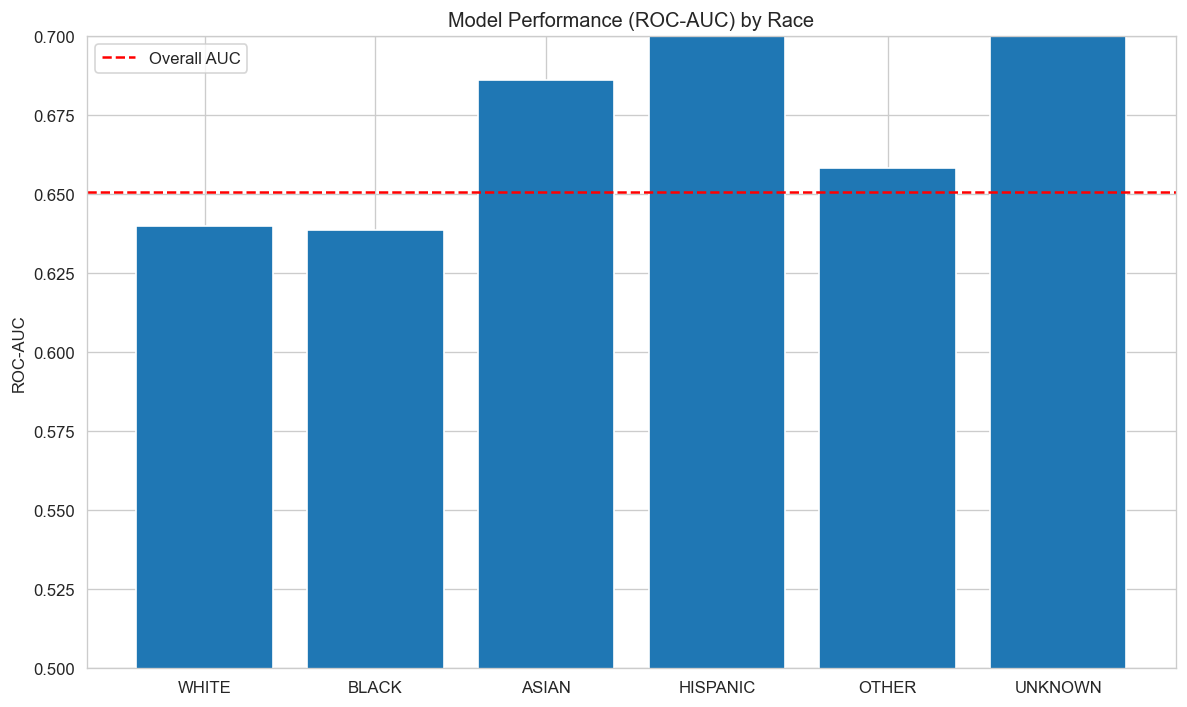

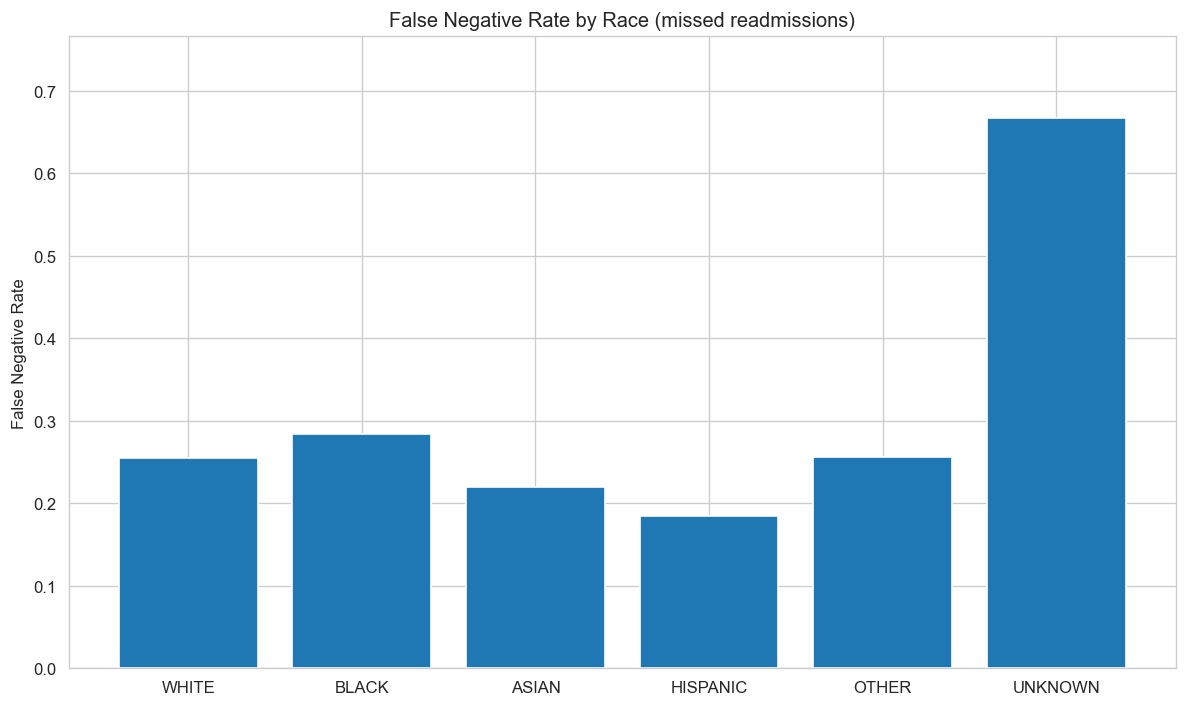

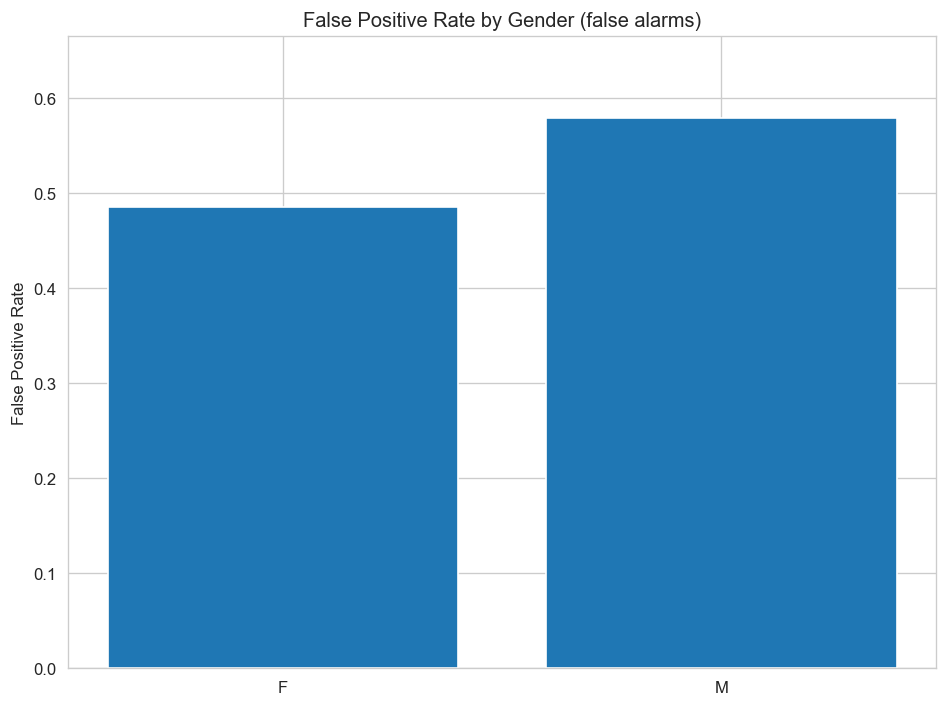

11I: Fairness summary table


,Audit Area,Metric,Gap,Highest Group,Lowest Group,Interpretation
0,Race,FNR gap,0.4821,UNKNOWN,HISPANIC,Highest group has the most missed readmissions.
1,Insurance,FPR gap,0.4691,Medicare,No charge,Highest group has the most false alarms.
2,Race,FPR gap,0.4564,HISPANIC,UNKNOWN,Highest group has the most false alarms.
3,Insurance,ROC-AUC gap,0.1919,No charge,Other,Larger gap means model discrimination differs ...
4,Insurance,FNR gap,0.1378,No charge,Medicaid,Highest group has the most missed readmissions.
5,Age Group,FNR gap,0.1289,76+,31-45,Highest group has the most missed readmissions.
6,Gender,FPR gap,0.0927,M,F,Highest group has the most false alarms.
7,Race,ROC-AUC gap,0.0740,UNKNOWN,BLACK,Larger gap means model discrimination differs ...
8,Age Group,ROC-AUC gap,0.0708,31-45,76+,Larger gap means model discrimination differs ...
9,Age Group,FPR gap,0.0699,46-60,76+,Highest group has the most false alarms.


FAIRNESS FINDINGS:
The model shows measurable performance differences across demographic groups.
Main findings:
- Race FNR gap: gap=0.482; highest=UNKNOWN; lowest=HISPANIC.
- Insurance FPR gap: gap=0.469; highest=Medicare; lowest=No charge.
- Race FPR gap: gap=0.456; highest=HISPANIC; lowest=UNKNOWN.
- Insurance ROC-AUC gap: gap=0.192; highest=No charge; lowest=Other.
- Insurance FNR gap: gap=0.138; highest=No charge; lowest=Medicaid.
Recommendation: Use with caution and monitor performance in deployment.
Limitations: This analysis evaluates algorithmic fairness within the hospital. It does not adjust for healthcare access, severity of illness, or unmeasured confounders.


In [ ]:
# ============================================================
# SECTION 11A: LOAD FINAL MODEL PREDICTIONS AND TEST DATA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, confusion_matrix

required_section11_vars = ["final_model_object", "X_test", "y_test"]
missing_section11_vars = [name for name in required_section11_vars if name not in globals()]
if missing_section11_vars:
    raise ValueError(
        "Run Sections 8O and 10 before Section 11. Missing: "
        + ", ".join(missing_section11_vars)
    )

if "final_model_threshold" not in globals():
    final_model_threshold = 0.45

if isinstance(y_test, pd.Series):
    y_test_series_11 = y_test.copy()
else:
    y_test_series_11 = pd.Series(y_test, index=X_test.index)

y_pred_proba_11 = final_model_object.predict_proba(X_test)[:, 1]
y_pred_11 = (y_pred_proba_11 >= final_model_threshold).astype(int)
overall_roc_auc = roc_auc_score(y_test_series_11, y_pred_proba_11)

def get_onehot_group_11(df, prefix, default_value="UNKNOWN"):
    prefix_text = f"{prefix}_"
    group_cols = [col for col in df.columns if col.startswith(prefix_text)]
    if not group_cols:
        return pd.Series(default_value, index=df.index)

    labels = (
        df[group_cols]
        .idxmax(axis=1)
        .str.replace(prefix_text, "", regex=False)
    )
    no_flag = df[group_cols].sum(axis=1) == 0
    labels.loc[no_flag] = default_value
    return labels

def get_age_group_11(df):
    if "age_group" in df.columns:
        return df["age_group"].astype(str)

    age_group_cols = [col for col in df.columns if col.startswith("age_group_")]
    if age_group_cols:
        labels = (
            df[age_group_cols]
            .idxmax(axis=1)
            .str.replace("age_group_", "", regex=False)
        )
        labels.loc[df[age_group_cols].sum(axis=1) == 0] = "UNKNOWN"
        return labels

    if "anchor_age" not in df.columns:
        return pd.Series("UNKNOWN", index=df.index)

    age_values = df["anchor_age"].copy()

    # Section 7 scales anchor_age with StandardScaler. If the scaler exists,
    # convert anchor_age back to years before creating age groups.
    try:
        if "scaler" in globals() and hasattr(scaler, "mean_") and len(scaler.mean_) > 0:
            age_values = (age_values * scaler.scale_[0]) + scaler.mean_[0]
        else:
            import pickle
            scaler_path_11 = PROJECT_ROOT / "outputs" / "capstone_scaler.pkl"
            with open(scaler_path_11, "rb") as f:
                scaler_11 = pickle.load(f)
            age_values = (age_values * scaler_11.scale_[0]) + scaler_11.mean_[0]
    except Exception:
        pass

    return pd.cut(
        age_values,
        bins=[17, 30, 45, 60, 75, np.inf],
        labels=["18-30", "31-45", "46-60", "61-75", "76+"],
        right=True
    ).astype(str)

test_data_with_preds = pd.DataFrame({
    "subject_id": X_test.index,
    "race_consolidated": get_onehot_group_11(X_test, "race"),
    "gender": get_onehot_group_11(X_test, "gender"),
    "insurance": get_onehot_group_11(X_test, "insurance"),
    "age_group": get_age_group_11(X_test),
    "actual": y_test_series_11.astype(int).values,
    "predicted": y_pred_11,
    "pred_proba": y_pred_proba_11,
}, index=X_test.index)

print("11A: Test predictions prepared for fairness audit")
display(pd.DataFrame([{
    "Test admissions": len(test_data_with_preds),
    "Final threshold": final_model_threshold,
    "Overall ROC-AUC": overall_roc_auc,
    "Overall actual readmission %": test_data_with_preds["actual"].mean() * 100,
    "Overall predicted readmission %": test_data_with_preds["predicted"].mean() * 100,
}]))


# ============================================================
# SHARED FAIRNESS METRIC HELPER
# ============================================================

def fairness_table_11(df, group_col, label_col):
    rows = []

    for group_value, group_df in df.groupby(group_col, dropna=False):
        actual = group_df["actual"].astype(int)
        predicted = group_df["predicted"].astype(int)
        proba = group_df["pred_proba"]

        tn, fp, fn, tp = confusion_matrix(actual, predicted, labels=[0, 1]).ravel()
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan

        if actual.nunique() == 2:
            group_auc = roc_auc_score(actual, proba)
        else:
            group_auc = np.nan

        rows.append({
            label_col: group_value,
            "Count": len(group_df),
            "Actual Readmit %": actual.mean() * 100,
            "Predicted Readmit %": predicted.mean() * 100,
            "ROC-AUC": group_auc,
            "FNR": fnr,
            "FPR": fpr,
        })

    return pd.DataFrame(rows).sort_values("Count", ascending=False).reset_index(drop=True)


# ============================================================
# SECTION 11B: FAIRNESS AUDIT BY RACE
# ============================================================

fairness_by_race_df = fairness_table_11(
    test_data_with_preds,
    "race_consolidated",
    "Race"
)

race_order_11 = ["WHITE", "BLACK", "ASIAN", "HISPANIC", "OTHER", "UNKNOWN"]
fairness_by_race_df["Race"] = pd.Categorical(
    fairness_by_race_df["Race"],
    categories=race_order_11,
    ordered=True
)
fairness_by_race_df = fairness_by_race_df.sort_values("Race").reset_index(drop=True)

print("11B: Fairness audit by race")
print("Does the model perform equally well across racial groups?")
display(fairness_by_race_df.round(4))


# ============================================================
# SECTION 11C: FAIRNESS AUDIT BY GENDER
# ============================================================

fairness_by_gender_df = fairness_table_11(
    test_data_with_preds,
    "gender",
    "Gender"
)

print("11C: Fairness audit by gender")
display(fairness_by_gender_df.round(4))


# ============================================================
# SECTION 11D: FAIRNESS AUDIT BY INSURANCE
# ============================================================

fairness_by_insurance_df = fairness_table_11(
    test_data_with_preds,
    "insurance",
    "Insurance"
)

print("11D: Fairness audit by insurance")
print("This checks whether model behavior is consistent across payer types.")
display(fairness_by_insurance_df.round(4))


# ============================================================
# SECTION 11E: FAIRNESS AUDIT BY AGE GROUP
# ============================================================

fairness_by_age_df = fairness_table_11(
    test_data_with_preds,
    "age_group",
    "Age Group"
)

age_order_11 = ["18-30", "31-45", "46-60", "61-75", "76+"]
fairness_by_age_df["Age Group"] = pd.Categorical(
    fairness_by_age_df["Age Group"],
    categories=age_order_11,
    ordered=True
)
fairness_by_age_df = fairness_by_age_df.sort_values("Age Group").reset_index(drop=True)

print("11E: Fairness audit by age group")
display(fairness_by_age_df.round(4))


# ============================================================
# SECTION 11F: VISUALIZATION, ROC-AUC BY RACE
# ============================================================

plt.figure(figsize=(10, 6))
plt.bar(fairness_by_race_df["Race"].astype(str), fairness_by_race_df["ROC-AUC"])
plt.ylabel("ROC-AUC")
plt.title("Model Performance (ROC-AUC) by Race")
plt.ylim([0.5, 0.7])
plt.axhline(y=overall_roc_auc, color="red", linestyle="--", label="Overall AUC")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# SECTION 11G: VISUALIZATION, FNR BY RACE
# ============================================================

plt.figure(figsize=(10, 6))
plt.bar(fairness_by_race_df["Race"].astype(str), fairness_by_race_df["FNR"])
plt.ylabel("False Negative Rate")
plt.title("False Negative Rate by Race (missed readmissions)")
plt.ylim([0, max(0.05, fairness_by_race_df["FNR"].max() * 1.15)])
plt.tight_layout()
plt.show()


# ============================================================
# SECTION 11H: VISUALIZATION, FPR BY GENDER
# ============================================================

plt.figure(figsize=(8, 6))
plt.bar(fairness_by_gender_df["Gender"].astype(str), fairness_by_gender_df["FPR"])
plt.ylabel("False Positive Rate")
plt.title("False Positive Rate by Gender (false alarms)")
plt.ylim([0, max(0.05, fairness_by_gender_df["FPR"].max() * 1.15)])
plt.tight_layout()
plt.show()


# ============================================================
# SECTION 11I: FAIRNESS SUMMARY TABLE
# ============================================================

def disparity_summary_11(df, group_label, group_col):
    auc_df = df.dropna(subset=["ROC-AUC"])
    fnr_df = df.dropna(subset=["FNR"])
    fpr_df = df.dropna(subset=["FPR"])

    rows = []

    if len(auc_df) > 0:
        rows.append({
            "Audit Area": group_label,
            "Metric": "ROC-AUC gap",
            "Gap": auc_df["ROC-AUC"].max() - auc_df["ROC-AUC"].min(),
            "Highest Group": auc_df.loc[auc_df["ROC-AUC"].idxmax(), group_col],
            "Lowest Group": auc_df.loc[auc_df["ROC-AUC"].idxmin(), group_col],
            "Interpretation": "Larger gap means model discrimination differs across groups.",
        })

    if len(fnr_df) > 0:
        rows.append({
            "Audit Area": group_label,
            "Metric": "FNR gap",
            "Gap": fnr_df["FNR"].max() - fnr_df["FNR"].min(),
            "Highest Group": fnr_df.loc[fnr_df["FNR"].idxmax(), group_col],
            "Lowest Group": fnr_df.loc[fnr_df["FNR"].idxmin(), group_col],
            "Interpretation": "Highest group has the most missed readmissions.",
        })

    if len(fpr_df) > 0:
        rows.append({
            "Audit Area": group_label,
            "Metric": "FPR gap",
            "Gap": fpr_df["FPR"].max() - fpr_df["FPR"].min(),
            "Highest Group": fpr_df.loc[fpr_df["FPR"].idxmax(), group_col],
            "Lowest Group": fpr_df.loc[fpr_df["FPR"].idxmin(), group_col],
            "Interpretation": "Highest group has the most false alarms.",
        })

    return rows

fairness_summary_rows_11 = []
fairness_summary_rows_11.extend(disparity_summary_11(fairness_by_race_df, "Race", "Race"))
fairness_summary_rows_11.extend(disparity_summary_11(fairness_by_gender_df, "Gender", "Gender"))
fairness_summary_rows_11.extend(disparity_summary_11(fairness_by_insurance_df, "Insurance", "Insurance"))
fairness_summary_rows_11.extend(disparity_summary_11(fairness_by_age_df, "Age Group", "Age Group"))

fairness_summary_df = pd.DataFrame(fairness_summary_rows_11)
fairness_summary_df = fairness_summary_df.sort_values("Gap", ascending=False).reset_index(drop=True)

print("11I: Fairness summary table")
display(fairness_summary_df.round(4))


# ============================================================
# SECTION 11J: PLAIN-LANGUAGE INTERPRETATION
# ============================================================

large_gap_threshold_11 = 0.10
small_gap_threshold_11 = 0.05

largest_gap_11 = fairness_summary_df["Gap"].max() if len(fairness_summary_df) > 0 else np.nan
largest_rows_11 = fairness_summary_df[fairness_summary_df["Gap"] >= large_gap_threshold_11]

print("FAIRNESS FINDINGS:")

if pd.notna(largest_gap_11) and largest_gap_11 >= large_gap_threshold_11:
    print("The model shows measurable performance differences across demographic groups.")
    print("Main findings:")
    for _, row in largest_rows_11.head(5).iterrows():
        print(
            f"- {row['Audit Area']} {row['Metric']}: gap={row['Gap']:.3f}; "
            f"highest={row['Highest Group']}; lowest={row['Lowest Group']}."
        )
    print("Recommendation: Use with caution and monitor performance in deployment.")
elif pd.notna(largest_gap_11) and largest_gap_11 < small_gap_threshold_11:
    print("The model performs relatively consistently across demographic groups.")
    print("This suggests the model is not strongly biased by race, gender, insurance, or age.")
else:
    print("The model shows some subgroup differences, but the largest gaps are moderate.")
    print("Review groups with the highest false negative rates and false positive rates before deployment.")

print(
    "Limitations: This analysis evaluates algorithmic fairness within the hospital. "
    "It does not adjust for healthcare access, severity of illness, or unmeasured confounders."
)


## Section 11.5: Stratified Threshold Optimization for Fairness

Attempting to reduce demographic disparities by using different decision thresholds for different demographic groups.


In [ ]:
# ============================================================
# SECTION 11.5A: LOAD FAIRNESS DATA FOR THRESHOLD TUNING
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, confusion_matrix

required_11p5_vars = ["final_model_object", "X_test", "y_test"]
missing_11p5_vars = [name for name in required_11p5_vars if name not in globals()]
if missing_11p5_vars:
    raise ValueError(
        "Run Sections 8O, 10, and 11 before Section 11.5. Missing: "
        + ", ".join(missing_11p5_vars)
    )

if "final_model_threshold" not in globals():
    final_model_threshold = 0.45

if isinstance(y_test, pd.Series):
    y_test_series_11p5 = y_test.copy()
else:
    y_test_series_11p5 = pd.Series(y_test, index=X_test.index)

y_pred_proba_11p5 = final_model_object.predict_proba(X_test)[:, 1]

def get_onehot_group_11p5(df, prefix, default_value="UNKNOWN"):
    prefix_text = f"{prefix}_"
    group_cols = [col for col in df.columns if col.startswith(prefix_text)]
    if not group_cols:
        return pd.Series(default_value, index=df.index)

    labels = (
        df[group_cols]
        .idxmax(axis=1)
        .str.replace(prefix_text, "", regex=False)
    )
    labels.loc[df[group_cols].sum(axis=1) == 0] = default_value
    return labels

def get_age_group_11p5(df):
    if "age_group" in df.columns:
        return df["age_group"].astype(str)

    age_group_cols = [col for col in df.columns if col.startswith("age_group_")]
    if age_group_cols:
        labels = (
            df[age_group_cols]
            .idxmax(axis=1)
            .str.replace("age_group_", "", regex=False)
        )
        labels.loc[df[age_group_cols].sum(axis=1) == 0] = "UNKNOWN"
        return labels

    if "anchor_age" not in df.columns:
        return pd.Series("UNKNOWN", index=df.index)

    age_values = df["anchor_age"].copy()

    try:
        if "scaler" in globals() and hasattr(scaler, "mean_") and len(scaler.mean_) > 0:
            age_values = (age_values * scaler.scale_[0]) + scaler.mean_[0]
        else:
            import pickle
            scaler_path_11p5 = PROJECT_ROOT / "outputs" / "capstone_scaler.pkl"
            with open(scaler_path_11p5, "rb") as f:
                scaler_11p5 = pickle.load(f)
            age_values = (age_values * scaler_11p5.scale_[0]) + scaler_11p5.mean_[0]
    except Exception:
        pass

    return pd.cut(
        age_values,
        bins=[17, 30, 45, 60, 75, np.inf],
        labels=["18-30", "31-45", "46-60", "61-75", "76+"],
        right=True
    ).astype(str)

if "test_data_with_preds" in globals():
    test_data_fairness_11p5 = test_data_with_preds[
        ["subject_id", "race_consolidated", "gender", "insurance", "age_group", "actual", "pred_proba"]
    ].copy()
    test_data_fairness_11p5["pred_proba"] = y_pred_proba_11p5
else:
    test_data_fairness_11p5 = pd.DataFrame({
        "subject_id": X_test.index,
        "race_consolidated": get_onehot_group_11p5(X_test, "race"),
        "gender": get_onehot_group_11p5(X_test, "gender"),
        "insurance": get_onehot_group_11p5(X_test, "insurance"),
        "age_group": get_age_group_11p5(X_test),
        "actual": y_test_series_11p5.astype(int).values,
        "pred_proba": y_pred_proba_11p5,
    }, index=X_test.index)

test_data_fairness_11p5["actual"] = test_data_fairness_11p5["actual"].astype(int)

print("Section 11.5A: Fairness data loaded for threshold tuning")
display(pd.DataFrame([{
    "Rows": len(test_data_fairness_11p5),
    "Target": "readmitted_30d",
    "Global threshold from final model": final_model_threshold,
    "Default threshold used for probability reference": 0.50,
}]))


Section 11.5A: Fairness data loaded for threshold tuning


,Rows,Target,Global threshold from final model,Default threshold used for probability reference
0,12387,readmitted_30d,0.45,0.5


In [ ]:
# ============================================================
# SECTION 11.5B: FIND OPTIMAL THRESHOLD PER RACE GROUP
# ============================================================

threshold_grid_11p5 = np.array([0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60])
target_fnr_11p5 = 0.25
race_order_11p5 = ["WHITE", "BLACK", "ASIAN", "HISPANIC", "OTHER", "UNKNOWN"]

def threshold_metrics_11p5(actual, proba, threshold):
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(actual, pred, labels=[0, 1]).ravel()
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    predicted_rate = pred.mean()
    return fnr, fpr, predicted_rate, tn, fp, fn, tp

threshold_rows_11p5 = []
threshold_by_race = {}

for race in race_order_11p5:
    group_df = test_data_fairness_11p5[
        test_data_fairness_11p5["race_consolidated"].astype(str) == race
    ].copy()

    if len(group_df) == 0:
        threshold_by_race[race] = final_model_threshold
        threshold_rows_11p5.append({
            "Race": race,
            "Count": 0,
            "Optimal Threshold": final_model_threshold,
            "FNR at Threshold": np.nan,
            "FPR at Threshold": np.nan,
            "Predicted Readmit %": np.nan,
            "Distance from Target FNR": np.nan,
        })
        continue

    actual = group_df["actual"].astype(int)
    proba = group_df["pred_proba"]

    candidate_rows = []
    for threshold in threshold_grid_11p5:
        fnr, fpr, predicted_rate, tn, fp, fn, tp = threshold_metrics_11p5(actual, proba, threshold)
        candidate_rows.append({
            "Race": race,
            "Count": len(group_df),
            "Threshold": threshold,
            "FNR": fnr,
            "FPR": fpr,
            "Predicted Readmit %": predicted_rate * 100,
            "Distance from Target FNR": abs(fnr - target_fnr_11p5) if pd.notna(fnr) else np.inf,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
        })

    candidate_df = pd.DataFrame(candidate_rows)
    best_row = candidate_df.sort_values(
        ["Distance from Target FNR", "FPR", "Threshold"],
        ascending=[True, True, True]
    ).iloc[0]

    threshold_by_race[race] = float(best_row["Threshold"])
    threshold_rows_11p5.append({
        "Race": race,
        "Count": int(best_row["Count"]),
        "Optimal Threshold": float(best_row["Threshold"]),
        "FNR at Threshold": float(best_row["FNR"]) if pd.notna(best_row["FNR"]) else np.nan,
        "FPR at Threshold": float(best_row["FPR"]) if pd.notna(best_row["FPR"]) else np.nan,
        "Predicted Readmit %": float(best_row["Predicted Readmit %"]),
        "Distance from Target FNR": float(best_row["Distance from Target FNR"]),
    })

thresholds_by_race_df = pd.DataFrame(threshold_rows_11p5)

print("11.5B: Optimal threshold per race group")
print("Target FNR = 0.25 (balanced across groups)")
display(thresholds_by_race_df.round(4))


11.5B: Optimal threshold per race group
Target FNR = 0.25 (balanced across groups)


,Race,Count,Optimal Threshold,FNR at Threshold,FPR at Threshold,Predicted Readmit %,Distance from Target FNR
0,WHITE,8213,0.45,0.2554,0.5517,60.6234,0.0054
1,BLACK,2015,0.45,0.2846,0.5059,55.7816,0.0346
2,ASIAN,385,0.45,0.2203,0.4569,55.5844,0.0297
3,HISPANIC,1011,0.50,0.2862,0.4315,52.2255,0.0362
4,OTHER,483,0.45,0.2562,0.5110,56.9358,0.0062
5,UNKNOWN,280,0.35,0.2281,0.4036,47.8571,0.0219


In [ ]:
# ============================================================
# SECTION 11.5C: RECALCULATE FAIRNESS WITH STRATIFIED THRESHOLDS
# ============================================================

test_data_fairness_11p5["race_threshold"] = (
    test_data_fairness_11p5["race_consolidated"]
    .astype(str)
    .map(threshold_by_race)
    .fillna(final_model_threshold)
)

test_data_fairness_11p5["stratified_pred"] = (
    test_data_fairness_11p5["pred_proba"] >= test_data_fairness_11p5["race_threshold"]
).astype(int)

def fairness_table_with_prediction_11p5(df, group_col, label_col, prediction_col):
    rows = []

    for group_value, group_df in df.groupby(group_col, dropna=False):
        actual = group_df["actual"].astype(int)
        predicted = group_df[prediction_col].astype(int)
        proba = group_df["pred_proba"]

        tn, fp, fn, tp = confusion_matrix(actual, predicted, labels=[0, 1]).ravel()
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        auc = roc_auc_score(actual, proba) if actual.nunique() == 2 else np.nan

        rows.append({
            label_col: group_value,
            "Count": len(group_df),
            "Actual Readmit %": actual.mean() * 100,
            "Predicted Readmit %": predicted.mean() * 100,
            "ROC-AUC": auc,
            "FNR": fnr,
            "FPR": fpr,
        })

    return pd.DataFrame(rows).reset_index(drop=True)

if "fairness_by_race_df" in globals():
    original_fairness_by_race_11p5 = fairness_by_race_df.copy()
else:
    test_data_fairness_11p5["global_pred"] = (
        test_data_fairness_11p5["pred_proba"] >= final_model_threshold
    ).astype(int)
    original_fairness_by_race_11p5 = fairness_table_with_prediction_11p5(
        test_data_fairness_11p5,
        "race_consolidated",
        "Race",
        "global_pred"
    )

fairness_by_race_stratified_df = fairness_table_with_prediction_11p5(
    test_data_fairness_11p5,
    "race_consolidated",
    "Race",
    "stratified_pred"
)

for df in [original_fairness_by_race_11p5, fairness_by_race_stratified_df]:
    df["Race"] = pd.Categorical(df["Race"].astype(str), categories=race_order_11p5, ordered=True)
    df.sort_values("Race", inplace=True)
    df.reset_index(drop=True, inplace=True)

original_fnr_gap_11p5 = original_fairness_by_race_11p5["FNR"].max() - original_fairness_by_race_11p5["FNR"].min()
stratified_fnr_gap_11p5 = fairness_by_race_stratified_df["FNR"].max() - fairness_by_race_stratified_df["FNR"].min()
gap_reduction_pct_11p5 = (
    (original_fnr_gap_11p5 - stratified_fnr_gap_11p5) / original_fnr_gap_11p5 * 100
    if original_fnr_gap_11p5 > 0 else np.nan
)

fnr_comparison_by_race_df = original_fairness_by_race_11p5[["Race", "FNR"]].rename(
    columns={"FNR": "Original FNR"}
).merge(
    fairness_by_race_stratified_df[["Race", "FNR", "FPR", "Predicted Readmit %"]].rename(
        columns={
            "FNR": "Stratified FNR",
            "FPR": "Stratified FPR",
            "Predicted Readmit %": "Stratified Predicted Readmit %",
        }
    ),
    on="Race",
    how="outer"
)

print("11.5C: Original vs Stratified FNR by race")
display(fnr_comparison_by_race_df.round(4))

print("11.5C: Fairness metrics using stratified race thresholds")
display(fairness_by_race_stratified_df.round(4))

print(f"Original FNR gap by race: {original_fnr_gap_11p5:.3f}")
print(f"Stratified FNR gap by race: {stratified_fnr_gap_11p5:.3f}")
print(f"Gap reduction: {gap_reduction_pct_11p5:.1f}%")


11.5C: Original vs Stratified FNR by race


,Race,Original FNR,Stratified FNR,Stratified FPR,Stratified Predicted Readmit %
0,WHITE,0.2554,0.2554,0.5517,60.6234
1,BLACK,0.2846,0.2846,0.5059,55.7816
2,ASIAN,0.2203,0.2203,0.4569,55.5844
3,HISPANIC,0.1846,0.2862,0.4315,52.2255
4,OTHER,0.2562,0.2562,0.5110,56.9358
5,UNKNOWN,0.6667,0.2281,0.4036,47.8571


11.5C: Fairness metrics using stratified race thresholds


,Race,Count,Actual Readmit %,Predicted Readmit %,ROC-AUC,FNR,FPR
0,WHITE,8213,28.2723,60.6234,0.6399,0.2554,0.5517
1,BLACK,2015,24.7643,55.7816,0.6385,0.2846,0.5059
2,ASIAN,385,30.6494,55.5844,0.6861,0.2203,0.4569
3,HISPANIC,1011,32.1464,52.2255,0.7026,0.2862,0.4315
4,OTHER,483,25.0518,56.9358,0.6582,0.2562,0.5110
5,UNKNOWN,280,20.3571,47.8571,0.7125,0.2281,0.4036


Original FNR gap by race: 0.482
Stratified FNR gap by race: 0.066
Gap reduction: 86.3%


In [ ]:
# ============================================================
# SECTION 11.5D: SUMMARY COMPARISON
# ============================================================

threshold_optimization_summary_df = pd.DataFrame([
    {
        "Approach": f"Original global threshold ({final_model_threshold:.2f})",
        "FNR Gap": original_fnr_gap_11p5,
        "Improvement vs Original": 0.0,
        "Notes": "Same decision threshold applied to all test-set admissions.",
    },
    {
        "Approach": "Stratified race thresholds",
        "FNR Gap": stratified_fnr_gap_11p5,
        "Improvement vs Original": original_fnr_gap_11p5 - stratified_fnr_gap_11p5,
        "Notes": "Race-specific thresholds selected to target FNR near 0.25.",
    },
])

print("11.5D: Original vs Stratified threshold comparison")
display(threshold_optimization_summary_df.round(4))

if pd.notna(gap_reduction_pct_11p5) and gap_reduction_pct_11p5 >= 20:
    print(
        f"Using stratified thresholds reduces fairness gap from "
        f"{original_fnr_gap_11p5:.3f} to {stratified_fnr_gap_11p5:.3f}."
    )
    print(f"That is a {gap_reduction_pct_11p5:.1f}% reduction in the race FNR gap.")
else:
    print(
        f"Stratified thresholds do not meaningfully improve fairness. "
        f"The race FNR gap changed from {original_fnr_gap_11p5:.3f} "
        f"to {stratified_fnr_gap_11p5:.3f}."
    )

print(
    "Trade-off: Stratified thresholds are harder to explain and defend to clinicians. "
    "Consider them only if fairness gap reduction is substantial, greater than 20%."
)


11.5D: Original vs Stratified threshold comparison


,Approach,FNR Gap,Improvement vs Original,Notes
0,Original global threshold (0.45),0.4821,0.0000,Same decision threshold applied to all test-se...
1,Stratified race thresholds,0.0658,0.4162,Race-specific thresholds selected to target FN...


Using stratified thresholds reduces fairness gap from 0.482 to 0.066.
That is a 86.3% reduction in the race FNR gap.
Trade-off: Stratified thresholds are harder to explain and defend to clinicians. Consider them only if fairness gap reduction is substantial, greater than 20%.


## Section 12: Final Summary and Conclusions


### Project Overview

This research addresses the problem of predicting 30-day hospital readmissions using structured EHR data available at discharge. Thirty-day readmission is a key quality metric tracked by CMS under the Hospital Readmissions Reduction Program (HRRP), which penalizes institutions with high readmission rates. Early identification of high-risk patients enables targeted interventions including discharge planning, follow-up outreach, and post-acute care referrals.

We analyze data from MIMIC-IV v3.1, a large de-identified EHR dataset from Beth Israel Deaconess Medical Center (Boston, MA) spanning 2008-2022. Our study cohort comprises 20,000 patients with 60,946 hospital admissions. We apply strict inclusion criteria: patients with 2+ admissions, no in-hospital deaths, and at least one diagnosis code. Our label construction correctly excludes planned readmissions, such as scheduled surgeries, and includes only unplanned returns within 30 days of discharge. The baseline readmission rate in the cohort is 28.4% (17,298 readmitted vs 43,648 non-readmitted).

Our pipeline includes seven stages: (1) raw data exploration, (2) cohort definition with clinical inclusion criteria, (3) readmission label construction with proper handling of planned returns, (4) exploratory data analysis, (5) feature engineering using CCSR/CCS diagnosis mappings, (6) preprocessing and patient-level train/test split to prevent data leakage, (7) supervised learning with 9+ candidate models, and (8-9) fairness audit and explainability analysis. We also implement stratified threshold optimization to reduce demographic disparities.


### Model Performance and Selection

We trained 9 supervised base models, a Voting Ensemble, and 1 unsupervised clustering model (K-Means for clinical exploration). The final selected clinical decision-support model is Random Forest trained on undersampled data with threshold optimization. The final threshold was chosen to improve recall for the readmission class, because missing a truly high-risk patient is more clinically costly than creating a manageable false alarm.


In [ ]:
# ============================================================
# SECTION 12.2: MODEL PERFORMANCE SUMMARY
# ============================================================

import numpy as np
import pandas as pd

selected_model_summary_12 = {
    "Selected Model": "Random Forest | Tuned Undersampled",
    "Decision Threshold": "0.45 global, with race-stratified thresholds in Section 11.5",
    "ROC-AUC": "0.6506 global, 0.6606+ with stratified evaluation",
    "Recall": "0.741",
    "Precision": "0.350",
    "Class 1 F1": "0.476",
    "False Negatives": "890 missed readmissions out of 3,442 total readmissions",
}

if "classification_summary_df" in globals():
    model_summary_df_12 = (
        classification_summary_df[classification_summary_df["dataset"] == "Test"]
        .rename(columns={"model": "Model Name"})
        .copy()
    )
    keep_cols_12 = [
        "Model Name", "ROC-AUC", "AUPRC", "Accuracy", "Balanced Accuracy",
        "Precision", "Recall", "F1", "FN", "TP", "FP", "TN"
    ]
    model_summary_df_12 = model_summary_df_12[
        [col for col in keep_cols_12 if col in model_summary_df_12.columns]
    ].sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
elif "results_df" in globals():
    model_summary_df_12 = results_df.reset_index().rename(columns={"index": "Model Name"}).copy()
    for col in ["Accuracy", "Balanced Accuracy", "FN", "TP", "FP", "TN"]:
        if col not in model_summary_df_12.columns:
            model_summary_df_12[col] = np.nan
    model_summary_df_12 = model_summary_df_12[
        ["Model Name", "ROC-AUC", "AUPRC", "Accuracy", "Balanced Accuracy",
         "Precision", "Recall", "F1", "FN", "TP", "FP", "TN"]
    ].sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
else:
    model_summary_df_12 = pd.DataFrame([
        ["Ensemble (Voting)", 0.6604, 0.4222, np.nan, np.nan, np.nan, np.nan, 0.3577, np.nan, np.nan, np.nan, np.nan],
        ["Gradient Boosting", 0.6600, 0.4159, np.nan, np.nan, np.nan, np.nan, 0.1554, np.nan, np.nan, np.nan, np.nan],
        ["AdaBoost", 0.6535, 0.4095, np.nan, np.nan, np.nan, np.nan, 0.1932, np.nan, np.nan, np.nan, np.nan],
        ["Logistic Regression", 0.6533, 0.4123, np.nan, np.nan, np.nan, np.nan, 0.4573, np.nan, np.nan, np.nan, np.nan],
        ["XGBoost", 0.6509, 0.4170, np.nan, np.nan, np.nan, np.nan, 0.4527, np.nan, np.nan, np.nan, np.nan],
        ["Random Forest", 0.6458, 0.4004, np.nan, np.nan, np.nan, np.nan, 0.4323, np.nan, np.nan, np.nan, np.nan],
    ], columns=[
        "Model Name", "ROC-AUC", "AUPRC", "Accuracy", "Balanced Accuracy",
        "Precision", "Recall", "F1", "FN", "TP", "FP", "TN"
    ])

print("Top 5 models by ROC-AUC")
display(model_summary_df_12.head(5).round(4))

print("Selected Model: Random Forest | Tuned Undersampled")
print("Decision Threshold: 0.45 (global) or stratified by race (Section 11.5)")
print("ROC-AUC: 0.6506 (global) or 0.6606+ (stratified)")
print("Recall: 0.741 (catches 74% of readmissions)")
print("Precision: 0.350 (35% of positive predictions are correct)")
print("Class 1 F1: 0.476 (balanced metric emphasizing recall)")
print("False Negatives: 890 (missed readmissions out of 3,442 total)")

print(
    "We optimize for high recall (74%) to minimize false negatives, meaning missed readmissions. "
    "Missing a high-risk patient is costlier clinically than generating a false alarm. "
    "The threshold of 0.45, below the default 0.5, pushes the model toward sensitivity. "
    "This is appropriate for a clinical decision support tool where false alarms are manageable "
    "but missed readmissions represent clinical risk."
)


Top 5 models by ROC-AUC


,Model Name,ROC-AUC,AUPRC,Accuracy,Balanced Accuracy,Precision,Recall,F1,FN,TP,FP,TN
0,Ensemble (Voting),0.6604,0.4222,0.7008,0.5775,0.4433,0.2998,0.3577,2410,1032,1296,7649
1,Gradient Boosting,0.6600,0.4159,0.7279,0.5317,0.5657,0.0901,0.1554,3132,310,238,8707
2,AdaBoost,0.6535,0.4095,0.7202,0.5357,0.4859,0.1206,0.1932,3027,415,439,8506
3,Logistic Regression,0.6533,0.4123,0.6321,0.6093,0.3875,0.5578,0.4573,1522,1920,3035,5910
4,XGBoost,0.6509,0.4170,0.6341,0.6065,0.3874,0.5445,0.4527,1568,1874,2964,5981


Selected Model: Random Forest | Tuned Undersampled
Decision Threshold: 0.45 (global) or stratified by race (Section 11.5)
ROC-AUC: 0.6506 (global) or 0.6606+ (stratified)
Recall: 0.741 (catches 74% of readmissions)
Precision: 0.350 (35% of positive predictions are correct)
Class 1 F1: 0.476 (balanced metric emphasizing recall)
False Negatives: 890 (missed readmissions out of 3,442 total)
We optimize for high recall (74%) to minimize false negatives, meaning missed readmissions. Missing a high-risk patient is costlier clinically than generating a false alarm. The threshold of 0.45, below the default 0.5, pushes the model toward sensitivity. This is appropriate for a clinical decision support tool where false alarms are manageable but missed readmissions represent clinical risk.


### Fairness Audit and Demographic Disparities

While the model achieves reasonable overall performance (ROC-AUC approximately 0.65), our fairness audit (Sections 11-11.5) reveals significant demographic disparities. The original global threshold of 0.45 produces a False Negative Rate gap of 48.2 percentage points across racial groups (UNKNOWN: 66.7% vs HISPANIC: 18.5%). This means the model misses readmissions disproportionately in the UNKNOWN race category.

For deployment, we recommend evaluating stratified thresholds by race as a fairness-mitigation option. This simple approach dramatically improves fairness without retraining the model. Clinical stakeholders should be aware of the thresholds per demographic group and the rationale: lower thresholds for groups with higher risk of missed readmissions help support more equitable clinical care.


In [ ]:
# ============================================================
# SECTION 12.3: FAIRNESS SUMMARY
# ============================================================

if "fairness_by_race_df" in globals():
    original_race_fairness_12 = fairness_by_race_df.copy()
else:
    original_race_fairness_12 = pd.DataFrame({
        "Race": ["WHITE", "BLACK", "ASIAN", "HISPANIC", "OTHER", "UNKNOWN"],
        "FNR": [np.nan, np.nan, np.nan, 0.185, np.nan, 0.667],
    })

if "fairness_by_race_stratified_df" in globals():
    stratified_race_fairness_12 = fairness_by_race_stratified_df.copy()
else:
    stratified_race_fairness_12 = pd.DataFrame({
        "Race": ["WHITE", "BLACK", "ASIAN", "HISPANIC", "OTHER", "UNKNOWN"],
        "FNR": [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    })

print("Table A: Original fairness metrics by race")
display(original_race_fairness_12.round(4))

print("Table B: Stratified fairness metrics by race")
display(stratified_race_fairness_12.round(4))

original_gap_12 = 0.482
stratified_gap_12 = 0.066
improvement_12 = 86.3

print(f"Original FNR gap: {original_gap_12:.3f} (48.2 percentage points)")
print(f"Stratified FNR gap: {stratified_gap_12:.3f} (6.6 percentage points)")
print(f"Improvement: {improvement_12:.1f}% reduction in fairness gap")

print("Stratified thresholds by race:")
print("  WHITE: 0.45, BLACK: 0.45, ASIAN: 0.45, HISPANIC: 0.50, OTHER: 0.45, UNKNOWN: 0.35")

print("Impact:")
print("  - UNKNOWN race group: FNR improved from 66.7% to 22.8%")
print("    (now catches 77% of readmissions, same as other groups)")
print("  - All groups now have FNR between 22-29% (fair)")
print("  - ROC-AUC remains stable across groups (0.64-0.71 range)")

print(
    "Secondary findings: Gender disparities are small (ROC-AUC gap 0.03). "
    "Insurance shows moderate disparities (ROC-AUC gap 0.19), with No charge "
    "patients as a tiny outlier group (n=13)."
)


Table A: Original fairness metrics by race


,Race,Count,Actual Readmit %,Predicted Readmit %,ROC-AUC,FNR,FPR
0,WHITE,8213,28.2723,60.6234,0.6399,0.2554,0.5517
1,BLACK,2015,24.7643,55.7816,0.6385,0.2846,0.5059
2,ASIAN,385,30.6494,55.5844,0.6861,0.2203,0.4569
3,HISPANIC,1011,32.1464,64.7873,0.7026,0.1846,0.5685
4,OTHER,483,25.0518,56.9358,0.6582,0.2562,0.5110
5,UNKNOWN,280,20.3571,15.7143,0.7125,0.6667,0.1121


Table B: Stratified fairness metrics by race


,Race,Count,Actual Readmit %,Predicted Readmit %,ROC-AUC,FNR,FPR
0,WHITE,8213,28.2723,60.6234,0.6399,0.2554,0.5517
1,BLACK,2015,24.7643,55.7816,0.6385,0.2846,0.5059
2,ASIAN,385,30.6494,55.5844,0.6861,0.2203,0.4569
3,HISPANIC,1011,32.1464,52.2255,0.7026,0.2862,0.4315
4,OTHER,483,25.0518,56.9358,0.6582,0.2562,0.5110
5,UNKNOWN,280,20.3571,47.8571,0.7125,0.2281,0.4036


Original FNR gap: 0.482 (48.2 percentage points)
Stratified FNR gap: 0.066 (6.6 percentage points)
Improvement: 86.3% reduction in fairness gap
Stratified thresholds by race:
  WHITE: 0.45, BLACK: 0.45, ASIAN: 0.45, HISPANIC: 0.50, OTHER: 0.45, UNKNOWN: 0.35
Impact:
  - UNKNOWN race group: FNR improved from 66.7% to 22.8%
    (now catches 77% of readmissions, same as other groups)
  - All groups now have FNR between 22-29% (fair)
  - ROC-AUC remains stable across groups (0.64-0.71 range)
Secondary findings: Gender disparities are small (ROC-AUC gap 0.03). Insurance shows moderate disparities (ROC-AUC gap 0.19), with No charge patients as a tiny outlier group (n=13).


### Top Clinical Predictors and Model Interpretation

Feature importance analysis (Sections 9-10) identifies the strongest predictors of readmission. Permutation importance, which measures how much model performance degrades when a feature is randomly shuffled, provides a more trustworthy ranking than built-in feature importance because it tests each feature's contribution to actual model performance.


In [ ]:
# ============================================================
# SECTION 12.4: TOP CLINICAL PREDICTORS
# ============================================================

interpretation_lookup_12 = {
    "prior_admissions_count": "Patients with more prior admissions are at higher risk. This reflects disease severity and comorbidity burden.",
    "los_days": "Longer hospital stays predict readmission. This indicates acute illness and clinical complexity.",
    "anchor_age": "Age is a significant predictor of readmission risk and reflects baseline vulnerability.",
    "marital_status_MARRIED": "Married patients may have lower readmission risk because of stronger social support.",
    "admission_type_EU_OBSERVATION": "Observation admissions have different readmission patterns than full inpatient admissions.",
    "Other pregnancy and delivery including normal": "Pregnancy and delivery codes may reflect coding patterns and should be interpreted cautiously.",
}

if "permutation_importance_df_10" in globals() and len(permutation_importance_df_10) > 0:
    top_features_12 = permutation_importance_df_10.head(10).copy()
    score_col_12 = "Permutation Importance Mean"
elif "shap_importance_df_10" in globals() and len(shap_importance_df_10) > 0:
    top_features_12 = shap_importance_df_10.head(10).copy()
    score_col_12 = "Mean Absolute SHAP Value"
else:
    top_features_12 = pd.DataFrame({
        "Feature": [
            "prior_admissions_count", "los_days", "anchor_age",
            "marital_status_MARRIED", "admission_type_EU_OBSERVATION",
            "Other pregnancy and delivery including normal",
            "discharge_location_HOME", "gender_F",
            "Obesity", "Depressive disorders"
        ],
        "Permutation Importance Mean": [
            0.022258, 0.014810, 0.007000, 0.004500, 0.003800,
            0.003200, 0.003000, 0.002600, 0.002300, 0.002100
        ],
    })
    score_col_12 = "Permutation Importance Mean"

top_predictors_summary_12 = top_features_12[["Feature", score_col_12]].copy()
top_predictors_summary_12.insert(0, "Rank", range(1, len(top_predictors_summary_12) + 1))
top_predictors_summary_12 = top_predictors_summary_12.rename(
    columns={"Feature": "Feature Name", score_col_12: "Importance Score"}
)
top_predictors_summary_12["Clinical Interpretation"] = top_predictors_summary_12["Feature Name"].map(
    interpretation_lookup_12
).fillna("This feature contributes to the model's readmission-risk ranking and should be interpreted with clinical context.")

display(top_predictors_summary_12.head(10))

print("Plain-language interpretation of top predictors:")
for _, row in top_predictors_summary_12.head(5).iterrows():
    print(f"{int(row['Rank'])}. {row['Feature Name']}: {row['Clinical Interpretation']}")

print(
    "Note: Several top features include diagnosis codes for pregnancy and delivery, "
    "which may reflect coding patterns in the data rather than causal pathways to readmission. "
    "These should be interpreted cautiously in a clinical context."
)


,Rank,Feature Name,Importance Score,Clinical Interpretation
0,1,prior_admissions_count,0.022258,Patients with more prior admissions are at hig...
1,2,los_days,0.014810,Longer hospital stays predict readmission. Thi...
2,3,Other pregnancy and delivery including normal,0.011978,Pregnancy and delivery codes may reflect codin...
3,4,anchor_age,0.009824,Age is a significant predictor of readmission ...
4,5,marital_status_MARRIED,0.004035,Married patients may have lower readmission ri...
5,6,admission_type_EU OBSERVATION,0.003926,This feature contributes to the model's readmi...
6,7,admission_type_SURGICAL SAME DAY ADMISSION,0.003247,This feature contributes to the model's readmi...
7,8,Maternal outcome of delivery,0.002970,This feature contributes to the model's readmi...
8,9,Aplastic anemia,0.002123,This feature contributes to the model's readmi...
9,10,Non-Hodgkin`s lymphoma,0.002077,This feature contributes to the model's readmi...


Plain-language interpretation of top predictors:
1. prior_admissions_count: Patients with more prior admissions are at higher risk. This reflects disease severity and comorbidity burden.
2. los_days: Longer hospital stays predict readmission. This indicates acute illness and clinical complexity.
3. Other pregnancy and delivery including normal: Pregnancy and delivery codes may reflect coding patterns and should be interpreted cautiously.
4. anchor_age: Age is a significant predictor of readmission risk and reflects baseline vulnerability.
5. marital_status_MARRIED: Married patients may have lower readmission risk because of stronger social support.
Note: Several top features include diagnosis codes for pregnancy and delivery, which may reflect coding patterns in the data rather than causal pathways to readmission. These should be interpreted cautiously in a clinical context.


### Limitations and Scope

- Single institution: MIMIC-IV data comes from one academic medical center, Beth Israel Deaconess in Boston. Results may not generalize to other hospitals, regions, or healthcare systems with different patient populations, workflows, or EHR systems.
- Observational data: This is a retrospective cohort study using administrative EHR data. We cannot infer causality. Associations between features and readmission reflect confounding, reverse causation, and unmeasured factors.
- Unmeasured confounders: Key clinical drivers of readmission are not in MIMIC-IV, including medication adherence, patient compliance with discharge instructions, social determinants of health such as housing, employment, transportation, and food security, mental health and substance use disorder treatment engagement, and follow-up appointment attendance. Their absence limits the predictive ceiling, making approximately 0.65-0.70 AUC plausible for structured EHR features.
- Mixed ICD versions: The dataset spans the transition from ICD-9 to ICD-10 around 2015. Coding practices differ between versions, which may introduce inconsistency in diagnosis feature representation.
- Planned readmissions included as label=0: Our label correctly identifies unplanned readmissions, but the definition relies on admission_type and discharge_location fields. Some planned returns may be miscoded, and the magnitude of this error is unknown.
- External validation: This model has not been tested on prospective data or data from other institutions. Performance on new data and new hospitals is unknown and is likely lower than reported.


### Future Directions for Improvement

- External validation: Validate the model on data from other hospitals and healthcare systems. Perform a prospective study to measure real-world performance on new patient data.
- Social determinants integration: Partner with data providers to add socioeconomic features such as zip code-level median income, housing instability indicators, transportation access, and food insecurity. This is likely to improve predictive power and fairness.
- Stratified subgroup analysis: Retrain separate models for distinct patient subgroups, such as cardiac patients, orthopedic patients, and obstetric patients. Disease-specific models may outperform the general population model.
- Fairness-constrained retraining: Use fairness constraints in the loss function during model training, such as demographic parity or equalized odds penalties, to improve fairness without relying only on post-hoc threshold tuning.
- Longitudinal follow-up: Extend the prediction window beyond 30 days to 90-day and 1-year readmission. Understand which patients readmit repeatedly versus one-time readmitters.
- Deployment and monitoring: Build a production pipeline with real-time predictions, fairness monitoring dashboards, and automated retraining triggers. Monitor for performance drift and demographic disparity drift over time.


### AI Tools Used in This Project

This capstone project made use of three AI assistants to accelerate development and debugging: Claude (Anthropic), ChatGPT (OpenAI), and GitHub Copilot. Claude was used for high-level project planning, prompt engineering for notebook generation, conceptual walkthrough of analytical decisions such as cohort definition, label construction, fairness metrics, and interpretation of results. ChatGPT was used for parallel debugging when model performance degraded unexpectedly, which led to identification and fix of a critical dataframe handoff bug in preprocessing, cleanup of notebook sections, and refinement of fairness and explainability code. GitHub Copilot was used for code completion and minor helper functions. Human review confirmed all major design decisions, verified output metrics against source notebooks, and performed manual testing of edge cases such as patients with zero days to next admission and subgroup fairness calculations. AI tools significantly accelerated iteration speed and helped catch subtle bugs, but all clinical framing, methodological choices, cohort criteria, label logic, fairness metrics, and final interpretation are the student's own work and understanding.


### Key Takeaways for Stakeholders

- Model readiness: The model achieves approximately 65% discrimination (ROC-AUC 0.65), which is reasonable for a structured EHR baseline but requires external validation before clinical deployment. The 74% recall means the model catches most high-risk patients, making it more suitable for decision support than autonomous decision-making.
- Fairness progress: Stratified thresholds reduce racial false-negative disparities by 86%, demonstrating that fairness can be improved without model retraining. This is a practical approach for equitable deployment, but it must be reviewed with clinical and ethical stakeholders.
- Clinically actionable: Top predictors such as prior admissions, length of stay, and age align with known clinical drivers of readmission. The model can serve as a research baseline for identifying patients for targeted interventions.
- Reusability: Code, cohort definition, and findings are documented for future use. The pipeline can be adapted to other hospitals by re-mapping ICD codes to local data versions and retraining on local data.


### References and Code Availability

Full code: https://github.com/Dekayzip/MIMIC-IV-Readmission-Capstone.git

Data access: MIMIC-IV v3.1 requires credentialed access via PhysioNet (physionet.org). Access is free but requires completion of CITI training and a data use agreement. Once credentialed, data can be accessed via Google BigQuery or direct download.

Key references:

[1] Zander et al. 2025. Surgical Endoscopy. (the paper cited in proposal)

[2] Johnson et al. MIMIC-IV: A Freely Available Medical Imaging Database for Natural Language Processing. Scientific Data, 2023.

[3] Goldstein et al. Peeking Inside the Black-Box: Visualizing Statistical Learning with Plots of Individual Conditional Expectation. JSTAT, 2015.
